# Treasure Hunt Game Notebook

## Read and Review Your Starter Code
The theme of this project is a popular treasure hunt game in which the player needs to find the treasure before the pirate does. While you will not be developing the entire game, you will write the part of the game that represents the intelligent agent, which is a pirate in this case. The pirate will try to find the optimal path to the treasure using deep Q-learning. 

<div class="alert alert-block alert-success" style="color:black;">
<b>To Begin:</b> Use this <b>TreasureHuntGame_starterCode.ipynb</b> file to complete your assignment. 
<br><br>
You have been provided with two Python classes and this notebook to help you with this assignment. The first class, <b>TreasureMaze.py</b>, represents the environment, which includes a maze object defined as a matrix. The second class, <b>GameExperience.py</b>, stores the episodes – that is, all the states that come in between the initial state and the terminal state. This is later used by the agent for learning by experience, called "exploration". This notebook shows how to play a game. Your task is to complete the deep Q-learning implementation in the qtrain() function for which a skeleton implementation has been provided. 
</div>
<br>
<div class="alert alert-block alert-info" style="color:black;">
<b>NOTE: </b>The code block you will need to complete will have <b>#TODO</b> as a header.
<br> First, read and review the next few code and instruction blocks to understand the code that you have been given.</div>

<div class="alert alert-block alert-warning" style="color: #333333;">
<b>Installations</b> The following command will install the necessary Python libraries to necessary to run this application. If you see a "[notice] A new release of pip is available: 23.1.2 -> 25.2" at the end of the installation, you may disregard that statement. 
</div>

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


<h2>Tensorflow CPU Acceleration Warning</h2>
<div class="alert alert-block alert-danger" style="color: #333333;">
<b>GPU/CUDA/Memory Warnings/Errors:</b> You may receive some errors referencing that GPUs will not be used, CUDA could not be found, or free system memory allocation errors. These and a few others, are standard errors that can be ignored here as they are environment based.<br><br>
    <b>Example messages:</b>
    <ul>
        <li>oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders</li>
        <li>WARNING: All log messages before absl::InitializeLog() is called are written to STDERR</li>
</div>

In [2]:
from __future__ import print_function
import os, sys, time, datetime, json, random

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Force CPU, disable GPU

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import clone_model
from keras.models import Sequential
from keras.layers import Dense, Activation, PReLU
from keras.optimizers import SGD , Adam, RMSprop
import matplotlib.pyplot as plt
from TreasureMaze import TreasureMaze
from GameExperience import GameExperience
%matplotlib inline

<h2> Maze Object Generation</h2>

<div class="alert alert-block alert-info" style="color:black;">
    <b>NOTE:</b>  The following code block contains an 8x8 matrix that will be used as a maze object:
</div>

In [3]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

<h2>Helper Functions and Global Variables</h2>

<div class="alert alert-block alert-info" style="color:black;">
This <b>show()</b> helper function allows a visual representation of the maze object:
</div>

In [4]:
def show(qmaze):
    plt.grid('on')
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    canvas = np.copy(qmaze.maze)
    for row,col in qmaze.visited:
        canvas[row,col] = 0.6
    pirate_row, pirate_col, _ = qmaze.state
    canvas[pirate_row, pirate_col] = 0.3   # pirate cell
    canvas[nrows-1, ncols-1] = 0.9 # treasure cell
    img = plt.imshow(canvas, interpolation='none', cmap='gray')
    return img

The <b>pirate agent</b> can move in four directions: left, right, up, and down. 

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note:</b> While the agent primarily learns by experience through exploitation, often, the agent can choose to explore the environment to find previously undiscovered paths. This is called "exploration" and is defined by epsilon. This value is the <b>EXPLORATION</b> values from the Cartpole assignment. The hyperparameters are provided here and used in the <b>qtrain()</b> method. 
You are encouraged to try various values for the exploration factor and see how the algorithm performs.
</div>

In [5]:
LEFT = 0
UP = 1
RIGHT = 2
DOWN = 3


# Exploration factor
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
patience = 10

# Actions dictionary
actions_dict = {
    LEFT: 'left',
    UP: 'up',
    RIGHT: 'right',
    DOWN: 'down',
}

num_actions = len(actions_dict)


The sample code block and output below show creating a maze object and performing one action (DOWN), which returns the reward. The resulting updated environment is visualized.

reward= -0.04


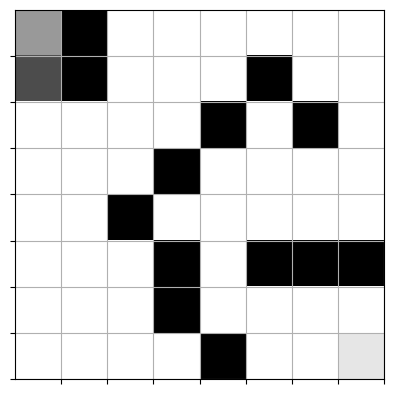

In [6]:
qmaze = TreasureMaze(maze)
canvas, reward, game_over = qmaze.act(DOWN)
print("reward=", reward)
show(qmaze)

<div class="alert alert-block alert-warning" style="color:black;">
    <b>NOTE:</b> This <b>play_game()</b> function simulates a full game based on the provided trained model. The other parameters include the TreasureMaze object, the starting position of the pirate and max amount of steps to make sure the code does not get stuck in a loop.
</div>

In [7]:
def play_game(model, qmaze, pirate_cell, max_steps=None):
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4  # safety cutoff

    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)

        q_values = model(state, training=False).numpy()
        action = np.argmax(q_values[0])

        envstate, reward, game_status = qmaze.act(action)
        steps += 1

        if game_status == 'win':
            return True
        elif game_status == 'lose':
            return False

    return False  # timed out with no result

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
    This <b>completion_check()</b> function helps you to determine whether the pirate can win any game at all. If your maze is not well designed, the pirate may not win any game at all. In this case, your training would not yield any result. The provided maze in this notebook ensures that there is a path to win and you can run this method to check.
</div>

In [8]:
def completion_check(model, maze_or_qmaze, max_steps=None):   
    successful_cells = set() #DEBUG
    
    # Accept either raw numpy maze or TreasureMaze instance
    if isinstance(maze_or_qmaze, TreasureMaze):
        qmaze = maze_or_qmaze
    else:
        qmaze = TreasureMaze(maze_or_qmaze)

    for cell in qmaze.free_cells:        
        if not qmaze.valid_actions(cell):
            continue
        if not play_game(model, qmaze, cell, max_steps=max_steps):            
            print("SUCCESSFUL START CELLS:", list(successful_cells)) #DEBUG
            print("FAILED START CELL: ", cell) #DEBUG
            return False

        #DEBUG; if not failed then the cell is a sucessfully completed game
        successful_cells.add(cell)        

    print("All Start Cells Passed!")
    return True

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
</b>The <b>build_model()</b> function in the block below will build the neural network model. Review the code and note the number of layers, as well as the activation, optimizer, and loss functions that are used to train the model.
</div>

In [9]:
def build_model(maze):
    model = Sequential()
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer='adam', loss='mse')
    return model

<div class="alert alert-block alert-warning" style="color:black;">
    <b>Note:</b>
    This <b>train_step()</b> helper function in the block below is used to help predict Q-values (quality values) in the current modelto see how good each action is in a given state and improve the Q-network by reducing the gap between what is predicted and what should have been predicted. 
</div>
<br>
<div class="alert alert-block alert-info" style="color:black;">
If you're interested in reading up on the <i>@tf.function</i>, which is a decorator for Tensorflow to run this code into a TensorFlow computation graph, please refer to this link: <a href="https://www.tensorflow.org/guide/intro_to_graphs">https://www.tensorflow.org/guide/intro_to_graphs</a>
</div>


<h2>Tensorflow GPU Warning</h2>
<div class="alert alert-block alert-danger" style="color: #333333;">
    You will see a <b>warning in red</b> "INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.". This is simply coming from <b>Tensorflow skipping using GPU for this assignment.</b>  
</div>

In [10]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        q_values = model(x, training=True)
        loss = loss_fn(y, q_values)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# #TODO: Complete the Q-Training Algorithm Code Block

<div class="alert alert-block alert-info" style="color:black;">
    This is your deep Q-learning implementation. The goal of your deep Q-learning implementation is to find the best possible navigation sequence that results in reaching the treasure cell while maximizing the reward. In your implementation, you need to determine the optimal number of epochs to achieve a 100% win rate.
</div>
    <b>Pseudocode:</b>
    <br>
    For each epoch:
        Reset the environment at a random starting cell
        agent_cell = randomly select a free cell
        <br>
        <b>Hint:</b> Review the reset method in the TreasureMaze.py class.
    
        Set the initial environment state
        env_state should reference the environment's current state
        Hint: Review the observe method in the TreasureMaze.py class.

        While game status is not game over:
           previous_envstate = env_state
            Decide on an action:
                - If possible, take a random valid exploration action and 
                  randomly choose action (left, right, up, down)
                  and assign it to an action variable
                - Else, pick the best exploitation action from the model and assign it to an action variable
                  Hint: Review the predict method in the GameExperience.py class.
    
           Retrieve the values below from the act() method.
           env_state, reward, game_status = qmaze.act(action)
           Hint: Review the act method in the TreasureMaze.py class.
    
            Track the wins and losses from the game_status using win_history 
         
           Store the episode below in the Experience replay object
           episode = [previous_envstate, action, reward, envstate, game_status]
           Hint: Review the remember method in the GameExperience.py class.
        
           Train neural network model and evaluate loss
           Hint: Call GameExperience.get_data to retrieve training data (input and target) 
           and pass to the train_step method and assign it to batch_loss and append to the loss variable
        
      If the win rate is above the threshold and your model passes the completion check, that would be your epoch.

Note: A 100% win rate <b>DOES NOT EXPLICITLY MEAN</b> that you have solved the maze. It simply indicates that during the last evaluation, the pirate <i>happened</i> to get to the treasure. Be sure to utilise the <b>completion_check()</b> function to validate your pirate found the treasure at every starting point and consistently! 

<b> You will need to complete the section starting with #START_HERE. Please use the pseudocode above as guidance. </b>


In [11]:
def qtrain(model, maze, **opt):
    # exploration factor
    global epsilon 
    
    # Number of epochs
    n_epoch = opt.get('n_epoch', 15000)
    
    # Maximum meory to store episodes
    max_memory = opt.get('max_memory', 1000)
    
    # Maximum data size for training
    data_size = opt.get('data_size', 50)
    
    # Frequency of target network updates
    target_update_freq = opt.get('target_update_freq', 50)
    
    # Start time
    start_time = datetime.datetime.now()
    
    # Construct environment/game from numpy array: maze (see argument above)
    qmaze = TreasureMaze(maze)
    
    # Target Network to better guide training
    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())
    
    # Initialize experience replay object
    experience = GameExperience(model, target_model, max_memory=max_memory)

    win_history = [] # history of win/lose game
    hsize = qmaze.maze.size // 2 #history window size
    win_rate = 0.0
    
    # =============START_HERE================
    # DEBUGGING INFO
    print(f"hsize (history window size) = {hsize}")
    
    loss = []
    
    #For each epoch: 
    for epoch in range(n_epoch):
        game_status = "not_over" # loop control var
        total_reward = 0   # DEBUGGING INFO
        episode_moves = [] # DEBUGGING INFO
    
        # Reset the environment at a random starting cell agent_cell = randomly select a free cell
        # Hint: Review the reset method in the TreasureMaze.py class.
 
        # random training to 250, then sequential training from then on
        if epoch < 250:
            agent_cell = random.choice(qmaze.free_cells)
        else:
            cell_index = (epoch - 250) % len(qmaze.free_cells)  #start sequence from beginning after epoch 250
            agent_cell = qmaze.free_cells[cell_index]
          
        qmaze.reset(agent_cell)  # reset the pirate's position to selected cell

        # Set the initial environment state         env_state should reference the environment's current state
        # Hint: Review the observe method in the TreasureMaze.py class.
        env_state = qmaze.observe() # returns the current environment state

        # While game status is not game over:
        while game_status == "not_over":            
            previous_envstate = env_state # store previous environment state
            
            # Decide on an action: (random explore or known exploit)            
            # epsilon is explore/exploit controlling var
            if np.random.rand() < epsilon: 
                # using valid_actions, generate a list of valid_moves from the current cell, then choose one at random
                valid_moves = qmaze.valid_actions()  # defaults to current pirate cell
                action = np.random.choice(valid_moves)  # select random valid action

                # DEBUGGING INFO
                random_move = True # debug shows move was random
            else:
                # using the env_state, get a list of q-Values from predict() 
                q_values = experience.predict(env_state)  # get Q-values  
                # Get the list of valid move directions from current cell (L,R,U,D)
                valid_moves = qmaze.valid_actions()       # get valid moves from current cell (L,R,U,D)
                # Get the Q-values for only the valid actions, remove q-values for invalid actions
                valid_q_values = [q_values[action] for action in valid_moves]
                # Find the index of the highest Q-value among valid actions (this index is relative to the valid actions list, not the full list of directions)
                best_q_value_index = np.argmax(valid_q_values)
                # Map highest q-value index to the list of valid move directions to get the best valid move
                action = valid_moves[best_q_value_index]
                # DEBUGGING INFO
                random_move = False # debug shows move was not random (was selected)

            if np.random.rand() < epsilon:
                # RANDOM EXPLORATION OVER FULL ACTION SPACE (INCLUDING INVALID MOVES)
                action = np.random.randint(0, len(experience.predict(env_state).flatten()))
                random_move = True  # debug shows move was random
            
            else:
                # get full Q-values (NO FILTERING, NO MASKING)
                q_values = np.array(experience.predict(env_state)).flatten()
            
                # select best action directly from full action space
                action = np.argmax(q_values)
                
                # DEBUGGING INFO
                random_move = False # debug shows move was not random (was selected)
        
            # action now contains a number value based on the direction selected: LEFT = 0,UP = 1,RIGHT = 2,DOWN = 3

            #Retrieve the values below from the act() method.
            env_state, reward, game_status = qmaze.act(action) # take the action (move pirate)
            #Hint: Review the act method in the TreasureMaze.py class.            
            # game_status directly controls ending the game loop, and its value may be: 'not_over', 'win', 'lose'

            # Track the wins and losses from the game_status using win_history
            # append win/lose as numbers to win_history for win_rate calculation later (do not append anything if game is still ongoing)
            if game_status == "win":
                win_history.append(1)
            elif game_status == "lose":
                win_history.append(0)

            # Store the episode below in the Experience replay object
            # Hint: Review the remember method in the GameExperience.py class.        
            episode = [previous_envstate, action, reward, env_state, game_status]
            experience.remember(episode) # Stores episodes in memory

            # DEBUGGING INFO
            # Map action number to name for readability
            if random_move:
                action_name = ["l", "u", "r", "d"][action] #use lowercase for random moves
            else:
                action_name = ["L", "U", "R", "D"][action] #use uppercase for selected/learned moves
            episode_moves.append(action_name)
            total_reward += reward # capture reward  

            #Train neural network model and evaluate loss
            #Hint: Call GameExperience.get_data to retrieve training data (input and target) and pass to the train_step method and assign it to batch_loss and append to the loss variable
            # GameExperience.get_data() Prepares one batch for custom train_step() method. Returns: inputs, targets
            inputs, targets = experience.get_data()
            # train_step() accepts 2 vars inputs, targets, and returns the loss value
            batch_loss = train_step(inputs, targets)
            loss.append(batch_loss)

        # End of game While Loop
        
        
    # =============END UPDATE================ 
        
        # Win rate over last hsize steps 
        win_rate = sum(win_history[-hsize:]) / hsize if len(win_history) >= hsize else 0.0

        # Print the epoch, loss, episode, win count, win rate, and time for each epoch
        dt = datetime.datetime.now() - start_time
        t = format_time(dt.total_seconds())
        #print("Epoch: {:03d}/{:d} | Loss: {:.4f} | Episodes: {:d} | Win count: {:d} | Win rate: {:.3f} | time: {}".format(
            #epoch, n_epoch-1, loss, n_episodes, sum(win_history), win_rate, t))

        # loss and n_episodes were causing issues
            # NameError: name 'n_episodes' is not defined
            # TypeError: unsupported format string passed to list.__format__
        print("Epoch: {:03d}/{:d} | Loss: {:.4f} | Episodes: {:d} | Win count: {:d} | Win rate: {:.3f} | time: {}".format(
            epoch, n_epoch-1, sum(loss)/len(loss), n_epoch, sum(win_history), win_rate, t)) 

        # DEBUGGING INFO
        # At end of episode, display game status, reward, & moves for debugging
        print(f"   {game_status} | Epoch Reward: {total_reward} | {''.join(episode_moves)}")        

        #DEBUG - show th maze afer each epoch
        show(qmaze)   
        plt.pause(0.01)
        
        # Check if training has exhausted all free cells and if in all
        # cases the agent won
        if win_rate > 0.9:
            epsilon = 0.05        
        else:
            epsilon = max(epsilon * epsilon_decay, epsilon_min)
    
        if win_rate >= 0.999 and completion_check(model, maze):
            print(f"Reached 100% win rate at epoch {epoch}")
            break

    total_time = format_time((datetime.datetime.now() - start_time).total_seconds())
    print("Training complete in:", total_time)


# This is a small utility for printing readable time strings:
def format_time(seconds):
    if seconds < 400:
        s = float(seconds)
        return "%.1f seconds" % (s,)
    elif seconds < 4000:
        m = seconds / 60.0
        return "%.2f minutes" % (m,)
    else:
        h = seconds / 3600.0
        return "%.2f hours" % (h,)

## Test Your Model

Now we will start testing the deep Q-learning implementation. To begin, select **Cell**, then **Run All** from the menu bar. This will run your notebook. As it runs, you should see output begin to appear beneath the next few cells. The code below creates an <b>instance</b> of TreasureMaze. This does not show your actual training done.

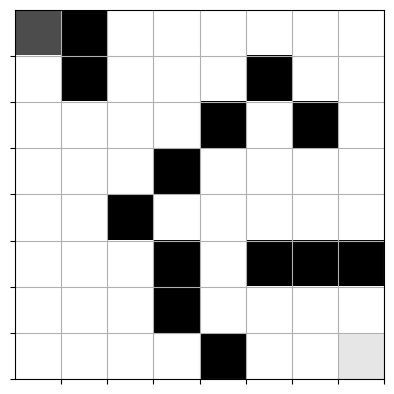

In [12]:
qmaze = TreasureMaze(maze)
show(qmaze)

In the next code block, you will build your model using the <b>build_model</b> function and train it using deep Q-learning. Note: This step takes several minutes to fully run.



<div class="alert alert-block alert-danger" style="color: #333333;">
  <b>WARNING</b>  If you did not attempt the assignment, the code <b>will</b> error out at this section.
 </div>

/home/codio/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


hsize (history window size) = 32
Epoch: 000/999 | Loss: 0.0040 | Episodes: 1000 | Win count: 0 | Win rate: 0.000 | time: 3.3 seconds
   lose | Epoch Reward: -32.099999999999994 | ulrlrluuuuldduruldurllruulddllullluudrrrduruuldurllruruddlldldludrulduduruudddruldrrrluuddururlruurrrrurldurullllldlrdluruurlrlludurdluudrdld


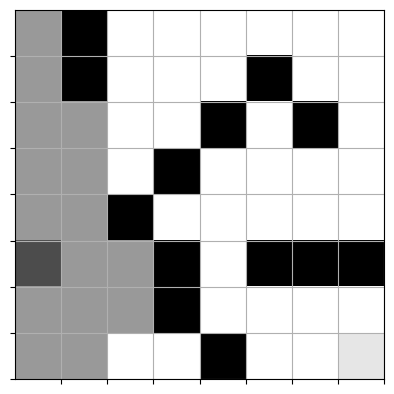

Epoch: 001/999 | Loss: 0.0027 | Episodes: 1000 | Win count: 1 | Win rate: 0.000 | time: 5.6 seconds
   win | Epoch Reward: -27.759999999999994 | rrlullddrudrdLdrlddldllrlrluruluuurrdudrlddrrulrurrurrdduulrddldluluduldulrrrlllurdrlururduulddluldllrddldrdullrllluddudldrururldddr


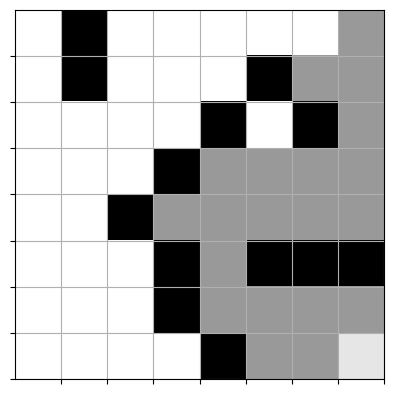

Epoch: 002/999 | Loss: 0.0027 | Episodes: 1000 | Win count: 1 | Win rate: 0.000 | time: 8.0 seconds
   lose | Epoch Reward: -32.17999999999999 | ddrlululudrrllddluludduululldullulddldlddrurdurdurrluuddldrlrlldurullrlllddulururulduUrldlduuldrrddlddullurlululuurdlluluudlrdrdudlurlldddrdddu


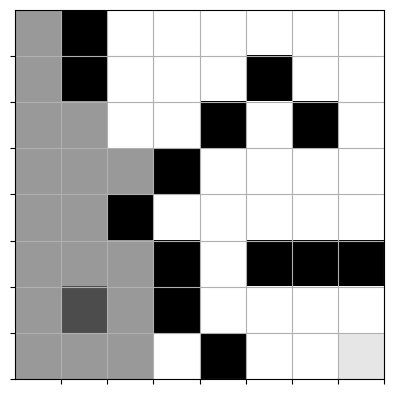

Epoch: 003/999 | Loss: 0.0026 | Episodes: 1000 | Win count: 1 | Win rate: 0.000 | time: 10.8 seconds
   lose | Epoch Reward: -32.11999999999999 | rrllrddlRduruldrururUuuurlduudrdddldluulurrdddudrurdludurlrrrdulluddldrrlduldlldruldddrddrrlrruUdulududrullurddudurududurudrduldrurdlrdlluddrrullrduudru


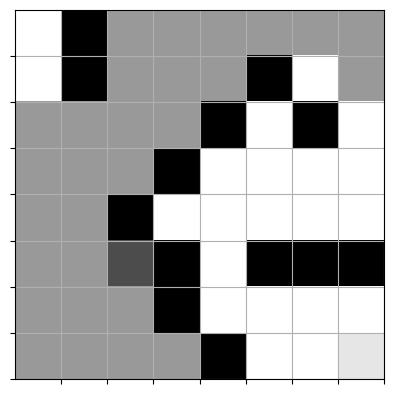

Epoch: 004/999 | Loss: 0.0025 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 12.0 seconds
   win | Epoch Reward: -11.559999999999993 | lrldllrllllldrullrdlrludruruudlruluulldldldurdldrudrdduuRuldurd


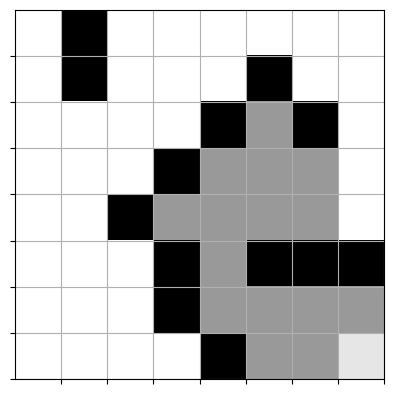

Epoch: 005/999 | Loss: 0.0027 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 14.3 seconds
   lose | Epoch Reward: -32.19 | lurudullulrrlluululrrllluuuulrllurulddllrldulrdurldlduuuddrudrdudldlduulduduulrlddrulllurlrdluldlrdldulullrrddulduurrduuududrrruludllulldl


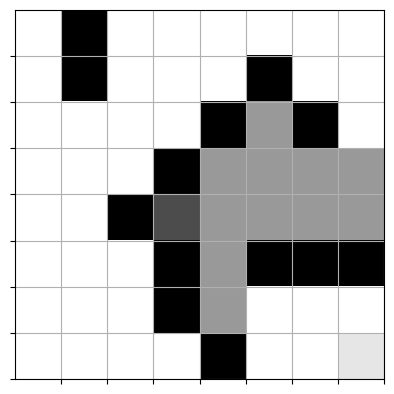

Epoch: 006/999 | Loss: 0.0027 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 17.1 seconds
   lose | Epoch Reward: -32.19999999999999 | rruluulRllddlrrudurruruddrdurluddruRlurrduldlrudldduruuddlllrruudurdruduRuurlldrrlrrurrluuruurruudrdddrllldrllulrrddudluuurululldurlulrdrdludduuudldlrdulr


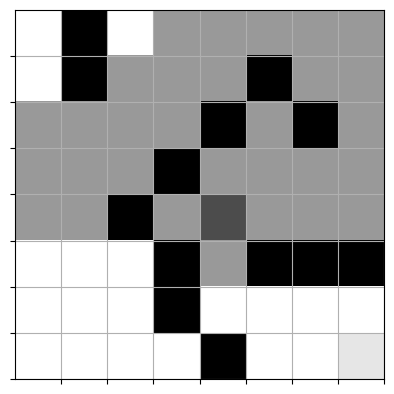

Epoch: 007/999 | Loss: 0.0026 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 19.7 seconds
   lose | Epoch Reward: -32.12999999999999 | rldrdrlrrDldruuddlrRlllluuuurduurdllurlllllrudrurddduLdldlldlulddrrdruddrdddRrurdddulllluduldllulrrdlulurdDuuullldduurduuuuluurududurdrrdulrrurlulr


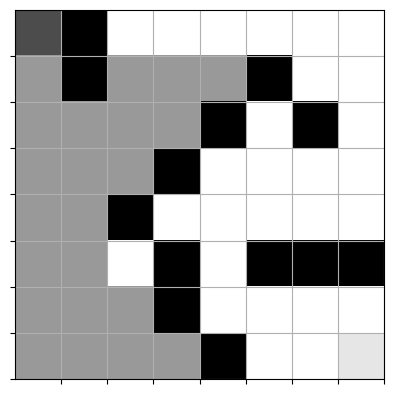

Epoch: 008/999 | Loss: 0.0025 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 21.9 seconds
   lose | Epoch Reward: -32.11 | udrrdllldulruulduuuululuduruuuudurlrrluuruurdlulrrdlluuuuldduduluudlrllulddrulrurdrllduurullurrrlullurruuuruullurlurrurrdddururdlrurlldr


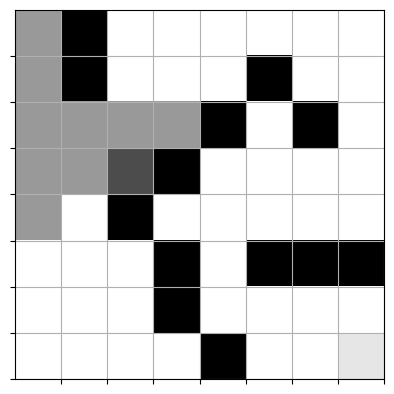

Epoch: 009/999 | Loss: 0.0023 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 24.3 seconds
   lose | Epoch Reward: -32.129999999999995 | rRrluuuudldludrlulurrlruddrrdlLduddullduRdrdrldlrdlrlllddldlrllrlrruluuuuuldllrdrdududludrlludlurrdurrlrurduddrrudrRdluuuldrlllurlrlddlruururrrlldr


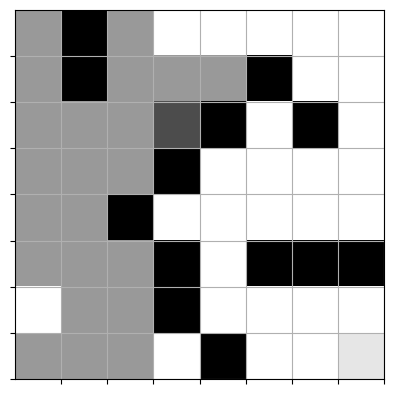

Epoch: 010/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 2 | Win rate: 0.000 | time: 26.9 seconds
   lose | Epoch Reward: -32.11999999999999 | rududurrRrurlrurrrdurdllurlrlrulrudluulrrruldrrRdrdddDdlludrurURuuRlldlldluuuudrruurrdlduruddddrrdurrDRdlludddruudllDdddRdlluddrlrludlllrldurllurllrdlrR


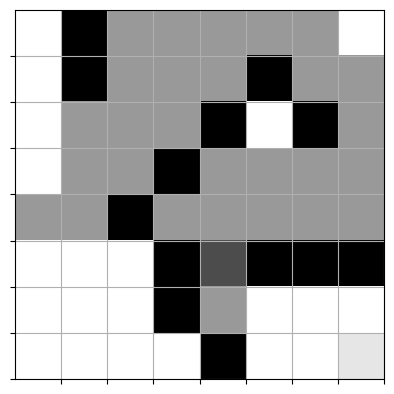

Epoch: 011/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 3 | Win rate: 0.000 | time: 27.1 seconds
   win | Epoch Reward: 0.5 | urD


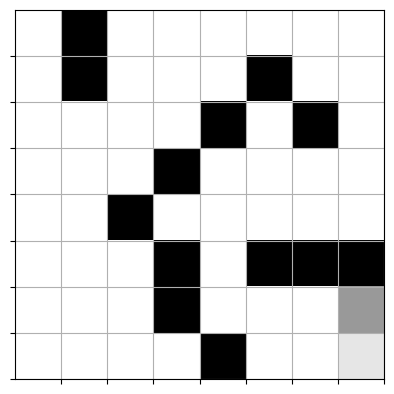

Epoch: 012/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 4 | Win rate: 0.000 | time: 27.6 seconds
   win | Epoch Reward: -1.4100000000000001 | luldrurrllRddr


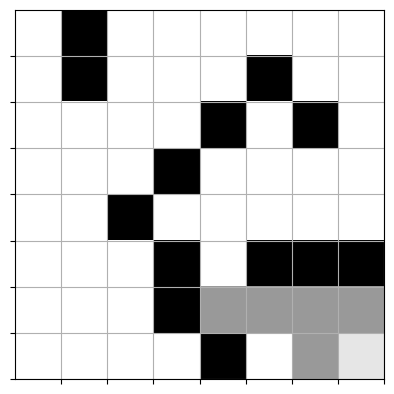

Epoch: 013/999 | Loss: 0.0023 | Episodes: 1000 | Win count: 4 | Win rate: 0.000 | time: 30.1 seconds
   lose | Epoch Reward: -32.16999999999999 | lldruululrlulrrrdurrrdrddrudlrdlRuuruldrrruullrdurudldUurulrurudllduuudrlduddrulDurrdlddrruLrllulddudrrUrdulururuddudulrllrruRDururdurluudllRddduudd


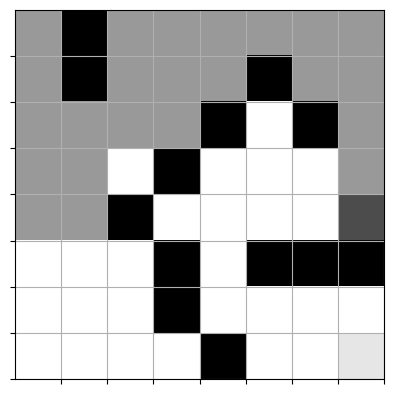

Epoch: 014/999 | Loss: 0.0023 | Episodes: 1000 | Win count: 4 | Win rate: 0.000 | time: 32.5 seconds
   lose | Epoch Reward: -32.099999999999994 | lldrrlulrldLuruurDlurulrulurdrurudldrdurudllDdrulrrrrrrudrdLdDrlrDuuudDuuldurdldddLlurrurudrdduulDDrDllrdlluUululrrrudrduddlrlDurlrdldudDduud


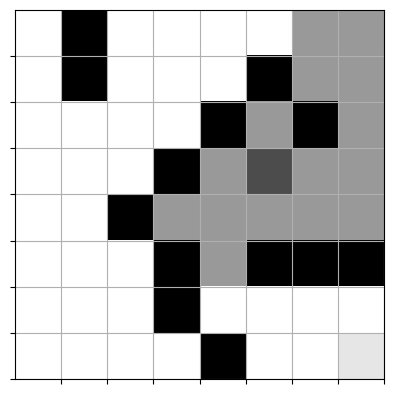

Epoch: 015/999 | Loss: 0.0024 | Episodes: 1000 | Win count: 4 | Win rate: 0.000 | time: 34.9 seconds
   lose | Epoch Reward: -32.19 | rRdrrduurrldrrLldlrdudlurdrlluudrrrrllRuuldlrrrlrdldllrulrurdrrdduuuulrDrlrdldrdduuRrllruDluDulruUlrrdDlullllddlddRUdurdurullluulrrlrlrlur


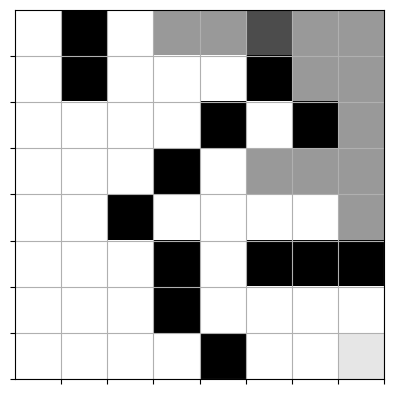

Epoch: 016/999 | Loss: 0.0024 | Episodes: 1000 | Win count: 5 | Win rate: 0.000 | time: 35.5 seconds
   win | Epoch Reward: -2.4400000000000004 | ldurDlllllrddrdldrdurldr


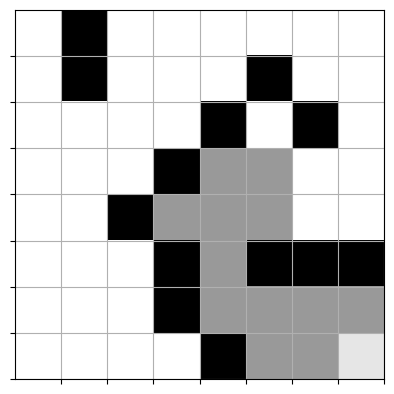

Epoch: 017/999 | Loss: 0.0024 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 37.3 seconds
   win | Epoch Reward: -21.059999999999995 | rdullduluurllrulLrduuulRudrddudrRlLRrllrduuluruDuuuddrruddrRrllrdlduUduruulrRrududlulDlrdlllrldlrdrdr


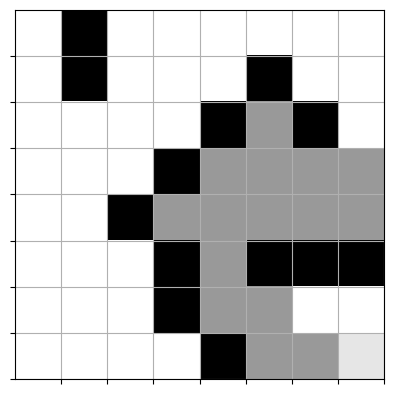

Epoch: 018/999 | Loss: 0.0024 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 39.8 seconds
   lose | Epoch Reward: -32.15 | dlrduddlrrurldldurrldrLluludllrudrrrDruruurudrlldrlrdrRlrdldllduurrddRdddrlullrudrRrdurlrudrdldllrlldlrluurldrrdulDdrurrdruulldduulRudduu


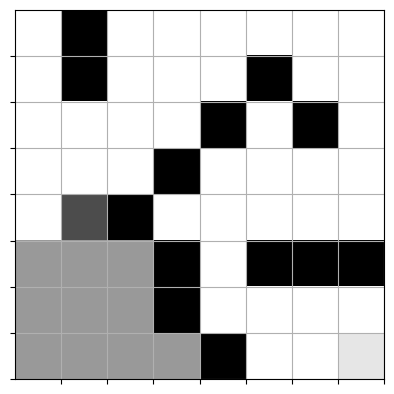

Epoch: 019/999 | Loss: 0.0024 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 42.2 seconds
   lose | Epoch Reward: -32.17999999999999 | ldrruludrldudlrduuulrRduRLldddrlurddlRdulddrudllurdLluurulurLrLurUullurulduurududRlllluuuurllllullRRLulduururlrRllruldDlddRRrlulRRduuldduddrllu


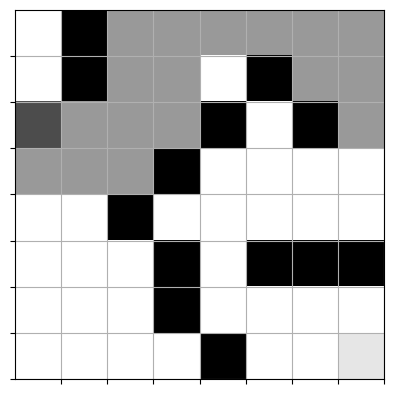

Epoch: 020/999 | Loss: 0.0023 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 44.8 seconds
   lose | Epoch Reward: -32.209999999999994 | rrrludldduuLluRurluulDrdddlurllullrurrudrdduurdurlDdrlddlddluruuudluuudduLulLrduuduuuDrlruuruRrudrrrrurrrlurrdrDrudlrulldrdduDudurruldluludrddDlRdddr


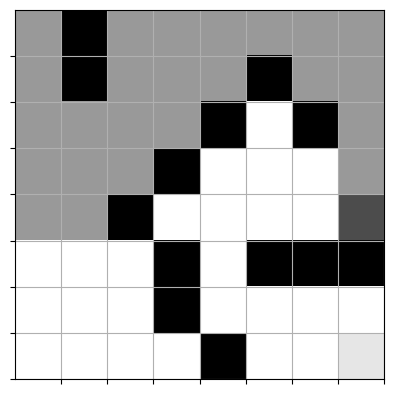

Epoch: 021/999 | Loss: 0.0023 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 47.3 seconds
   lose | Epoch Reward: -32.14 | rdDldrldDldlDlllulludrDrdurdUlRurlululldrrluuurlldduDDrrlllllDuluurullDdurDlldrddurlrrrrrurrDDdddrdruUdrldlDurldldlurrrulruudLlrdurDrruurLruRu


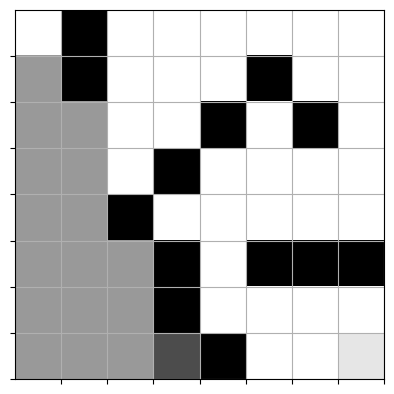

Epoch: 022/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 49.8 seconds
   lose | Epoch Reward: -32.22999999999999 | ldUuurdUududUuuDUdulUrurlrllUdurruullrDrdrludulduururdrldrdlluduuUuduurlruUduulddrullllullldrldrdlrUDldlurrrdduuudludrdrllDrlullurduldrldUl


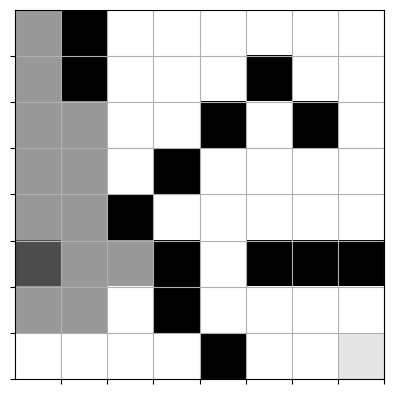

Epoch: 023/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 6 | Win rate: 0.000 | time: 52.3 seconds
   lose | Epoch Reward: -32.249999999999986 | lrdudlurrrrudlullrlurduduuluLullurllrrdudrurdRdULrrdluddrrudururUlurrUUdLduDllrdDuDluddrdrddrdlllluurdlurudlrdrrDdrdDdlrdrrddrruulrRuurdluluduuludrdrd


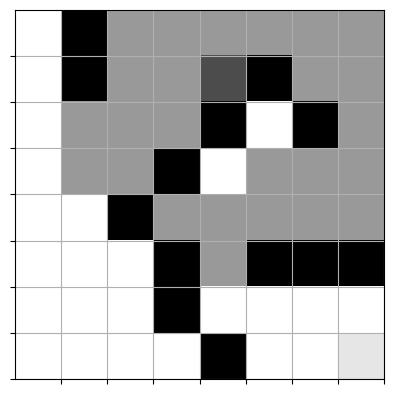

Epoch: 024/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 53.3 seconds
   win | Epoch Reward: -8.2 | duuRluduudulldruurluruRlRrrrRludlruurRrRud


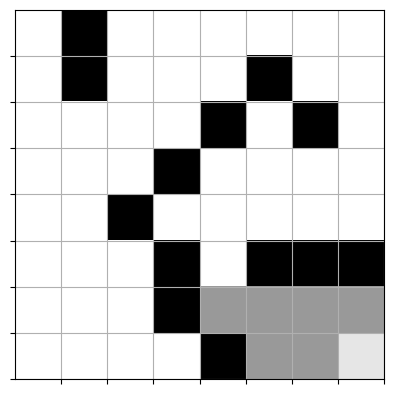

Epoch: 025/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 56.0 seconds
   lose | Epoch Reward: -32.20999999999999 | duldlrulurrlrdduuuudlluudduDdrdDLDudurllldurdurdLrduddDDrddduuddDururdludddlllrldddrDrurDdrDruDurddrrrrrdduLldLDududldDurdduruulludruuddrdrlDrrDurrru


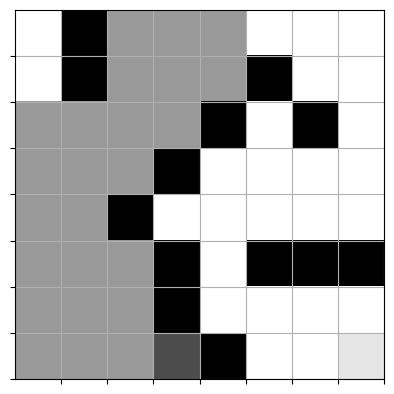

Epoch: 026/999 | Loss: 0.0022 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 58.5 seconds
   lose | Epoch Reward: -32.13999999999999 | ldrdLlrdLdrulrllllrlurDddllldDrdrlruuluududuruluDlrlludDrDrlldullddudddddddLduddlrududlddlUuLLulrrlddLdruuDllrllUUldlruuulldulllrddduddruudduu


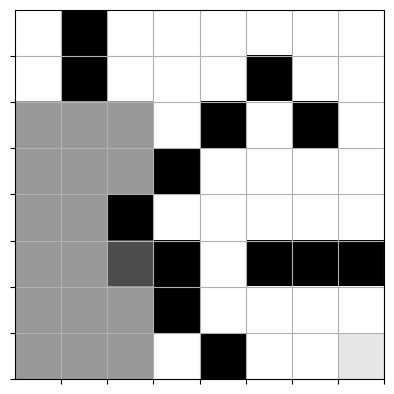

Epoch: 027/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 61.1 seconds
   lose | Epoch Reward: -32.04999999999999 | udrrurrlurddrdddrllUudlldlrlDdulDuDuluDDldrrulruldduduuduruddrrurllllrluUudrurrdllrdldUrdLrLurdluLudldduluuurlDuddlldddrurluuulrudddurururudldurU


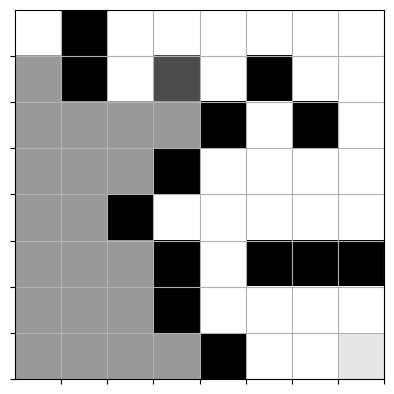

Epoch: 028/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 63.6 seconds
   lose | Epoch Reward: -32.00999999999999 | drdDDrlDrrrrlrldLruDrlrrrDddruurlLuuulrudlulrdldlurlduddduudLludduLduDuDlrDuuuldduldlrluuruuLlddrrrurluLdLulrdrrulrDudduDdudlrllRrRuLlruludldluu


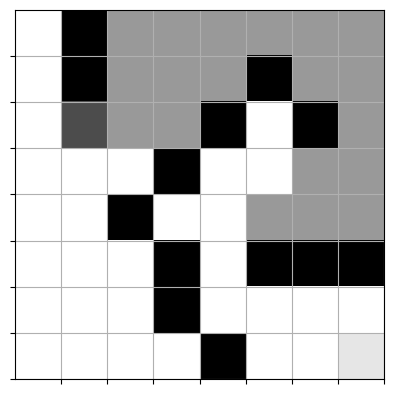

Epoch: 029/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 7 | Win rate: 0.000 | time: 66.2 seconds
   lose | Epoch Reward: -32.22 | lrudDddLdulrududruUullUuldrurduLdlDurrruddUlUUlrudlurruDdlllUddUdduulrudlruldrduludlrdldurDrulrrrrulRldUddrRurlurdluudrrrdrldrrulullllluRLDlrdLu


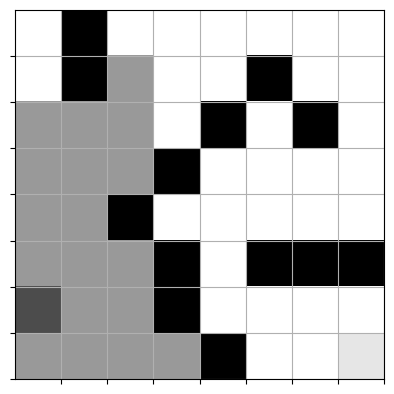

Epoch: 030/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 8 | Win rate: 0.000 | time: 67.7 seconds
   win | Epoch Reward: -15.559999999999995 | ulduururrdrlllduudruulrlUulldDdlruDrdllLlludrlrdlrluuldduDuddrdLLurRlDldldrlrDr


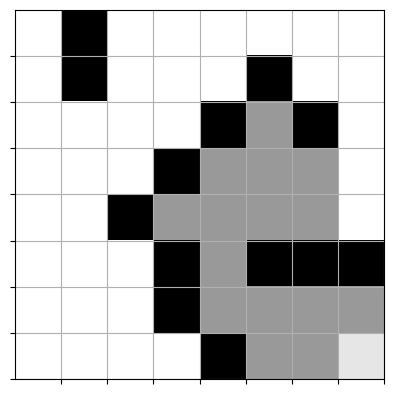

Epoch: 031/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 8 | Win rate: 0.250 | time: 70.3 seconds
   lose | Epoch Reward: -32.00999999999999 | rLurdurudrdluuuddlRrlddulRuddRdldddrrLulrRuuldlrrllURRlRdluduLddddlllllUduullrlRlddrlrlDDlUluluddluRdululDuuurrudrLdLlrdudddrlUduudruruuduullddr


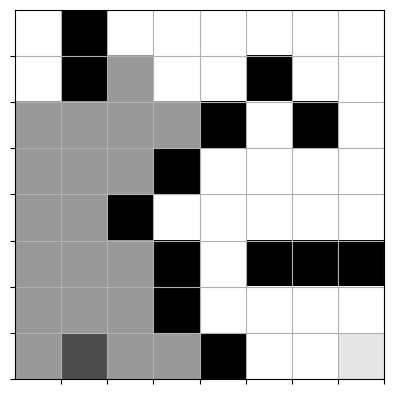

Epoch: 032/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 8 | Win rate: 0.250 | time: 73.0 seconds
   lose | Epoch Reward: -32.21999999999999 | llDlrdrddduUUlrdulrrrulrduDruDudddrrduuRRRrrLdulrdurddrurrdlRRrrlrrRlUUrrrudrrururuRRlRrurrRluuuuuduuduDrduLulddduuulurrdurrLulruUllddrdlluuldrl


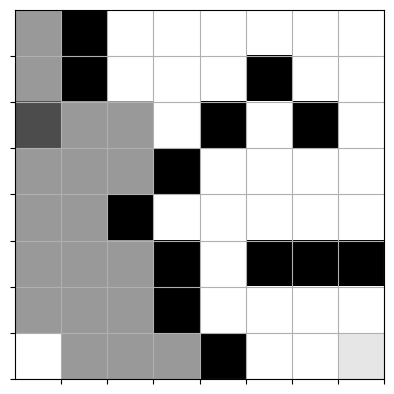

Epoch: 033/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 8 | Win rate: 0.219 | time: 75.8 seconds
   lose | Epoch Reward: -32.11999999999998 | LdlLrlUuldlRrrRulDdDurudrdRRlURuLldludrduRddRRRuulrluLlrLullrlldlrRrlllduldruuuuuurrldduuduruRdrurLduurrRrrrulLdlLddrRurdDdrdululrDlUlulLdrrudlldldlDddl


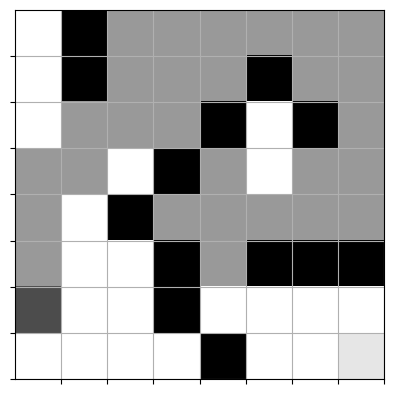

Epoch: 034/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 9 | Win rate: 0.250 | time: 76.2 seconds
   win | Epoch Reward: 1.0 | r


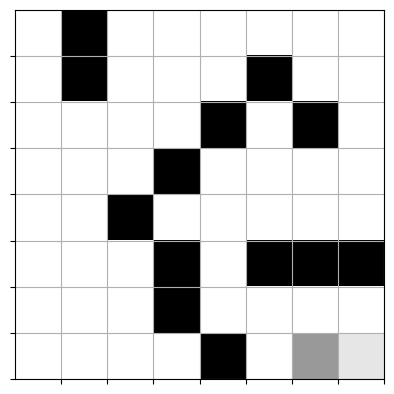

Epoch: 035/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 9 | Win rate: 0.250 | time: 78.9 seconds
   lose | Epoch Reward: -32.16999999999999 | rUlddrRrllDDDdDlduDrRlrddurLulrlludUdRlurdrlrdrdddlrurdrddLLuUllludulRlrdRrDdUrdurlurllUlddlluuluuuurDuurdrrrudddruruRuddrRldruluuuDddruruuduldlurdU


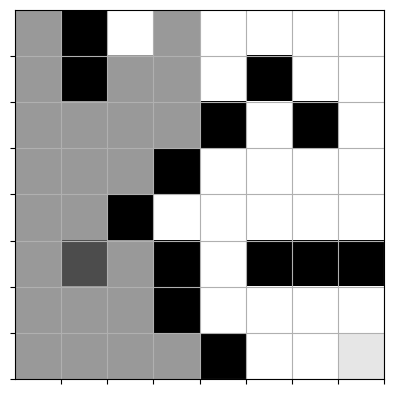

Epoch: 036/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 81.7 seconds
   lose | Epoch Reward: -32.079999999999984 | ulurrllddRurlRRdlrduldUUdllldddddLldLulLLddurrldlddurlrruuDLDLurLduuddurDrrDlllurulrLlrldrLllddurudRdulrdrlruLlDullrddlurruLululrduduuuddrdluulrdurduur


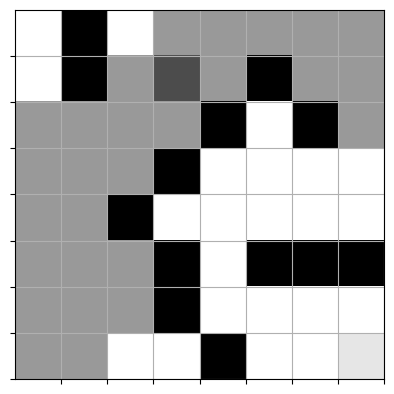

Epoch: 037/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 84.3 seconds
   lose | Epoch Reward: -32.099999999999994 | DlDUdddlrulururldlDrdrDdduDlurduUlulrdurddlurldlrlRdDlurdlluDrDDuudrrLrrlldrldRLRruurdrrdrlullDdrlrDrrlruuurdlurlllurdlduduuRrulddurrrruurDdd


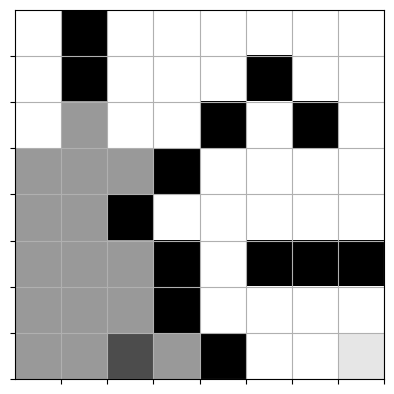

Epoch: 038/999 | Loss: 0.0021 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 87.0 seconds
   lose | Epoch Reward: -32.12999999999999 | RurdRRruuLdlDulrulldrrdRlRlululuulurdllurLlrluuduRdddrdddLrlulrlUrudllurrdDudDulldrldLrLrldlldrldRdurlduUuldddduruuurddluluulrrdrRlDruuudllllrdlddl


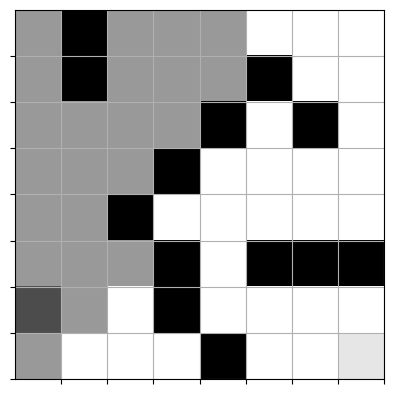

Epoch: 039/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 89.8 seconds
   lose | Epoch Reward: -32.05 | drddruduruuDdrllDdduruUrddrlDdDDdllulUdrulddluRrrUulludldluldLLLLluddUddlUrUuUlUlUUlUdlldurdddllldulUluulluddldurdLlurRlRdlluudUrUlluUudldduddudl


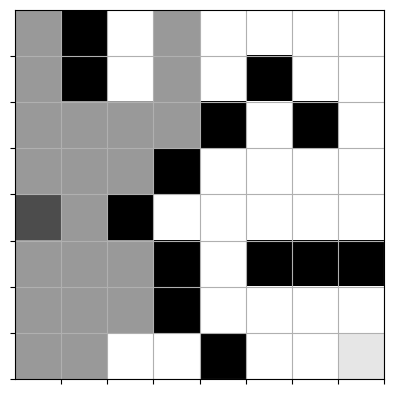

Epoch: 040/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 92.5 seconds
   lose | Epoch Reward: -32.14 | ulruruDrddllUlUlrrdrlDurdDrdRlruRlllRrlrdulludrdrlrUurruduurdUdrUdrUUdddlllDdrlDdddddlddrlddlldrUlurruluulUUdululdUrudUrllruUludUUrluUlUdUrdrd


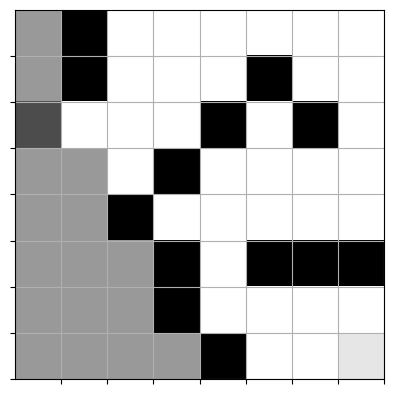

Epoch: 041/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 9 | Win rate: 0.219 | time: 95.1 seconds
   lose | Epoch Reward: -32.099999999999994 | UuuUdulldrlllUddrlDrrdUuuudruUrlruUurUuddRUulRurDuDulDDurudDulruudlrlrDrrlRurUddurrlLUrrUdruuuldruruddlUrdruddrDrrruDUrrdudrrLullddrudlludrll


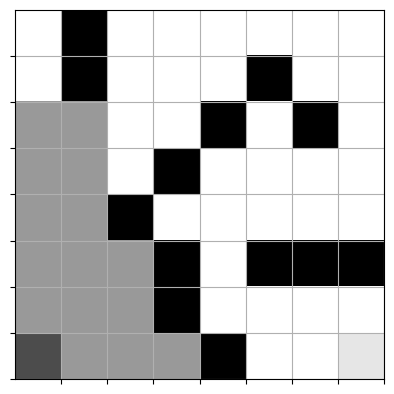

Epoch: 042/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 10 | Win rate: 0.250 | time: 95.7 seconds
   win | Epoch Reward: 0.88 | ldrR


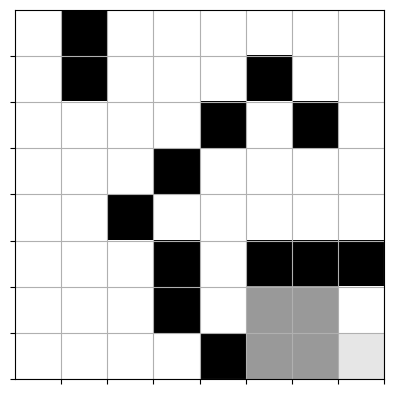

Epoch: 043/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 10 | Win rate: 0.219 | time: 98.5 seconds
   lose | Epoch Reward: -32.06999999999998 | uuLudLulUuurruDuRdlrRdluRlrrddurdulrllurrlrUdludLDrdruulllrlrLlllllrUudRudRlldDddrrrrruRRuRuuuddulrLrLlULlLLluuUddLldrdLrUddulrurlRludRurluuluruLrddDduDulud


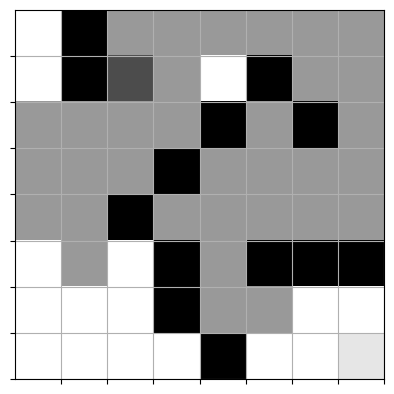

Epoch: 044/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 10 | Win rate: 0.188 | time: 101.2 seconds
   lose | Epoch Reward: -32.17999999999999 | llulruldLrLrdllrduUddudllrdrLulrLdrlLurdurrdulluurrrurrldRLuLdlldudruulddurlRlRRlruulllldRLruudLdrruldldlurullludrLlDDDurruRurrdldlrdlrudDrudrr


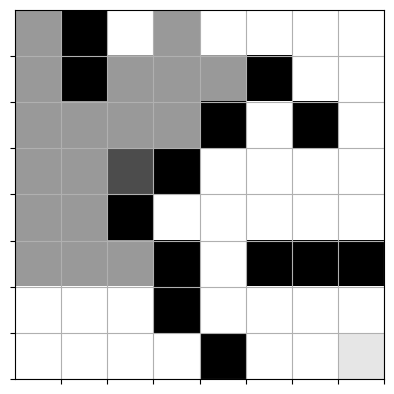

Epoch: 045/999 | Loss: 0.0020 | Episodes: 1000 | Win count: 11 | Win rate: 0.219 | time: 103.2 seconds
   win | Epoch Reward: -19.29999999999999 | rrRuRuDurduludDdddULulLrUruRrluuurUldrdRdldLdrdllrluldLluddLlrdRlrrrruddlddlddulurluDdrdRrdldllldrR


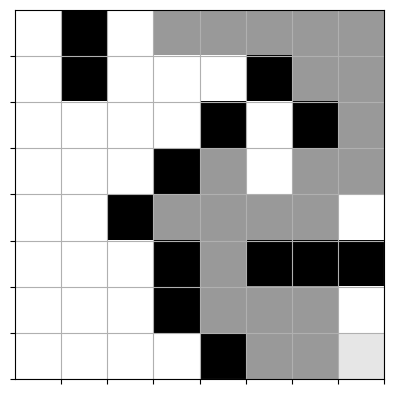

Epoch: 046/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 11 | Win rate: 0.219 | time: 106.2 seconds
   lose | Epoch Reward: -32.23999999999998 | uduruudrrudddruLulldudDuuddulrlurLuuRdlulDudlulRlLuruullldddulrrDulllurlrrurruRlddUUlurrDrldluluDDRulruurrdRdUurldrlddudddurulrlRrdRlruDLurrlURddUdrlllDDud


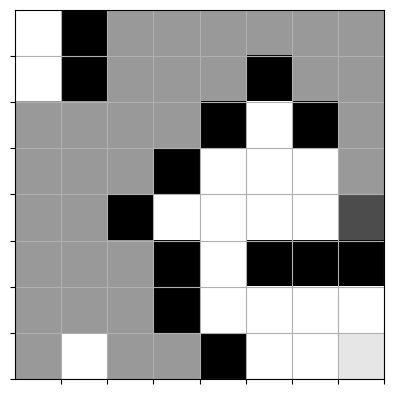

Epoch: 047/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 11 | Win rate: 0.219 | time: 108.9 seconds
   lose | Epoch Reward: -32.059999999999995 | drullddluduUdrdUddrRrurrRRdrulRudLuluRrurlRuuuRrdrluduRdRdrlduulrddldurlrlrddrUDrludlURRrUllurLRddrdudrrUDuDdrulDrUlullRdRrUrluDrurullduldld


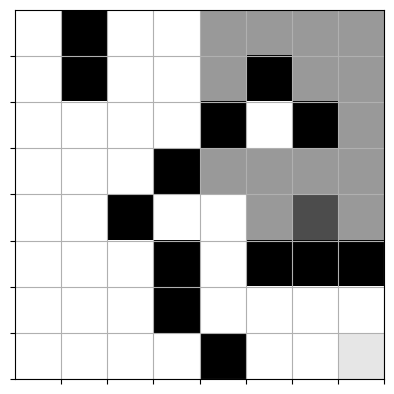

Epoch: 048/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 12 | Win rate: 0.219 | time: 111.5 seconds
   win | Epoch Reward: -26.679999999999993 | DdDrudrUduLluuRrRuDurrrlUUdrdurrruduruldDlrdlllduDDrrrrldduluurUUrruuUuUruUdrrududlDuldlllllrlDrdDududdLLRlluDllLdrrluddddddRr


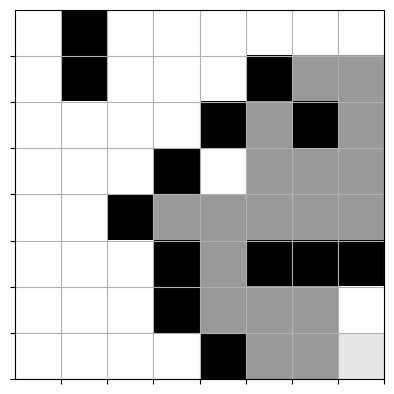

Epoch: 049/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 13 | Win rate: 0.219 | time: 112.2 seconds
   win | Epoch Reward: -0.1100000000000001 | uDDludDDRruRd


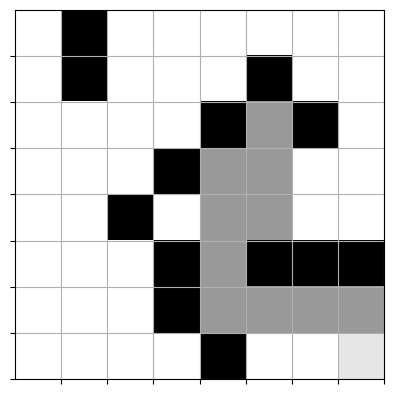

Epoch: 050/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 113.3 seconds
   win | Epoch Reward: -4.890000000000001 | uUlrlrrrrdrdudLdludulldddlldDulldRdlrR


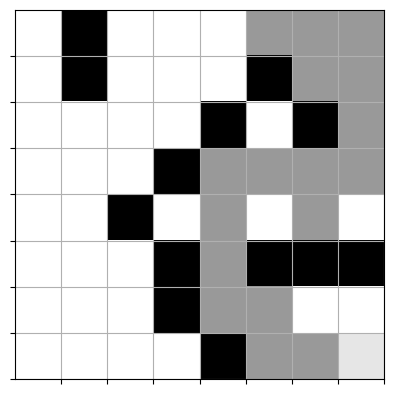

Epoch: 051/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 116.0 seconds
   lose | Epoch Reward: -32.019999999999996 | dlurrurLdulllldurllduluurRrdDdddDrlulDuluDrudDrdlduulDlRulurrlludrrrDrllrldddRuuDrrulllDlDDuDdrrluRlrlRdrrDurDrrDdDullrdudLdLruRRRuuuudlDrr


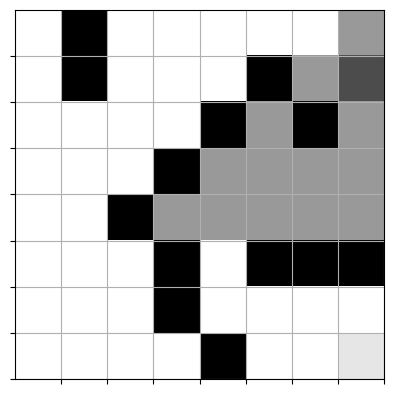

Epoch: 052/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 118.8 seconds
   lose | Epoch Reward: -32.22 | rlRlRdrrUdudlululuDuuudRrLuddlluurUUlulDrldDrduUdrulrdLLddRuRRrrRdlrDlldUUUUUdlddrlrlurlldduldurludurrludduullrdRRuldrrruluUUUruDrdRldluulrdUlrD


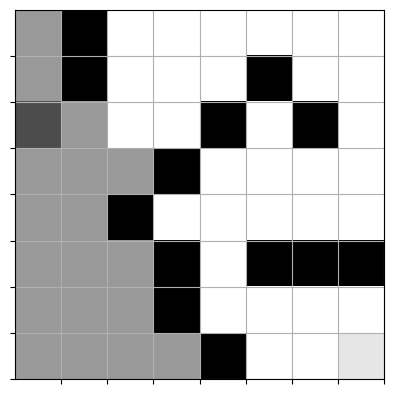

Epoch: 053/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 121.7 seconds
   lose | Epoch Reward: -32.249999999999986 | DDDrdllrduUDUdrdrRurDrrluduDDddDldldrrUrrDldDuudrDUluuurDulDudlDDDdduUUururdDrRruuudrruLdudlRdrLDudulldrdDuDuLddluDdlUlddddUddrLrldUrlrUlrRdDRrurrLLuu


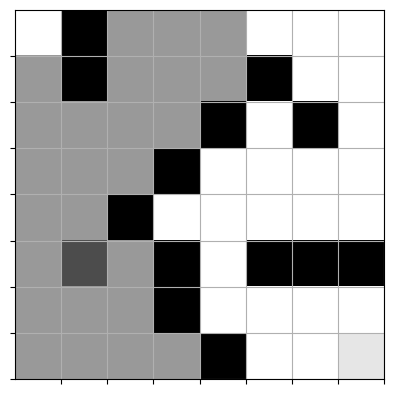

Epoch: 054/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 124.4 seconds
   lose | Epoch Reward: -32.19 | LruudrUDlDrurUdUulrLldduruDDrulduulRRduUUdldlDruUdrDRddLlrlLUuuddluurDllldldRluurldrdrulrUurrlrurdLUlUlddRdRRddllluUrdrdLlLllurrrRluRllddu


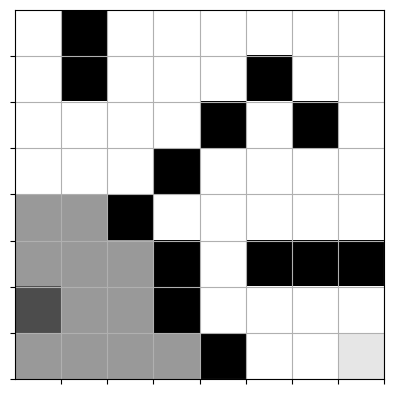

Epoch: 055/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.250 | time: 127.4 seconds
   lose | Epoch Reward: -32.21999999999999 | uDluldrruulDlddlUdrldlLdduDurudlruulUUuUuUuuuuuudldDlddDdudRllRlruUUurUdULdDrRrLurdLlurlDDuuuDlrdDurDrlrrruRruuLlRlruRrududlulrdUdurDLurullRDlul


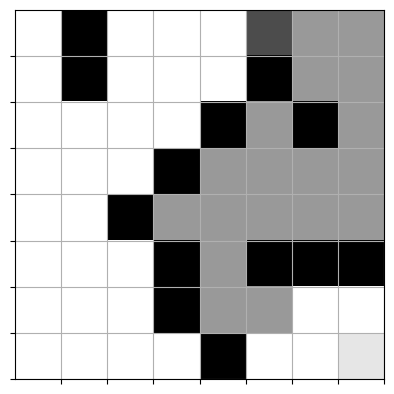

Epoch: 056/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 14 | Win rate: 0.219 | time: 130.3 seconds
   lose | Epoch Reward: -32.00999999999999 | uuludrrRurRuRuudldudUrurludRLrLRlRLrLlrRrlulrUudUduulrlRuUrUllrllUuulDuudlurruRulrudlDdUdUlUrlUUuudRdRuduudlruLLllUUuUldUrrUUldUlurulUuUruRRruur


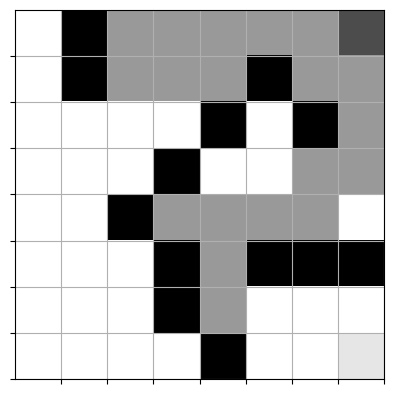

Epoch: 057/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 15 | Win rate: 0.250 | time: 132.2 seconds
   win | Epoch Reward: -17.729999999999997 | rllRulrulllllddUrlldUrduurdUuRRddlrdRllduddluDRlldrUlUUrdRuddRlluuDuDdRudUdlrllddrddrr


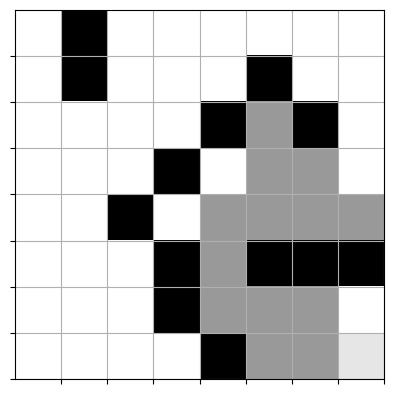

Epoch: 058/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 16 | Win rate: 0.281 | time: 133.7 seconds
   win | Epoch Reward: -9.979999999999999 | rrrlurrrllUUrduUruLlldurLdrRLuldldddudRullrldrUlurdrrdR


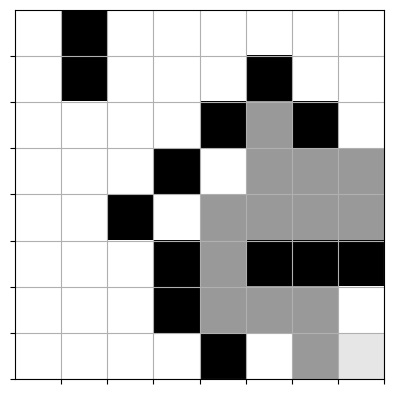

Epoch: 059/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 16 | Win rate: 0.281 | time: 136.6 seconds
   lose | Epoch Reward: -32.209999999999994 | rududruDRRllruduUurulUlUuUruRrrRRddrdrlUurrlrrrdlUudlUddRulUUdUuUUdUduldlulLurrLUUdududlDuDLLdRRlludrulldLurrLuuUrUUlrlrUurdUdUruuUUUrlRdlUuulurrruld


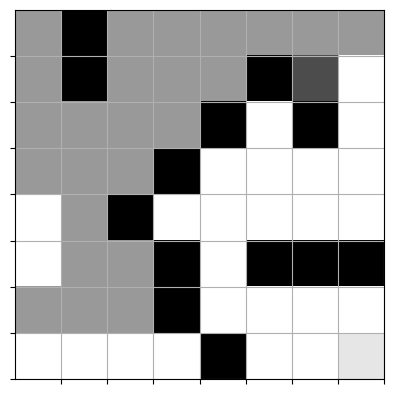

Epoch: 060/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 16 | Win rate: 0.281 | time: 139.4 seconds
   lose | Epoch Reward: -32.00999999999999 | ldlRllrlulduuuruUUllrrUlUuuUUullrdurudduulUUldrudrRurUuulrUdrDlrurDdlrdRudRllLdrUlllUuduRrRlRuRudRldlRddrlRlurUrUdudrUUlRuurdrdludrrdduDllRruDrR


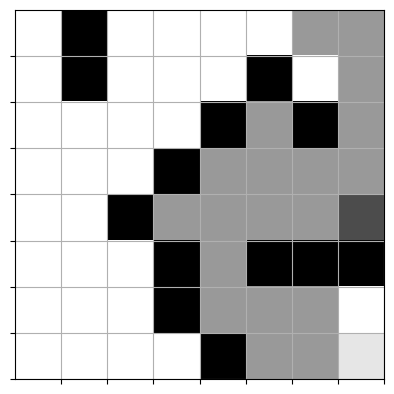

Epoch: 061/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 16 | Win rate: 0.281 | time: 142.5 seconds
   lose | Epoch Reward: -32.19999999999999 | ruruudlldUDLrurLdLLdlLLuDrdrddDlLdrlLuLrLLrllulllLllRrRRRRRrullrRdrRuuRRldlUUuldUldlUlludDuDruulurRddulRrulurRDudlRdRRuruurRdddrrddrdludlDlDullDDDlrrurDru


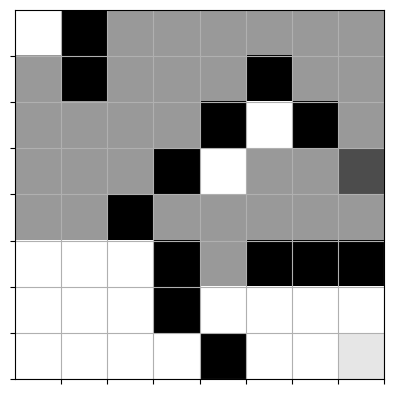

Epoch: 062/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 16 | Win rate: 0.250 | time: 145.5 seconds
   lose | Epoch Reward: -32.12999999999998 | luLlRDLuLluLduLLdLruruldluLLurLurLlrludLlurdDdLluuulurruUllduudUlrullRdUrdLuLrLLLLlLDDlurlruUlrUllulDrurrdluluDldlddrlLLurdrdddlUdUrulrrlllrluDdlDu


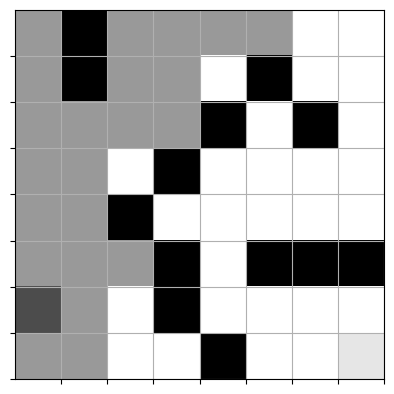

Epoch: 063/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 16 | Win rate: 0.250 | time: 148.4 seconds
   lose | Epoch Reward: -32.099999999999994 | DdlrUdUUdludurlRlUDlUurduDUDdDuudDUlUlrUlUruuDlDUurdRrrlurddlruLllldldUdUDruLDLdLldLrLuuDullLrUrlRlluUlurldUdudUuuluUrlddUrlldlurlldUUrdduUlR


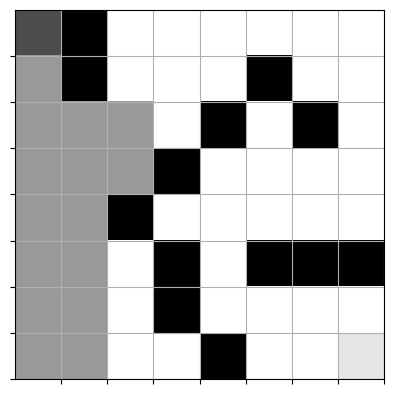

Epoch: 064/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 16 | Win rate: 0.250 | time: 151.5 seconds
   lose | Epoch Reward: -32.08999999999999 | RllRurrudlludlruDuDlDlulRrLLuuldrlUdUuuudUUUddUUrdulluurDdluuduuddrudRURudlRduuuUuUlrluulrDDdDdrlrlLRldllRldluulrluLrUlrdUUUuUruDddudldDRRRddrrrrd


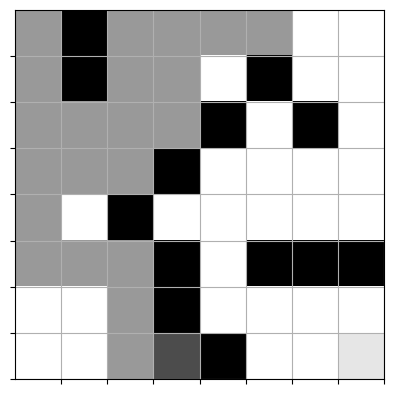

Epoch: 065/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 17 | Win rate: 0.281 | time: 152.8 seconds
   win | Epoch Reward: -8.530000000000001 | LLulrldrDrluddDdurduuuldddrlruuUurrllruRuulrD


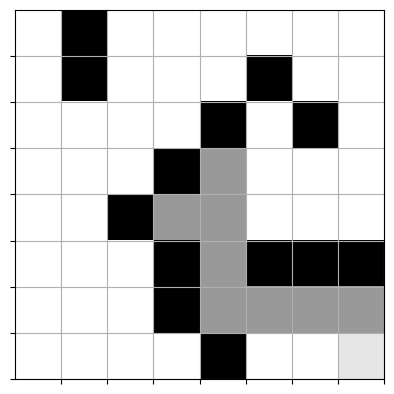

Epoch: 066/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 18 | Win rate: 0.281 | time: 155.0 seconds
   win | Epoch Reward: -19.339999999999993 | DLulRdRDRRdDduDrlDuulDullllduuuRduddrlrdudDrduddlluDDrrrrrlDdrDDulllrDrrdDudDrlldlluldudrdrDldrdRuRD


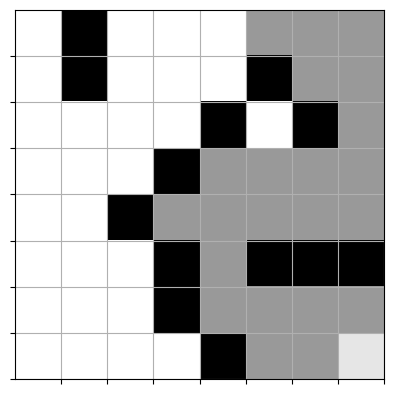

Epoch: 067/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 19 | Win rate: 0.312 | time: 156.3 seconds
   win | Epoch Reward: -4.470000000000001 | lrRRdRuRrRDDlDdDrldDdluDlDrrdRlurDrRRd


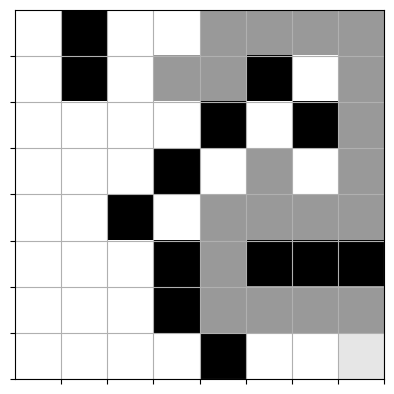

Epoch: 068/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 19 | Win rate: 0.312 | time: 159.3 seconds
   lose | Epoch Reward: -32.05 | udDDdDllDlrDDruDDDDrlRrlRDrDdDluuudlrDRlRlRuLuRlrrlduluDDdluUuRuRRRruRudRRudDrrLlrlduldDDRDrrrldruuulruDuDluddluldululdUlrrDRLLldduDrDDlUuuRduduD


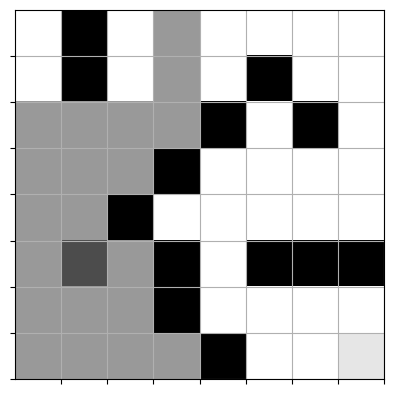

Epoch: 069/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 20 | Win rate: 0.344 | time: 160.2 seconds
   win | Epoch Reward: -1.37 | lrlDllDldDrdR


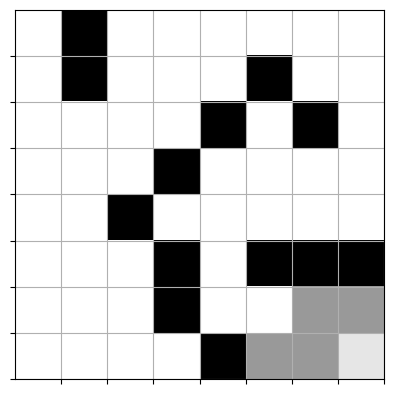

Epoch: 070/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 21 | Win rate: 0.375 | time: 161.3 seconds
   win | Epoch Reward: -3.5300000000000002 | DDDluDlDlrDRulLLuDLlRuDrR


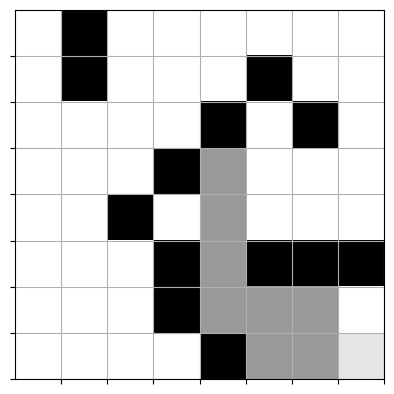

Epoch: 071/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 21 | Win rate: 0.375 | time: 164.1 seconds
   lose | Epoch Reward: -32.15 | luuRlrlrlddududuRrRlrlrLldDdDurddRldruRRRlRRlRlrdRDdllduLURDDlrDDurDlUulRudDrdRdDDduluurruldDulrLrUrdlDDdllurlrRlulrDddLLLuurLLLdddUurrdd


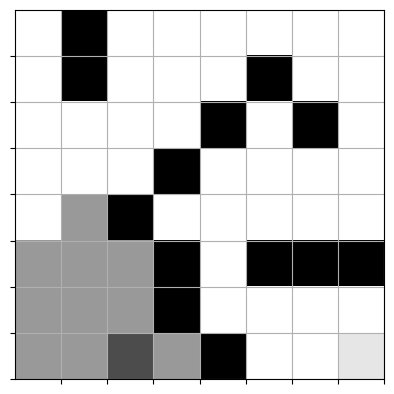

Epoch: 072/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 22 | Win rate: 0.406 | time: 165.5 seconds
   win | Epoch Reward: -7.519999999999996 | DlDdludlrulDrDdlruUlurlddLDdddddLLdluDdRDlrurD


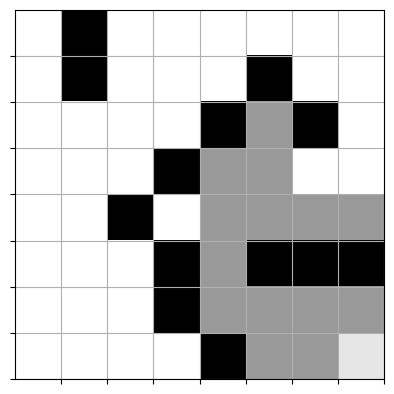

Epoch: 073/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 22 | Win rate: 0.406 | time: 168.3 seconds
   lose | Epoch Reward: -32.230000000000004 | DrrdlRdrduLdRrrRrurDddulduulDlurDlRUllluUdrDDdDlDuRRlRRrurulDurlDDllllduUUrDdulRDdrurrLdlrrrdldurddrrulrurDDuuruulLdudululudRRRrDDlUuDurrld


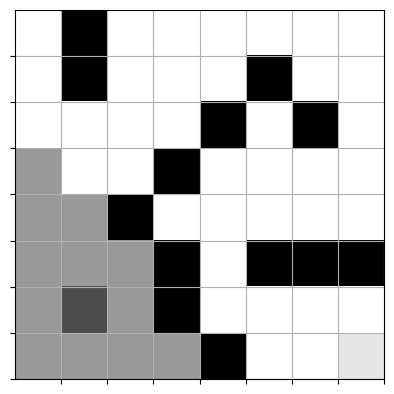

Epoch: 074/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 22 | Win rate: 0.375 | time: 171.3 seconds
   lose | Epoch Reward: -32.07 | dlRulldlRRrrDdduLruludRDDDDrDllRllUdruudDuruldrddrrrullUddlUrdUDrlRuddrurlrDrldlRdrRrRRDrDDrulUlrdlUUDrllddduldrlRuRuudurDlDrurRdldRdRr


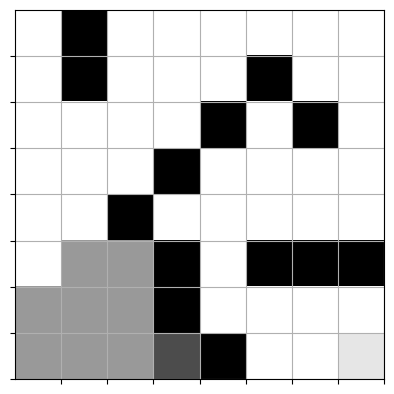

Epoch: 075/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.406 | time: 172.7 seconds
   win | Epoch Reward: -7.729999999999997 | RuduuDudrrrrurdldrlRdlrllllllllDrdlruDruDDrrrd


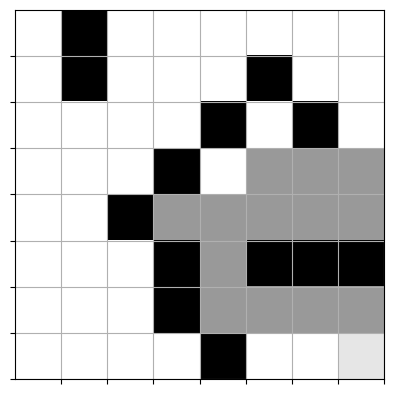

Epoch: 076/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.406 | time: 175.8 seconds
   lose | Epoch Reward: -32.129999999999995 | RrRulUUlduuddrDlrRrDlDlrrldrlRRRRRdRlllldDdulRrlldRruDDuDrddLlurRlRrlrdurdudDddulUrDlDrRDldRurllduuuDdlRrlrururudurddlulDuldludulUduudrllluddDrDlrR


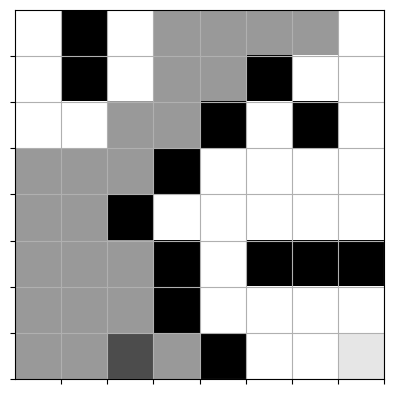

Epoch: 077/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.375 | time: 178.8 seconds
   lose | Epoch Reward: -32.14 | dLlRRrRuRdRdlRRLdldlduddLLLLuulrLUddUuuruldlduUUuuUUUudUlrllUdLulrrLluDrlDurUUrUUUUUuldllUlurrUlddUrUurldUUUuUldrulrldldrrlrlDdlLrllUUuuUUuUUU


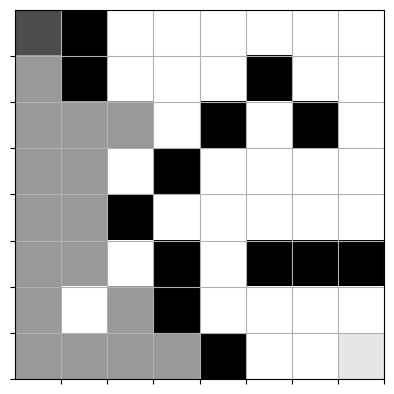

Epoch: 078/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.375 | time: 181.8 seconds
   lose | Epoch Reward: -32.019999999999996 | LrRdrddrRrllRrldRrlRllulRlrldulRuDuDdLulUdllrurlrrdduDLRulRruUlrUUUlUrddldrLUDDrdlLrlldduUrlUlurLrddLLurlDlDdddurdRuuRRRuuddRrdDlluDrLRLulr


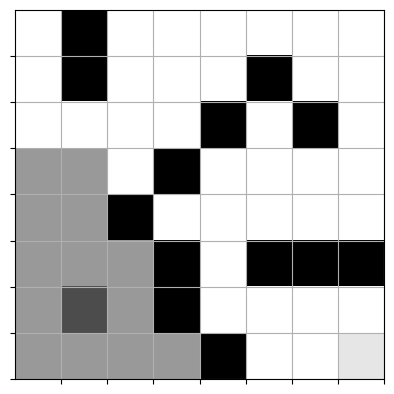

Epoch: 079/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.375 | time: 184.7 seconds
   lose | Epoch Reward: -32.07 | rUuUrUUlduRuUdRlRRRddRRlrddRduUrllRuduudurUlruurddurrldRrrRduuuRRrdullRrlRDulRrdDllLudrrdudlrRuruuudulludrRrUdUrDrrulRDrDuddruDurDlRuul


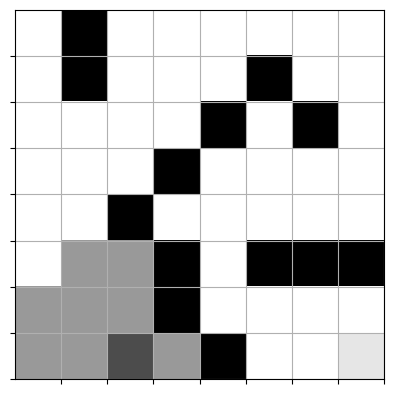

Epoch: 080/999 | Loss: 0.0019 | Episodes: 1000 | Win count: 23 | Win rate: 0.344 | time: 187.9 seconds
   lose | Epoch Reward: -32.00999999999999 | rLdllurLrdlrLUUluUrUrUrruDllDDDlldLurURuldluUrldddururdLlrLlrLDdlllrrlUllUUrrlrldluUUDrlduddUUruluruDrdUrdlruLdlrrUdURruldrrLuuruRdldruDRlRdrrlR


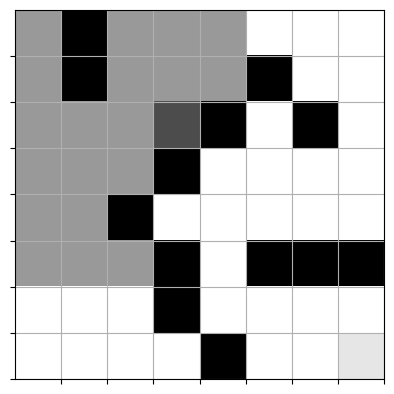

Epoch: 081/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 23 | Win rate: 0.312 | time: 190.9 seconds
   lose | Epoch Reward: -32.129999999999995 | lldullrddlrudllluududlDDlRrDRdRlduudRdRrDDrDDdDlRdudDdldluDUlURrdDDdlrldrlRrlrDDurrDduldDlluDdLrLuUlRluluDDRurrduRRuudulDlrrLulllLdrrUuUdUlRlruDDrl


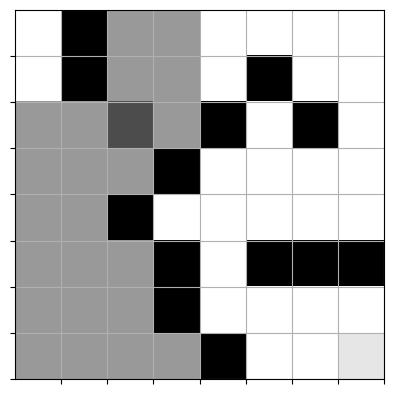

Epoch: 082/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 24 | Win rate: 0.312 | time: 192.0 seconds
   win | Epoch Reward: -1.5300000000000002 | udrldDuldldRuudRR


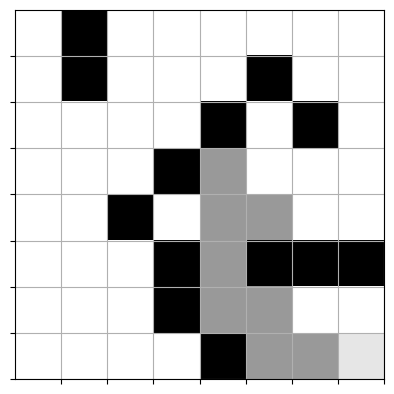

Epoch: 083/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 24 | Win rate: 0.312 | time: 195.2 seconds
   lose | Epoch Reward: -32.15999999999998 | uURrduDdRdUUUrUdUUlrdlulrruDdduudlddlduulddRduudDdlldlrUUuurrurdrlrRluudrRuRlRRrDDllUDuurDrlddllLLdLUDdUDdRdudlRrRuulldRdRrldRudlllRDdRdlRLLRrDDDrldrDlld


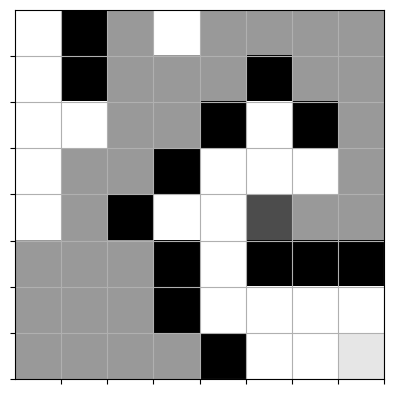

Epoch: 084/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.344 | time: 195.9 seconds
   win | Epoch Reward: 0.5 | ddR


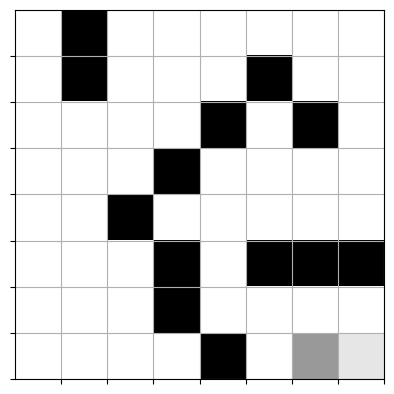

Epoch: 085/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.344 | time: 199.0 seconds
   lose | Epoch Reward: -32.04999999999999 | lrdldRrDulduDrudRdlRRRldRuDrllDrRlrRlRRRRlddlrrluUUUddudDDduDldLdRuudrrllRruldUUrRRdRRrDdDuuDrUUdllUrDrldurRrlLduluLuUldldlrRlRuRllllduuRRddLlrrl


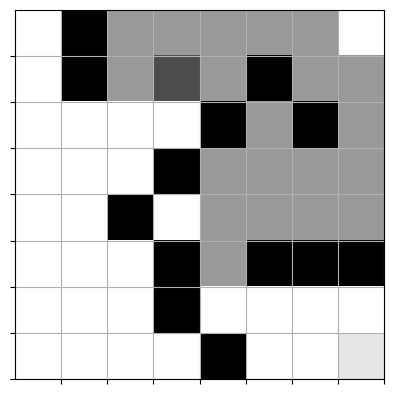

Epoch: 086/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.344 | time: 202.1 seconds
   lose | Epoch Reward: -32.06 | uuDlDlRdRrduDudDLulrruuRRrRlurluDDlDDLuDDUulruRRuldRRdRdRrldrRllduuuDruDDRrRrRuRuLRLrDllDduRdRDdDdrluUUrDDDDrlddllrrrRlRlldrurlllrdddrLuDrlr


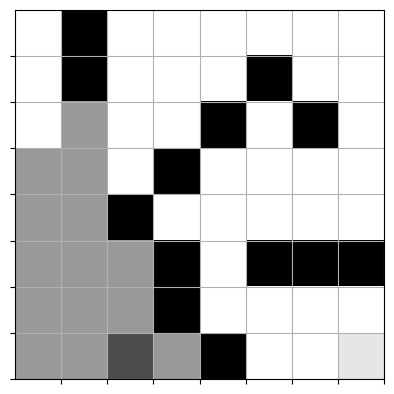

Epoch: 087/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.344 | time: 205.4 seconds
   lose | Epoch Reward: -32.18 | dluuuuRduLuldddUlddURurlRdRuDRlLDUdlrUurDDrlLuLllDLdrUrLLUdlllrRdUdrLDldUDdUdldRddUddrLurDLldUdudUdUUruRrRurdRdldlRudDrdurDDrLdDDdDuDDDrlurDDdd


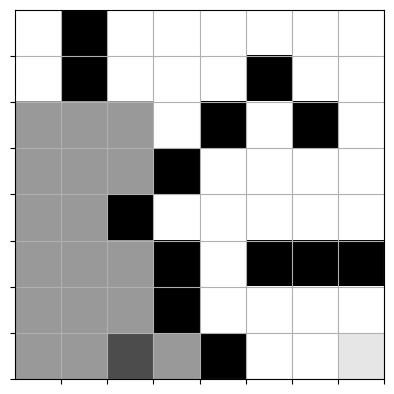

Epoch: 088/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.344 | time: 208.4 seconds
   lose | Epoch Reward: -32.15 | lduDddddulrludDDlurrDUddddUruDlDrrrdRRrlrllUlDdldllDruDUlurRdrDDDrllUdUdruuDduDdDDdDudDrddDlrDuDduuuDrdDdDlrLdrLudrldLULDrUuDuDldrUDlUDUD


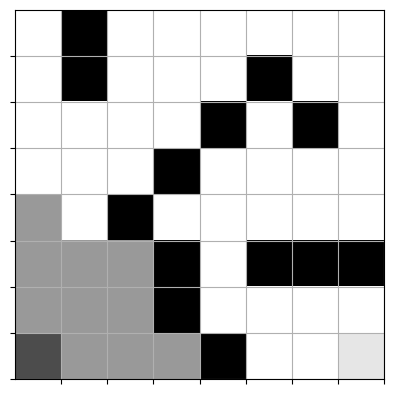

Epoch: 089/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 25 | Win rate: 0.312 | time: 211.7 seconds
   lose | Epoch Reward: -32.099999999999994 | DludDluulrDLlrldddDLurlrDDuududdrlrUllldrrDdlUURUlRUUldrDlulrUddldurlrDdrudldUuuDuDDuDDUdrdddurrdrulDdDrlrDddDDDDDddlUrdrlruludRrUurDDDuudlUl


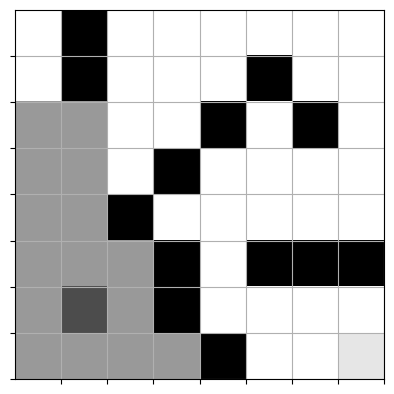

Epoch: 090/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 26 | Win rate: 0.312 | time: 212.7 seconds
   win | Epoch Reward: -0.9500000000000002 | rUDdrDddrldrR


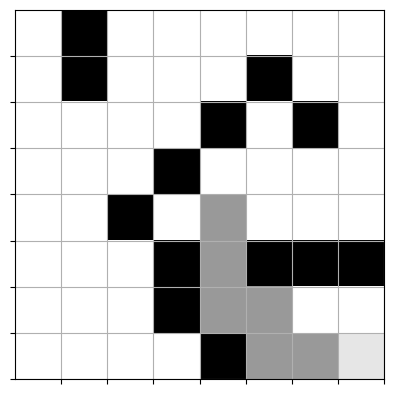

Epoch: 091/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 26 | Win rate: 0.312 | time: 215.8 seconds
   lose | Epoch Reward: -32.03 | lRurllrRDrrDDlrlDluDrrDluDrrudRRRrruuRudludrRrDDdrRdrrlrdUdDDlrDdrDDlDrDDdrUlldrUUlRrDDlrDdrrDlDDuulDdDrDdDddURudrdRdRlRrRlRuDRdDDDDdl


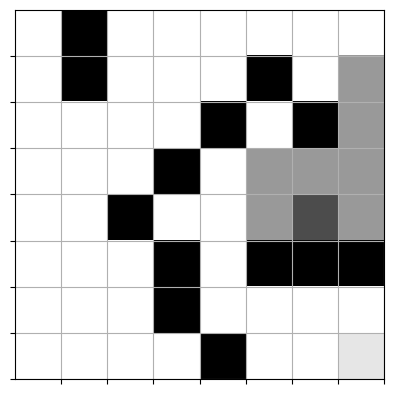

Epoch: 092/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.344 | time: 216.6 seconds
   win | Epoch Reward: 0.88 | rDRr


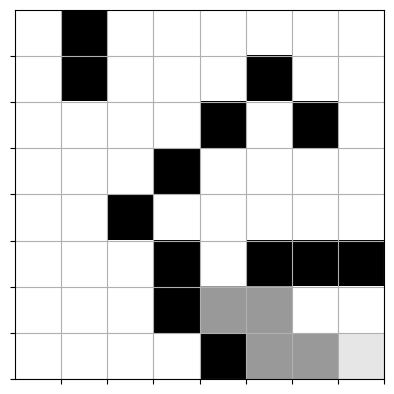

Epoch: 093/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.344 | time: 219.9 seconds
   lose | Epoch Reward: -32.16999999999999 | DDDlLrLLlLrDrrlluuDudDdlurururrlUdduduldRRuDurUrrUdluuDLuldrlrLUUrurDLdurluLdUluddlRlDulUUldUuUrrLrRdruLdluuLLuLlLdLrrLrLRrLrLRLruRddUduuuUrlrUUuURD


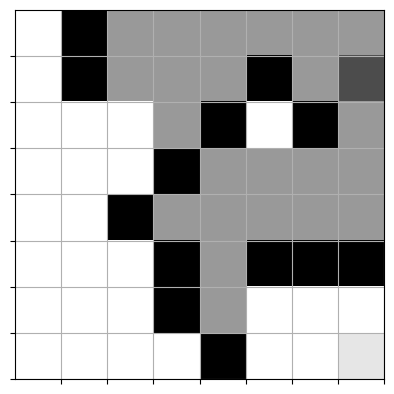

Epoch: 094/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.344 | time: 223.2 seconds
   lose | Epoch Reward: -32.00999999999999 | RRddlRlRddrdLRLrLdLddlrlRdLuuDRLRLlRldRrrrUUuUduddDdlddDDDudRuLdrdlldduDdddlLLrrLLllrlrDdRuurrdDRlddUlduldrLLrdLrurLdLuuuDLLRRrlRrRludRUuUulRuUd


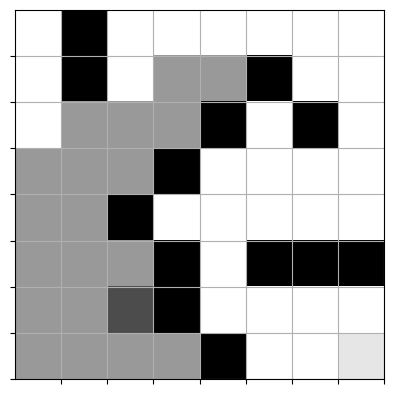

Epoch: 095/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.344 | time: 226.7 seconds
   lose | Epoch Reward: -32.109999999999985 | LuruLLLduddldUdrlUUrrllRrrUUlUuurrrlDudlUDdrrDuLLLULRruRuRRRlRrDluDllULddUUruLrlruLlLDrDdDdDUdduLDDurrdlrrLDrLuudrdLlUUlulUldduuUUUuDDrDLdDudUDllRUddruUluuLr


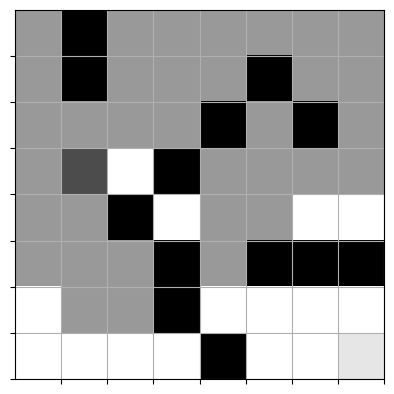

Epoch: 096/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.344 | time: 230.0 seconds
   lose | Epoch Reward: -32.099999999999994 | UrUrlrUllUlUdRDUDrudLddRdlUUddllDRuulUdrUUDruDuLRdudRruLlUrUrrUUluuUdldUuUddudldrluUUrlldudrudRRrrdldudlUlrduUdrlluudRDdRllRRRRulrldUrdlulUUU


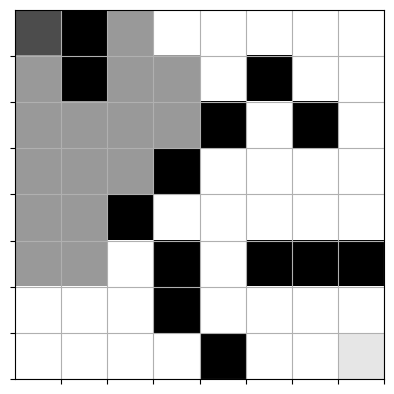

Epoch: 097/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.312 | time: 233.2 seconds
   lose | Epoch Reward: -32.099999999999994 | lUdUuUUUdUlUruUuUuuRRrruUlUUlUldrlurruUUllluUUuullUdUUUldlUluUUrDDDdulruUulUuldlUduuUUrUrRRRRRluUddrrDUrlDUDdlruURRdUdUDdUDrdUrUlUuUluUUrlddU


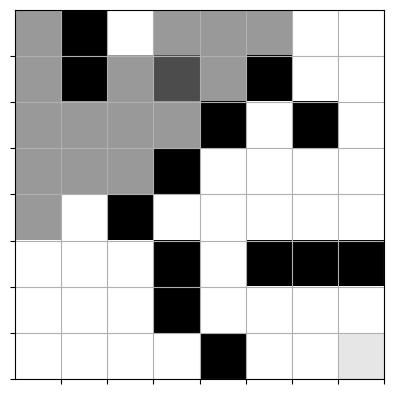

Epoch: 098/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 27 | Win rate: 0.281 | time: 236.4 seconds
   lose | Epoch Reward: -32.059999999999995 | rUUUUluUrUUduuuRdrdlluuRrddruudRdlRlRRlRRruurdUlrrUUUUrUrruDLllrdrRdurRRRuRDduRUrrUdUUldrLULRRlruRlrlrrulrurrurudrlrLulRRrRRlRllurRRddulrrdr


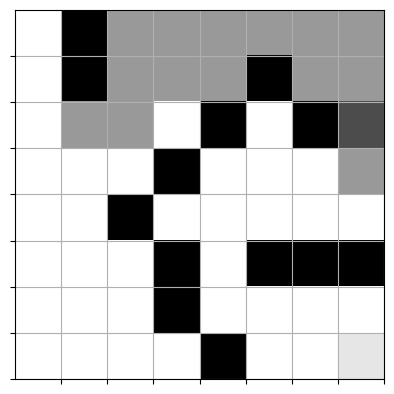

Epoch: 099/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 28 | Win rate: 0.281 | time: 237.5 seconds
   win | Epoch Reward: -0.7400000000000002 | lrlUrDrdRDlRR


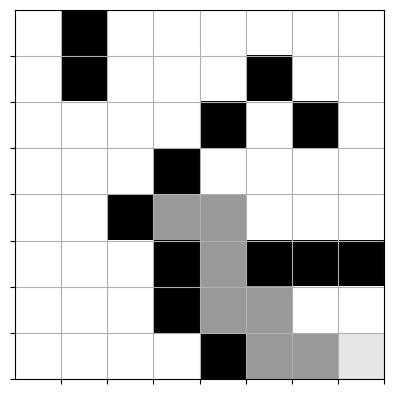

Epoch: 100/999 | Loss: 0.0018 | Episodes: 1000 | Win count: 28 | Win rate: 0.281 | time: 240.8 seconds
   lose | Epoch Reward: -32.14 | RrlUUdrrdduuurdullrUUrlrRRRruUdlrUdluUddllRdruUrDrrulUrluRrRLulUUuuUUUdUUrUUUuddUUdUurudDulrLlurdululllUlUUUUrdlUududUrlUruluUUUUlUluUurUUUUlu


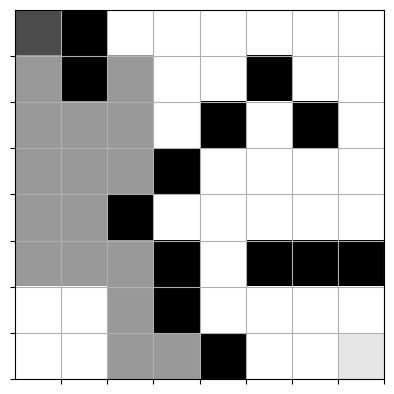

Epoch: 101/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 29 | Win rate: 0.281 | time: 244.1 seconds
   win | Epoch Reward: -25.829999999999984 | dudRldRrdrRlRdlDuduDurRRRRRudulrrDDDDuRRrRrrdlRDruDUDrluDDuDrDuDldRuDRRrdlrRlRlRDdudrluDDllrDDruRDRdRludUuuludrDLdRlddRdLLudDddRrRD


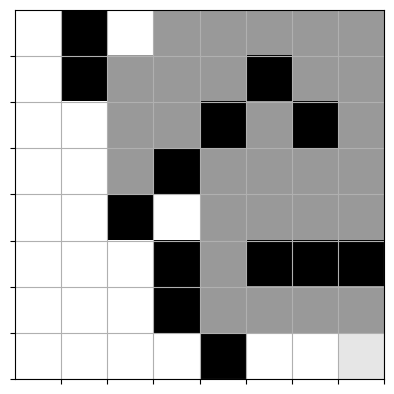

Epoch: 102/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 30 | Win rate: 0.281 | time: 246.0 seconds
   win | Epoch Reward: -11.599999999999994 | ruDDdRdRrRLrUddddUUDuLuddrLuLudlluRlRLlLlRRlRrLrlLudLddldlRrrldR


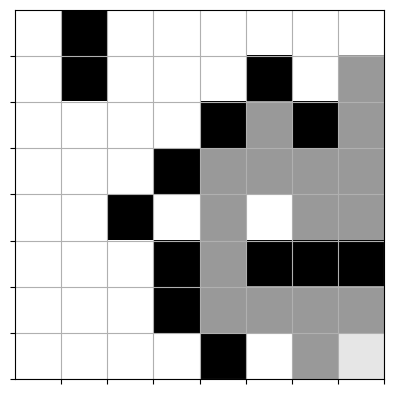

Epoch: 103/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 30 | Win rate: 0.281 | time: 249.5 seconds
   lose | Epoch Reward: -32.19999999999999 | durlUulrrUrlrRdlUUudDuDDllDrDLuDrLdddLUUudrlrUrdUrdduUlDrrDdrRRRdRRrRDDurlUULrLllrUUuDUrUullrDDuurrrDddrDDdUrUlrUlulrRRlllldldlDLLuDuRDRurrdldDddldUlrRRRR


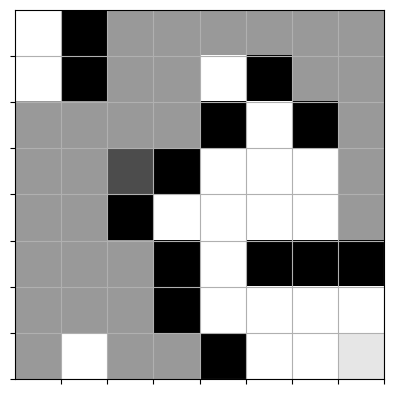

Epoch: 104/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 31 | Win rate: 0.281 | time: 251.4 seconds
   win | Epoch Reward: -9.009999999999996 | udUrudDUuUUuulllRLulLuLrrrRludurrDDDuDdLLLlLLlrDrDddrDDRR


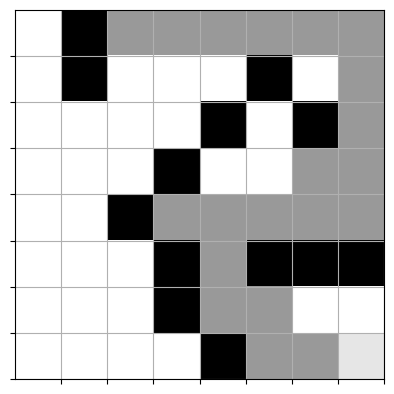

Epoch: 105/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 31 | Win rate: 0.281 | time: 254.7 seconds
   lose | Epoch Reward: -32.219999999999985 | dulllLrLrDuddllllrlrlLrllLLLrLlLdLLLRUurrddLLdlrrLudlLrLLLLLUrllrrrdUluUddUDldlDrRRuuLLUlUuDuddDUDddUURdUdUUuUUdrlUluudUrUldldDulDDDDlDlruLuRRRR


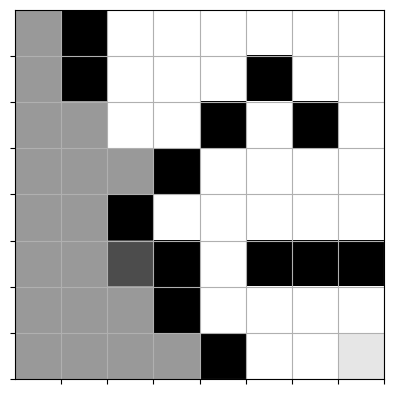

Epoch: 106/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 31 | Win rate: 0.281 | time: 258.1 seconds
   lose | Epoch Reward: -32.16999999999999 | rdrulDUruDDdDluuldurUUlUdUdUludulrrdurrrrlulDDdlrUruUrddLLruDuDLlLLudrLrDudruRlllrDdrdlrUrlUuuldlDlldDDDDldDDrudlrrluDruDrDlulDrurDldRUlduldlrluDdRl


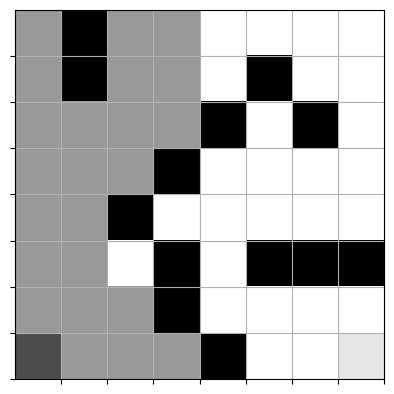

Epoch: 107/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 31 | Win rate: 0.250 | time: 261.5 seconds
   lose | Epoch Reward: -32.03999999999999 | lrrrDduDUuuDRRuUluuUrldRUUlllUUUuUdUUUdldDUudDRuRlRdRuRRuuRRrDDDdllrdruuuluRuRrurlRlRurlldldulDudrurRlRuRdUUllUUrlUuUdurrDluRluldldlRuruRRldudrLLuldRd


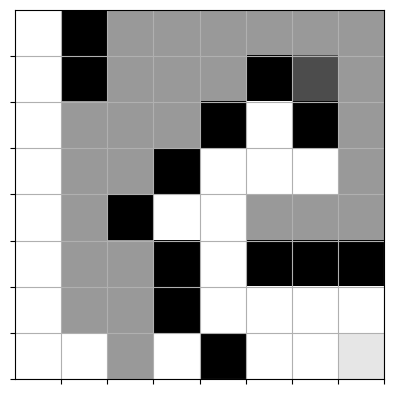

Epoch: 108/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 31 | Win rate: 0.250 | time: 264.9 seconds
   lose | Epoch Reward: -32.25 | lDUdduuuUrddUUuDUlDruDUUdUruUrrDDlDrdrrLdLuLulLdLurDdDdrDrDRDDrDLUdUUUdUlUudlRURrUdUllUrdUUDUrrrUUUUdUlRuRdUldlURuuDUlUUdrUdudurlRlRlRrRrDDuduDrDLrrUl


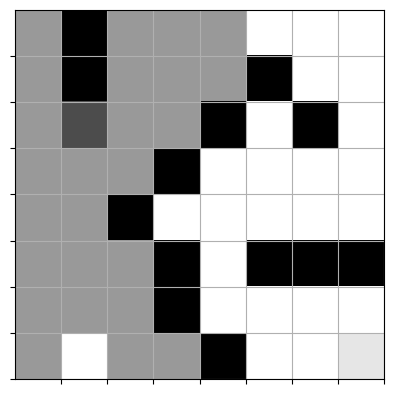

Epoch: 109/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 32 | Win rate: 0.281 | time: 265.9 seconds
   win | Epoch Reward: 1.0 | D


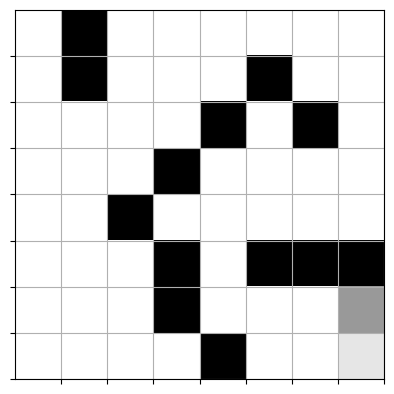

Epoch: 110/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 33 | Win rate: 0.312 | time: 267.2 seconds
   win | Epoch Reward: -2.99 | luduuDluDrdrDulDRDRlRR


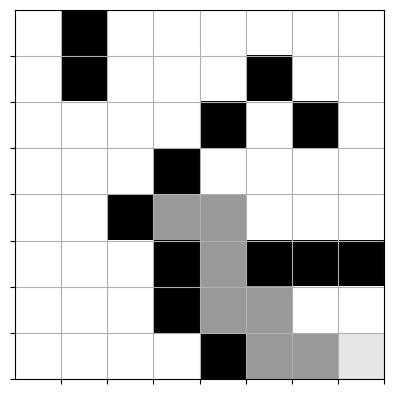

Epoch: 111/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 34 | Win rate: 0.344 | time: 270.0 seconds
   win | Epoch Reward: -18.399999999999984 | uDDldDDurludrRlUDUUUUUdlduDddURruRlrluUURuUdrrDlrruDdDuLrLRRuudrdRlulrRuLrLuRRRuDdUDUDrdDLddLLDdudRlRuDRllRR


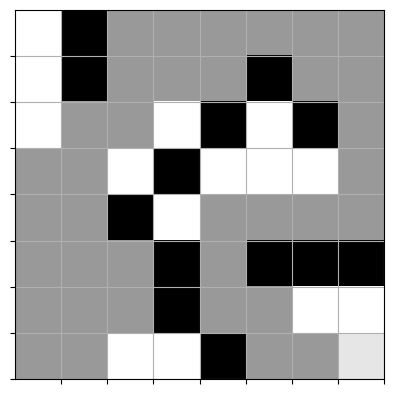

Epoch: 112/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.375 | time: 271.0 seconds
   win | Epoch Reward: 0.45999999999999996 | Ruud


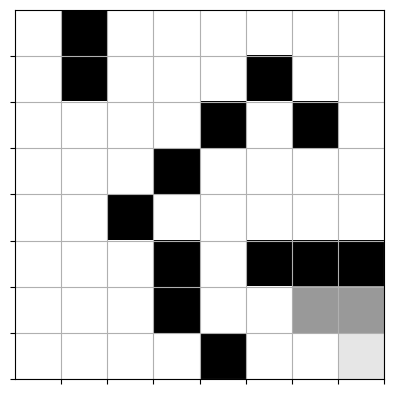

Epoch: 113/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.375 | time: 274.4 seconds
   lose | Epoch Reward: -32.15 | dLLLlLDurudrLrRudRLdRllDRRRdlRDdDLrlRlRrLurrrRRlrRrRRddurDlRdLUdUlrduUlddrRrLurDDDurlldRRruudDudLuddulddRuluRduLLUUUurluurrrulrRduuRRrRdU


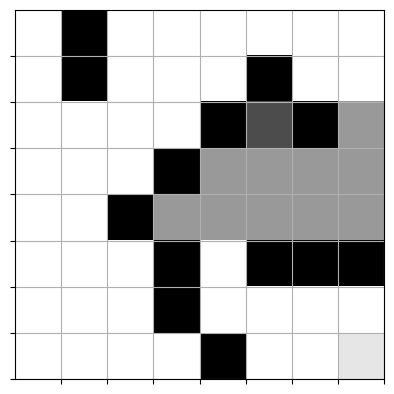

Epoch: 114/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.344 | time: 277.8 seconds
   lose | Epoch Reward: -32.079999999999984 | RrUDluDDuDUlruuruurUUUDUuDlUulRRdrRulDRRdDuDdddDUdUlllrUUdrRRUrrruudluLuRuRLrrLrrduLruLlRRLrdlrLRDDDDLdruddRRlRurDLuuuLDdDlluDDdDDrudUUlUrUduUUUuUdLuRu


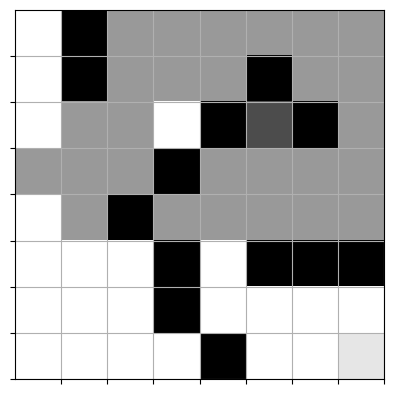

Epoch: 115/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.344 | time: 281.1 seconds
   lose | Epoch Reward: -32.19 | RLRuduRLDLudddluDlddrudlrRRuduDuDDDRDulUdudRuUduruURRuduDDuDDDuddRRRRDlrDdRuRlrRRlRRdDDDuuUruRRddrdUUUulrdRlrrdludDDrlUllUlRRDululRdRdulrr


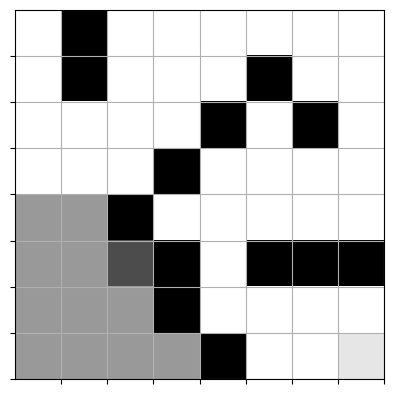

Epoch: 116/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 284.8 seconds
   lose | Epoch Reward: -32.11999999999998 | rrLlLLRddlRRlRlRudULdUrLUdUdulddRdRRRRuRRlULLDLLUuUuRrlURlRrulurdRRRuuRlRdUdrUduUUULUUuURrlRRuRrRRduRRDrldrLduRuurudRuRdLLLdrLudRLulRdrlRlRdurllddURDddU


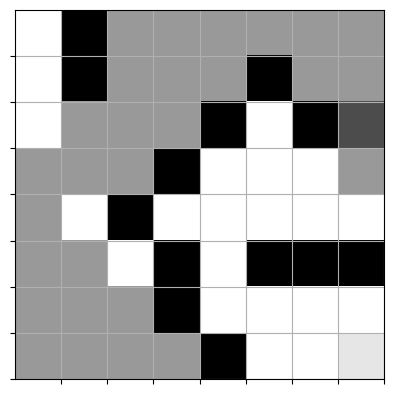

Epoch: 117/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 288.5 seconds
   lose | Epoch Reward: -32.11999999999999 | UlURlRDudlulRluUullUDDrlDRuuuuuRDlRDrrludrlldUUUUUURuuRdDLdldUuDluUlDUUDuDUdrurdULLdllULlLdUduuUUdlruuUDuDuDldddrlDlDduUUDlLLrLLLLudldRldRuDRllRddrdLlRR


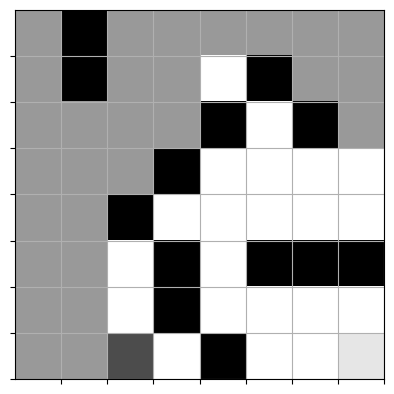

Epoch: 118/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 291.9 seconds
   lose | Epoch Reward: -32.00999999999999 | udldDRudrrrRuuRurDRrruDlruDrLrLDRRRRRluldDlLrlDDdrDdlrRrludDDudlulDddlddllRRuDRrddrudDDDldLrLrLRLRddrlLRurdruDdruDduLUldUUDUDuDddluulDRDRuDDDDul


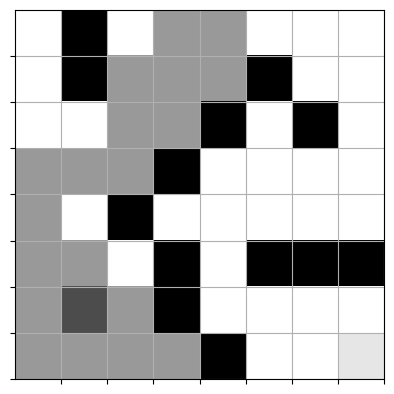

Epoch: 119/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 295.2 seconds
   lose | Epoch Reward: -32.15 | LDdUuudLLlrllLLddlLLLLrUurDdUuDrDudDuDDulrLlrlUldUDRrrllulddrldLdruLdUUdluulDDuDlDDdDluDDdLLLLLLLLrrUdlUUdlldUlduuDdLDDuDDDuluDDdUdldDDdu


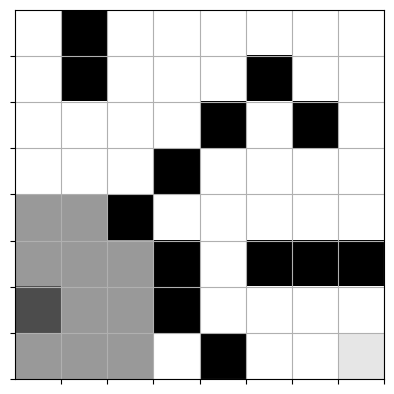

Epoch: 120/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 298.8 seconds
   lose | Epoch Reward: -32.16999999999999 | drurudluldrLLlDLRLuuuRDrLrdddurrDrrlLLLLLLLuldlLrLuullrDLdduLRlRddudRluRdLrLdLrrlrLdllurlDDDrRDDDdrLddLRlRlrdlRLRRrlRLrLrrLrLlddRdUDRLRLuDrdLlRuDDDr


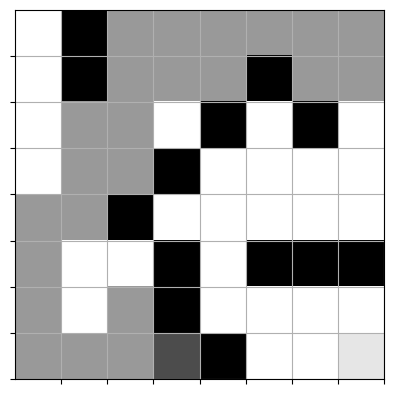

Epoch: 121/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 35 | Win rate: 0.312 | time: 302.4 seconds
   lose | Epoch Reward: -32.019999999999996 | DDDlDrDDulDdUDUlRrduDurulDullRdDrUDdUDUrDUdUrddULdDDlDrRdRLRrrluDRduDrDdLlRlrUlrrrDlldRRRdruUUuDlrllRRdrDDudDDDdrDlDRDLlRRrLLRlDdllDDDDlDur


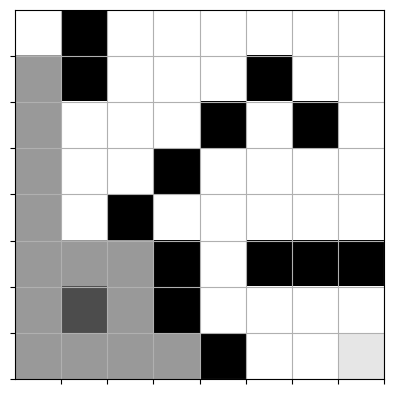

Epoch: 122/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 36 | Win rate: 0.312 | time: 304.4 seconds
   win | Epoch Reward: -11.859999999999998 | rDDDDDrDuudUDUDLLDlrDdLuDLulruuDdDdLudldruDDdDDDDluDuDuddDRR


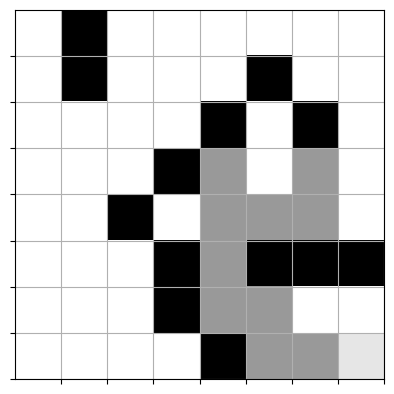

Epoch: 123/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 37 | Win rate: 0.344 | time: 306.4 seconds
   win | Epoch Reward: -9.189999999999998 | RrDRRdrRRRRrDulrDDDDruDdLDDdurlldLdDRlrLrLuDRLRurRD


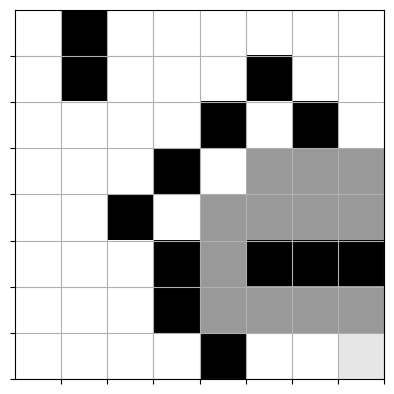

Epoch: 124/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 37 | Win rate: 0.312 | time: 309.9 seconds
   lose | Epoch Reward: -32.129999999999995 | duDlDdrruUURldDrDDrDlRdRRlLDrudLLuDlDlDrDDddUddRRDDuDrrrrdUUdrruDrlUurdruddDDruduLLLluuRrudUlUuDdDdDrdRudldlUrUrdRRRrdDrluDrrDdDduUUUddUUuulUruDDru


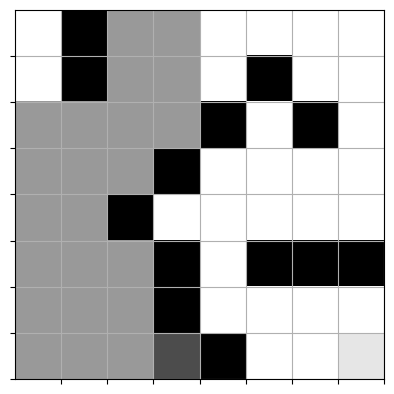

Epoch: 125/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 38 | Win rate: 0.344 | time: 311.5 seconds
   win | Epoch Reward: -2.3100000000000005 | RRRdurulDDlrLdLLDduDRrRldR


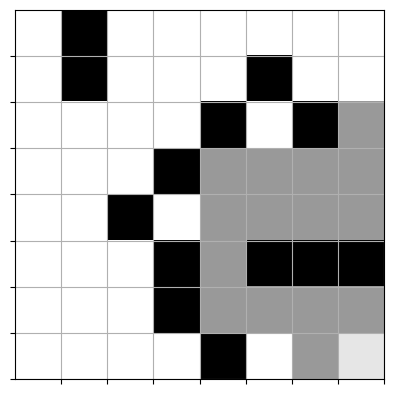

Epoch: 126/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 39 | Win rate: 0.375 | time: 312.5 seconds
   win | Epoch Reward: 0.5 | rrD


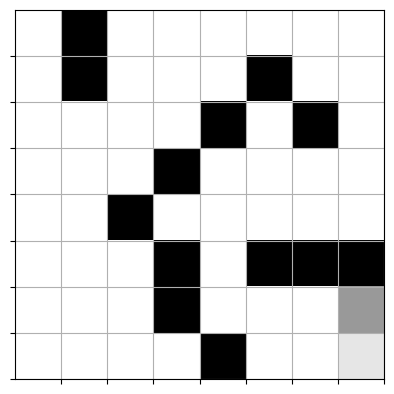

Epoch: 127/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 39 | Win rate: 0.375 | time: 316.0 seconds
   lose | Epoch Reward: -32.01 | UURlUulUdddulDuuDLLRdudDDuulrDRDrDdDDrLulLdduDrrrlldUruDLrUrruDuDLLdlLluuRRRRuudlUUudDDDDdddURddlRuLlrLDLuDddLLrLLRRRLdlUDDDDDDDurLuRuuRrDlRDRLu


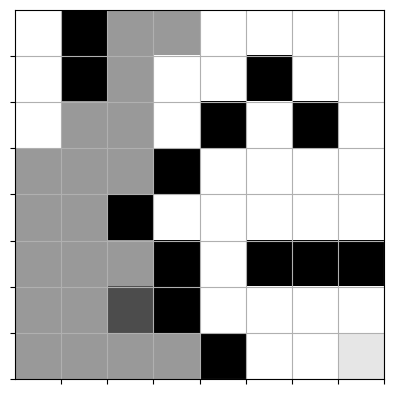

Epoch: 128/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 40 | Win rate: 0.406 | time: 317.1 seconds
   win | Epoch Reward: 0.63 | rdlRR


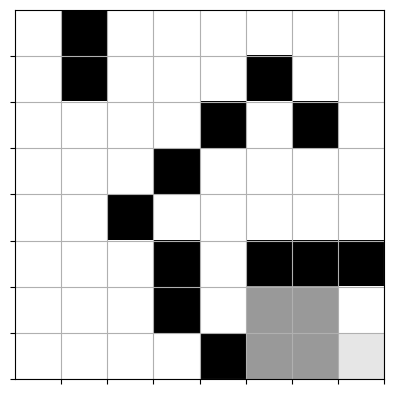

Epoch: 129/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 41 | Win rate: 0.438 | time: 319.3 seconds
   win | Epoch Reward: -11.809999999999995 | LLLLurLdRuUUUddDdurDddluuluddLDLLLLuuduudDluudDrrDdldRuRRrlduRuD


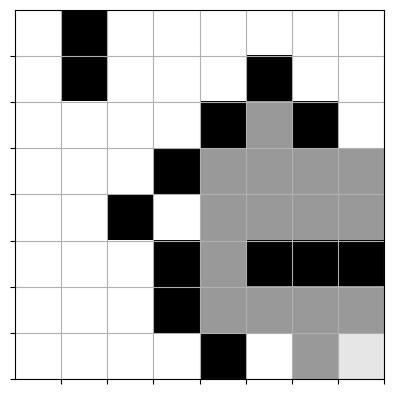

Epoch: 130/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 41 | Win rate: 0.438 | time: 322.8 seconds
   lose | Epoch Reward: -32.059999999999995 | DrUudDrUDddRRdRlUDrDDLDdLlrDDdDdudRdlUlduDUUrUrUuDDdllDuDDLDDruDLlllrDdDDUDUDUDUluDUDuDDDldLuddrdlUUUdDUullRurlddDdrruDDlrLdUuudluDlrrdulDDD


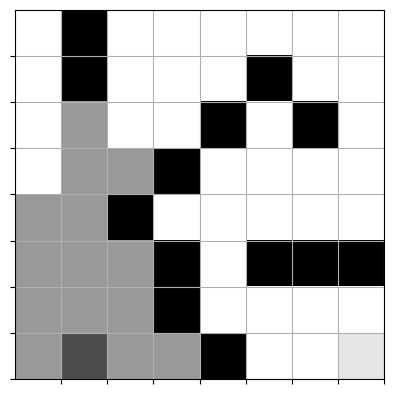

Epoch: 131/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 42 | Win rate: 0.438 | time: 325.2 seconds
   win | Epoch Reward: -12.309999999999992 | DDDudRRduDDdDDuDdLruLdRDDuDDddDLruDuDDDDdDddUlllddlDLLllrlRrRllDRr


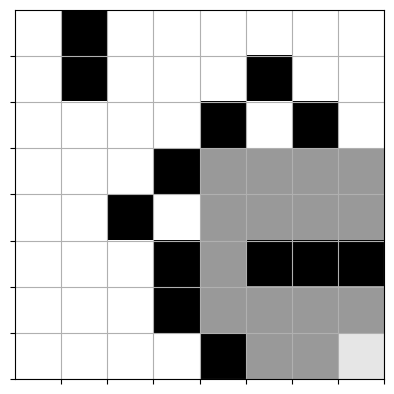

Epoch: 132/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 42 | Win rate: 0.438 | time: 328.8 seconds
   lose | Epoch Reward: -32.12999999999999 | rRllDDDlUdRuRRRRRRRRRUllrruLdldRdrrdRRudRRRRLDdLlrrLlLlRrlRRdRRdrdRuRRrlDDDlUDdllUudUUudulUddDldDlrlRlRdDRRDuRuRddRRrRdRRDDuuuuDLlUrduRRRduRlDUuDuD


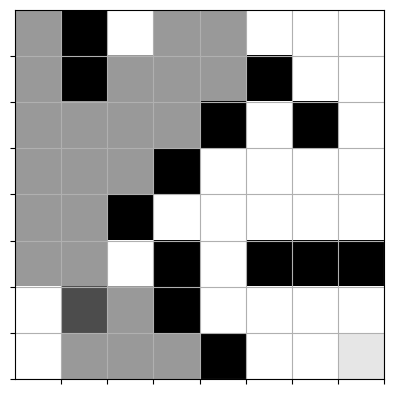

Epoch: 133/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 43 | Win rate: 0.438 | time: 330.1 seconds
   win | Epoch Reward: 0.5100000000000001 | urdDrRRD


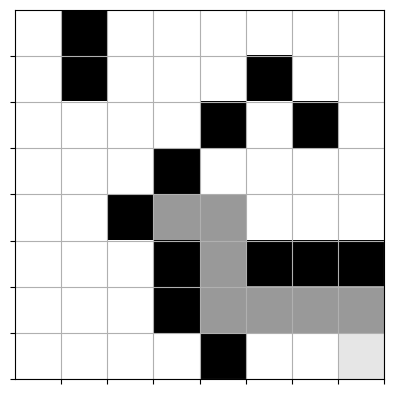

Epoch: 134/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 44 | Win rate: 0.438 | time: 332.7 seconds
   win | Epoch Reward: -17.379999999999992 | dLdRRRuuDRdlRRRdRRuRRdrdUDUlRrlRDRRDDRRuduDRRLLrLDDlDurRudLRdRRlLRlluLLrddLULUUlrDldddRDlRlRR


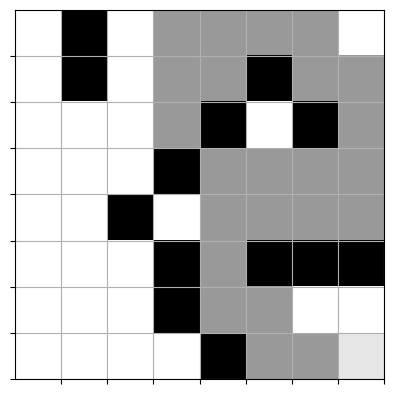

Epoch: 135/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 44 | Win rate: 0.438 | time: 336.5 seconds
   lose | Epoch Reward: -32.18999999999998 | lDDDrUrrlDurlUuUUUUdlUrUruUdrUluUUUrlUUuUuUUuluURDrlDlDDDdDDDDDDDdRDDUUUulUrUUlUUdrurDUDldlRRuddrRRRRldUulUUulURDRlddUuDuDRDRRRuRRRRRdldruDDdDldLrlLUdrlDldRldd


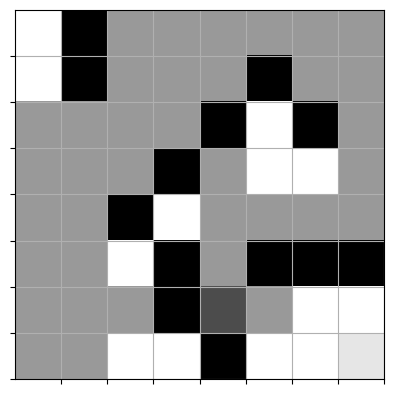

Epoch: 136/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 45 | Win rate: 0.438 | time: 340.0 seconds
   win | Epoch Reward: -29.50999999999999 | RrDUDUddlUdurUUUrdrDUdUrduURrlRRRlRlRLlRRRrurdLlLddURlulUulRRRRRDuDludLLrLlRlRuRuRdddDLdrlrLLRdddUurDUlUUUUdLRLLDDdlulurRLuLLDrLDlrddlRdlRR


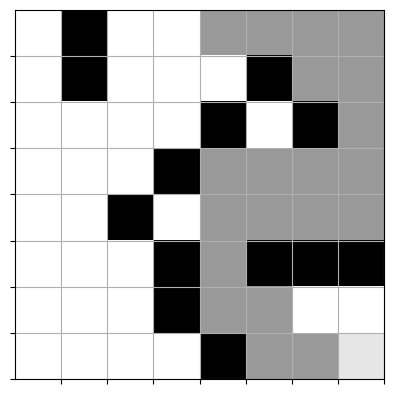

Epoch: 137/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 46 | Win rate: 0.469 | time: 341.2 seconds
   win | Epoch Reward: 0.45999999999999996 | RlRR


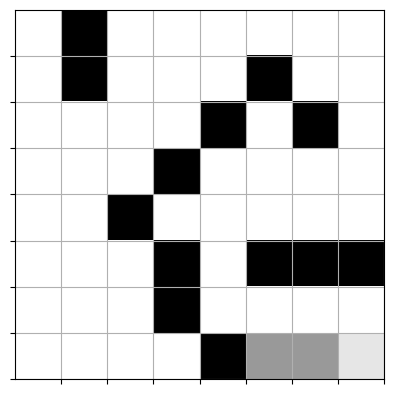

Epoch: 138/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 47 | Win rate: 0.500 | time: 342.5 seconds
   win | Epoch Reward: -0.32000000000000006 | DLLDldRududRr


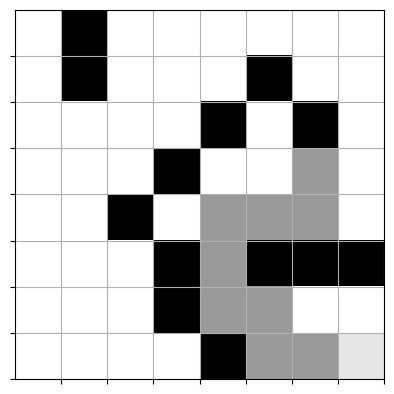

Epoch: 139/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 47 | Win rate: 0.500 | time: 346.0 seconds
   lose | Epoch Reward: -32.14 | lLdLlDDLLurldLdrLRuRLRdLdLLLLrLLurDrlRurLLRruDDlDruDdlLlurdRRduLuLdRRRRDrDDDDDurDDDrlruLRrlLLLrLdLlUrDLDDdLlLLLLLdldrldRuLdRluRDUDllLdLLRRllRR


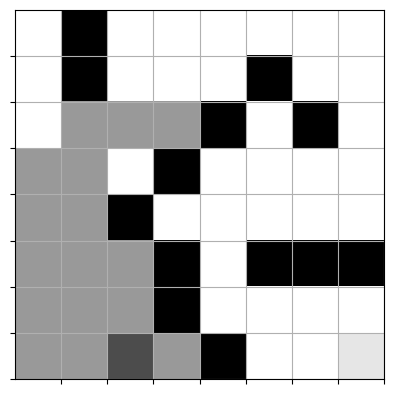

Epoch: 140/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 47 | Win rate: 0.500 | time: 349.5 seconds
   lose | Epoch Reward: -32.19 | RuDDuRrRlrLrLLuRuldrrrDRRRRDrRRDDlDdruRrRRRllldRRuuruuDDdLuUrluDduDlDdRdRLdRdlRrRRDRLLuLddluRRddlrRRRRRuDDDDdRRrRRRlRuRrRulLrdLLDDdDDRrldR


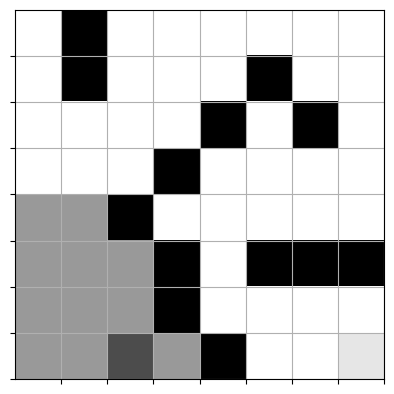

Epoch: 141/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 48 | Win rate: 0.500 | time: 350.9 seconds
   win | Epoch Reward: -2.6100000000000003 | RdLLrldrLLlLdlDDrdDRRrD


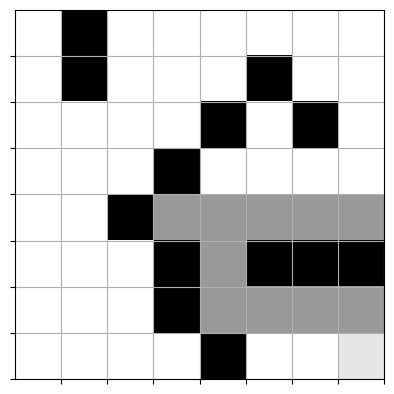

Epoch: 142/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 49 | Win rate: 0.500 | time: 352.3 seconds
   win | Epoch Reward: -0.9000000000000004 | rDuDLLLDDRuurlRRD


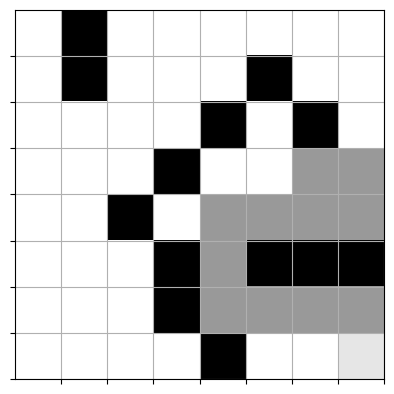

Epoch: 143/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 50 | Win rate: 0.500 | time: 353.5 seconds
   win | Epoch Reward: 0.20999999999999996 | dldRR


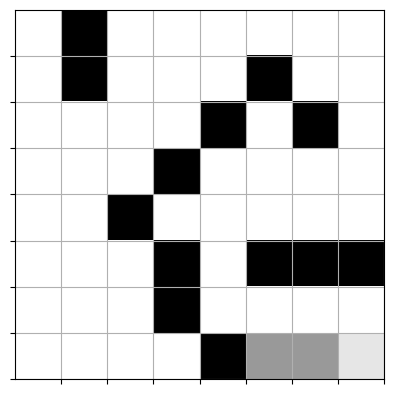

Epoch: 144/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 51 | Win rate: 0.500 | time: 355.0 seconds
   win | Epoch Reward: -3.49 | lddDrlDDDDDuDrDDRDRldrdR


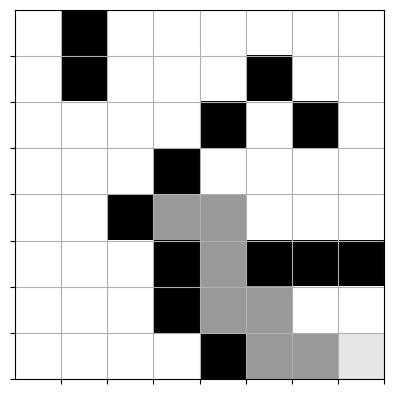

Epoch: 145/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 52 | Win rate: 0.531 | time: 356.8 seconds
   win | Epoch Reward: -5.390000000000001 | RurruRduDuddruDDDDRuDRrRRRLrLLlDDRRuurrD


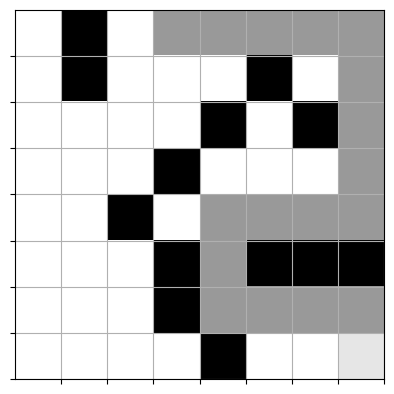

Epoch: 146/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 52 | Win rate: 0.531 | time: 360.5 seconds
   lose | Epoch Reward: -32.15 | dDDUDdRrddruuDrDrDuuDDuDDDdDrdDDDDluDRRDDuuddrDrDldRRRDrllurDLduRDulDuuudDlDDDDDDUuRDDdUrDUDdrdLLLuRdlrRRDDDDDrdrrrDrDdLRdLRllRDDDDdUDuUr


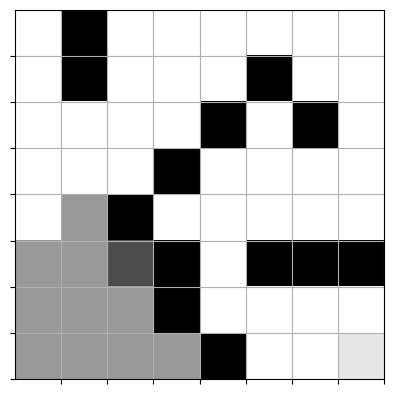

Epoch: 147/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 52 | Win rate: 0.531 | time: 364.2 seconds
   lose | Epoch Reward: -32.19 | RldRRLRLRLRrrdLRRLdLdurDdDUDlrUUUUlRUdDuDdUrDuDLLLLLRRRUULLlLLrLuRlRdDuruURldlRuLduLdduuLuLRLRLRlRrRRuLdudlLurdrdULddLlLuduulrrLruLRLRurlR


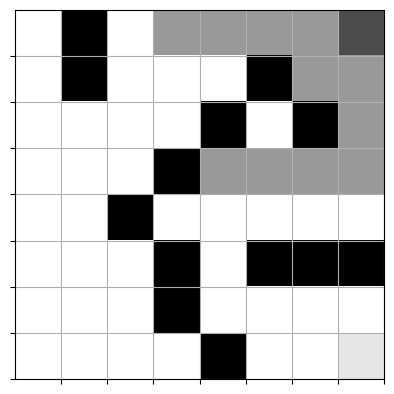

Epoch: 148/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 52 | Win rate: 0.531 | time: 367.8 seconds
   lose | Epoch Reward: -32.059999999999995 | RRrdLrrluLLLdurlulRrdrdRrDrrLRruuldluullLuLdLLLRUrUudLrDDDDldrRRruuLLluruurduDdulrdrLLRRLlRLRdRludRuudLLDdLudLldLLlUrDLUDrdLLdLdLuDLUlullrLL


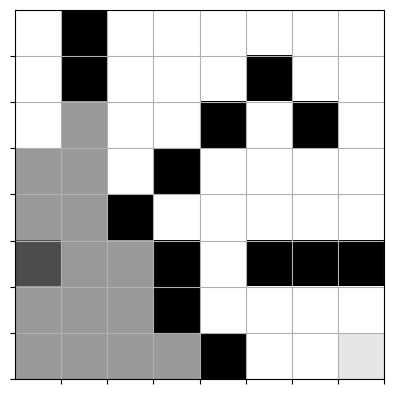

Epoch: 149/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 53 | Win rate: 0.562 | time: 369.3 seconds
   win | Epoch Reward: -0.9800000000000004 | LLrdddLddLLDDdrrDdR


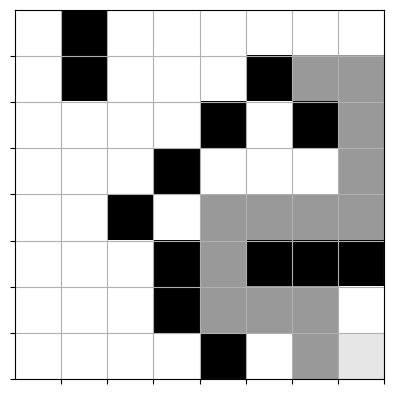

Epoch: 150/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 53 | Win rate: 0.562 | time: 372.9 seconds
   lose | Epoch Reward: -32.19 | DrlDLLLlLLLdLLuDDDrlDrudRRUUruuLLdDrRdrrrdUUUUlrLluLDLLrlduuudDDDDDLrLllruuDLDurDlulULLLLdLLLDDuDdDDldDDDdldrLUDUDlrLdulDrUuuDDruDrUUrUUdU


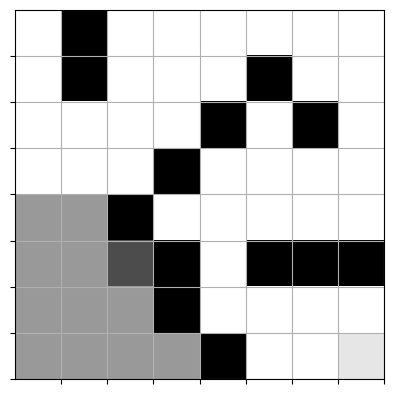

Epoch: 151/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 54 | Win rate: 0.594 | time: 375.1 seconds
   win | Epoch Reward: -10.839999999999996 | LrrrLruLurRrrlRDDDrDlLrLLDulluuRuRllulRrdLRdRlRUulDDLLLrLDDurDRdRr


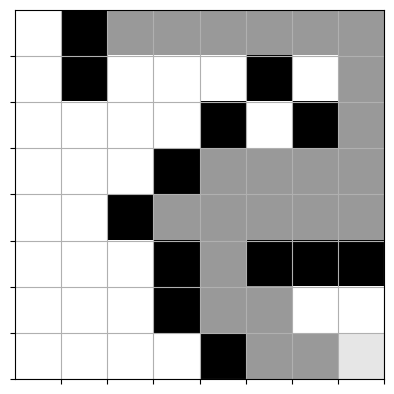

Epoch: 152/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 55 | Win rate: 0.625 | time: 376.5 seconds
   win | Epoch Reward: -0.4900000000000002 | lUurDrrDRDRR


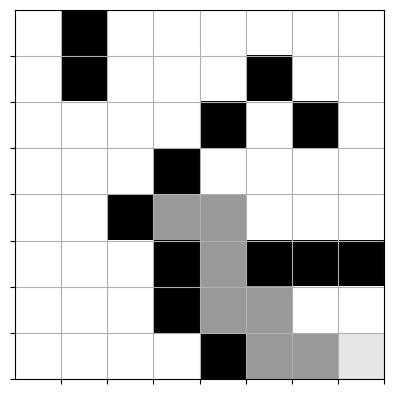

Epoch: 153/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 55 | Win rate: 0.625 | time: 380.5 seconds
   lose | Epoch Reward: -32.17999999999999 | rldLldLdrLurLUlRDLDlrUdUrudUlRuuUUlddUrlUrurUUUUDrrLuurUrRlrRuLDLDrDDudlUuRlRLLrrLLLdlRDlUrRuUdUdUudlDrrrlUlUdUUrdUULUrdLdUUDRRlldlUUdUddlUUdUr


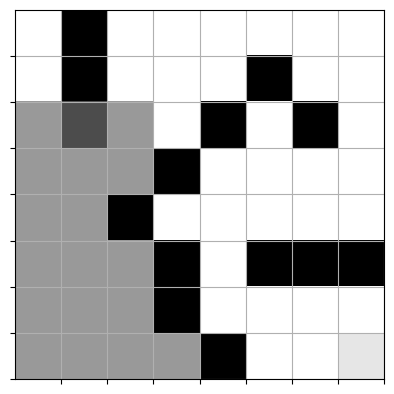

Epoch: 154/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 56 | Win rate: 0.625 | time: 382.2 seconds
   win | Epoch Reward: -2.0600000000000005 | lUDDlDDrlLDulDDDRDRdlllRR


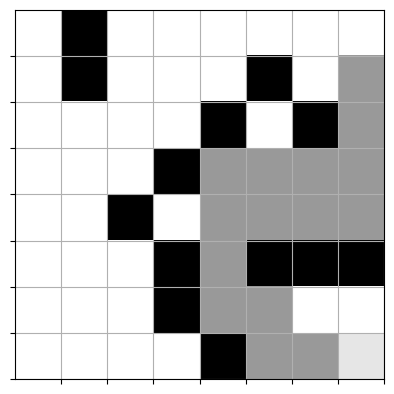

Epoch: 155/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 57 | Win rate: 0.625 | time: 383.4 seconds
   win | Epoch Reward: 0.16999999999999993 | lrlDdR


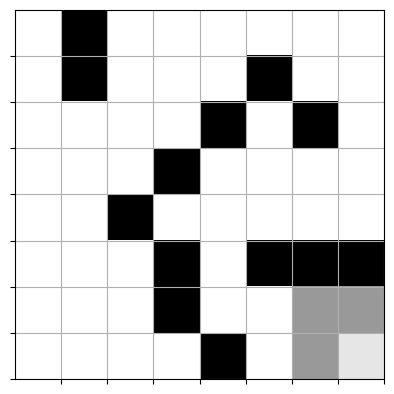

Epoch: 156/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 58 | Win rate: 0.656 | time: 384.8 seconds
   win | Epoch Reward: -0.03000000000000025 | lRldDrDRDRr


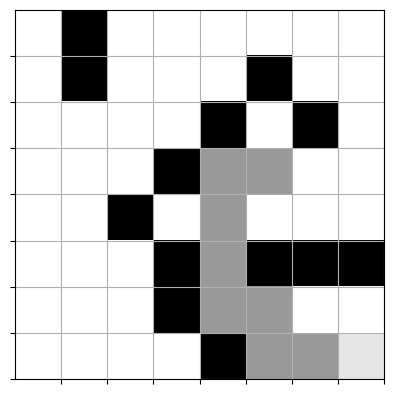

Epoch: 157/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 59 | Win rate: 0.656 | time: 386.2 seconds
   win | Epoch Reward: 0.26 | DlDDdRRRD


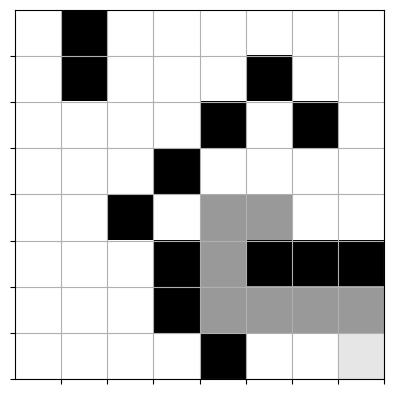

Epoch: 158/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 60 | Win rate: 0.656 | time: 388.0 seconds
   win | Epoch Reward: -3.7300000000000004 | uUdDDuurldrDuDLrLLDlDDRudduRRD


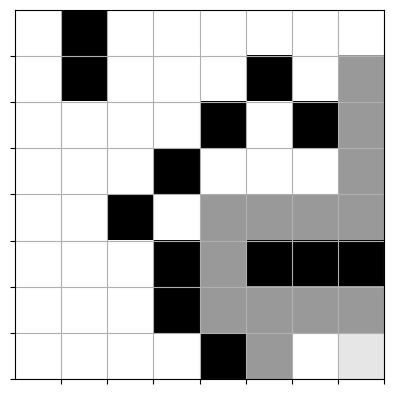

Epoch: 159/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 61 | Win rate: 0.688 | time: 389.5 seconds
   win | Epoch Reward: -0.7000000000000002 | uluDluDRRRuD


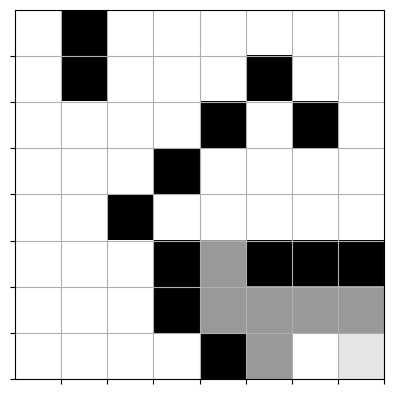

Epoch: 160/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 61 | Win rate: 0.656 | time: 393.3 seconds
   lose | Epoch Reward: -32.11 | UUrRDldLDLLdurdrlrRlRDlRDdDdrDudUUlUUUuUUrudUUUUuUUUuUlRUuUruUruRDuDDDDRrLRuluLRuRuRRUUUUUldLuddLLRRdRRRrRlRrRrdRDDDDDDDDDDruUUdUlRdudlR


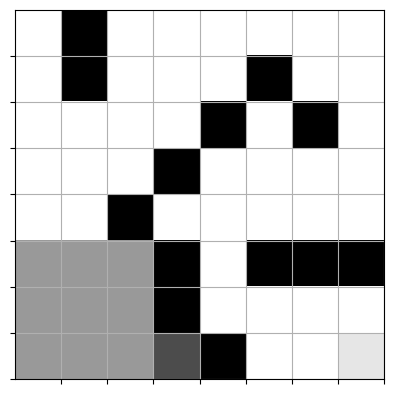

Epoch: 161/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 62 | Win rate: 0.656 | time: 394.9 seconds
   win | Epoch Reward: -1.4000000000000004 | ddRRRRRllrlDlDDRRRD


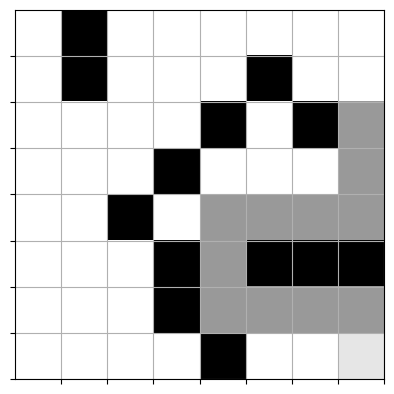

Epoch: 162/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 62 | Win rate: 0.656 | time: 399.1 seconds
   lose | Epoch Reward: -32.00999999999999 | RLlLduDrrrDDrUuDDrDUUlduUdLdUrLLlrRLRlRLRLLrLRLRrLduuDuDdLDDduuRurDDdRRudUuUlUrDUDuuLulRluRLruDurdLuLLLLDRLRRRRdRRRRdRRlLuluulUldURuRDdDudDdDlUU


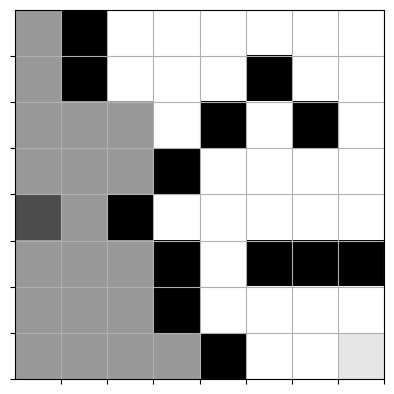

Epoch: 163/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 62 | Win rate: 0.625 | time: 6.72 minutes
   lose | Epoch Reward: -32.21999999999999 | udUUrUUuulrudrULLUUrLLlUUulUdUddUULrLLLLlLLLUUUlUlUUuUUdUrUUlddDDdRurduDUurrdrUurUrlrLLLLLLLLLrLLLUUUddURDuDUDllLLurddLLUrLrldUUUludUrLddUrUUull


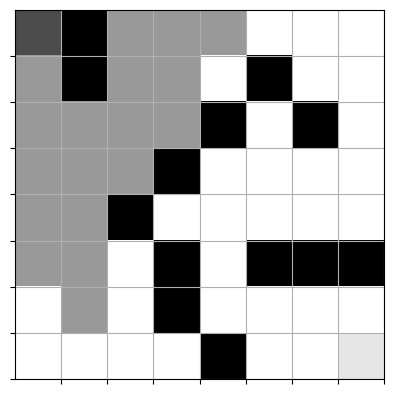

Epoch: 164/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 63 | Win rate: 0.656 | time: 6.77 minutes
   win | Epoch Reward: -15.099999999999994 | RLdrurLLLdudlLuLruLLLrLLlurLUluurLLdlLRuuRdLrLuRRLuLLLLLLLLdLLLLLDDDulDRdduRRD


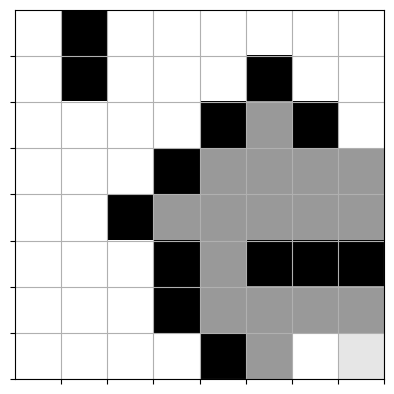

Epoch: 165/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 64 | Win rate: 0.656 | time: 6.79 minutes
   win | Epoch Reward: 0.3799999999999999 | RRuldR


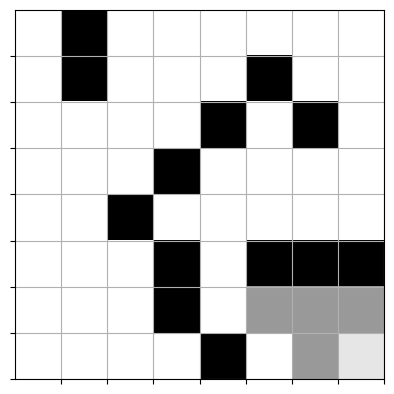

Epoch: 166/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 65 | Win rate: 0.656 | time: 6.81 minutes
   win | Epoch Reward: 1.0 | R


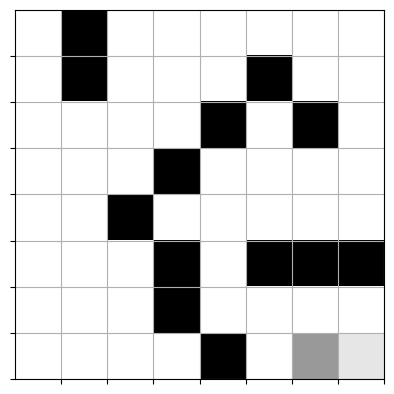

Epoch: 167/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 65 | Win rate: 0.656 | time: 6.87 minutes
   lose | Epoch Reward: -32.14 | UuuUUdDDDDuDDrUDUuruRUldRRRulDlduDDLLLLLdurDrUUUUdrdUDUDUurrDrRUUlUuUuLRdrULLLLLDDDDUuDllUUdUUuUUlULLlLlLLuLLrLRRUdUuUUdUUUUUUUuUUdDurruRRrrLr


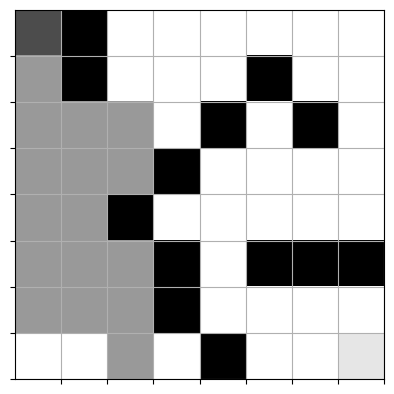

Epoch: 168/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 66 | Win rate: 0.656 | time: 6.92 minutes
   win | Epoch Reward: -11.399999999999977 | rduLdduRRddRdUUUlrluUUUUUrRuRRRrRlldddldUUUurRUUUuUrlrDDdURURRRudDDlRDLLLDDRuRRd


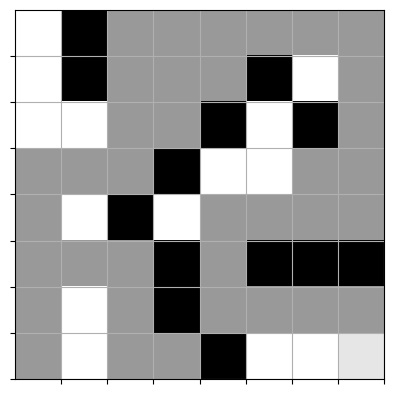

Epoch: 169/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 66 | Win rate: 0.625 | time: 6.99 minutes
   lose | Epoch Reward: -32.07 | lRdudRdRluurDDRDRlrRRRudRlRUUUrdrDDdDDrrDllRRrRRRRRrRuddUUUrUUUluDRUruuDDulrDuuRRulRUuDdDDrDDuurdDDrDDDdDDDDuDUdlLUrDLuDuDuulRuDRlRdDlR


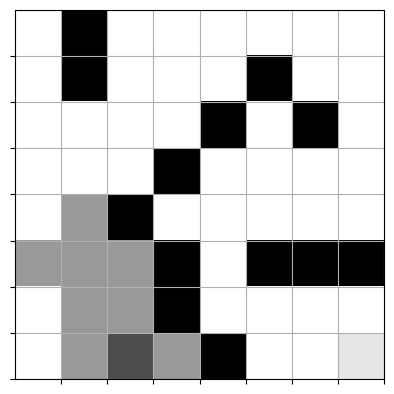

Epoch: 170/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 67 | Win rate: 0.625 | time: 7.02 minutes
   win | Epoch Reward: -2.1500000000000004 | rlRDuDRRRRRuDLLLDDRDRR


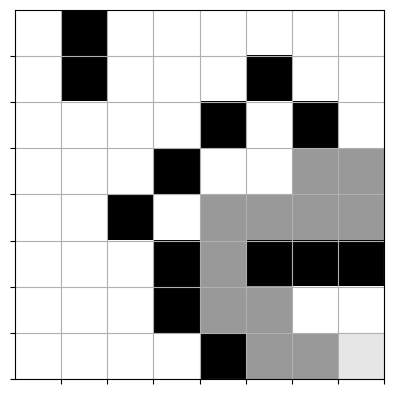

Epoch: 171/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 68 | Win rate: 0.656 | time: 7.05 minutes
   win | Epoch Reward: -0.8600000000000001 | urDldluDDRruldRr


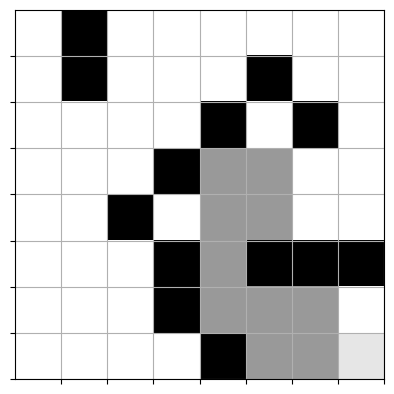

Epoch: 172/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 68 | Win rate: 0.656 | time: 7.12 minutes
   lose | Epoch Reward: -32.099999999999994 | DRuldrRdRlRuLDlllRDrruddRulDlRRRuRRrRRRrRuLRlDuuLuulRuRlllRDDDurlrDDDUrrDudRdUuUUuULRrLRLdLlLLLlUdrRdRlRrLLLuRrLlRRDRrDDRRdRRRRDduLuDRLRLldrR


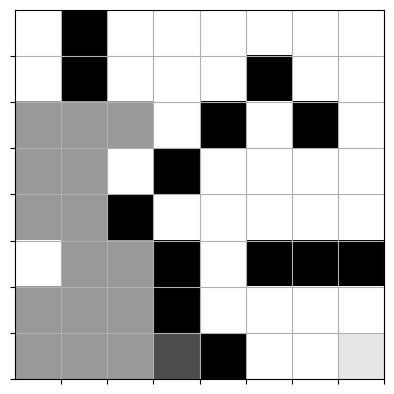

Epoch: 173/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 69 | Win rate: 0.656 | time: 7.14 minutes
   win | Epoch Reward: 0.71 | uRD


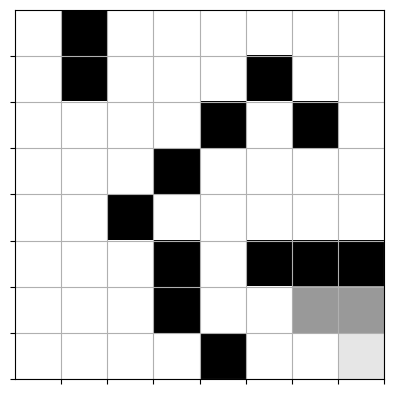

Epoch: 174/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 69 | Win rate: 0.625 | time: 7.21 minutes
   lose | Epoch Reward: -32.169999999999995 | rlRrLrLuLDLLlURDllruUlRdUuURUUUUdDrUDUDuuuDDuDLdlRrUrLluLUlduLLuLlLLlrLLdrULLddULllDrLDDDUulDDuDudrudDdUUDlUuUDUurduLUULuuLLlLuLdLlLdDuudLLLlUrRUuLL


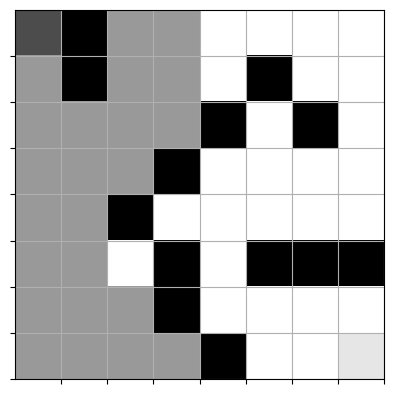

Epoch: 175/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 70 | Win rate: 0.625 | time: 7.25 minutes
   win | Epoch Reward: -4.5600000000000005 | uRLuDdurDudDDDldDlDrDDDdLrLLDlDRDRR


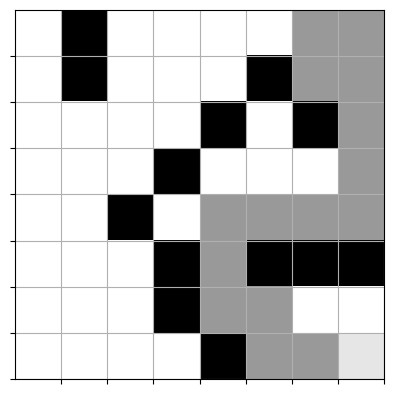

Epoch: 176/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 71 | Win rate: 0.625 | time: 7.28 minutes
   win | Epoch Reward: -1.8200000000000003 | DDDRluurllDrDDRuDRR


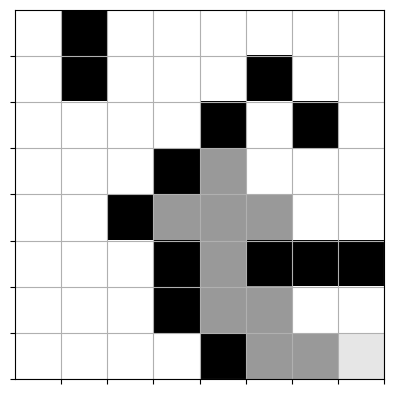

Epoch: 177/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 72 | Win rate: 0.625 | time: 7.30 minutes
   win | Epoch Reward: 0.17999999999999994 | DDLDrDlRDRR


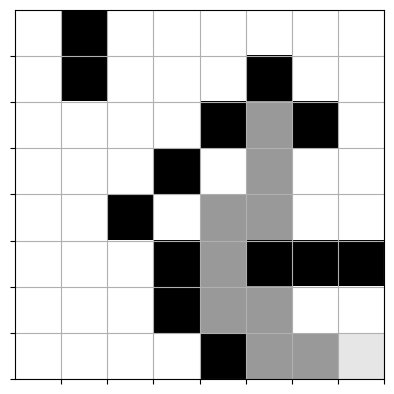

Epoch: 178/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 72 | Win rate: 0.625 | time: 7.37 minutes
   lose | Epoch Reward: -32.21999999999999 | DUlDrULLLlLuLLuDuDDDDDLLLLduLdrLDLLuDLuDUDuDuDUuDDDdDuudDddlrUUUuuLrlDDldDrDDDlldUDUurdUdUUUUdULrLurDDlDDDDDDrdlUDlUDuDUrUUUduUrldUUUdRURRuRLRlr


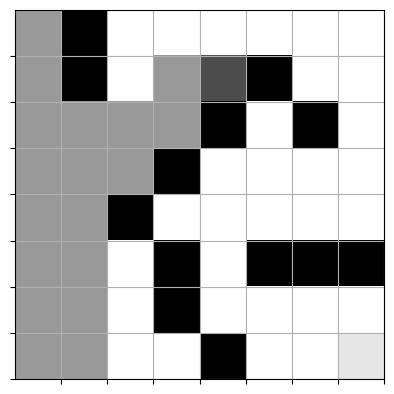

Epoch: 179/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 73 | Win rate: 0.656 | time: 7.42 minutes
   win | Epoch Reward: -11.939999999999984 | DDDdUDUuUlDrDdRllurRUlUuRRdRRRdudlRUrdUddlrrUdUdURDuRRRDllLrDDudDLDDDUlDLuddrDdRRdr


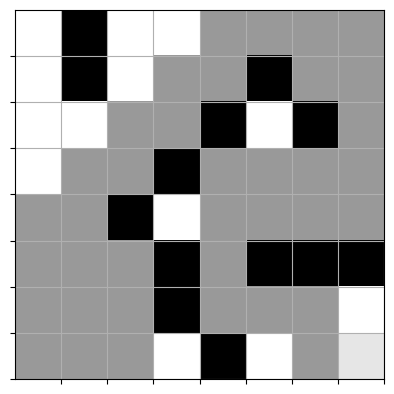

Epoch: 180/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 74 | Win rate: 0.688 | time: 7.45 minutes
   win | Epoch Reward: -6.23 | DLrdDDLruDDDDDluuDuDDDluulRDllRrLDDRDdRR


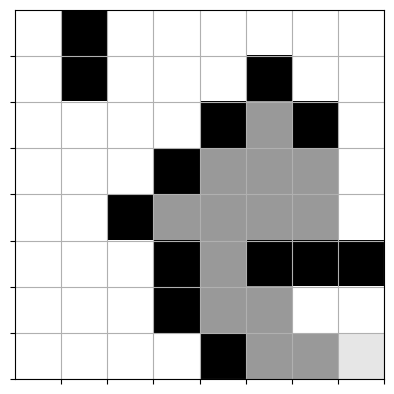

Epoch: 181/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 75 | Win rate: 0.688 | time: 7.49 minutes
   win | Epoch Reward: -6.710000000000001 | UUUuUUdrUUURdRLRrLRLRLRLRLRrdURRRuDuDDDlDLLDDuDRrRrD


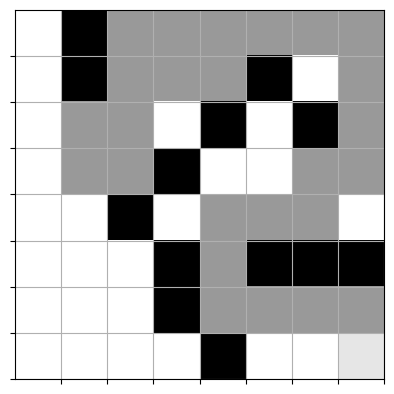

Epoch: 182/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 75 | Win rate: 0.688 | time: 7.56 minutes
   lose | Epoch Reward: -32.13999999999999 | RRRRurrRdRRRrdDrDLRLdrurRRdrdRRRRRlRdlRrdluuRulDDLLLuRrDrdLllruDuDDDUrDUulduruRDRRRlRdRRRdRRdLUuDuDURLRLRRdrLUdUUUruuUDUDduDDdLluUUUUUUUrlRRRr


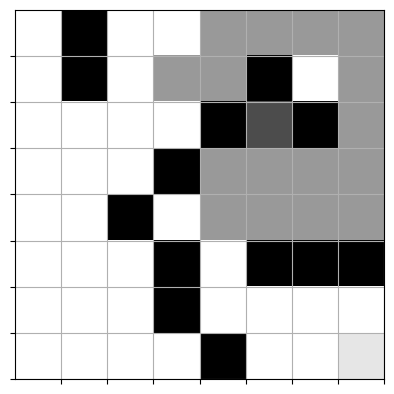

Epoch: 183/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 75 | Win rate: 0.656 | time: 7.63 minutes
   lose | Epoch Reward: -32.03999999999999 | dUUuDlDrrDUlDRddlDddDrDrUluUUUUUUUDUlDDurdDUDDDRuUUUdulrUUUUlUUUURUrRdrdlrURRRulRRRuRRllduRdduRDlDDuRuRudURRRRUUUlrUdULRLLLLDDLLLdDDlRuLDRdldUlDUURUUd


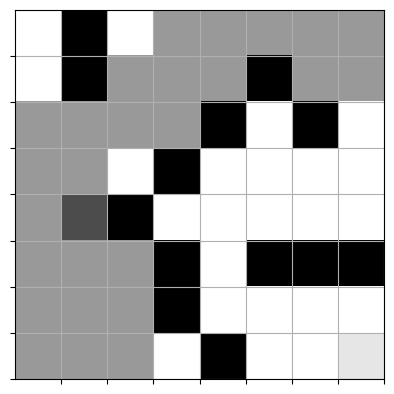

Epoch: 184/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 76 | Win rate: 0.656 | time: 7.66 minutes
   win | Epoch Reward: -3.2199999999999998 | RduRrRRddrDdlRrLLRRruDLLLDDRRlRRd


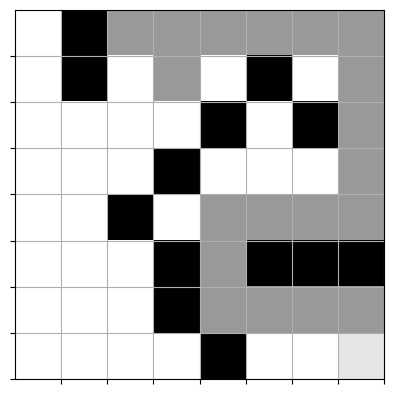

Epoch: 185/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 76 | Win rate: 0.656 | time: 7.73 minutes
   lose | Epoch Reward: -32.21999999999999 | lRRRRUlLLUrUdlLRLulRRLRUdUuUlRUlRlRUUdLlDUDlulRLRdLrLulrrUrUUDDDDdrLRlRUlRUldluUUUURllluURRDurDlDDdRUUdUULUUrRRRDuDDDDRDdRuUuurUuUlRlRUuUUUuDLDu


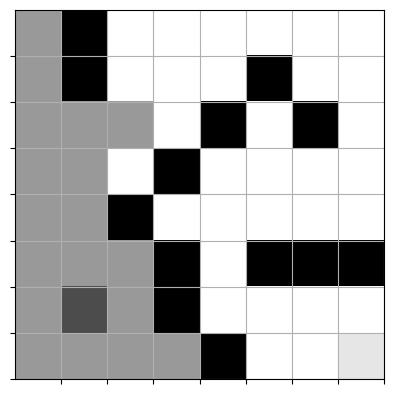

Epoch: 186/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 77 | Win rate: 0.656 | time: 7.77 minutes
   win | Epoch Reward: -6.130000000000001 | rRLrdLrdULDRlRlDUUUUUURRdRRRlRDdrDdLLuLdDuDdRRRD


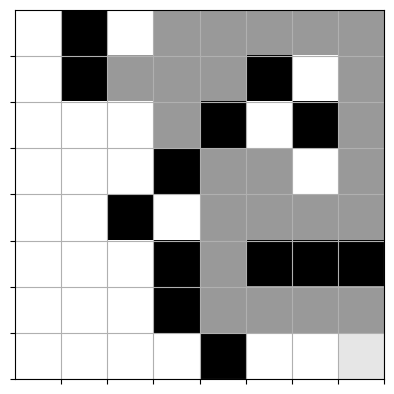

Epoch: 187/999 | Loss: 0.0017 | Episodes: 1000 | Win count: 77 | Win rate: 0.625 | time: 7.84 minutes
   lose | Epoch Reward: -32.219999999999985 | RlRudUldDUDDDDuDrDDDDruDRrRURdldUdrUuDDuDDlDdUUUdUuRuDDUlURdDlDlDDDDuDLUrdLUruDDRRDDDuduDrDDrDUrUdUDurdlrrDrUUUUUUUUUUUdlUdUDrDDrDDDDDuDDurdUlrU


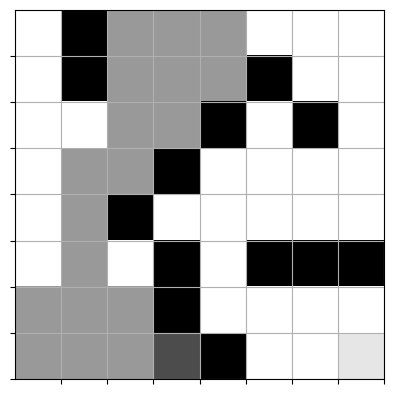

Epoch: 188/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 77 | Win rate: 0.594 | time: 7.91 minutes
   lose | Epoch Reward: -32.07 | RLDLrLlduDUrLDdUlDdUuRlRlRdUdlddUDUDUlDUDUDUrLLLRdRddrdUuUUdUdlLLdLLLDDdDlDdldULlLULLdUdDUrDRRrUUUUllRUDUdULLRDldDDDurrDRUlRUdUUurUlRUd


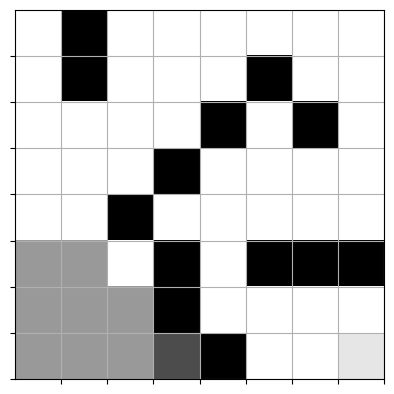

Epoch: 189/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 77 | Win rate: 0.562 | time: 7.98 minutes
   lose | Epoch Reward: -32.20999999999999 | DRdLlduRlrRdLRLrLDDuDDLdruuDlRDDDDDUDdLdRRdDDdRRRRrDDDrLUUrDLDuDdluLuRdlDDlRRRRRRUUlrDrDDUUlULUDlLLLuuDLlLLLuDRlRDrUlDUUUURUrDLDuDLdulrllrUlUuUUUuUUr


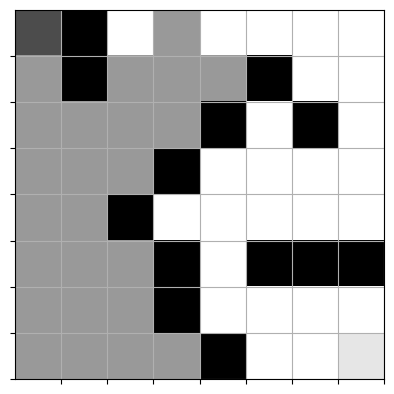

Epoch: 190/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 78 | Win rate: 0.562 | time: 8.01 minutes
   win | Epoch Reward: 0.16999999999999993 | lRLRdR


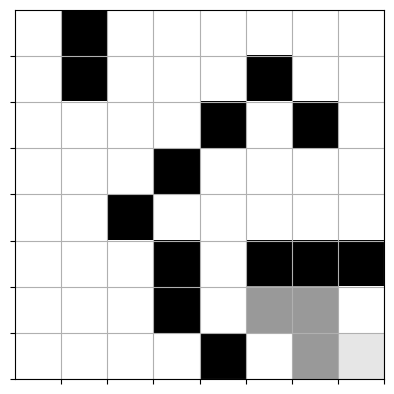

Epoch: 191/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 78 | Win rate: 0.531 | time: 8.08 minutes
   lose | Epoch Reward: -32.12 | DrLLLLLlLLLLLUUuDRDddUdUUDuUrUuRUdUrRURRRdDDDLUUrDrLlduuuluLLUlLurLdDrRLdRLRldRLRdLUUUlUUUurUrLluLLLLLLllLdDrRLRlRLrduDlUUUduUUUUuUUrDdLLrrLRLuUUrDdLUUd


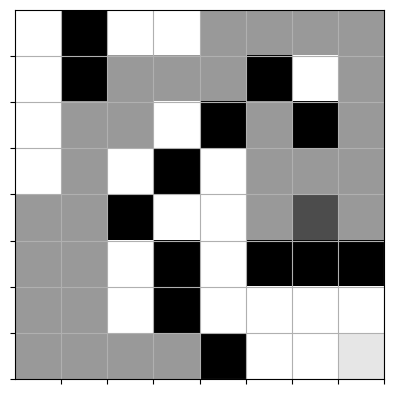

Epoch: 192/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 79 | Win rate: 0.562 | time: 8.11 minutes
   win | Epoch Reward: -1.31 | DDDDLLuldDDlUDUDUDRDRr


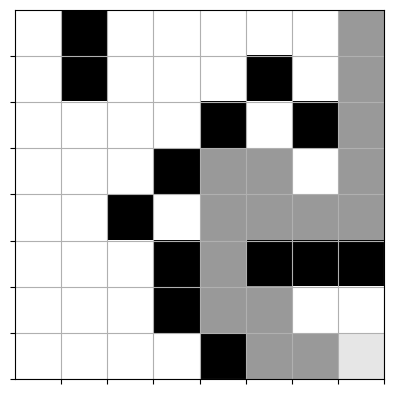

Epoch: 193/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 79 | Win rate: 0.531 | time: 8.18 minutes
   lose | Epoch Reward: -32.14 | UURUrUDuldlUUUUUUUUrUdurUUdUUUUUURRUUUlUUuuddUrdUldUuudUuUUddUUUUrDDllDlDlDDlDrdUUUURURRRRllDrrULLUUUUUUdUudrlUurUrlulDdUUDdDDdDDULudLdUdUUUUU


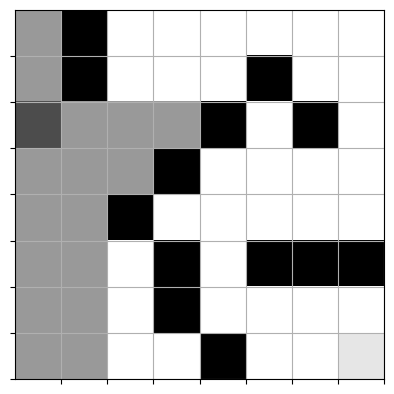

Epoch: 194/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 80 | Win rate: 0.562 | time: 8.20 minutes
   win | Epoch Reward: 0.5900000000000001 | RRldRR


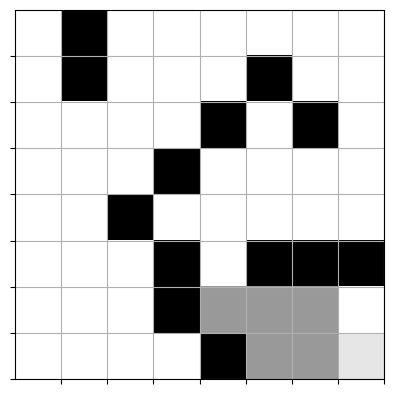

Epoch: 195/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 81 | Win rate: 0.594 | time: 8.23 minutes
   win | Epoch Reward: 0.5100000000000001 | DRdDRrRD


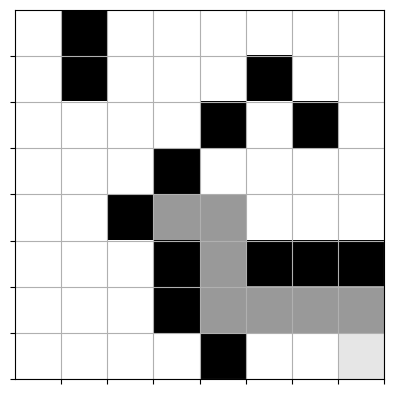

Epoch: 196/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 81 | Win rate: 0.562 | time: 8.30 minutes
   lose | Epoch Reward: -32.19 | UDURddRrUUUUDDddDDDDuDDrDDLRrLrRlurluDrrUUUUuDUDUrdUDRrululDrDDLRddLruDLDDlUluRRDRuDDDdRlduuDuDUrDUlDldUUDdurDLURRRRRrDuDUDrrrUlUdlLdUUldR


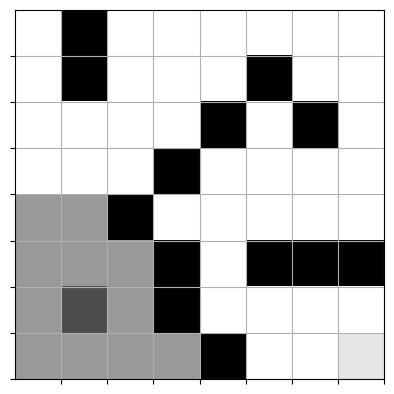

Epoch: 197/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 82 | Win rate: 0.562 | time: 8.32 minutes
   win | Epoch Reward: -0.8600000000000003 | dDLLUUlUdRDDRDRR


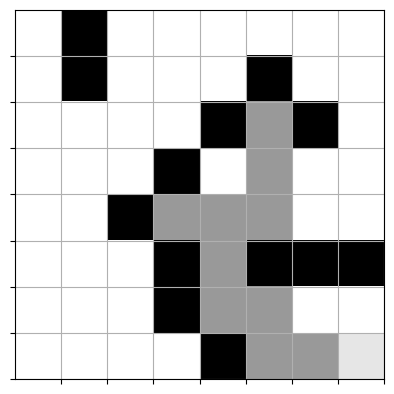

Epoch: 198/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 83 | Win rate: 0.562 | time: 8.37 minutes
   win | Epoch Reward: -13.309999999999992 | rDDLRLURLDruDDdDDRRLLdLRrdLlRDuLRLuuRLruuuLrLRrrUlUUlrRRDrDLLDdrDRurrD


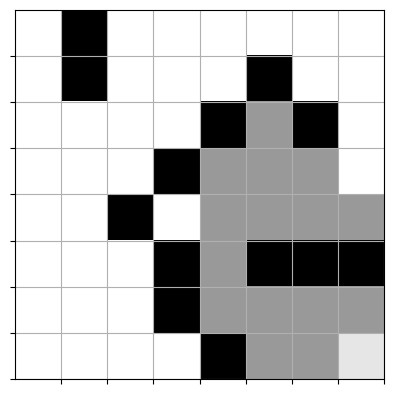

Epoch: 199/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 84 | Win rate: 0.594 | time: 8.42 minutes
   win | Epoch Reward: -13.579999999999988 | DUUUldUURLLDlDDrrlRLRrrlRURRUlRRlDUDUuDdURRRduRRRDDUDUrDRuDRRRduUrDuDDdLLlDDlRDlRR


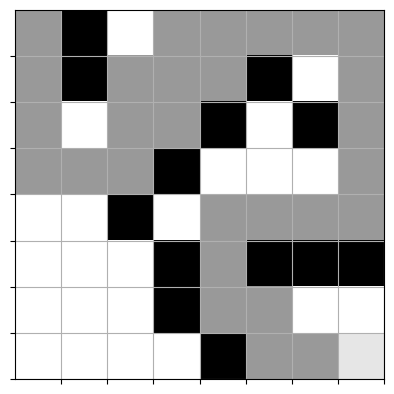

Epoch: 200/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 85 | Win rate: 0.594 | time: 8.46 minutes
   win | Epoch Reward: -8.599999999999996 | uDRRrRRDDDuDuDdLLRuDUuDrDurDLLLuRRuurllUrDdlDDuDRRRd


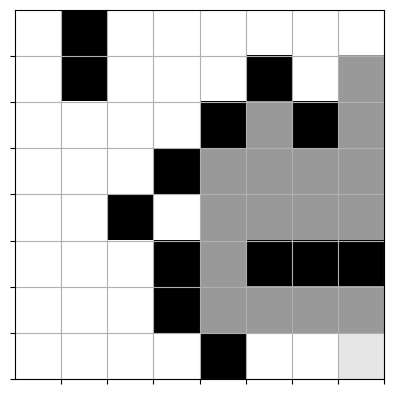

Epoch: 201/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 85 | Win rate: 0.594 | time: 8.53 minutes
   lose | Epoch Reward: -32.079999999999984 | RRdRRRRRDDDDDlDdLrRRRlRRRRrRRuRuuudrrDDLLlLLLLlRUUDUuurlRUdURLRLRdURlRduRdRRRRRduUUrrURrrrRrLRLRdulDURUuRluRRRlRuldLLldRlRLulrRUUDDRRDdDDluDluRrUlRRRRr


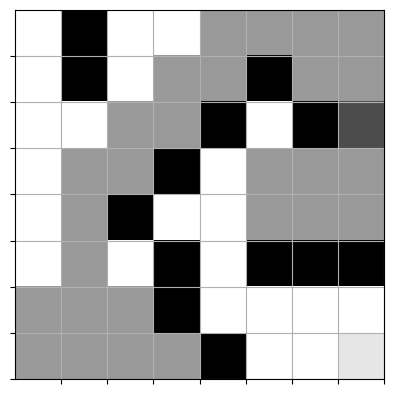

Epoch: 202/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 86 | Win rate: 0.594 | time: 8.56 minutes
   win | Epoch Reward: 0.75 | rD


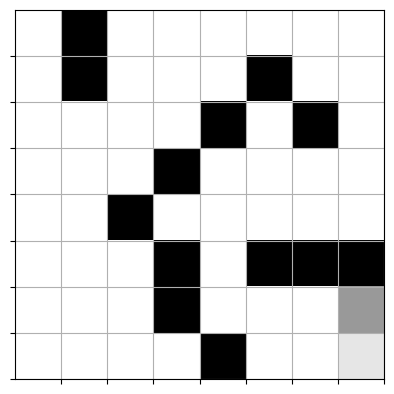

Epoch: 203/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 87 | Win rate: 0.594 | time: 8.61 minutes
   win | Epoch Reward: -17.149999999999995 | ULuLLLLlLLLDDUDUrdUdUdUuUddlUUUruLLuLLrRRuuLLlLlLLLUUDrDdDuUuUUDDDuDlDDlDDdRulRDRR


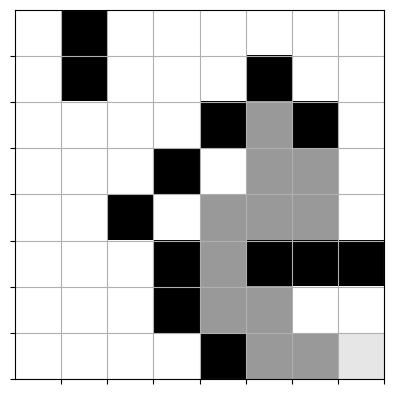

Epoch: 204/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 88 | Win rate: 0.625 | time: 8.63 minutes
   win | Epoch Reward: 1.0 | D


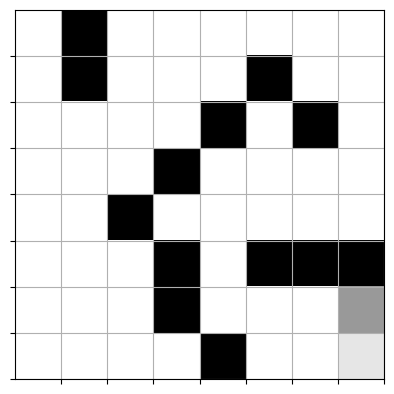

Epoch: 205/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 89 | Win rate: 0.625 | time: 8.67 minutes
   win | Epoch Reward: -7.049999999999999 | lulRRruRrrDDULLLurDlLrLDrDDDurlUUUUUDrrLLLDDRDRuRD


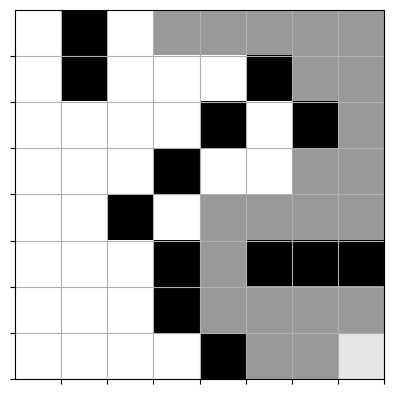

Epoch: 206/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 89 | Win rate: 0.625 | time: 8.74 minutes
   lose | Epoch Reward: -32.17999999999999 | LLuDDDlldLLuuLrUlrUUUUUUUrdUUdUlDlDllrDDDuDDLLLUDrUUUUULUudDdDldrDDlDdddLLDDDlLLLuDLdLLuURUURDlULUdUUrDDDDurdDDDDdUUduuUlulruDlDDlDDDDDDDlDlDud


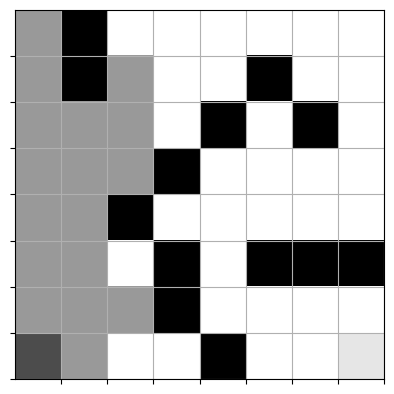

Epoch: 207/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 90 | Win rate: 0.625 | time: 8.78 minutes
   win | Epoch Reward: -6.680000000000001 | UrRRLuRLdLLlLuDdDudLLuldRdRDdDlRLLLDDRDlRldlrR


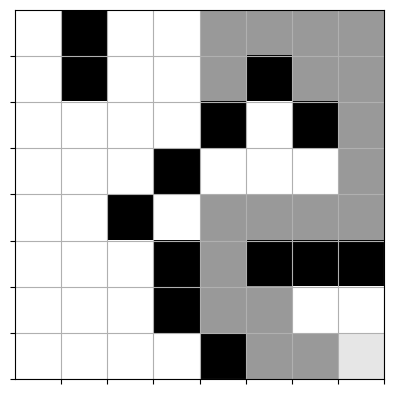

Epoch: 208/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 91 | Win rate: 0.625 | time: 8.81 minutes
   win | Epoch Reward: 0.88 | RuRD


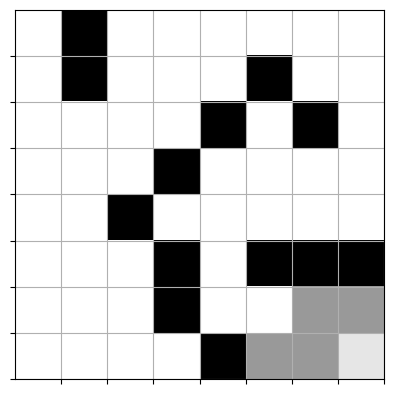

Epoch: 209/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 91 | Win rate: 0.594 | time: 8.88 minutes
   lose | Epoch Reward: -32.22 | RRRldULLurUlrDddDuruDlRRULdDDrDDDDldUUUUuLuUdlULLLddrDuDRLuuLluDrDRDDDuDUdlLrULDdDuduDllRDrDRDDDudDDLRLRDDDlRlRUUUuDUdDDDDuDlDDDrDDDDDDRRRRuurRD


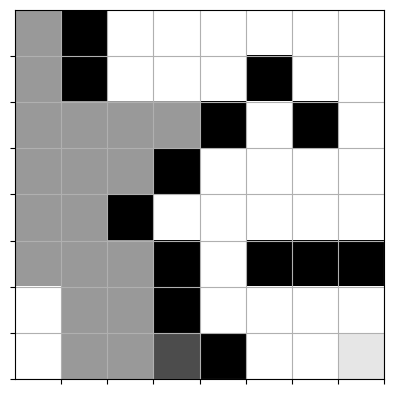

Epoch: 210/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 92 | Win rate: 0.625 | time: 8.91 minutes
   win | Epoch Reward: -1.0700000000000003 | DDDDuldDuDdruDRR


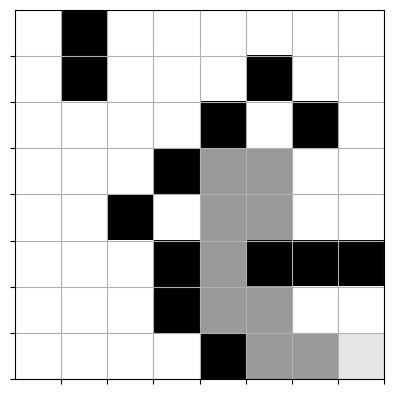

Epoch: 211/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 93 | Win rate: 0.625 | time: 8.95 minutes
   win | Epoch Reward: -3.7200000000000006 | RudRrRudrRRuRrURRudRDDDLLLDDRruRlRD


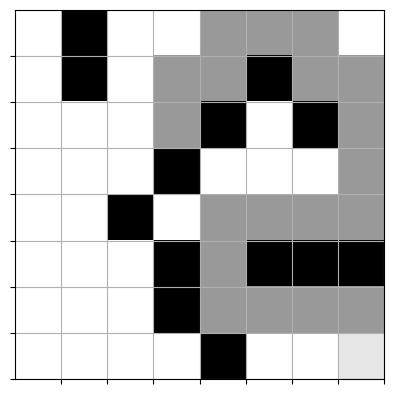

Epoch: 212/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 94 | Win rate: 0.625 | time: 8.97 minutes
   win | Epoch Reward: 0.88 | RuRD


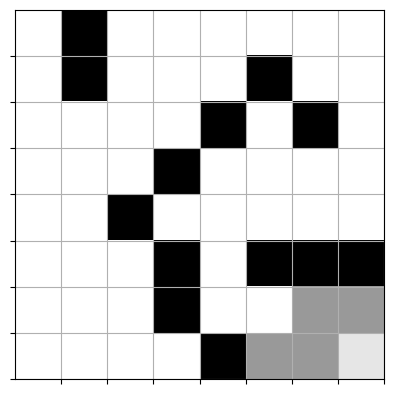

Epoch: 213/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 95 | Win rate: 0.625 | time: 9.00 minutes
   win | Epoch Reward: 0.45999999999999996 | RlRd


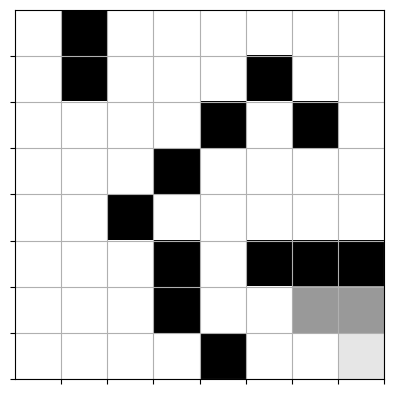

Epoch: 214/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 96 | Win rate: 0.656 | time: 9.03 minutes
   win | Epoch Reward: 0.2699999999999998 | rDDDLdLLDDRdRr


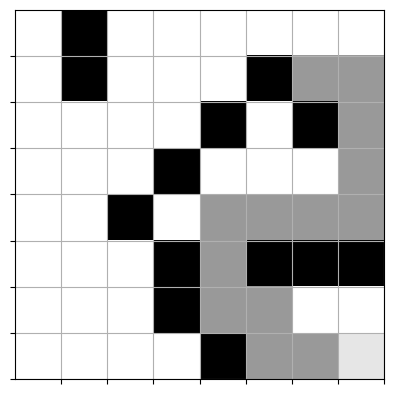

Epoch: 215/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 96 | Win rate: 0.656 | time: 9.10 minutes
   lose | Epoch Reward: -32.06999999999998 | DudDDDrDrDduuLLLRluRRlLrLRRLrLDdRluRudrLLlUuDrDuDuudrLdlRuDRLRlUlRUdrllLLrLLuLLLDRuLDduRUDUURrRRlLLLlrrURUdrUlluRDlDuRRdRRRRlRRURRrDuLdLRdDlDulrUrrrurlrDDuD


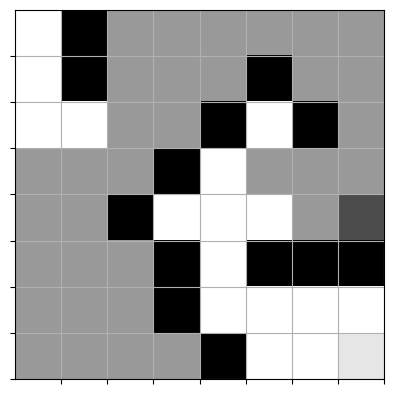

Epoch: 216/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 97 | Win rate: 0.656 | time: 9.13 minutes
   win | Epoch Reward: -1.2400000000000002 | RDDluDlRuldrRRd


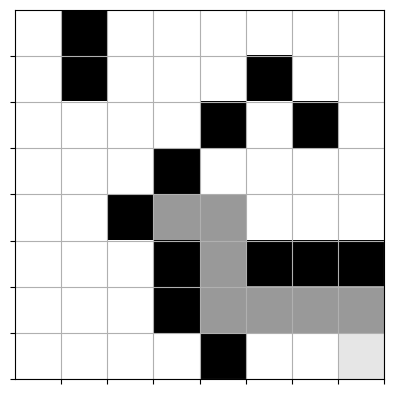

Epoch: 217/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 98 | Win rate: 0.688 | time: 9.19 minutes
   win | Epoch Reward: -11.509999999999986 | RUdLRdrRRRlRrRRRdrRdRRRudLRLRDDDDDDdUuRRRRrRRRduDdDdLuUULdLDDRDuDRr


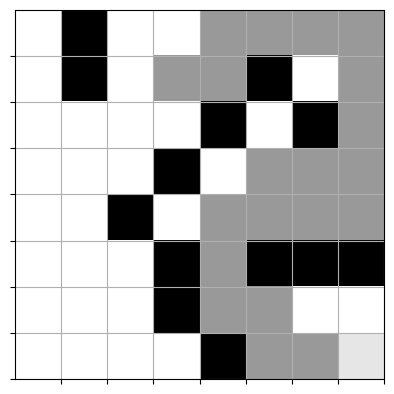

Epoch: 218/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 98 | Win rate: 0.656 | time: 9.26 minutes
   lose | Epoch Reward: -32.11 | LrdDLLRdRRRdRUUUUUUUlRRRrrudldudRuUUUdRlRRRRuuLLrRDRRdRlRLrRRuRDlRRrUdLLLUrDLRRuLDLdUdudddRRRRRRRddLruURRrRRRUuUULLLUruDrRRuDUduDLdLUUDU


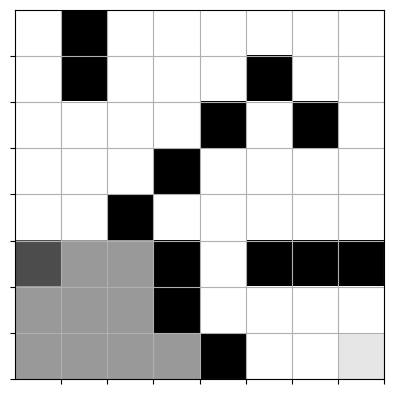

Epoch: 219/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 99 | Win rate: 0.688 | time: 9.28 minutes
   win | Epoch Reward: 1.0 | R


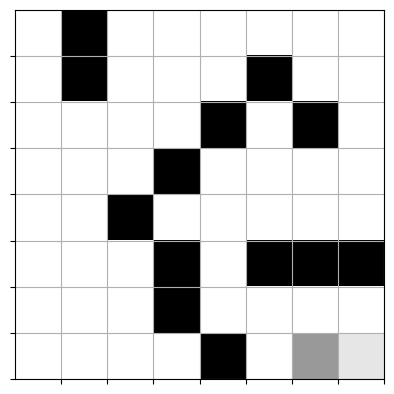

Epoch: 220/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 100 | Win rate: 0.719 | time: 9.32 minutes
   win | Epoch Reward: -2.0500000000000007 | RDRlRdURRlRRDDlDlrDLLLDdRuDRdR


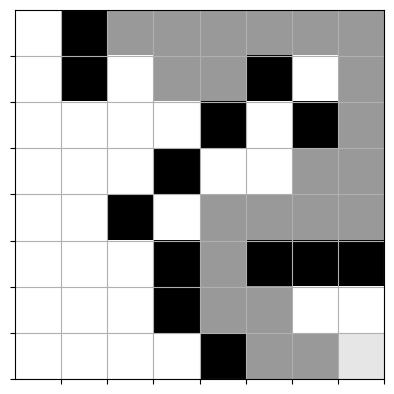

Epoch: 221/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 100 | Win rate: 0.719 | time: 9.39 minutes
   lose | Epoch Reward: -32.099999999999994 | LUULDlLRDlURUULLllLLLLullLdlLLLLlLrdruLLlLrLdRUuLdDlDDdUlDUULuRLLuLLUuUldDDlLuuUUUrrUUUUUDUDUlRlduLLlUUDuDUudDDLLrLdRUrUDULluUdUrLLLLLLLLLLLL


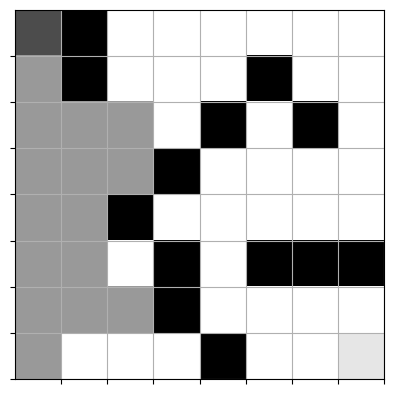

Epoch: 222/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 101 | Win rate: 0.719 | time: 9.44 minutes
   win | Epoch Reward: -14.22999999999999 | DDRDldluRuDDUDrUDULddLUDlURuRDUDrUlUrUuRuRRdURuRRDDDrDUDduuDuurlRrdllrDlllDurDLrLldRudDDRuRRD


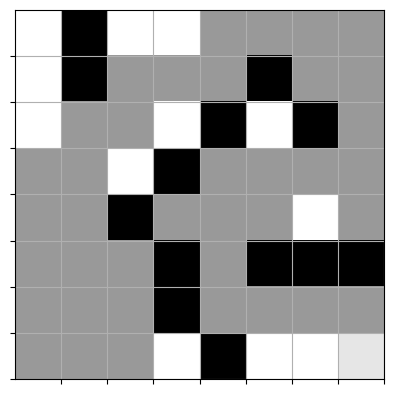

Epoch: 223/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 102 | Win rate: 0.750 | time: 9.51 minutes
   win | Epoch Reward: -16.439999999999976 | RlRuDlDrUlLRLRLUUDDDUDUruDDUDrUUDUUdUDlDulDDDDDUlUlUDlldURUuUrRUDUudLURDRlRURRRDrldlDrrDDDdrLLLDDRdRR


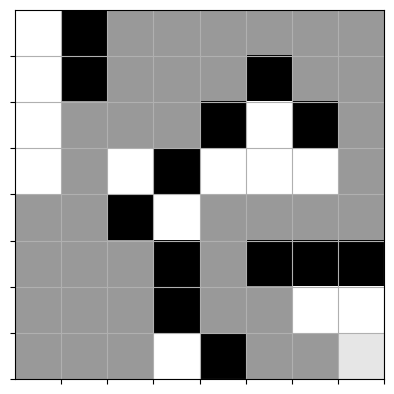

Epoch: 224/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 103 | Win rate: 0.750 | time: 9.53 minutes
   win | Epoch Reward: 1.0 | D


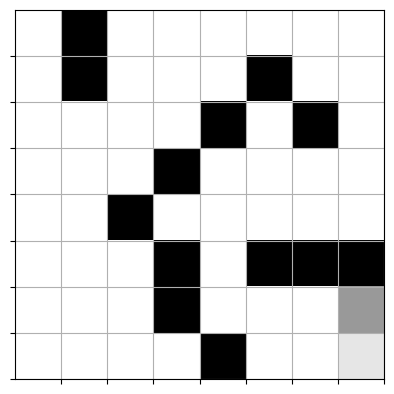

Epoch: 225/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 104 | Win rate: 0.781 | time: 9.56 minutes
   win | Epoch Reward: 0.51 | DDDdRDRr


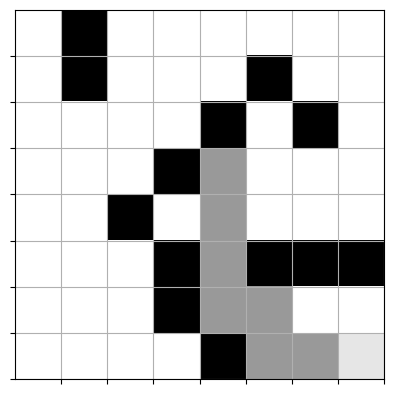

Epoch: 226/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 105 | Win rate: 0.781 | time: 9.59 minutes
   win | Epoch Reward: -0.030000000000000027 | DdDrRllRDRR


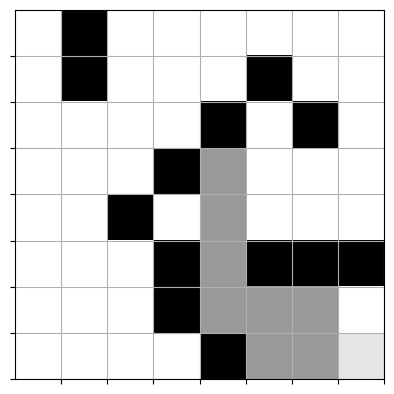

Epoch: 227/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 105 | Win rate: 0.750 | time: 9.68 minutes
   lose | Epoch Reward: -32.08999999999999 | DDDlrUUDUDlDDDluDDlUUUuDdDDDrUDUDUuDdLUDUlDUuUDUlDRDDulDUrLDUDUDdUUdDUdUDluDRlRRdrLULLlDUlllRRRRRRuRRuullrUlUUUUDDDDrUUUDUDlldLLLDrUUURLRrRUdduuDD


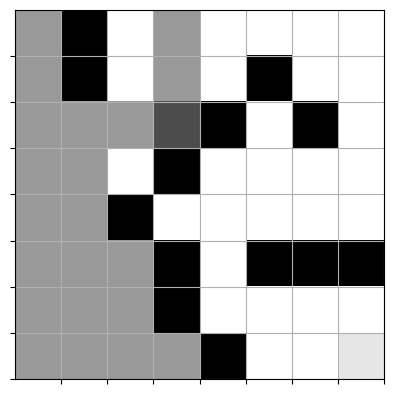

Epoch: 228/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 106 | Win rate: 0.781 | time: 9.71 minutes
   win | Epoch Reward: 0.29999999999999993 | uDddRDRR


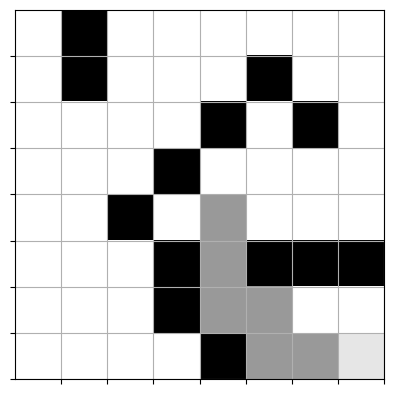

Epoch: 229/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 107 | Win rate: 0.781 | time: 9.77 minutes
   win | Epoch Reward: -18.379999999999995 | UruRRDduDrULUlRRRlRddDUDrUuDdDLUUlLuDrruUrUULrLURDDDurDdLrlULLLLLLLdURUUUUUUUrdLdLRruLRLuDDrdRDRR


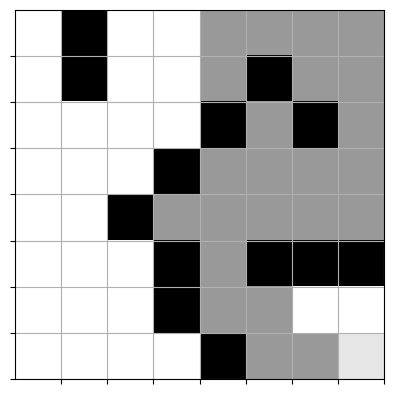

Epoch: 230/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 108 | Win rate: 0.781 | time: 9.84 minutes
   win | Epoch Reward: -19.52999999999998 | RuduRRrRRRRLRLRLLLrLLRUllURRrDRrrDDDDRLdRLuLLLduDdRRRLUllRrUUUrUUrlUdUUURrURUdURRRUUUUUUUDDuDDLlLlDDDRlRllrrRD


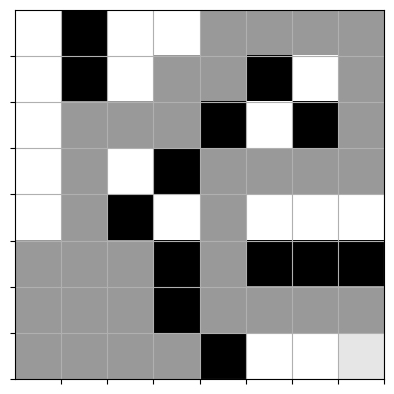

Epoch: 231/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 109 | Win rate: 0.781 | time: 9.89 minutes
   win | Epoch Reward: -4.180000000000001 | RlDDrDDrDLLLDUURRRDuDLUDuDllDDRDRuRD


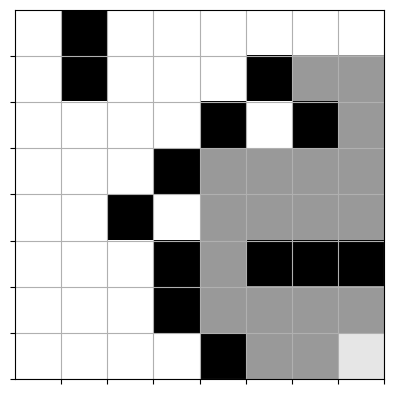

Epoch: 232/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 110 | Win rate: 0.781 | time: 9.93 minutes
   win | Epoch Reward: -2.5100000000000002 | RRRRRRRuRDLlRDDDLLLuDDDRuldRRRD


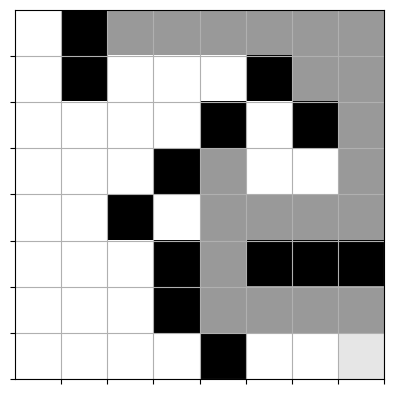

Epoch: 233/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 111 | Win rate: 0.812 | time: 9.96 minutes
   win | Epoch Reward: 0.96 | RD


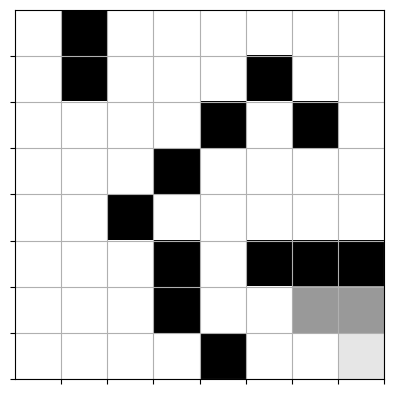

Epoch: 234/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 112 | Win rate: 0.812 | time: 9.99 minutes
   win | Epoch Reward: -0.7300000000000004 | llRRRrDrLlLDrDRDRR


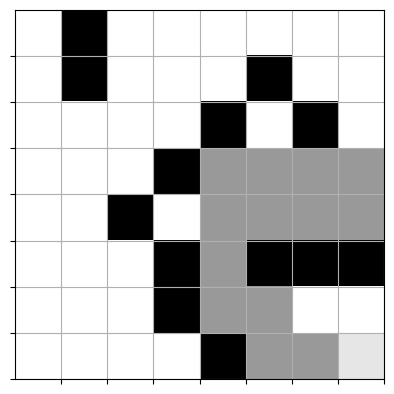

Epoch: 235/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 113 | Win rate: 0.812 | time: 10.02 minutes
   win | Epoch Reward: -0.3600000000000001 | dlLldDlDlDRDRR


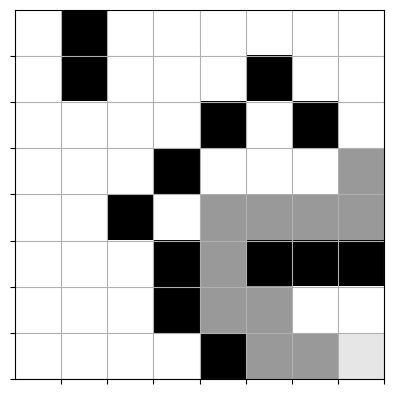

Epoch: 236/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 114 | Win rate: 0.812 | time: 10.06 minutes
   win | Epoch Reward: -8.109999999999998 | LLLLLdLlLLDdrlDDDDudLLLuRRLRLRLrLrLDDudrlRDRR


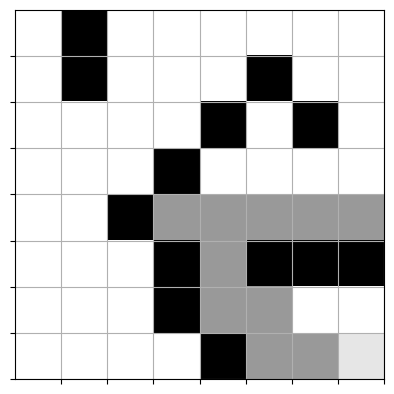

Epoch: 237/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 115 | Win rate: 0.812 | time: 10.09 minutes
   win | Epoch Reward: 0.92 | RRD


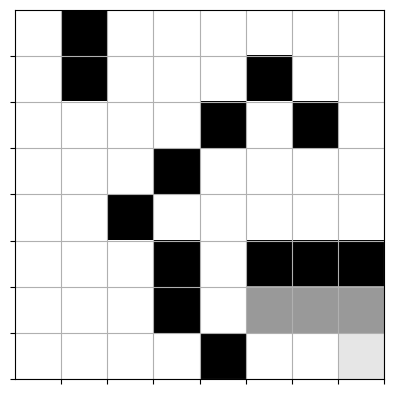

Epoch: 238/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 115 | Win rate: 0.812 | time: 10.16 minutes
   lose | Epoch Reward: -32.15 | RrrRRRRRRudRDDDduDRlrRRRRRuurdRRuRRrRuDDDDDDRRRrRRrRRRdruDdDlRdDDDrdDludrRlRRlRrDuludRRluRrDRuLrLUDrDDDDDDdrUduRlRLLLdrRudRDDDDDdllUDUURD


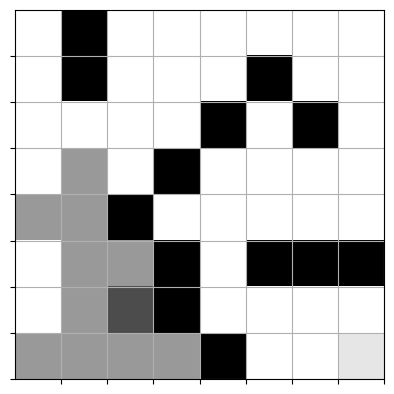

Epoch: 239/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 116 | Win rate: 0.812 | time: 10.21 minutes
   win | Epoch Reward: -9.129999999999995 | RLlRLLlRdlRRdRRdRURLRruRRRDLLLurDLdRdDLLLRLuRDLDDRlRulRDRlrR


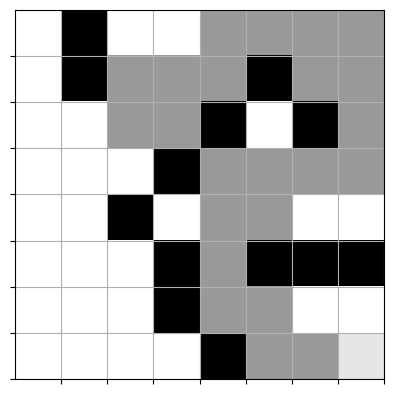

Epoch: 240/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 117 | Win rate: 0.812 | time: 10.27 minutes
   win | Epoch Reward: -20.769999999999975 | LLUdUURRlRlrDuDUuDUlDdLDUDlUUdLdrrLdLUURlRDDLUURRluLUUruLUudurDdddUUUrUDdDRllRULDruLLrRRuRUlUUUdrURRlRRDDDLLDrLLDrDRRRuD


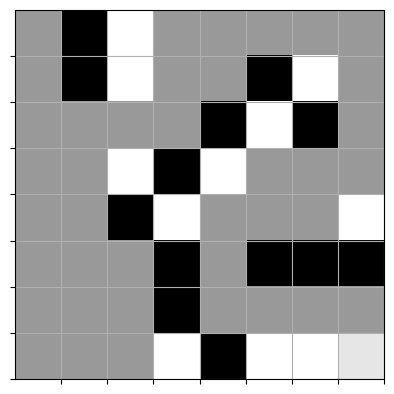

Epoch: 241/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 117 | Win rate: 0.812 | time: 10.35 minutes
   lose | Epoch Reward: -32.019999999999996 | DuDrUDurrDRuuDDLLRLRuUDDrDDrUUUUUllRllDlRRUUdUrDrDDDrdRrRRRRRRdrlrLdlLrlUlDldRrrDDDDlrDDlUrUUdUlUDrDDUUDUDUDurDlDdLDuDUDuURuUlDddURDDuUdrDr


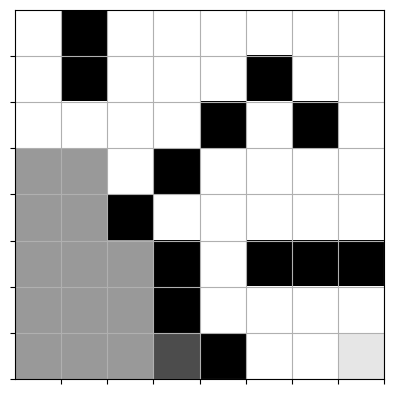

Epoch: 242/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 118 | Win rate: 0.812 | time: 10.38 minutes
   win | Epoch Reward: 0.38 | lRRuRD


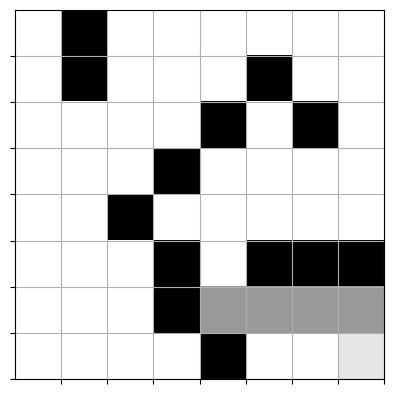

Epoch: 243/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 119 | Win rate: 0.812 | time: 10.40 minutes
   win | Epoch Reward: 0.6300000000000001 | dRRRD


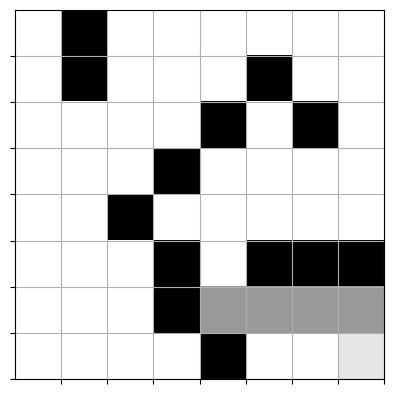

Epoch: 244/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 120 | Win rate: 0.812 | time: 10.43 minutes
   win | Epoch Reward: -1.3600000000000003 | LduLLLuLLLLDDDRDRR


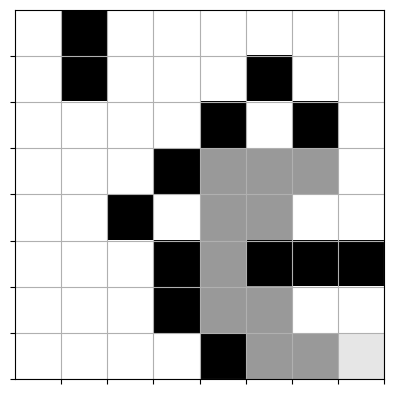

Epoch: 245/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 121 | Win rate: 0.812 | time: 10.47 minutes
   win | Epoch Reward: -4.73 | DDuDuDLldDDuDDurlrDLDDrLrLLDDRuRRd


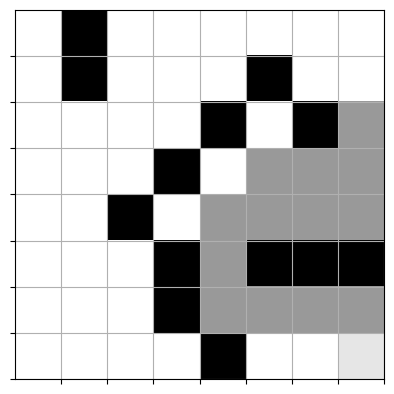

Epoch: 246/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 122 | Win rate: 0.812 | time: 10.50 minutes
   win | Epoch Reward: 0.96 | DR


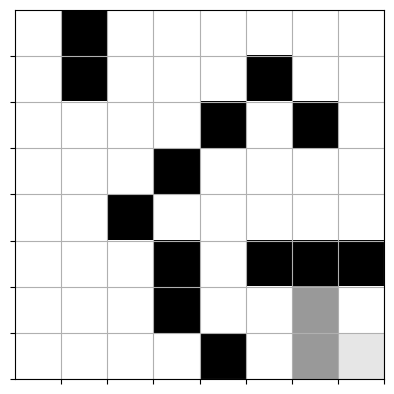

Epoch: 247/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 123 | Win rate: 0.844 | time: 10.53 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDdRDRR


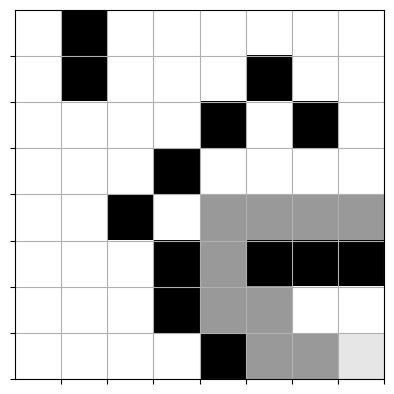

Epoch: 248/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 123 | Win rate: 0.812 | time: 10.61 minutes
   lose | Epoch Reward: -32.08999999999999 | lRRRUDdLDDLrLRLRdddDDrdlRLRruRLLLDdrDRDuluduDRDLdrudLLrlUdDDRlrLUUuUUdUUUrDDDdDRDRRRRrLUuDUDDllUUrrddDdRLLLLLrLruDLlRrRLRLRruLdRLrLlLDLUlUduRDDRDD


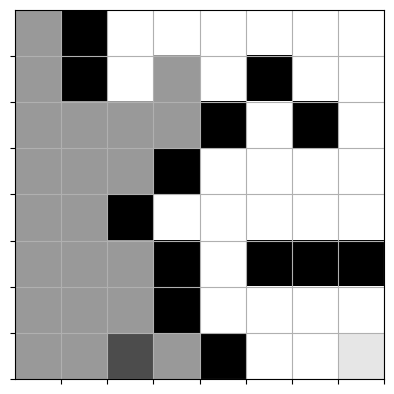

Epoch: 249/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 124 | Win rate: 0.812 | time: 10.65 minutes
   win | Epoch Reward: -4.710000000000001 | DUDrUURRULuLLLLLLUUurDuRLRRRRDDDrDldLLDdRDRR


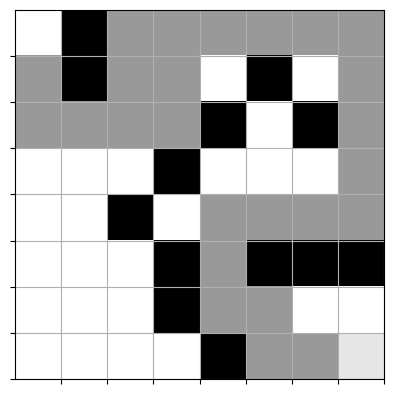

Epoch: 250/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 124 | Win rate: 0.812 | time: 10.72 minutes
   lose | Epoch Reward: -32.04 | LLLLrLLLlLUDUDUuRRdUuRlRuLrdULrlRlRRRRRdUDUuDlURrdUdlrULLdLLURrRRlrRuldrruRLdULLrLdURRdUDlUDrUDUDULLLRRRulRRRRLluLLLLrrDUDURRdluR


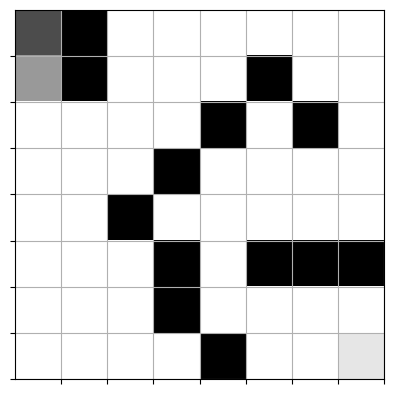

Epoch: 251/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 125 | Win rate: 0.812 | time: 10.76 minutes
   win | Epoch Reward: -6.840000000000001 | RRlrlRRRRDlLuRDuDLRrrLruDDDLDLLuRRRuDLdLLlRDDRuDRR


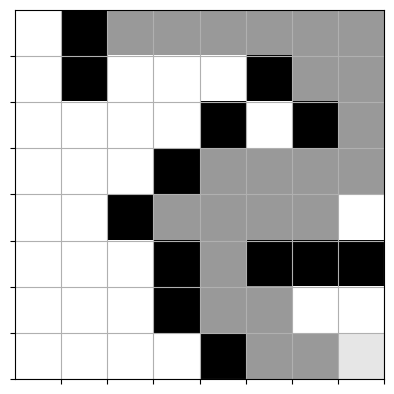

Epoch: 252/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 126 | Win rate: 0.812 | time: 10.80 minutes
   win | Epoch Reward: -1.9300000000000006 | DurlRrRRDDDDLLLdDlRluDRDRdR


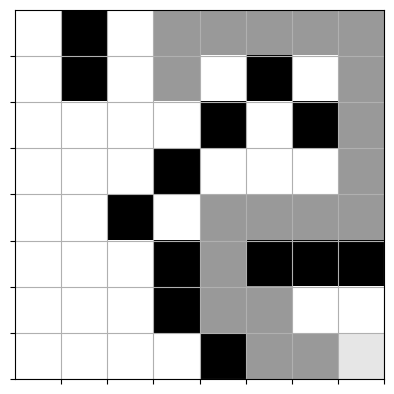

Epoch: 253/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 127 | Win rate: 0.844 | time: 10.85 minutes
   win | Epoch Reward: -16.21999999999999 | RRRLRLRRlRDDlDLRLRrlRLRuDLLLlRRRLLRuurLLlLLLLLrRlRRLuruDDuuDDLrLurLLLRLRRddLLDDRRuRuD


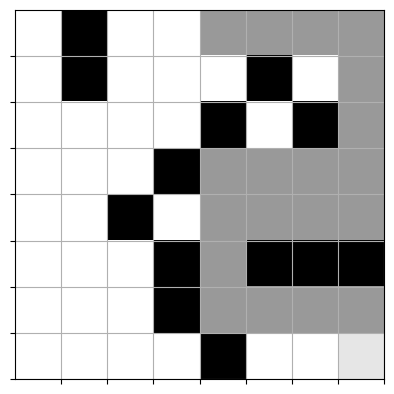

Epoch: 254/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 128 | Win rate: 0.844 | time: 10.89 minutes
   win | Epoch Reward: -1.6400000000000006 | LRlRRrDDDLLUUuDDDlDrDRRRD


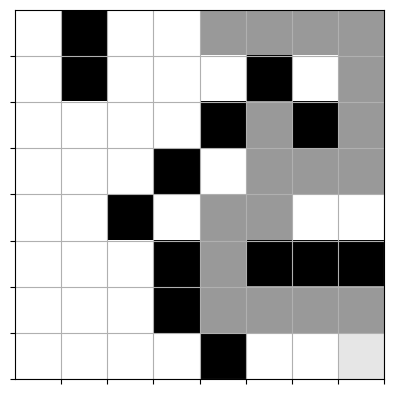

Epoch: 255/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 129 | Win rate: 0.844 | time: 10.92 minutes
   win | Epoch Reward: -1.3100000000000005 | DDDDRDdDLdLruDLLDDRDRR


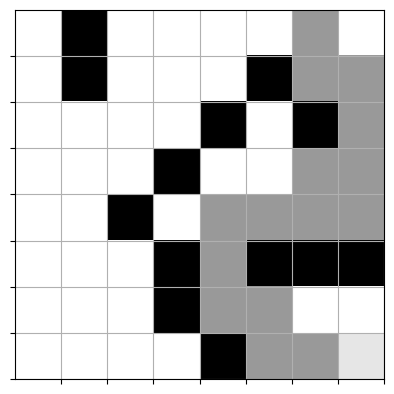

Epoch: 256/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 130 | Win rate: 0.844 | time: 10.96 minutes
   win | Epoch Reward: -2.5200000000000005 | DDDDlDrLDLLDlruluRDDRurudr


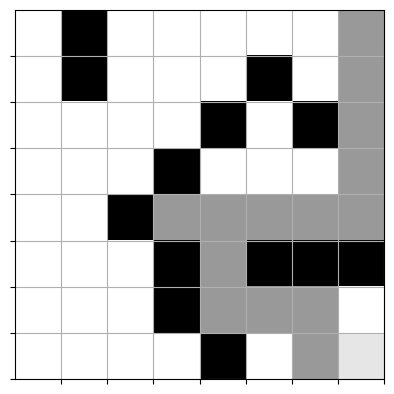

Epoch: 257/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 130 | Win rate: 0.812 | time: 11.03 minutes
   lose | Epoch Reward: -32.05999999999999 | UUlRRRRdRRRdUuLudDURRUllLlLlrDDUldUULLLLDDDlDDDDUrlDuDrDRRRRRRlUUUUDDUDUDrrudULULlRRUlRDDDDUrLRRRrUdUrDUDruDLRrLRLRRDuLDLuDRRRRRLUdLRrLDDDDD


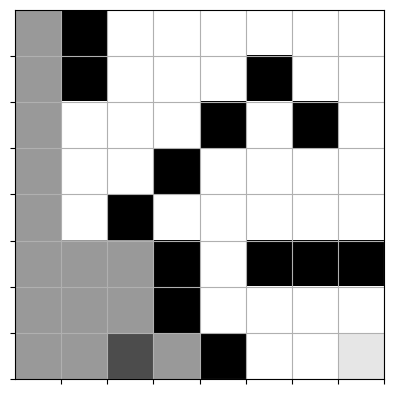

Epoch: 258/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 131 | Win rate: 0.812 | time: 11.09 minutes
   win | Epoch Reward: -13.959999999999987 | DUDURRDDDDDDLDddLURRUudDDDdDLDrLlRdRRdRRRRdRRrRRuRURURRlRRDDDuDdLuDrLLuDLDDRDuDRr


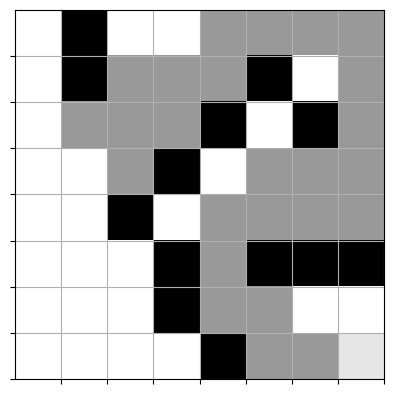

Epoch: 259/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 131 | Win rate: 0.812 | time: 11.16 minutes
   lose | Epoch Reward: -32.14 | DLLDlrLDDDDdLdRuDuuRLDDdLduDRRuLdRULDLLlDDDDRDrUUUUDLDDDddLUDUuRRDLDDLLLLDuDLLLLlRRurlDLRLlLLLLLlRLdRRUDUDULrLDUDuDUuULDLLLDDDDDDRLdRRLRLRLLdD


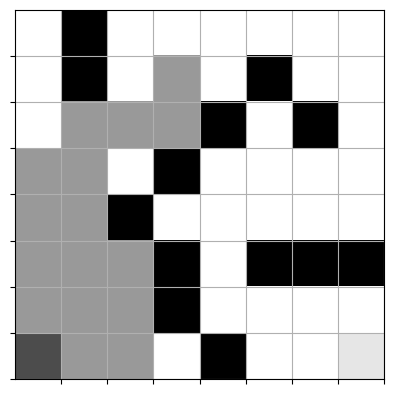

Epoch: 260/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 131 | Win rate: 0.781 | time: 11.24 minutes
   lose | Epoch Reward: -32.17999999999999 | LLULLLdrLULRDLrLURuDlUrDLDrlLlUULLuLuLLLLLrLdDUrDDlDRULUUdluDuULLLLLLLLLLdUuLuLlUUUUUUULLdULLdrULLDDDurrLRLUUdUULUDDDDRRUUUUUluUURLRuURDrDdlDuL


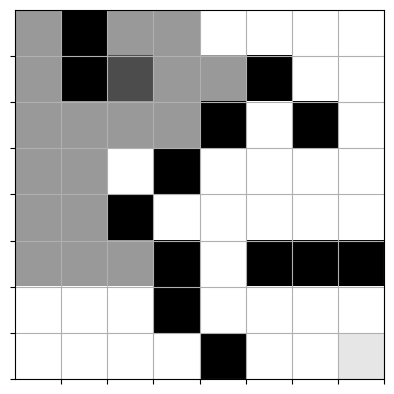

Epoch: 261/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 132 | Win rate: 0.781 | time: 11.28 minutes
   win | Epoch Reward: -2.8500000000000005 | dDdURDDDlUUuUUUUUrDLLLDDRDdRR


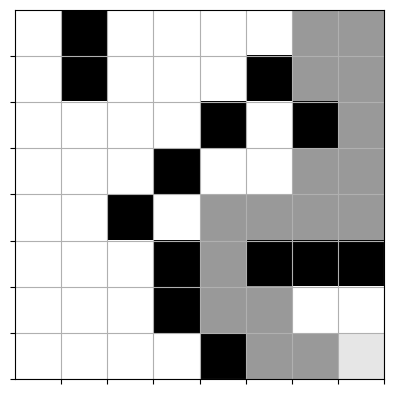

Epoch: 262/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 133 | Win rate: 0.781 | time: 11.31 minutes
   win | Epoch Reward: -0.94 | DrDDLLLDDRDRldRlrR


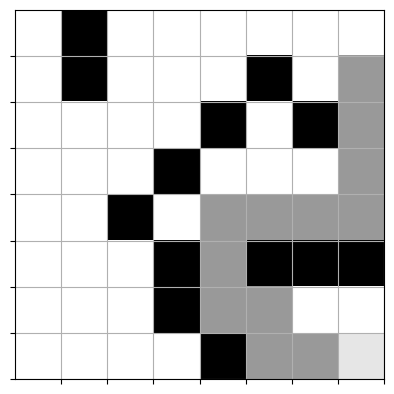

Epoch: 263/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 133 | Win rate: 0.750 | time: 11.38 minutes
   lose | Epoch Reward: -32.23 | DDDrDrdUUUdUUDDDlDDdduURurrDDuDDulDUDUDUlDlDluDDrUUDdUDDDDDDDurdUdUDUDDdDDRRRdRRRRDDluDLRLULDRrDlRUDUDddLUDUDDRRRRlLRrLLRdLulrlDRrDDDLddLRU


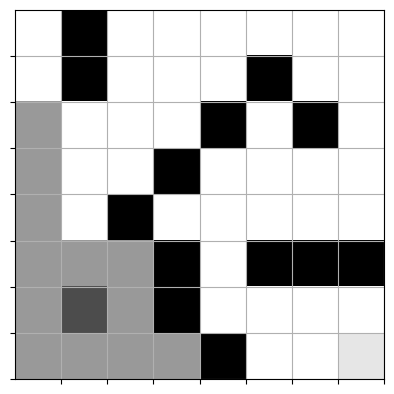

Epoch: 264/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 133 | Win rate: 0.719 | time: 11.46 minutes
   lose | Epoch Reward: -32.19 | DDDDRDlRLRrLuDRRdRDDDDdLLdlRdDDDDDuudDDDLRLRLRRRrRRRRRRuDDDDLLLuDRUUlDDuDRDRRRRRdRRDDuLLLLRRLRlRLRLlRlRRrdDDDDuDDdRRRuLLrlrLLRuDDDDDuRRRrl


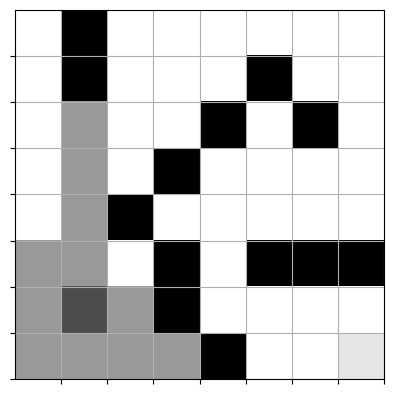

Epoch: 265/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 133 | Win rate: 0.688 | time: 11.54 minutes
   lose | Epoch Reward: -32.230000000000004 | lDDDlRdLDLLLLUDLLLLLLLRLRRRRLRLrLRLdLLDlDRLRurrDDDDDurRddRLlLLRDlRuRlRDRLRrLRuLRRuRrRRRrLRLRLRuDDDDlRLdlLUllDdLLLuDlrRRRlRRRdLluDLDuDUDRRRR


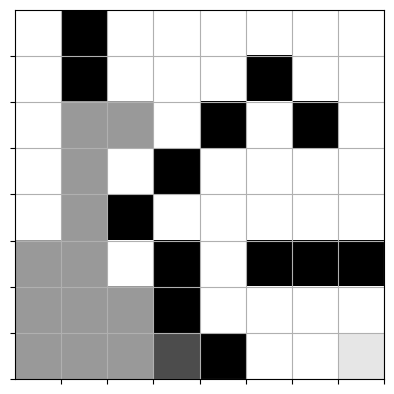

Epoch: 266/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 133 | Win rate: 0.656 | time: 11.61 minutes
   lose | Epoch Reward: -32.14 | DDDLrLLLDddLLRDURRRRDDRRRLLLrLlRLRLRLRlUDURUrLudDdLUrLRuDUDLRLRLRLRLRuDDDuRRRudLLudLLLULRDdrUdrUUrLLLrluRLRlRLDRuLRrRRRRduRRRRLLRdLrLUDuDUdldU


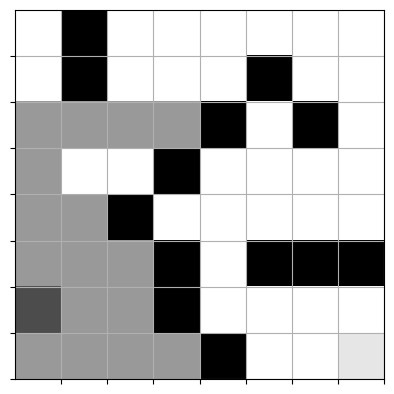

Epoch: 267/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 134 | Win rate: 0.656 | time: 11.65 minutes
   win | Epoch Reward: -1.0700000000000003 | UuUDlDDuDDRDddrR


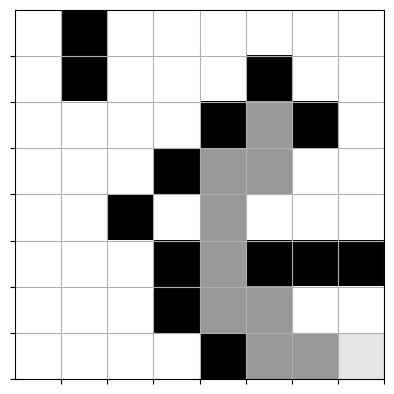

Epoch: 268/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 135 | Win rate: 0.656 | time: 11.68 minutes
   win | Epoch Reward: 0.09999999999999976 | rDDDlLLDDRrDR


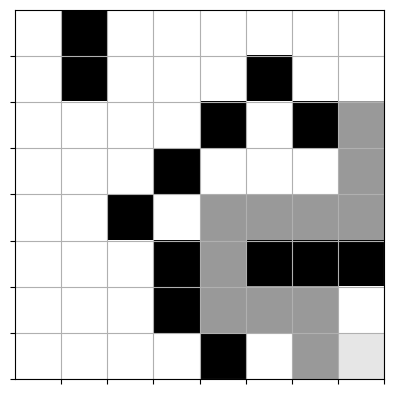

Epoch: 269/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 135 | Win rate: 0.625 | time: 11.75 minutes
   lose | Epoch Reward: -32.07 | DdDDRudRRuRRRRlrDuUdUulRUDDDDRuRRdRuDrDrDdUUUDDuDDRRRRRRRRRRRLLdRRrRdRrDDDDRrRRlrDDDUUUUUuUUDDlRUUrlRDdDDDDldRdDDdDrdUllrRlRddrUUUlLLuD


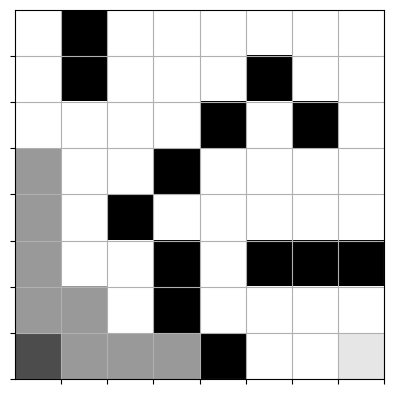

Epoch: 270/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 135 | Win rate: 0.625 | time: 11.83 minutes
   lose | Epoch Reward: -32.11 | DuDDDDDDDDRRdlrRRuRRLluDLUlDRuDLRdLdRrRlRRRRRRRRRLLudLUDRRRRRRUUUUuUUDDDlRdRRuRdRRRUUUuLLLDDRlRRrRRRlDurDrUUUUUUULLLDDRrRRRRULLdrrUUUUdU


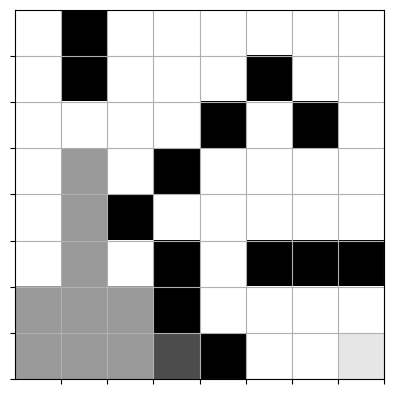

Epoch: 271/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 135 | Win rate: 0.594 | time: 11.90 minutes
   lose | Epoch Reward: -32.099999999999994 | DDDDrlDLDRDdLUDrLURlRRUlDDRLlUURDUDUDlURlRrDLLDUURULrLuDDDUDdUUrrUUUrdUuRDlRDuDUDLLdrlurUruDDlUUDUUuulDDuDDLLLlLLrDRlRLRLRrUllRDRlRrLuDRUDDUL


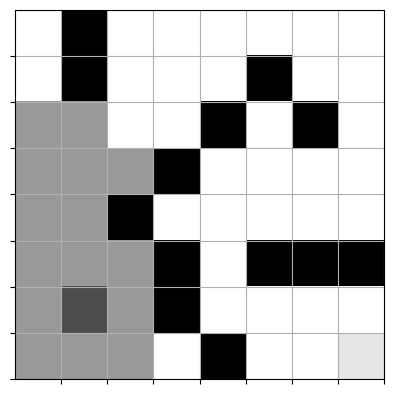

Epoch: 272/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 136 | Win rate: 0.594 | time: 11.94 minutes
   win | Epoch Reward: -5.82 | DLrLDlDDDuDDDDrLrLDldDDrrLDDuDlRDRR


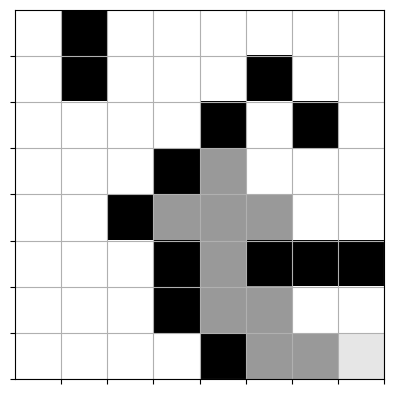

Epoch: 273/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 137 | Win rate: 0.625 | time: 11.99 minutes
   win | Epoch Reward: -10.319999999999997 | LDLrLLLLuLLLrLRLRLDDDDDDDDDDrLDRLLLLLLLLuLLLRDlDRRuRD


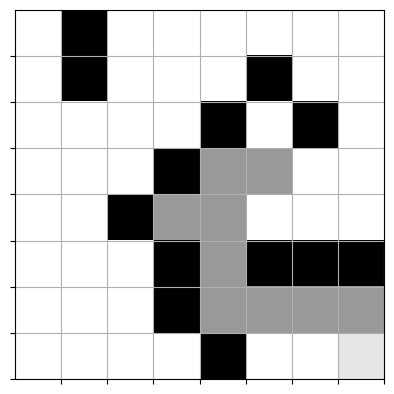

Epoch: 274/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 138 | Win rate: 0.625 | time: 12.02 minutes
   win | Epoch Reward: -0.5700000000000001 | LLLDDluDDlRrRD


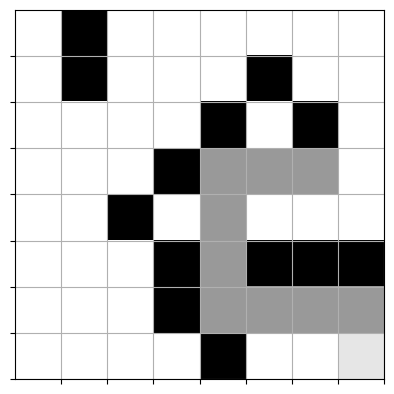

Epoch: 275/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 139 | Win rate: 0.625 | time: 12.06 minutes
   win | Epoch Reward: 0.3899999999999999 | DLLLdDRDlRr


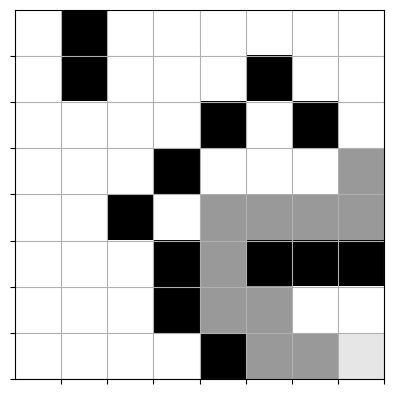

Epoch: 276/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 139 | Win rate: 0.594 | time: 12.13 minutes
   lose | Epoch Reward: -32.099999999999994 | rDDLLLDrRRLLlUUDDDDdDDDDUdUluDdDUUULlLDDURUurUDUrDlDRRRRlDDRRudUDUDDUDdUuDUdDUDuddRRRRRRRRRrlRDuRddRdRRRRlrRuDDDrDUrUUUdUlRLRRrLRDDlRlruRRuUU


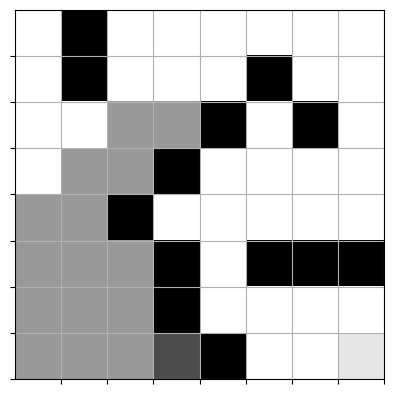

Epoch: 277/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 139 | Win rate: 0.562 | time: 12.21 minutes
   lose | Epoch Reward: -32.11 | DlDDUDUDUDUDUDLlLLLLLLLUUdURrDDUDLLDDDDDDDDulRDRUddULlDUDDURdRUDUDUDUDLLuLLLlDRRLLuuLLLLLLLDuRRlRDUDUDUDrLLLLLLRLRLUlDUDUDUdDUDlURuRDLLR


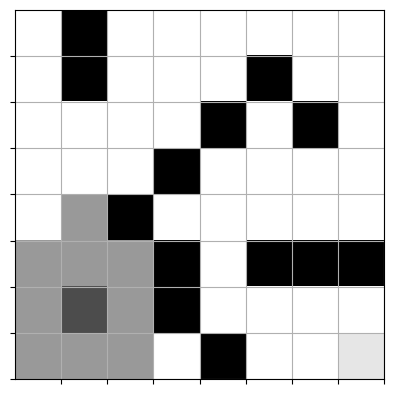

Epoch: 278/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 140 | Win rate: 0.562 | time: 12.24 minutes
   win | Epoch Reward: 0.76 | rDDRRRD


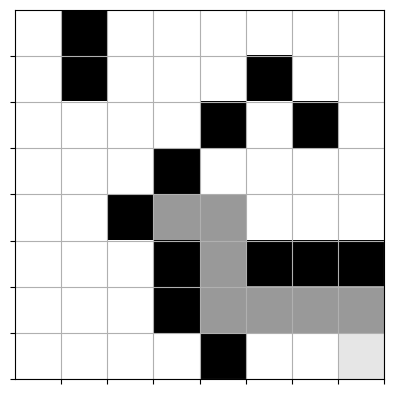

Epoch: 279/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 141 | Win rate: 0.562 | time: 12.27 minutes
   win | Epoch Reward: 0.04999999999999993 | DDRRlRRrD


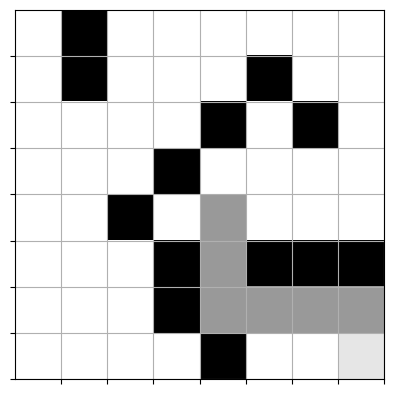

Epoch: 280/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 142 | Win rate: 0.594 | time: 12.31 minutes
   win | Epoch Reward: 0.51 | LDDRDdRR


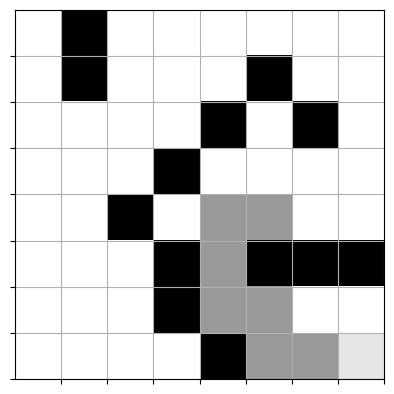

Epoch: 281/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 143 | Win rate: 0.594 | time: 12.34 minutes
   win | Epoch Reward: 0.4700000000000001 | dLLDDrdRR


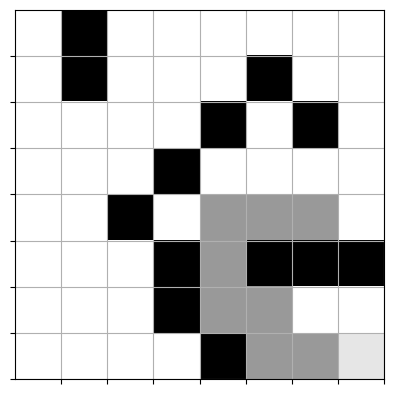

Epoch: 282/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 144 | Win rate: 0.625 | time: 12.38 minutes
   win | Epoch Reward: -0.40000000000000036 | LuLLLLLLDDDRRRD


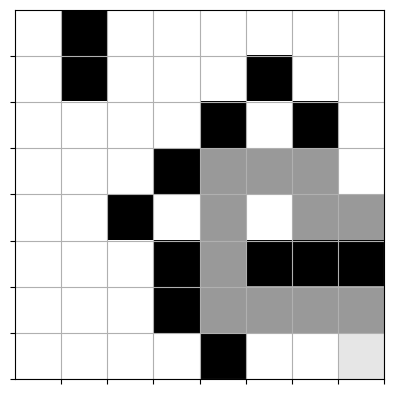

Epoch: 283/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 144 | Win rate: 0.594 | time: 12.45 minutes
   lose | Epoch Reward: -32.15 | udLLDRDRRRrdRRRDDlLRRRRRRRLdLRlrRuRRullRRRRrRdRRLLRLRLRLRlRLRuLUdURDDUurDUDrUDuDLRURluDRlRUUUUUdLDUDRRUUUUUuLLdRrRlRRRRluDLRUDUUDuUULuDuD


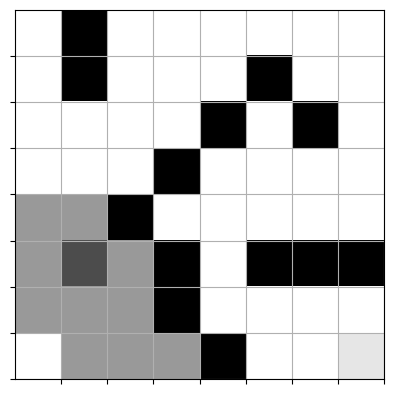

Epoch: 284/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 145 | Win rate: 0.594 | time: 12.51 minutes
   win | Epoch Reward: -12.359999999999985 | RDlRDlRRRRRlDLLLurLRRRRDRdllDLuUURllRRuRURDDDDdDDDruURRRRUUUUuDrDrDlLrDLLRLRLDDRDrR


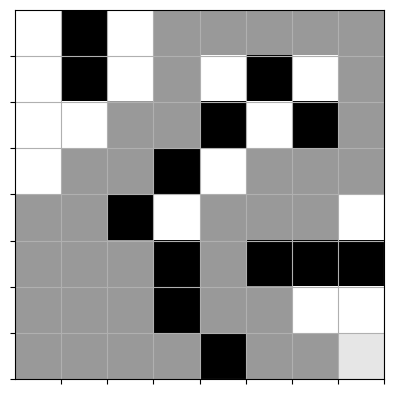

Epoch: 285/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 145 | Win rate: 0.562 | time: 12.59 minutes
   lose | Epoch Reward: -32.17999999999999 | dDrUUUUlUudDLUDUDLLUUUUUDDDuDDuUrULUDdddrLdrUUUrDDDlUUUuUUUluDDDDDDDUuDUuUUUURdURrDDuDDuDDlDUUlUUllUuLUURDDDuDuDDllrUULUUUUUrLLLLLLLUUlRRRRRRRU


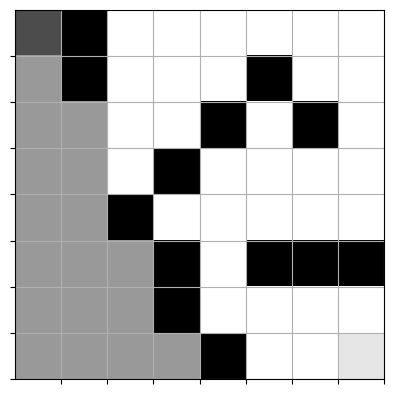

Epoch: 286/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 146 | Win rate: 0.562 | time: 12.62 minutes
   win | Epoch Reward: 0.84 | DRrRD


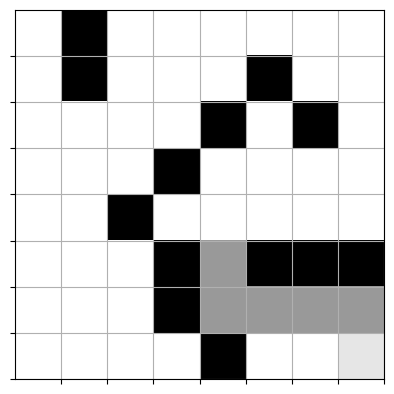

Epoch: 287/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 147 | Win rate: 0.562 | time: 12.66 minutes
   win | Epoch Reward: -1.2900000000000005 | duRUUUURuRURRRrDdDDLLddLDrDlRRRD


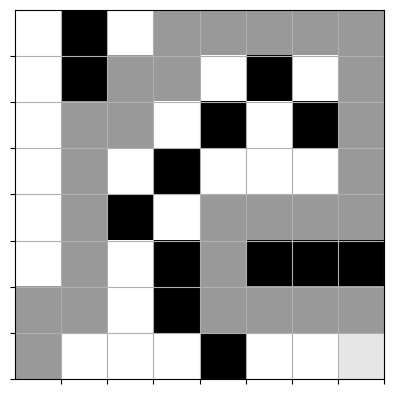

Epoch: 288/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 147 | Win rate: 0.531 | time: 12.74 minutes
   lose | Epoch Reward: -32.05999999999999 | RUUUUUdUUDlDURrUuUUUUuUllRrUUuUUUUUUrlulDrLDURRdRRRrrrLDLlrUUdrRRRULULUUdUUUUUUUULlLLLLRRRRRRRrUUrUUUDrDDDRDrUUUUUUUDrrDLLUUUUUuLLURRRRRRlRr


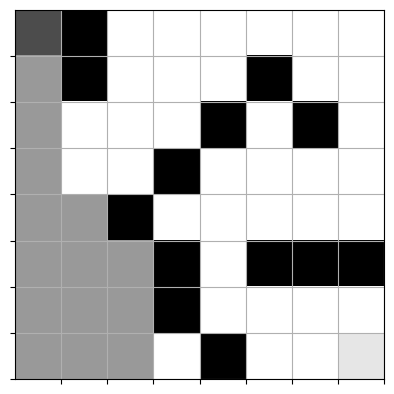

Epoch: 289/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 148 | Win rate: 0.562 | time: 12.80 minutes
   win | Epoch Reward: -12.43999999999998 | DrDDDrUurUUUUdUUuDldUlDLUuRULRrLlLLUULLLLDDRdUuRURUUduRuRRuRDDDDLruDlLuuldDDLDDuDRrdR


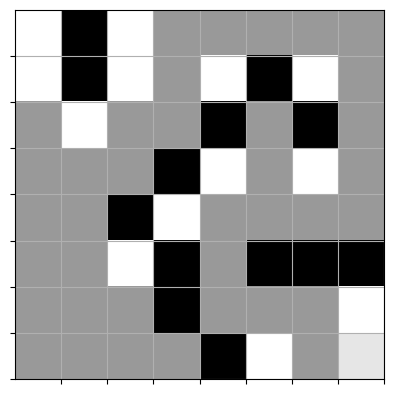

Epoch: 290/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 149 | Win rate: 0.562 | time: 12.83 minutes
   win | Epoch Reward: 0.88 | RRRD


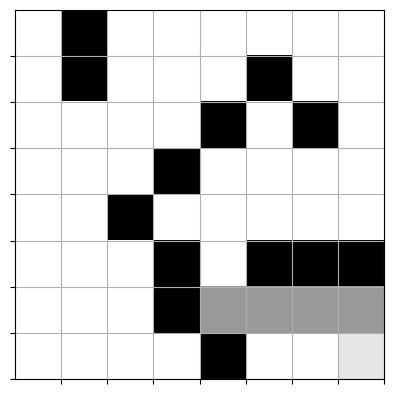

Epoch: 291/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 150 | Win rate: 0.594 | time: 12.86 minutes
   win | Epoch Reward: 0.92 | RRD


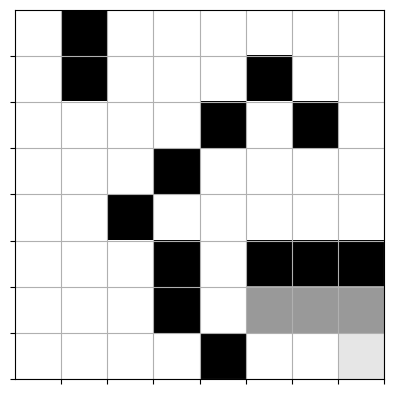

Epoch: 292/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 151 | Win rate: 0.625 | time: 12.89 minutes
   win | Epoch Reward: 0.45999999999999996 | uRrD


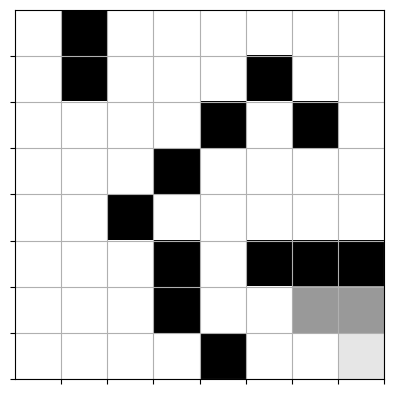

Epoch: 293/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 152 | Win rate: 0.625 | time: 12.92 minutes
   win | Epoch Reward: 1.0 | D


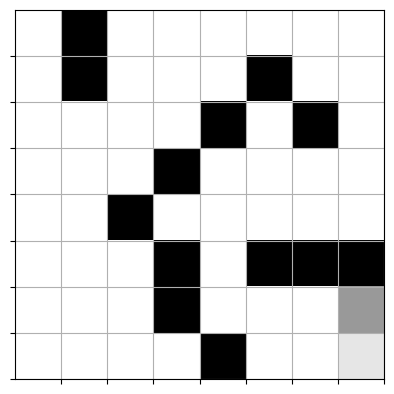

Epoch: 294/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 152 | Win rate: 0.594 | time: 13.00 minutes
   lose | Epoch Reward: -32.05 | RuUdDUUrlUUDDDUUUUURRlRUuDLDLLLLdDDrDrDlLUluDRRRLLRRRRdLLDDRLUUrDdLLLrUrDuURRRRRDrLLLLLlRUDUUUdrRdRRDDlrUUUUUUUUdUUUUUDURRddRRRddLRLUdlURDdRurLUr


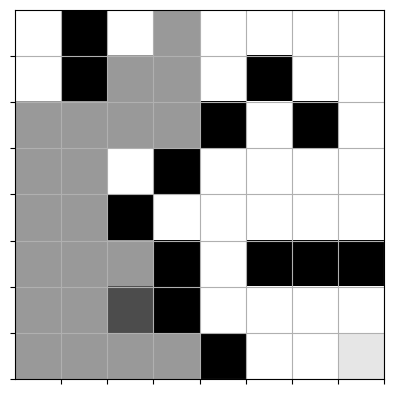

Epoch: 295/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 153 | Win rate: 0.625 | time: 13.05 minutes
   win | Epoch Reward: -10.319999999999993 | RuDULlLLLUURrURURuLrdLRLRRdURURRUlRUlRUUUrUDlURDDDDLddLlrudLDuDDRRlDRddlRR


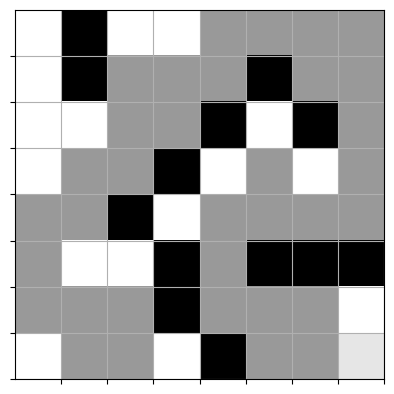

Epoch: 296/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 154 | Win rate: 0.656 | time: 13.10 minutes
   win | Epoch Reward: -5.620000000000001 | URdRRRRuDDdDDLULuUrURURUUDuRdlRRRurRRDDDDLLLDDRrruD


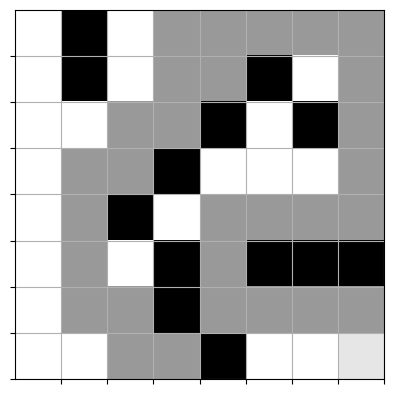

Epoch: 297/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 155 | Win rate: 0.688 | time: 13.16 minutes
   win | Epoch Reward: -9.90999999999999 | DdUuDDrDUuUUUUUUUdUUlUDlUUUUUrRURURRUUUUUUDUuDURUUrRRuDDDDLLLDuDDRdRR


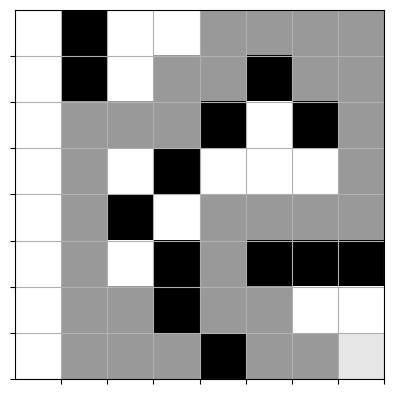

Epoch: 298/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 156 | Win rate: 0.719 | time: 13.19 minutes
   win | Epoch Reward: 0.20999999999999996 | dDRdR


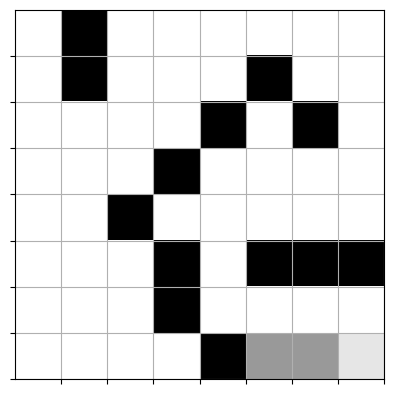

Epoch: 299/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 157 | Win rate: 0.719 | time: 13.22 minutes
   win | Epoch Reward: 1.0 | R


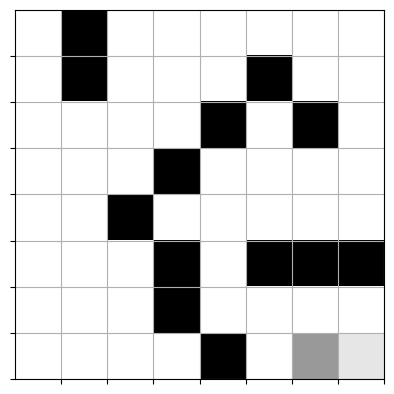

Epoch: 300/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 158 | Win rate: 0.719 | time: 13.27 minutes
   win | Epoch Reward: -9.649999999999984 | RLLLDDrDDDdLLLlrLDDDDUUlRUUURRURRRLUDdLDuDuRUUURRRRRlRDlrlRdDDLLLDDRDruRD


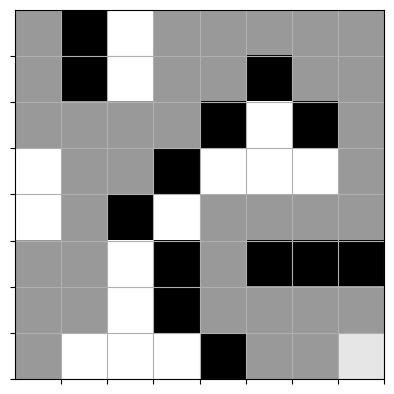

Epoch: 301/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 159 | Win rate: 0.750 | time: 13.32 minutes
   win | Epoch Reward: -3.0100000000000007 | RDRDDDDDDrulRRRRDDDDUUDDLLLDDRRRD


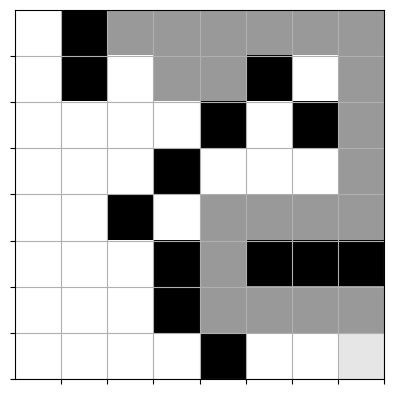

Epoch: 302/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 160 | Win rate: 0.781 | time: 13.37 minutes
   win | Epoch Reward: -10.04999999999999 | DUDUDRRRRlRRRRRRRRrRDDDDDURRRDuDldDDDDDDDDLrDDDLLuDLDDRluDRDRR


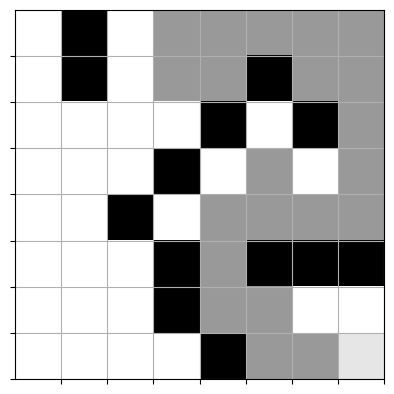

Epoch: 303/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 161 | Win rate: 0.812 | time: 13.41 minutes
   win | Epoch Reward: -4.390000000000001 | RRRDDDLLduRLRlRLRLRLRdLuRDLuDLdDRDRR


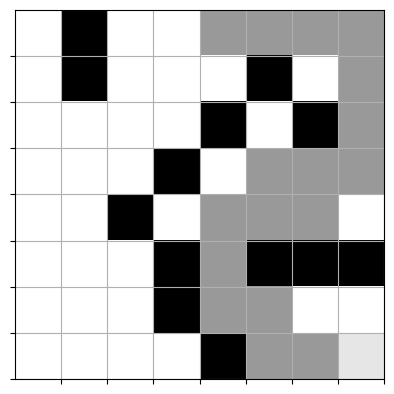

Epoch: 304/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 162 | Win rate: 0.812 | time: 13.46 minutes
   win | Epoch Reward: -3.6000000000000005 | RRRRRRDDDlRRdLLLRrLLRRuDLLDDRRRD


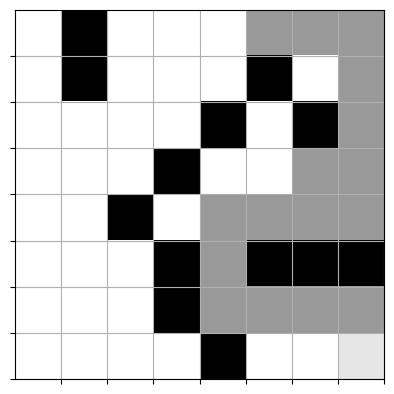

Epoch: 305/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 163 | Win rate: 0.812 | time: 13.49 minutes
   win | Epoch Reward: -0.5200000000000002 | RDDDDDDDLLLDDRdlRR


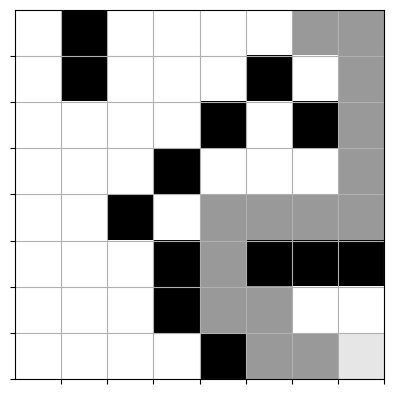

Epoch: 306/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 164 | Win rate: 0.812 | time: 13.53 minutes
   win | Epoch Reward: -0.27000000000000046 | uDDrDdLLuDLDDRDRR


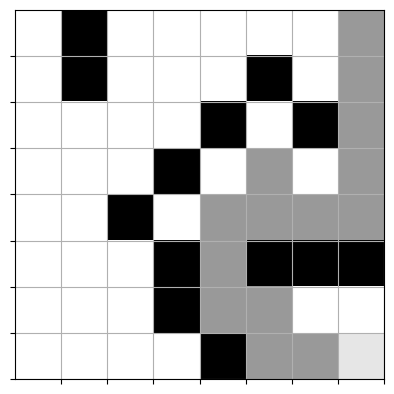

Epoch: 307/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 165 | Win rate: 0.812 | time: 13.58 minutes
   win | Epoch Reward: -8.359999999999994 | UlDUuuDDDDDDDUUUrUduUDUDRdURURLLDDDuUDUURDRURRrDDDDUDUDrLLrLLDDRDRR


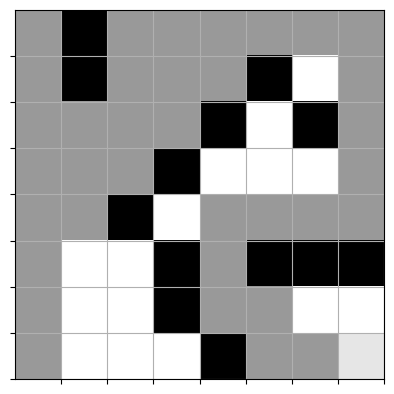

Epoch: 308/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 166 | Win rate: 0.844 | time: 13.62 minutes
   win | Epoch Reward: -2.0100000000000007 | uRRRRRDuDlLURDDuDDrDLlLDDRDRR


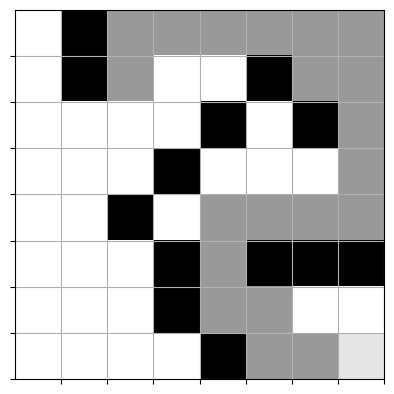

Epoch: 309/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 167 | Win rate: 0.875 | time: 13.69 minutes
   win | Epoch Reward: -15.02999999999998 | RRdLRrLLRLRRRrRRRRLDULRLRLRRRRRLlDLLrLUURRRDDDDrURdURURURRRlRDDDDLUDUUUUUULULLdLRLDDDulDRDRR


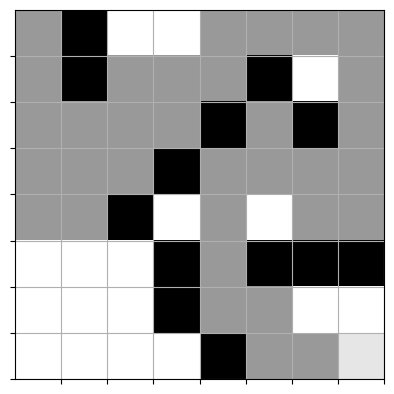

Epoch: 310/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 168 | Win rate: 0.875 | time: 13.73 minutes
   win | Epoch Reward: -3.9300000000000006 | URdRRDLURlDDLURdLURlRDDDLULLdDDRDRR


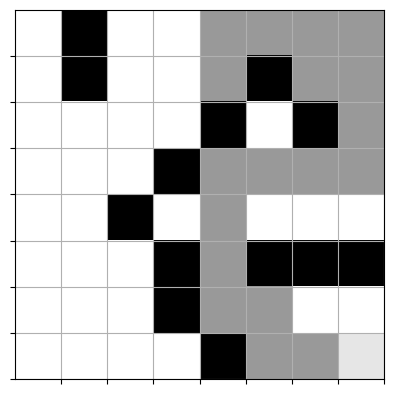

Epoch: 311/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 169 | Win rate: 0.875 | time: 13.76 minutes
   win | Epoch Reward: 0.44000000000000006 | uRdDDDLLLDDRDRR


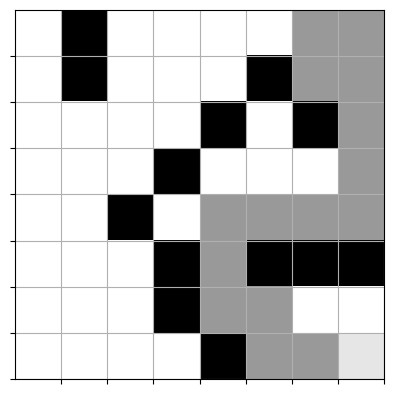

Epoch: 312/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 170 | Win rate: 0.875 | time: 13.80 minutes
   win | Epoch Reward: 0.05999999999999961 | DDuDDLLLDDRDRR


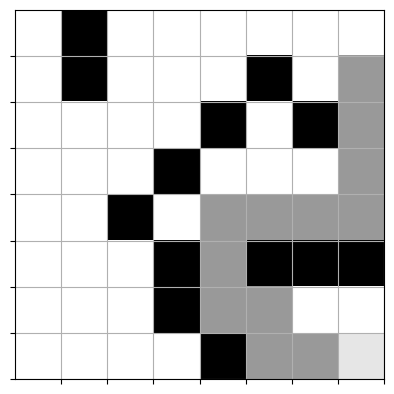

Epoch: 313/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 171 | Win rate: 0.875 | time: 13.85 minutes
   win | Epoch Reward: -3.16 | DDRuRURUlUDUDURRRRRlDdLLLrDDDLLLDDRDudruDR


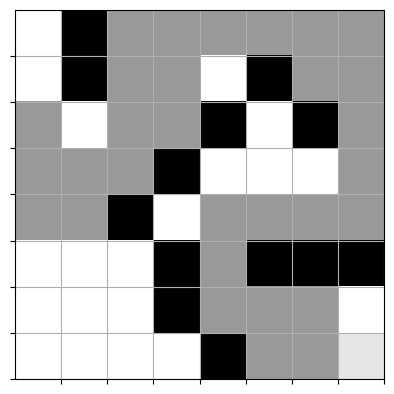

Epoch: 314/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 171 | Win rate: 0.844 | time: 13.93 minutes
   lose | Epoch Reward: -32.00999999999999 | LUULDDdDlRdLRRLRLRdLLRURDUDUDULlRRLuLRLdRRLRLuLRDDdLlUrLRLRDRLLUDRuUlRrdLLDUlrURDDruLULLuRluRURUdULLDDDDdRRRRRRRRDDDLLLRLrrRRRdUdUUUrUUUULLLRRRR


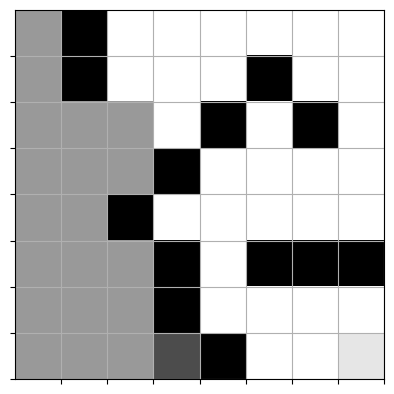

Epoch: 315/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 172 | Win rate: 0.875 | time: 13.97 minutes
   win | Epoch Reward: -2.130000000000001 | RRUUDUDlRRURRRDDDLLrLuddLDDRDdrR


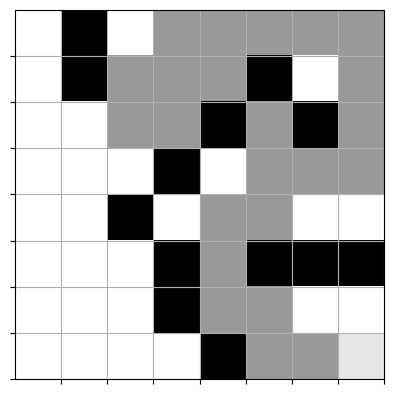

Epoch: 316/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 173 | Win rate: 0.875 | time: 14.02 minutes
   win | Epoch Reward: -7.579999999999993 | DdDDDDLLLDDluDRLRURUdUuURUrlUUUUUUUUUUUURRRRDDDrLLLDDDRRRD


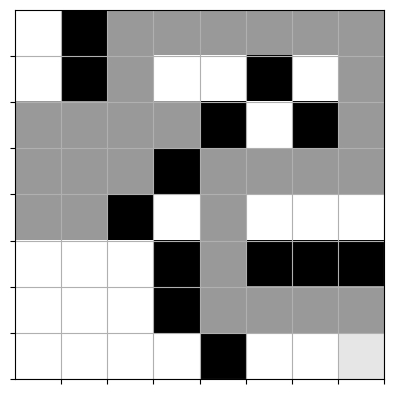

Epoch: 317/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 174 | Win rate: 0.906 | time: 14.06 minutes
   win | Epoch Reward: -3.8600000000000003 | UDLDlDDDDDDdDRUrLRLDDuDDRRRD


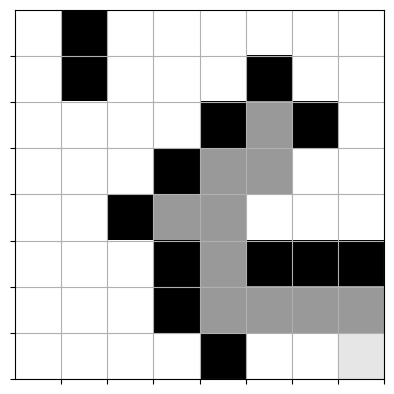

Epoch: 318/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 175 | Win rate: 0.906 | time: 14.10 minutes
   win | Epoch Reward: 0.34999999999999987 | DdLLdLDDRDRR


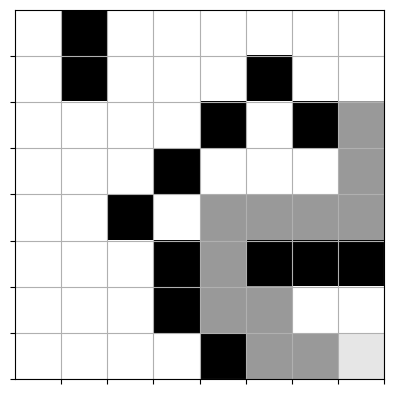

Epoch: 319/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 176 | Win rate: 0.906 | time: 14.14 minutes
   win | Epoch Reward: -1.4600000000000004 | DRURURUDUDUDURURRRDDDDLLLDDRDRR


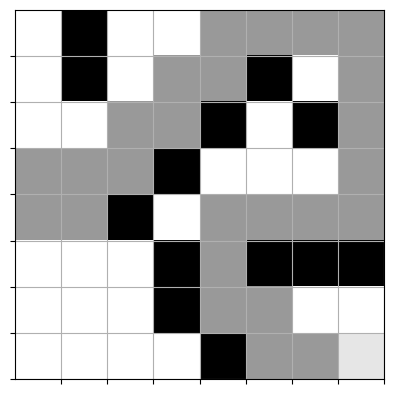

Epoch: 320/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 176 | Win rate: 0.906 | time: 14.22 minutes
   lose | Epoch Reward: -32.19 | DDRDDUUDUDDRRRLLuLURRDDRDDDDLLLUURRDDRDDDURRRRRLLLRRRRduUUURRruDDDRRRLLLUuRRDRRRRLLDUDUDURRRRRLLDUDRURRRLLDUDUDRULddUDUDURRRRRRlLDUdRRRRDD


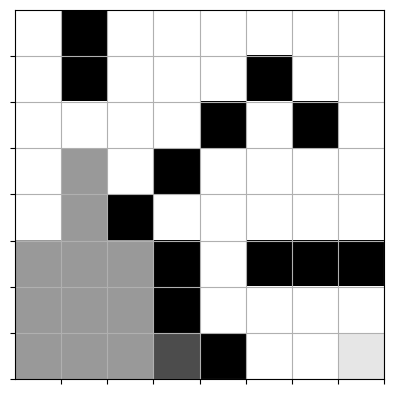

Epoch: 321/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 176 | Win rate: 0.875 | time: 14.30 minutes
   lose | Epoch Reward: -32.2 | ULLrLUULLLLLLLDUUUUUUUUrUUUDUDUDUDUDUDUDULLLDURLLLLLLLLLUUUUDUdUDULLrLDUDUuRDUDUDURRRLLLDrUDUDUDULLLLlLLLLLLLLDULLUUUlUUULLLLLUURRRLL


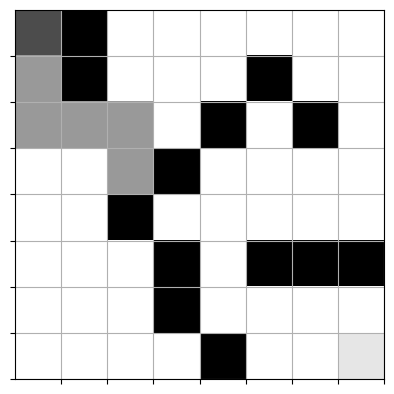

Epoch: 322/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 177 | Win rate: 0.875 | time: 14.33 minutes
   win | Epoch Reward: 0.6799999999999999 | RDLDDRRRD


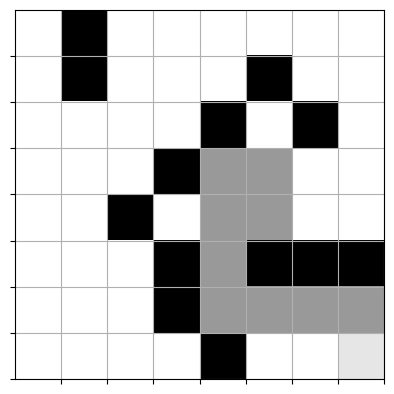

Epoch: 323/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 178 | Win rate: 0.875 | time: 14.37 minutes
   win | Epoch Reward: 0.42999999999999994 | dLDDRRlDRR


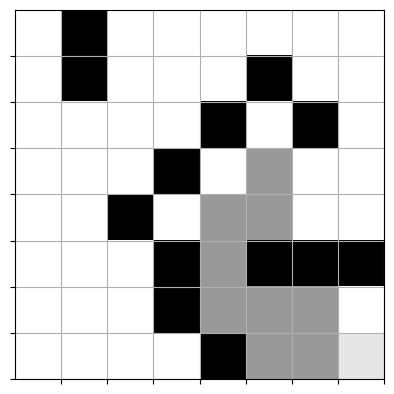

Epoch: 324/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 179 | Win rate: 0.875 | time: 14.40 minutes
   win | Epoch Reward: 0.6799999999999999 | LLDDDRRRD


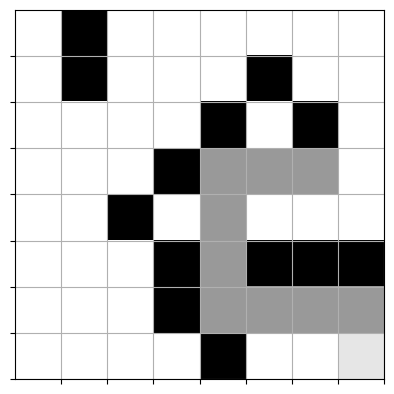

Epoch: 325/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 180 | Win rate: 0.875 | time: 14.44 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


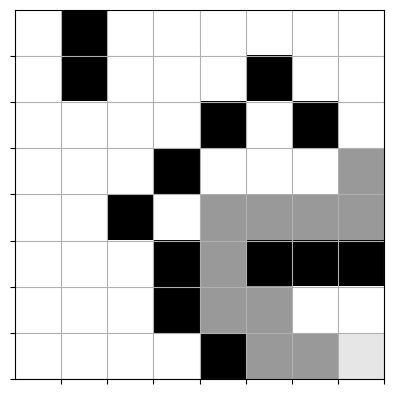

Epoch: 326/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 181 | Win rate: 0.906 | time: 14.48 minutes
   win | Epoch Reward: -0.7100000000000006 | RURRRUlRRURURrRDDDDLLLDDRRRD


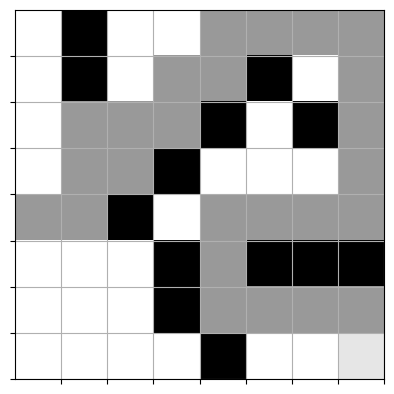

Epoch: 327/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 181 | Win rate: 0.875 | time: 14.57 minutes
   lose | Epoch Reward: -32.099999999999994 | LULDDDUDUDRDRULLUUUUDDRDUDLDUURLRULDRDLDRDlRLLLLLLLUUURDURRRRUULDDDDUUDUDDUDUUULUdDDDRDLRdLUDUUUUUUUDUDUDUDUUuLDUDUDULLLLLLUUUDUDRRRRRRUUUUUU


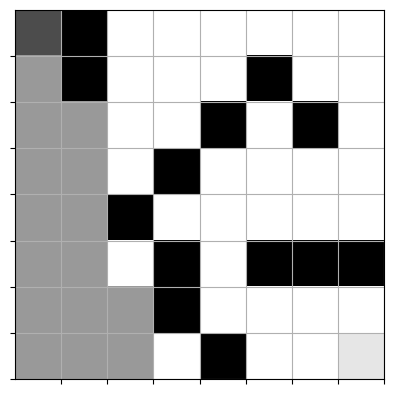

Epoch: 328/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 182 | Win rate: 0.875 | time: 14.60 minutes
   win | Epoch Reward: -1.4900000000000002 | DDuDDDDDDRDDRRRD


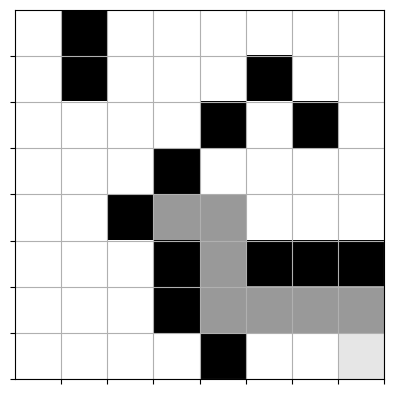

Epoch: 329/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 183 | Win rate: 0.875 | time: 14.64 minutes
   win | Epoch Reward: 0.8 | DDRDRR


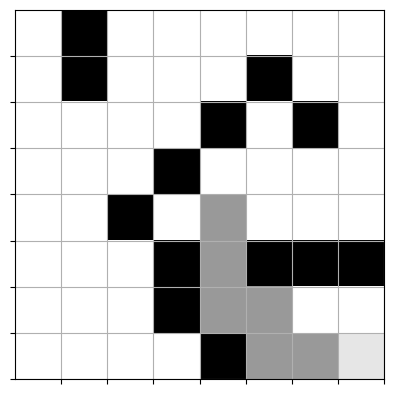

Epoch: 330/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 184 | Win rate: 0.875 | time: 14.67 minutes
   win | Epoch Reward: -1.0300000000000002 | LLLLLLLLRDDRRRD


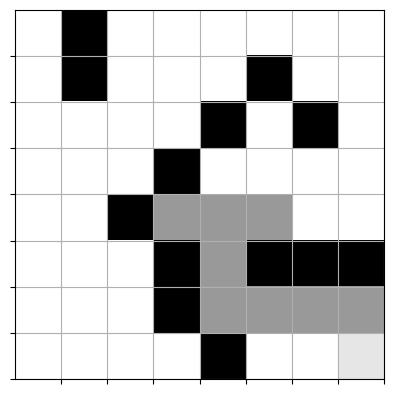

Epoch: 331/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 185 | Win rate: 0.875 | time: 14.73 minutes
   win | Epoch Reward: -13.819999999999997 | LLLLLrLLLLLLLLLLLLLLLlLLULLlLLLLLLLLLLdLUUULLLUlUDDDDDDUUUUUrDDRDRR


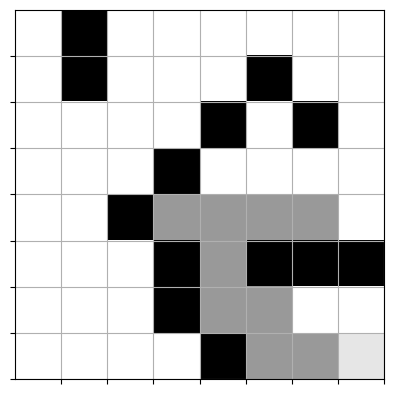

Epoch: 332/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 186 | Win rate: 0.875 | time: 14.77 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDDRRRD


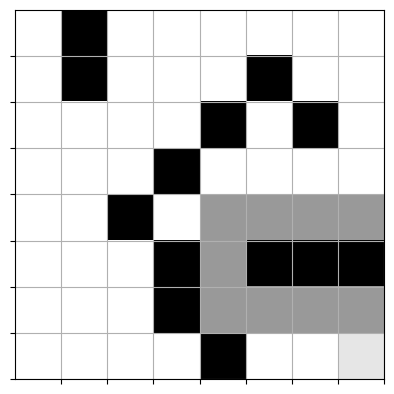

Epoch: 333/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 187 | Win rate: 0.875 | time: 14.81 minutes
   win | Epoch Reward: -0.4600000000000004 | RUURURUrURrRDDDDLLLDDRRlRRD


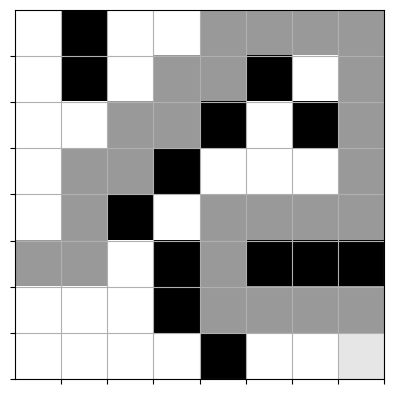

Epoch: 334/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 188 | Win rate: 0.875 | time: 14.85 minutes
   win | Epoch Reward: -0.17000000000000037 | UrURUrURURRRDDDDLLLDDRRRD


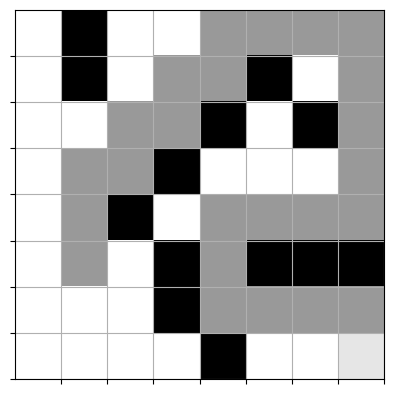

Epoch: 335/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 188 | Win rate: 0.844 | time: 14.93 minutes
   lose | Epoch Reward: -32.16 | DDUDUDuDUDUDUDUDUDuDUDUDUdUDUDUDDDlRDUDUDUDUDUDUDUDUDDDDDDDDDDUDUDDDDDDUDdUUUUDDDDUDUDUDUDUDUDRDDDDDRRRRRRRDDDDDrDDDDDDDDDDDDDDDdRRR


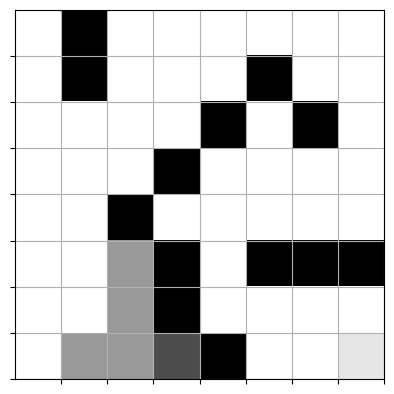

Epoch: 336/999 | Loss: 0.0016 | Episodes: 1000 | Win count: 189 | Win rate: 0.844 | time: 14.97 minutes
   win | Epoch Reward: 0.84 | DRDRR


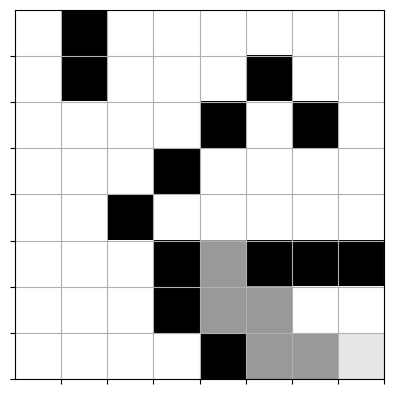

Epoch: 337/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 189 | Win rate: 0.812 | time: 15.05 minutes
   lose | Epoch Reward: -32.07 | LLLURRRdRRDRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRDRRRRRRRRDDrRRRRRRRRRRRRRRRLUUDRRRRRRRUDUDUDUDUDUDRRuDRDLLRRUUDRRRDUDUDUDRRRRRRRLUrDLRr


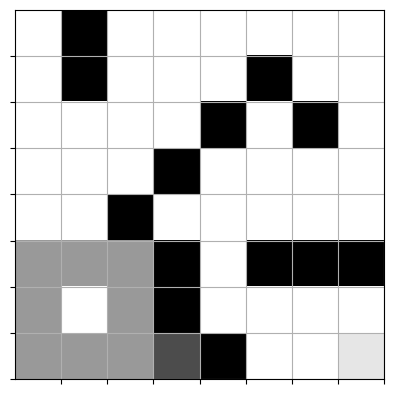

Epoch: 338/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 189 | Win rate: 0.781 | time: 15.13 minutes
   lose | Epoch Reward: -32.03 | DLLLRLRLRLRLDDDURlRRDuDUUDDUDRDDDDDDLLLRLRLRLUDUDURRUDDUDrDDDuUUUUUUUUDDrRRdRRRRRUUURRRRRDDDRRRRRUUUUUUDDDRRRRDDDUUddUUUURRRRRddRRRRRR


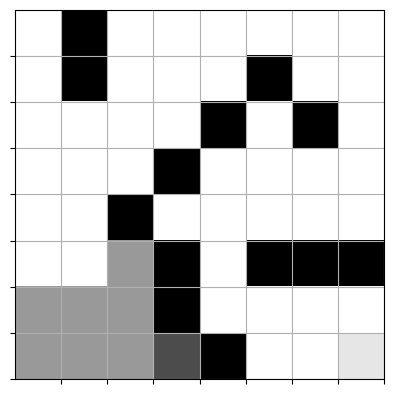

Epoch: 339/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 189 | Win rate: 0.750 | time: 15.21 minutes
   lose | Epoch Reward: -32.12 | RRRRRDRDDDDRlRRDDDDDDRRRRRRUUUrUUUlRDDDDDDluRRRUDUDUDUDUDUDUDDRDDDDRRRRRRRUUUUDDDDDDDRRRrdRRDDDDDDDDDDRRRRRUUlRUUDDDDDDDDRRRRRRdRRR


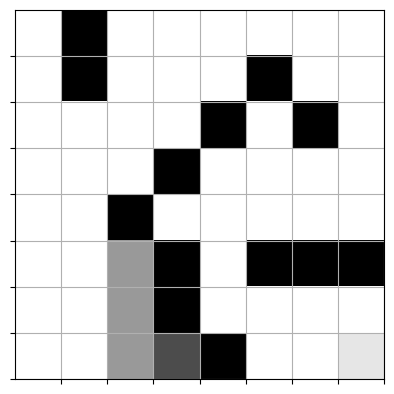

Epoch: 340/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 190 | Win rate: 0.750 | time: 15.24 minutes
   win | Epoch Reward: 0.88 | RRRD


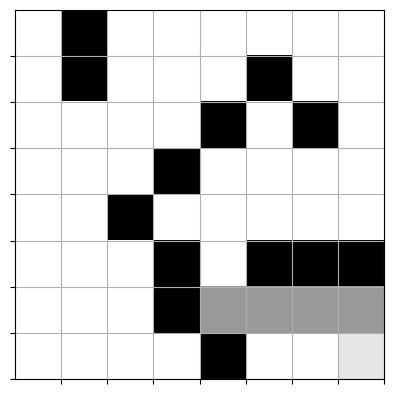

Epoch: 341/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 191 | Win rate: 0.750 | time: 15.28 minutes
   win | Epoch Reward: 0.92 | RRD


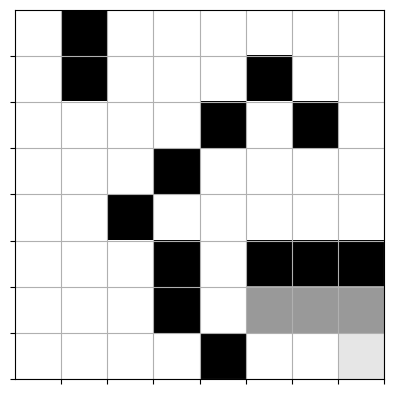

Epoch: 342/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 192 | Win rate: 0.750 | time: 15.31 minutes
   win | Epoch Reward: 0.96 | RD


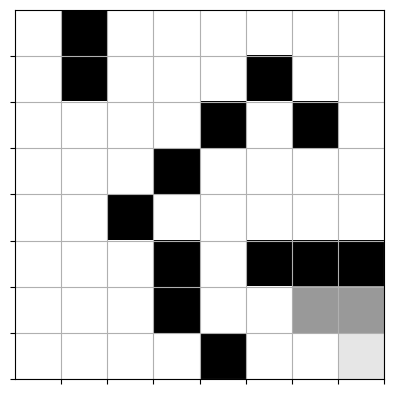

Epoch: 343/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 193 | Win rate: 0.750 | time: 15.34 minutes
   win | Epoch Reward: 1.0 | D


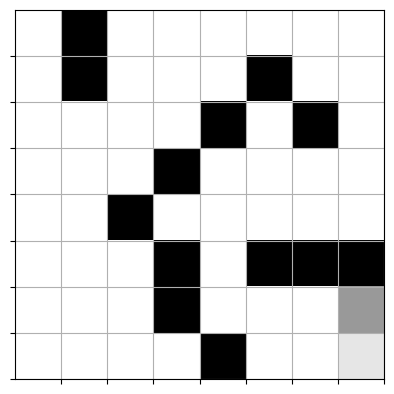

Epoch: 344/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 194 | Win rate: 0.750 | time: 15.39 minutes
   win | Epoch Reward: -3.240000000000001 | rLULLURUURUuURDRURdRRDDDDLUDUDUDUDLuDLdDRRRD


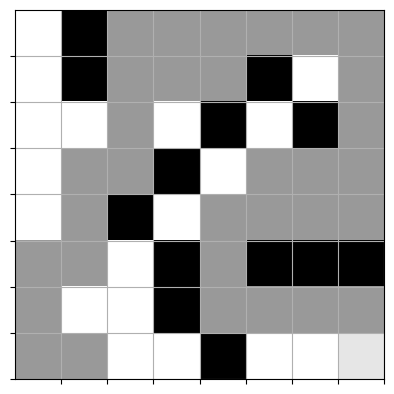

Epoch: 345/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 194 | Win rate: 0.719 | time: 15.47 minutes
   lose | Epoch Reward: -32.07 | UUUUULUURRRRuRRRRRRUUUUlUULLLLRRRUUUUUUURRUlDuULLLUUUUUUUUDUDURRDDUDUDUDUDUURRRRuRRULLLLLLLlUUURRRRRRRlRUUUUULLLLLLLLLLLLLLLLLLUUUUUDUl


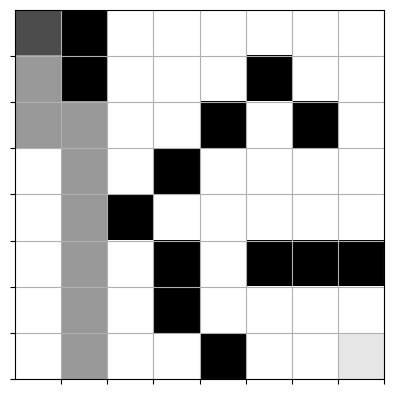

Epoch: 346/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 195 | Win rate: 0.750 | time: 15.54 minutes
   win | Epoch Reward: -16.909999999999975 | RRDDDUUUUUURRRRRRRRRRRRRRRRRRRRUUUUUULRdLDDRLRRRRRUUUUUUURRRRRRRLDDLLUULRUURURURURRRDDDDLLLDDRRRD


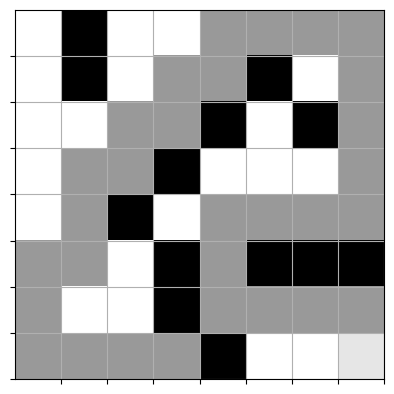

Epoch: 347/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 196 | Win rate: 0.750 | time: 15.60 minutes
   win | Epoch Reward: -10.159999999999986 | UDDDDDDDDUUURUUUUUUUUUUUUUUUULLLUURUURUUUuRRRRRDDDLLLRLRLRLRLDDuDDRRRD


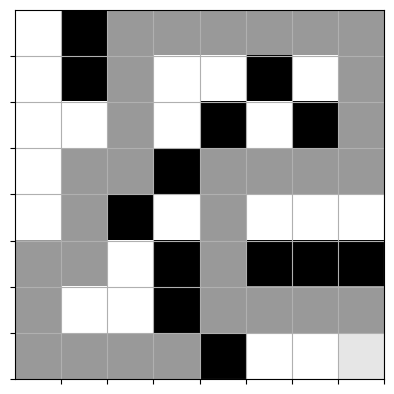

Epoch: 348/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 197 | Win rate: 0.750 | time: 15.64 minutes
   win | Epoch Reward: 0.96 | RR


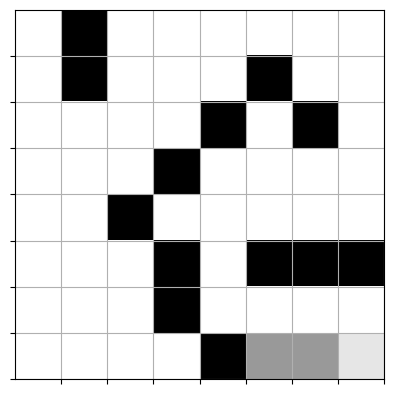

Epoch: 349/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 198 | Win rate: 0.750 | time: 15.67 minutes
   win | Epoch Reward: 1.0 | R


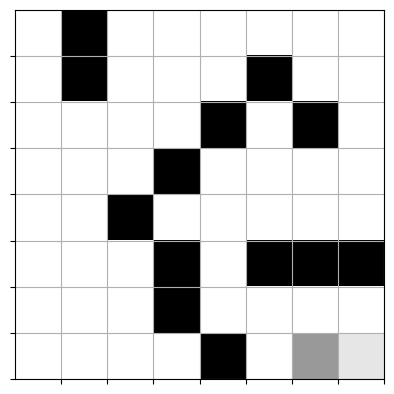

Epoch: 350/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 199 | Win rate: 0.750 | time: 15.71 minutes
   win | Epoch Reward: -1.5000000000000009 | LLDUDDDrRURURURRRDDDDLLrLLDDRDRR


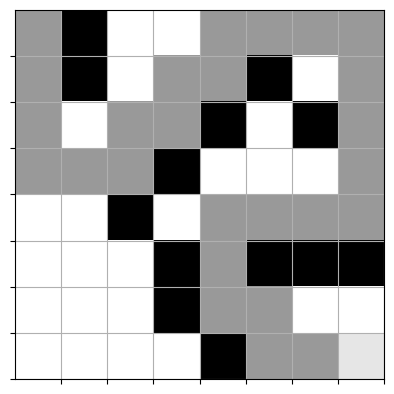

Epoch: 351/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 200 | Win rate: 0.750 | time: 15.75 minutes
   win | Epoch Reward: 0.06999999999999962 | RRRRRRDDDDLLLDDRRRD


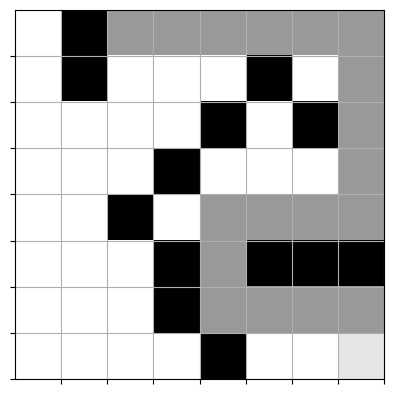

Epoch: 352/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 201 | Win rate: 0.781 | time: 15.79 minutes
   win | Epoch Reward: -0.14000000000000057 | RRlRRRDDDDLLLDDRrRD


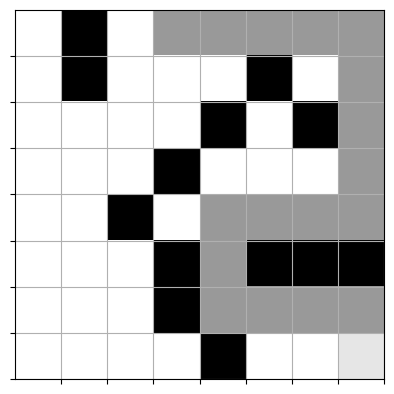

Epoch: 353/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 202 | Win rate: 0.812 | time: 15.84 minutes
   win | Epoch Reward: -1.8900000000000006 | RRRDDrDDrLuRLRLRDLLLDDRDRR


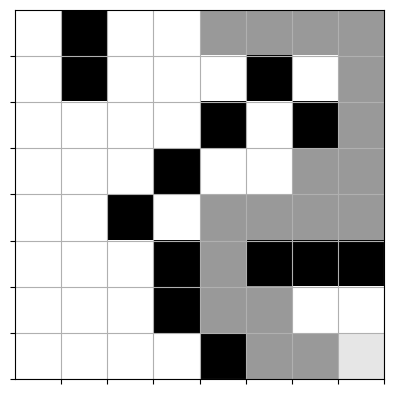

Epoch: 354/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 203 | Win rate: 0.812 | time: 15.88 minutes
   win | Epoch Reward: 0.44000000000000006 | RRDDDDLLLDDRRRD


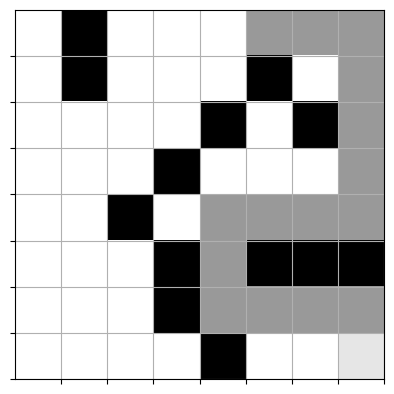

Epoch: 355/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 204 | Win rate: 0.812 | time: 15.92 minutes
   win | Epoch Reward: 0.4800000000000001 | DRDDDLLLDDRDRR


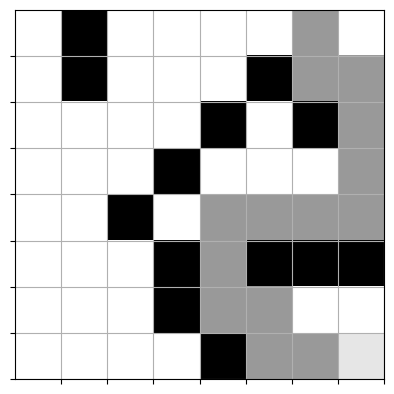

Epoch: 356/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 205 | Win rate: 0.812 | time: 15.96 minutes
   win | Epoch Reward: -0.2300000000000002 | rDDDDuDLLLDDRDRR


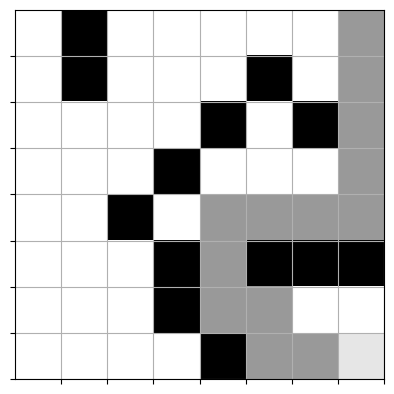

Epoch: 357/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 206 | Win rate: 0.812 | time: 16.02 minutes
   win | Epoch Reward: -8.569999999999995 | UDUDDDDUUUUDDDDDDDUURUURUUUDUDURDURRRRDDDDLUUDUUUUuUUUUUDUDLLDDRRRD


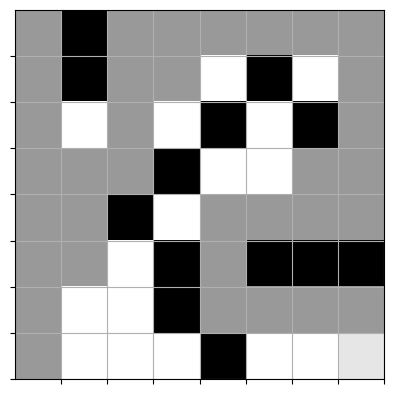

Epoch: 358/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 207 | Win rate: 0.812 | time: 16.07 minutes
   win | Epoch Reward: -6.840000000000001 | RuRRlRRRlRDDDDLLLURUUUUUUUUUUUUURRRUUUULLDDLDDRRRD


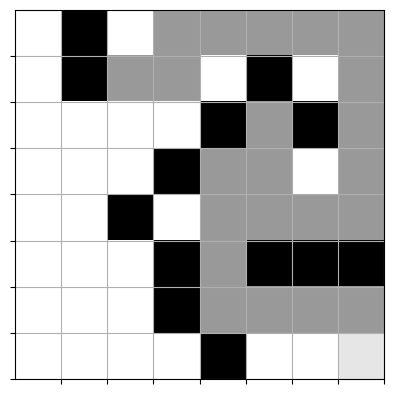

Epoch: 359/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 208 | Win rate: 0.844 | time: 16.11 minutes
   win | Epoch Reward: 0.31999999999999995 | RURRRDDDDlLLDDRDRR


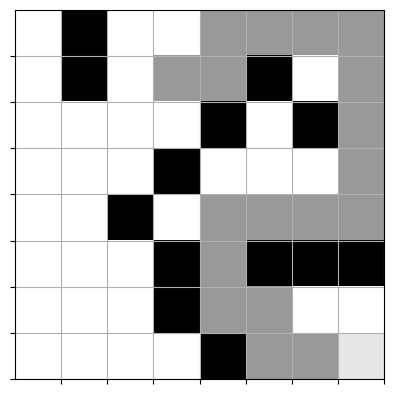

Epoch: 360/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 209 | Win rate: 0.844 | time: 16.15 minutes
   win | Epoch Reward: 0.36 | URRRDDDDLLLDDRRRD


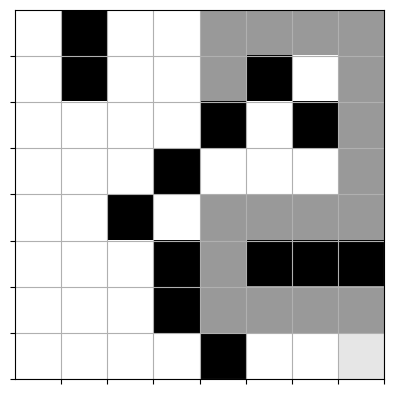

Epoch: 361/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 210 | Win rate: 0.844 | time: 16.19 minutes
   win | Epoch Reward: -1.2300000000000004 | DDDDDLRDDDLLdLDDRrRD


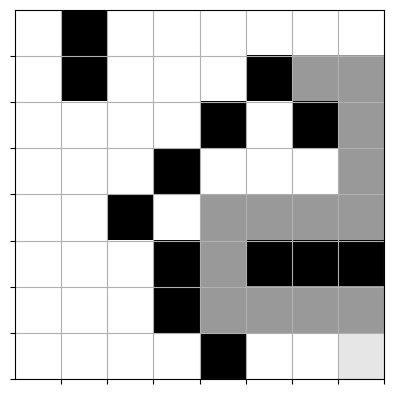

Epoch: 362/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 211 | Win rate: 0.844 | time: 16.22 minutes
   win | Epoch Reward: 0.56 | DDDLLLDDRDRR


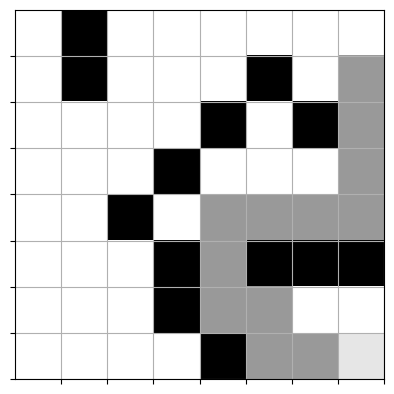

Epoch: 363/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 211 | Win rate: 0.812 | time: 16.31 minutes
   lose | Epoch Reward: -32.019999999999996 | DDDRRUDLUULDLDDRRRDDDDDLLLRLUDUDUDDDUDRLRLLLRRRRRRuUUDDDDDDUUUUUURRRRLLLRLUDRLUDUDUDuDUDURRdRRRDDDLRLRLRDDDDDRRRLRLRDDDDUUUUDDDDUUUUUUUUULU


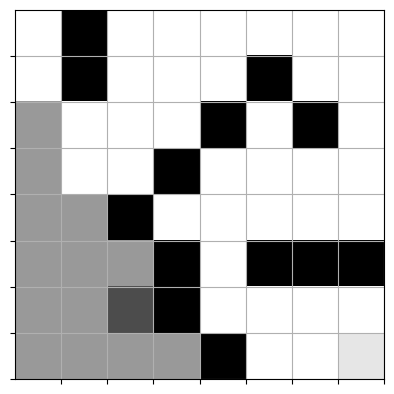

Epoch: 364/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 212 | Win rate: 0.812 | time: 16.35 minutes
   win | Epoch Reward: -0.4200000000000006 | DRUULRRURRRDDDDLLLUDDDRDRR


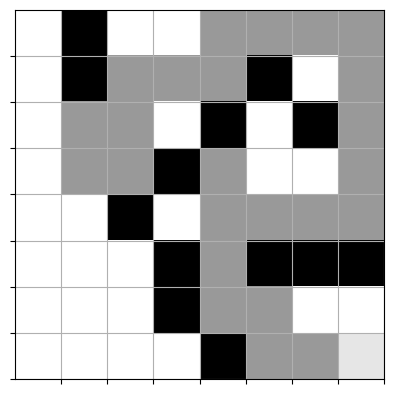

Epoch: 365/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 213 | Win rate: 0.812 | time: 16.39 minutes
   win | Epoch Reward: -0.8000000000000005 | RUURuRRRDDDDLLLrLlRDDRRRD


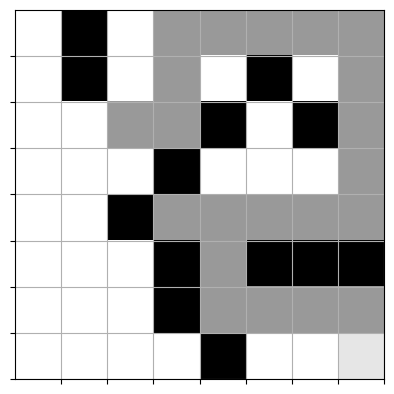

Epoch: 366/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 214 | Win rate: 0.812 | time: 16.44 minutes
   win | Epoch Reward: -1.4700000000000006 | RRRRRRUURRURRDDDDLLLDDRDRR


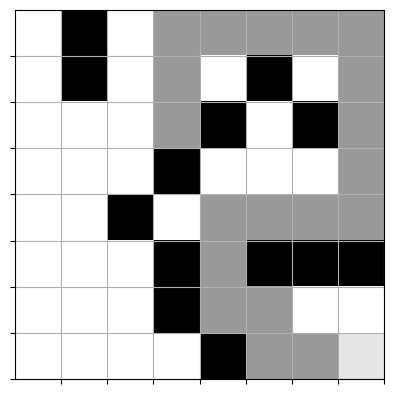

Epoch: 367/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 215 | Win rate: 0.844 | time: 16.47 minutes
   win | Epoch Reward: -0.07000000000000006 | LDDLrLDDRRRD


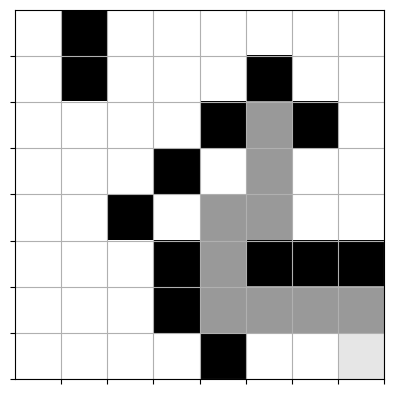

Epoch: 368/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 216 | Win rate: 0.844 | time: 16.51 minutes
   win | Epoch Reward: 0.6000000000000001 | DDLLLDDRDRR


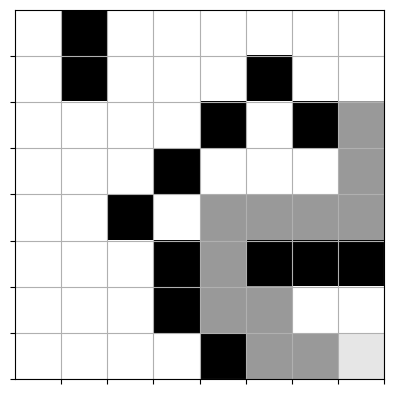

Epoch: 369/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 217 | Win rate: 0.875 | time: 16.56 minutes
   win | Epoch Reward: -2.960000000000001 | RuDRDLRLRURrURUDUDURRRDDDDLUDLLDDRDRR


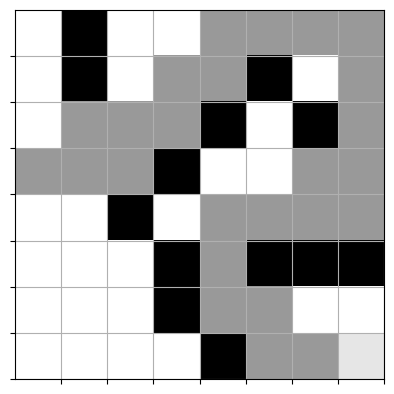

Epoch: 370/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 218 | Win rate: 0.906 | time: 16.61 minutes
   win | Epoch Reward: -9.499999999999996 | RUURRLuRRdRRDDDDLLLURULRRRRRRRRRRRRRRRDULLLRRRRRRRRRRDUDDLDDRRdR


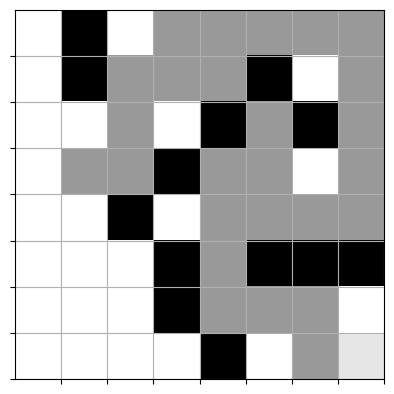

Epoch: 371/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 219 | Win rate: 0.938 | time: 16.67 minutes
   win | Epoch Reward: -13.339999999999995 | UUURRRRRDDDLLURRRUUUULLLUUUURRRRUURDUDUDUDUUUuURRRRRLLLLLLLRRRRRRDLDDDRRlRRD


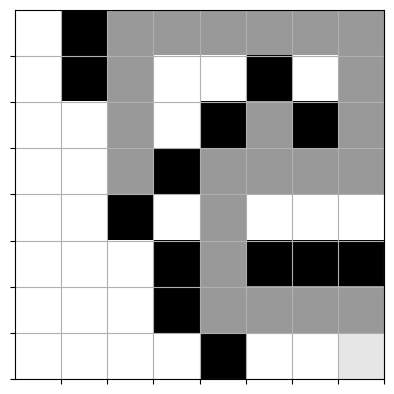

Epoch: 372/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 220 | Win rate: 0.938 | time: 16.71 minutes
   win | Epoch Reward: 0.6799999999999999 | RDLDDRRRD


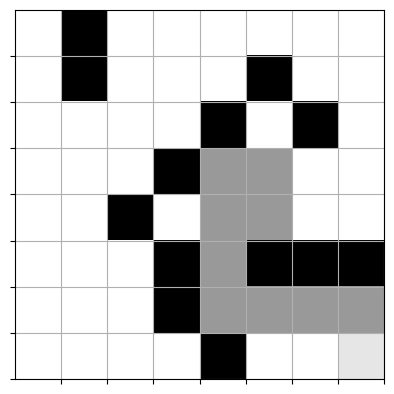

Epoch: 373/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 221 | Win rate: 0.938 | time: 16.75 minutes
   win | Epoch Reward: 0.72 | DLDDRDRR


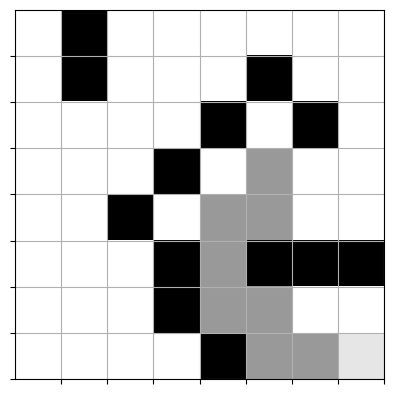

Epoch: 374/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 222 | Win rate: 0.938 | time: 16.78 minutes
   win | Epoch Reward: 0.42999999999999994 | DLLDDRRRrD


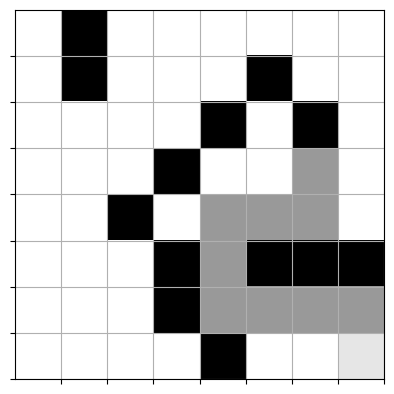

Epoch: 375/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 223 | Win rate: 0.938 | time: 16.82 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


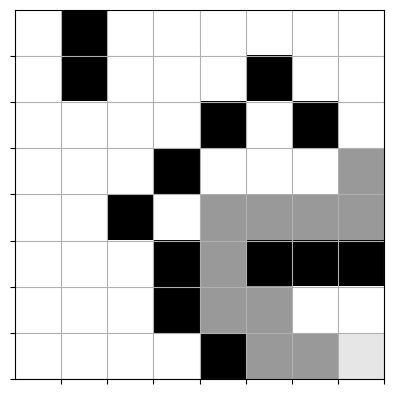

Epoch: 376/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 224 | Win rate: 0.938 | time: 16.86 minutes
   win | Epoch Reward: -1.4600000000000009 | RRRUURUURRRRRDDDDLdURDLLLDDRDRR


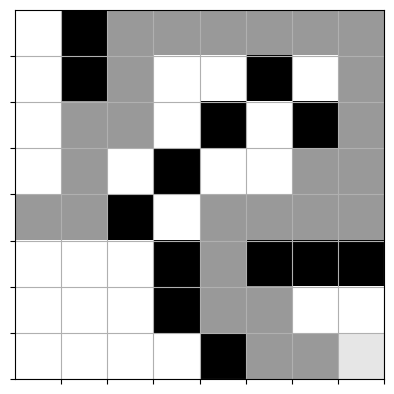

Epoch: 377/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 225 | Win rate: 0.969 | time: 16.91 minutes
   win | Epoch Reward: -1.1700000000000004 | UURrUURRRRDlURDDDUDDLLLDDRRRD


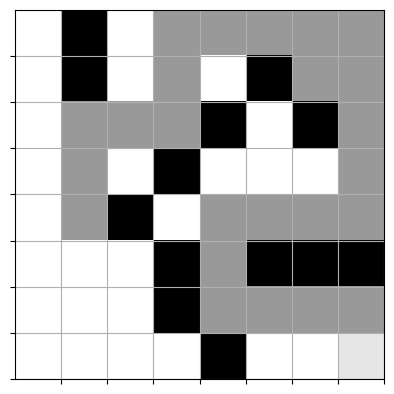

Epoch: 378/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 226 | Win rate: 0.969 | time: 16.94 minutes
   win | Epoch Reward: 0.76 | RDDRRRD


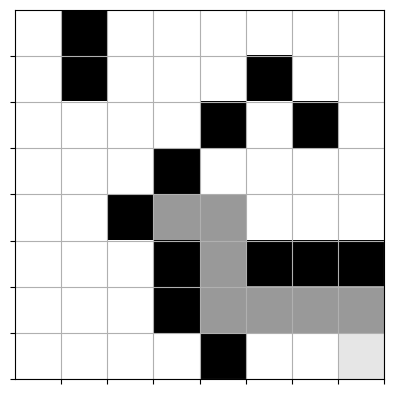

Epoch: 379/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 227 | Win rate: 0.969 | time: 16.98 minutes
   win | Epoch Reward: 0.8 | DDRDRR


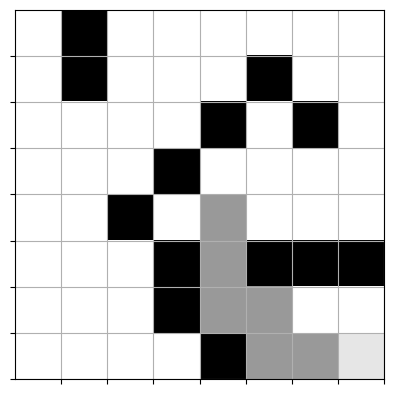

Epoch: 380/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 228 | Win rate: 0.969 | time: 17.02 minutes
   win | Epoch Reward: -1.6100000000000003 | RLuLRLRLRLRLDDDRRRD


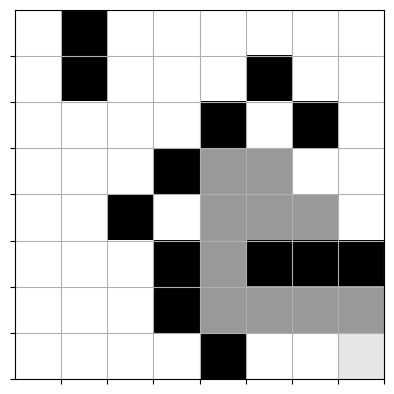

Epoch: 381/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 229 | Win rate: 0.969 | time: 17.06 minutes
   win | Epoch Reward: -0.40000000000000036 | ULUUULDDLDDRRdR


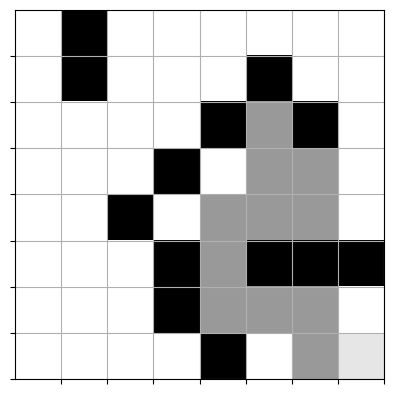

Epoch: 382/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 230 | Win rate: 0.969 | time: 17.10 minutes
   win | Epoch Reward: 0.17999999999999994 | LLLDDRRRlRD


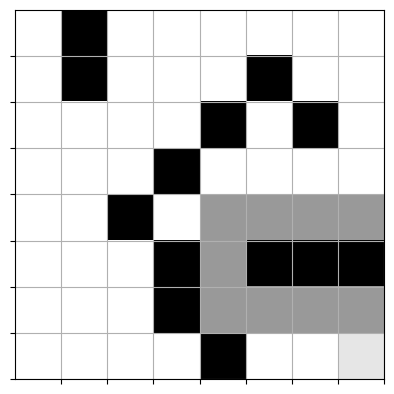

Epoch: 383/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 230 | Win rate: 0.938 | time: 17.18 minutes
   lose | Epoch Reward: -32.019999999999996 | RUDRDRRRRuDDRRRRLULDLRRRRdRRRRLLLDDDDRRRRRRRDDDuDDDRRRDDDDDDRRRRRDDLULLRDRRRRRDlDRDDDRRRRDDDDDDRRRuRRDLLLRLRRRRDDDDDLLLDRUDRUuLUURLRDLDLRrL


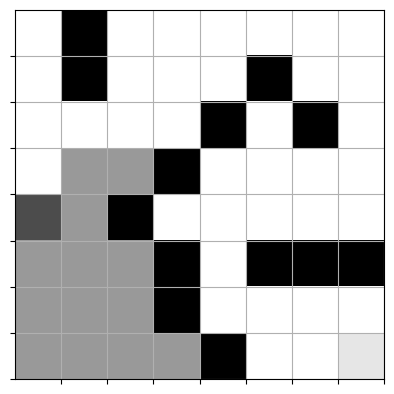

Epoch: 384/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 231 | Win rate: 0.938 | time: 17.27 minutes
   win | Epoch Reward: -22.649999999999977 | DUDUUUUUUUUUUUUUUUDUDULULLUDUDUDURRRUrUDULLLLLRRRRRDrDDDDDUDULRRLRDLLUDULLLRUUULUDdDRUURRURLRLRLRLRURlRRRDDDDlULDUDUDDLDDRDRR


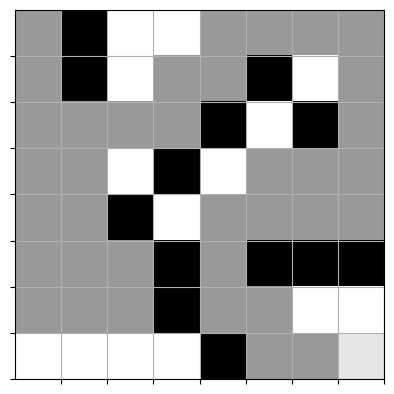

Epoch: 385/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 231 | Win rate: 0.906 | time: 17.35 minutes
   lose | Epoch Reward: -32.03 | DDDLLLLLLLLLDLLRRDDDDDDDuDDLLUdULLLLLDDDuDDDDDDUUDUDUDUDUDUDDRDDDDDLLLLuLLLLLLLLLLLLDUDURDRdDDDDDLLULLLLLLLLLLLLLLRLLUDDUDUDUDrLUDUDUD


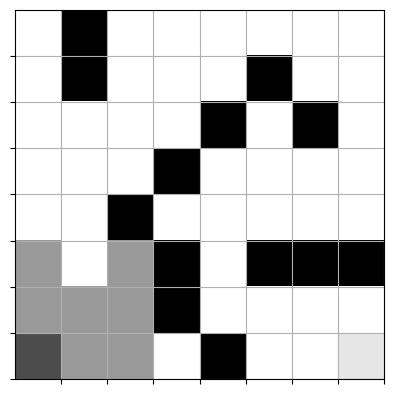

Epoch: 386/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 232 | Win rate: 0.906 | time: 17.39 minutes
   win | Epoch Reward: 0.84 | DRDRR


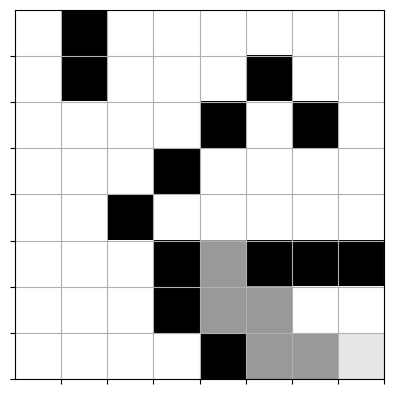

Epoch: 387/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 233 | Win rate: 0.906 | time: 17.44 minutes
   win | Epoch Reward: -6.660000000000001 | UUDDDRLRLRLRLLLUDUDUUUUDdRUURUUDUUUUURRRRRDDDDLLLDDdRRRD


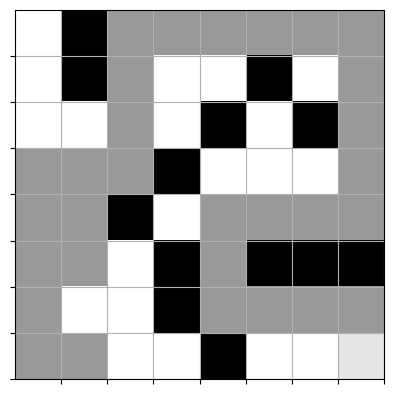

Epoch: 388/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 233 | Win rate: 0.875 | time: 17.52 minutes
   lose | Epoch Reward: -32.11 | DlDDUuUuUUUUUUdRRRRRRRrUDUUUUUUUUUUUUUUDUUDUUUUUUUUUDUrDUDUUURRRRRUUUDDDDDDUDUUUUUURRlDUDUDUDUUURRRRRRRRLLLLLLLLLUUURRRRRUULLLLLLLLuLLLL


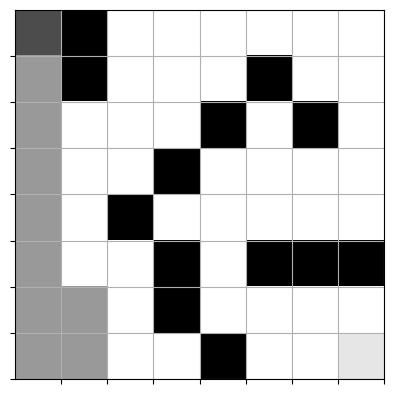

Epoch: 389/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 234 | Win rate: 0.875 | time: 17.60 minutes
   win | Epoch Reward: -23.479999999999976 | RRRRRRDLLrLUURDLURDDLDDDDDDUULLLLLLLLLLLLLUUUrLUUDDDDDDDDUURLRLRRRDUDDLLDDDUUDUUUUUURRRRRRRRRRRRRRDUDDDDRURURUURRRRDDlDDLLLDrDRRRD


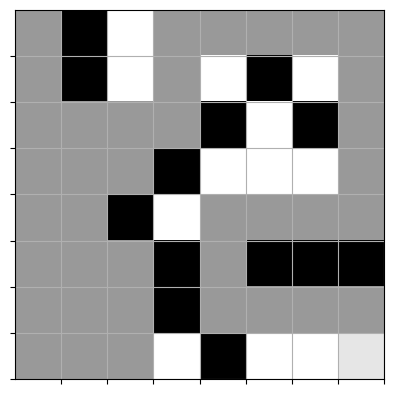

Epoch: 390/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 235 | Win rate: 0.875 | time: 17.64 minutes
   win | Epoch Reward: 0.6300000000000001 | RuRRD


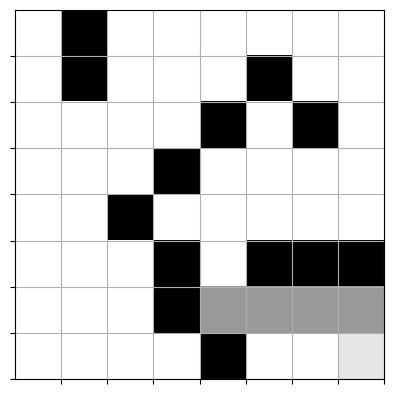

Epoch: 391/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 236 | Win rate: 0.875 | time: 17.68 minutes
   win | Epoch Reward: 0.92 | RRD


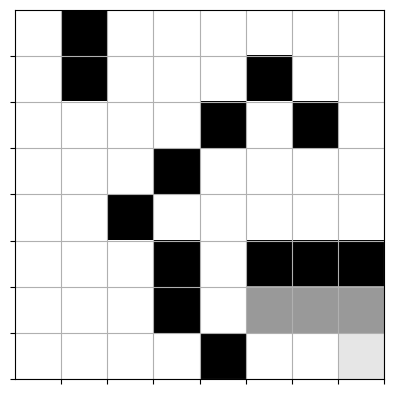

Epoch: 392/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 237 | Win rate: 0.875 | time: 17.71 minutes
   win | Epoch Reward: 0.96 | RD


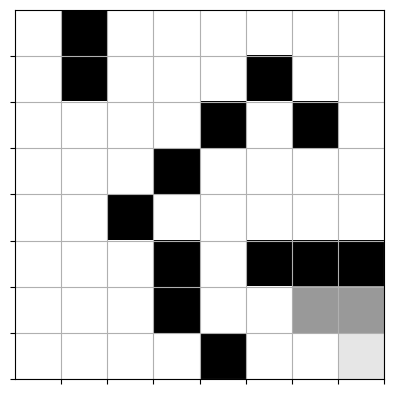

Epoch: 393/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 238 | Win rate: 0.875 | time: 17.75 minutes
   win | Epoch Reward: 1.0 | D


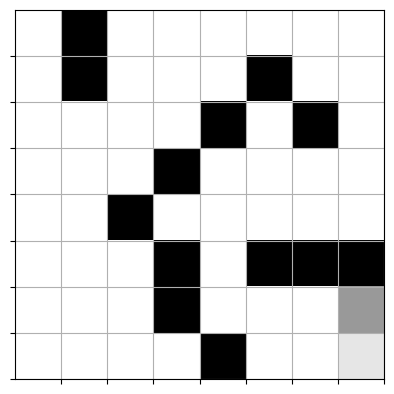

Epoch: 394/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 239 | Win rate: 0.875 | time: 17.79 minutes
   win | Epoch Reward: -0.2900000000000005 | LUUUURRURURURRRDDDDLLLDDRRRD


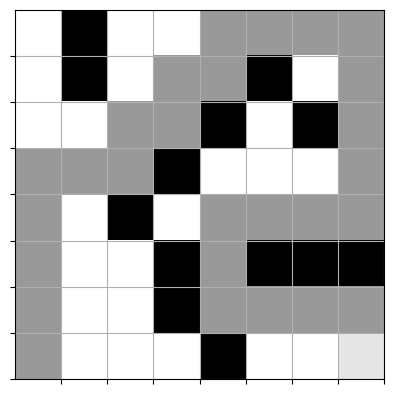

Epoch: 395/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 240 | Win rate: 0.906 | time: 17.87 minutes
   win | Epoch Reward: -20.699999999999996 | UuUUULRdUUURRUURlRlRuRRRUDDDDLLLUdUURUUUUUUUULLLRLLURUURRRRRRRRRRRRRLLLUUUdUUUuUUUULLlUUULLLdLRrLLRUUUUDDLDDlRRrD


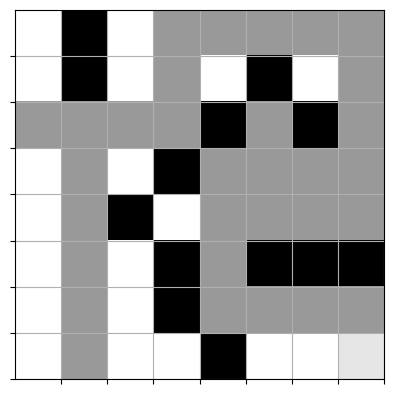

Epoch: 396/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 241 | Win rate: 0.906 | time: 17.95 minutes
   win | Epoch Reward: -23.779999999999976 | RLRDDLULURRRRRRRRRRdRRRRRRURRRRlRRRDDRLRLRLRLUuDLrLURDLUUURURURURRRDDDDLLLURUDRUUUUUUULULLLLLLLLUUUUdUDUDUDUUUUUUUUULDllDDDRRRD


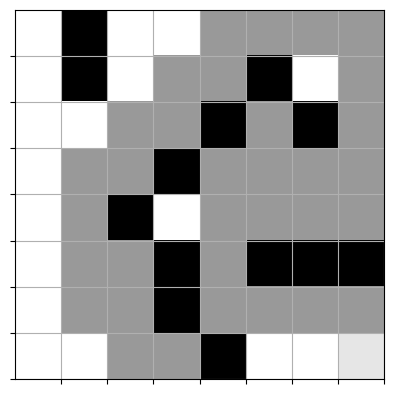

Epoch: 397/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 242 | Win rate: 0.906 | time: 18.02 minutes
   win | Epoch Reward: -16.409999999999975 | RDDDDDDuDUUUURRRRDDDDDDUUUUUUDRRRRUUUUUdUUUUUUUUUDDDDUUUUURRRUULLLLUURUUURUURRRRRDDDDLLLDDlRrRD


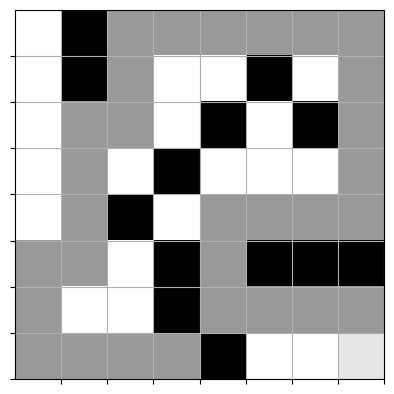

Epoch: 398/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 243 | Win rate: 0.906 | time: 18.06 minutes
   win | Epoch Reward: 0.96 | RR


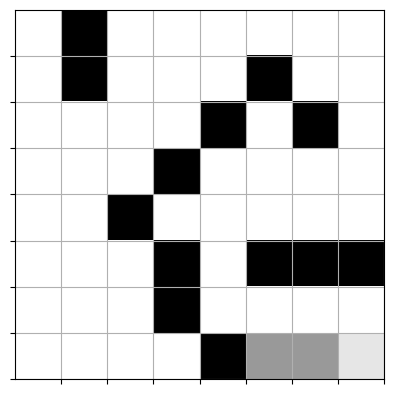

Epoch: 399/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 244 | Win rate: 0.906 | time: 18.09 minutes
   win | Epoch Reward: 1.0 | R


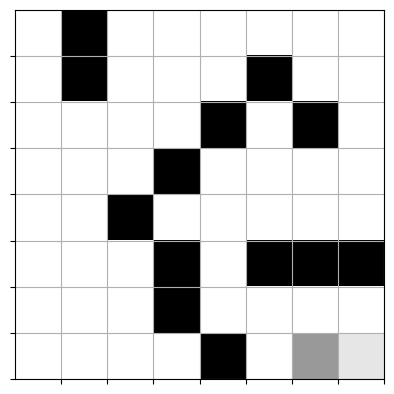

Epoch: 400/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 245 | Win rate: 0.906 | time: 18.14 minutes
   win | Epoch Reward: -0.5000000000000009 | DUDDDRRURURURRRDDDDLLLDDRRRD


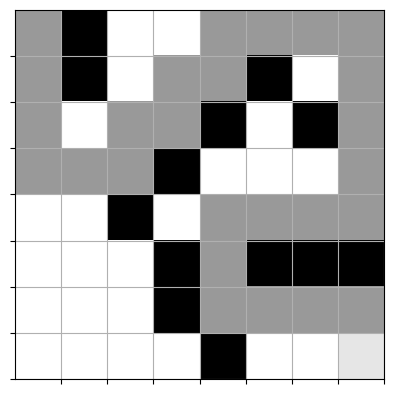

Epoch: 401/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 246 | Win rate: 0.906 | time: 18.18 minutes
   win | Epoch Reward: 0.31999999999999995 | RRRRRDDDDLLLDDRRRD


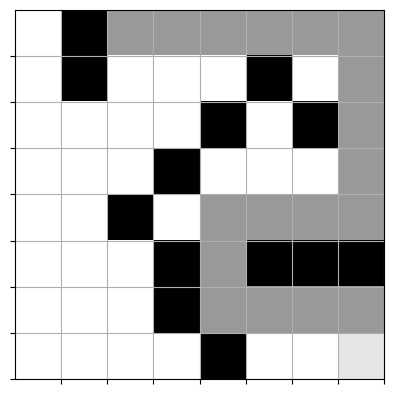

Epoch: 402/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 247 | Win rate: 0.906 | time: 18.22 minutes
   win | Epoch Reward: -0.4300000000000004 | RRRRdDDDulDLRLLDDRRRD


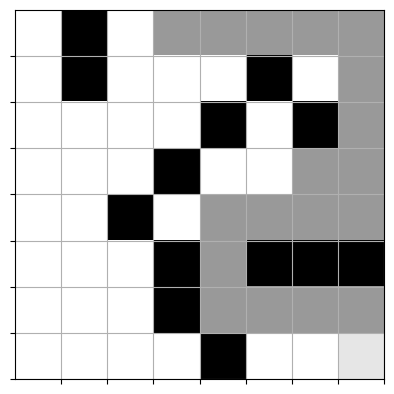

Epoch: 403/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 248 | Win rate: 0.906 | time: 18.26 minutes
   win | Epoch Reward: 0.1499999999999997 | RRRDDRDDLLLDDRRRD


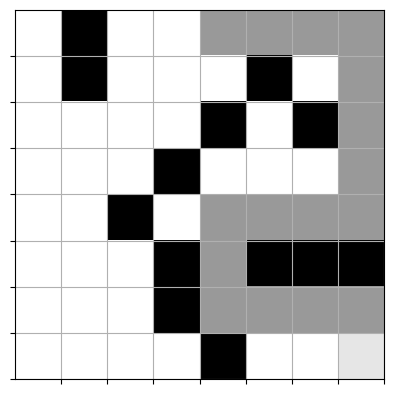

Epoch: 404/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 249 | Win rate: 0.906 | time: 18.30 minutes
   win | Epoch Reward: -0.8500000000000003 | lRRRRRRRDDDDLLLDDRRRD


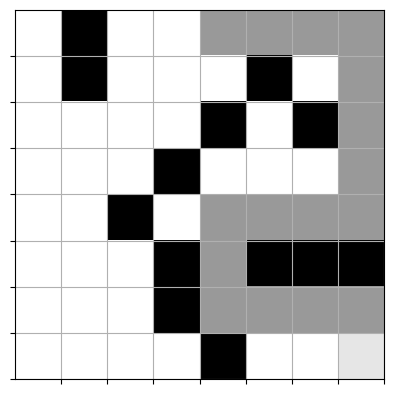

Epoch: 405/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 250 | Win rate: 0.906 | time: 18.34 minutes
   win | Epoch Reward: 0.22999999999999976 | RDDDDLdLLDDRRRd


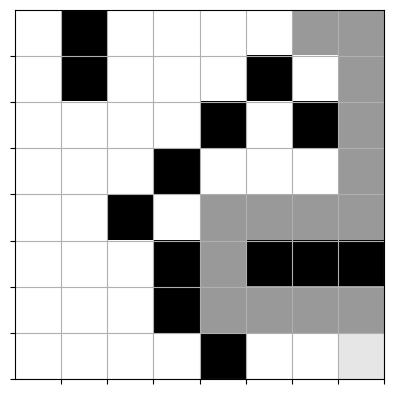

Epoch: 406/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 251 | Win rate: 0.906 | time: 18.38 minutes
   win | Epoch Reward: 0.52 | DDDDLLLDDRDRR


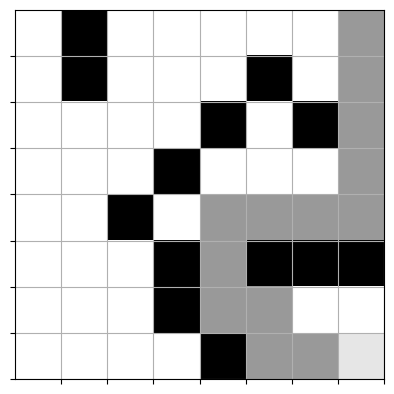

Epoch: 407/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 252 | Win rate: 0.906 | time: 18.43 minutes
   win | Epoch Reward: -1.910000000000001 | DDUUUUDDDDDRUURUUURRRRRDDDDdLLLDDRDRR


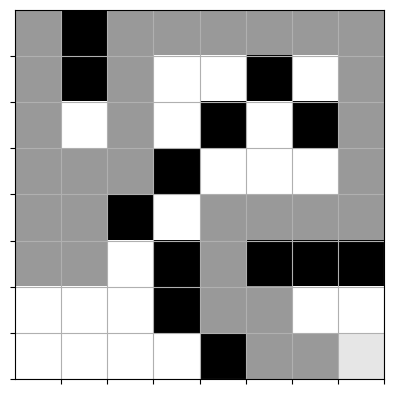

Epoch: 408/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 253 | Win rate: 0.906 | time: 18.48 minutes
   win | Epoch Reward: -0.010000000000000009 | RRURRRDDDDLLLuDDdRRRD


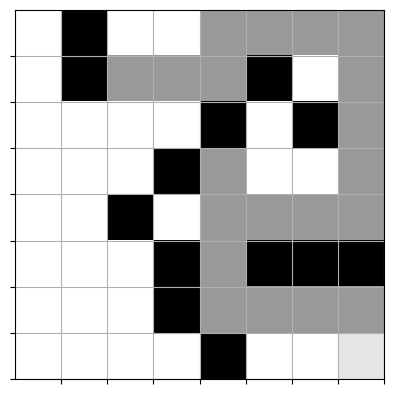

Epoch: 409/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 254 | Win rate: 0.906 | time: 18.52 minutes
   win | Epoch Reward: 0.06999999999999962 | RuRRRrDDDDLLLDDRRRD


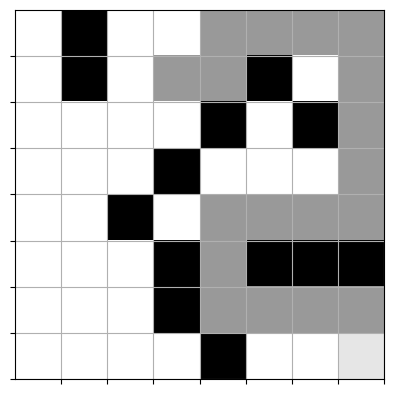

Epoch: 410/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 255 | Win rate: 0.906 | time: 18.56 minutes
   win | Epoch Reward: -0.9300000000000002 | URRdRDDDLLLUDUDUDddRRdR


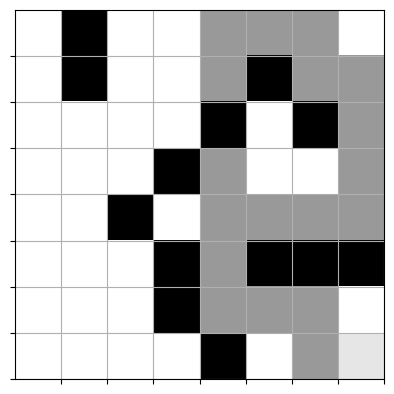

Epoch: 411/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 256 | Win rate: 0.906 | time: 18.60 minutes
   win | Epoch Reward: 0.52 | RDDDLLLDDRdRR


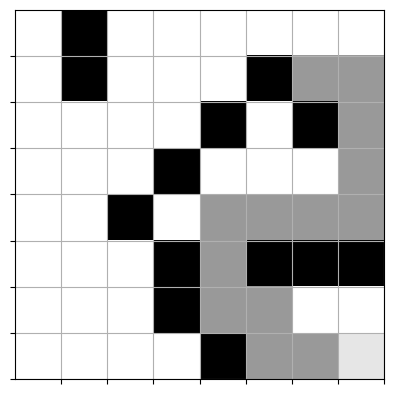

Epoch: 412/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 257 | Win rate: 0.906 | time: 18.64 minutes
   win | Epoch Reward: 0.56 | DDDLLLDDRDRR


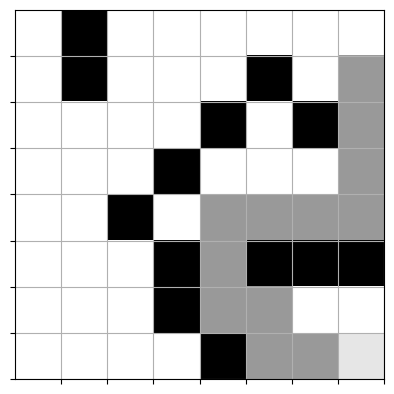

Epoch: 413/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 258 | Win rate: 0.906 | time: 18.69 minutes
   win | Epoch Reward: 0.1599999999999998 | RRRUURRRRDDDDLLLDDRRRD


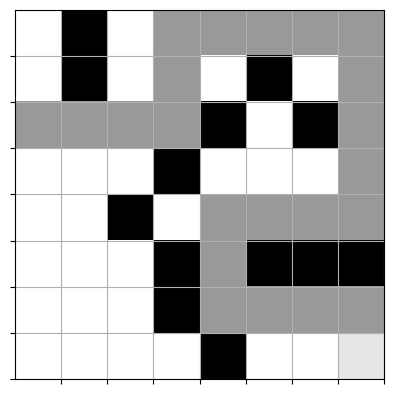

Epoch: 414/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 259 | Win rate: 0.906 | time: 18.74 minutes
   win | Epoch Reward: -8.409999999999991 | lDDRUdURURLRLRLLLDDDRUURURURDLRLRLRRLRLLRRURRRDDDDLLrLLrLDDRRRD


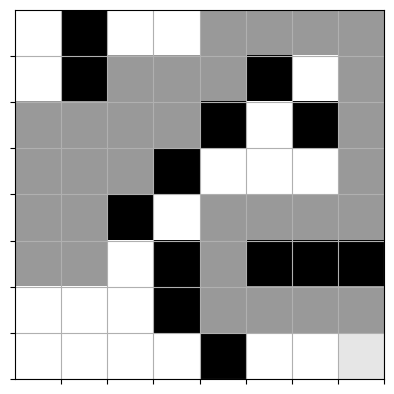

Epoch: 415/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 260 | Win rate: 0.938 | time: 18.79 minutes
   win | Epoch Reward: -1.0500000000000003 | RURURRRDlRDUDuDDDLLLDDRDRR


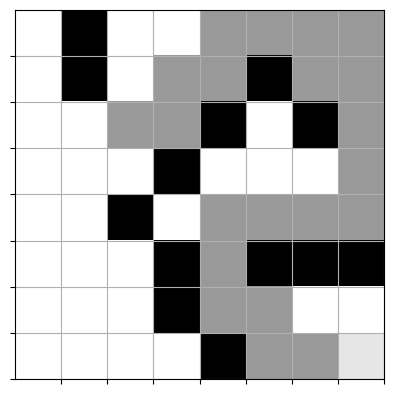

Epoch: 416/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 261 | Win rate: 0.938 | time: 18.83 minutes
   win | Epoch Reward: 0.029999999999999694 | RUUrRRRDDDDLLLDDRRRD


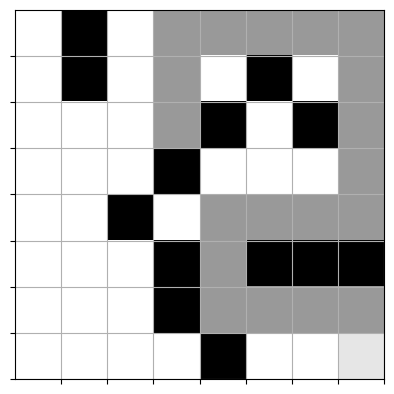

Epoch: 417/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 262 | Win rate: 0.969 | time: 18.87 minutes
   win | Epoch Reward: -0.1100000000000001 | DDLuRDLDDRRRD


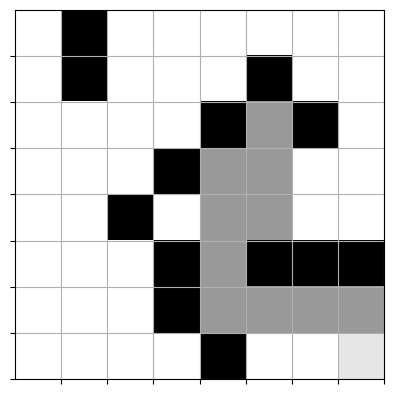

Epoch: 418/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 263 | Win rate: 0.969 | time: 18.91 minutes
   win | Epoch Reward: 0.6000000000000001 | DDLLLDDRDRR


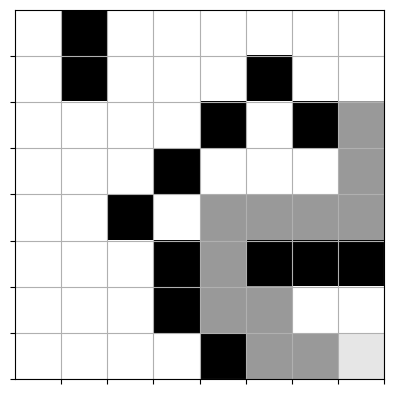

Epoch: 419/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 264 | Win rate: 0.969 | time: 18.96 minutes
   win | Epoch Reward: -1.3800000000000008 | RRUUDUDUuRRRRRrDDlDDLLLDDRRRD


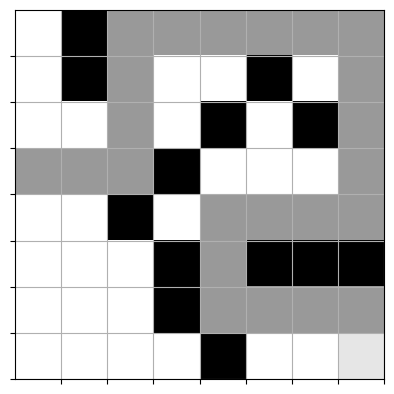

Epoch: 420/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 265 | Win rate: 1.000 | time: 19.01 minutes
   win | Epoch Reward: -2.000000000000001 | RURULRLRRURRRDDDDLLLURRLrLDLDDRrRD


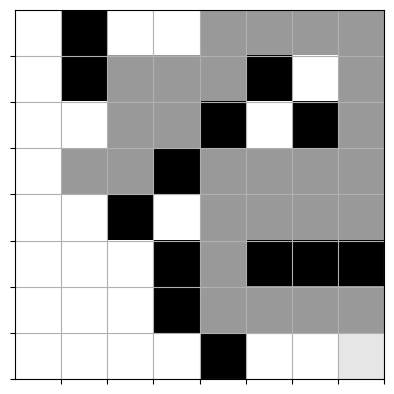

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 421/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 266 | Win rate: 1.000 | time: 19.10 minutes
   win | Epoch Reward: -25.919999999999995 | RDDUUURRRRRdDDDLUUUUUUULULLLrLLLUUUUUuUUUUUUUUUUUUUUUUULLLLLLLLLLDUUUUDRLRLRLRLUUUUUUDUuLLLRRDUUUUUUUDULLRRRRRRRRRRUUURDDLDDRRRD


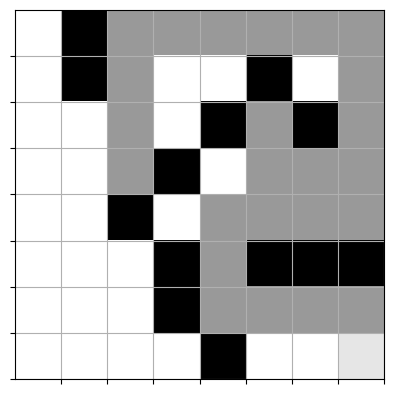

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 422/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 267 | Win rate: 1.000 | time: 19.15 minutes
   win | Epoch Reward: 0.76 | DDDRDRR


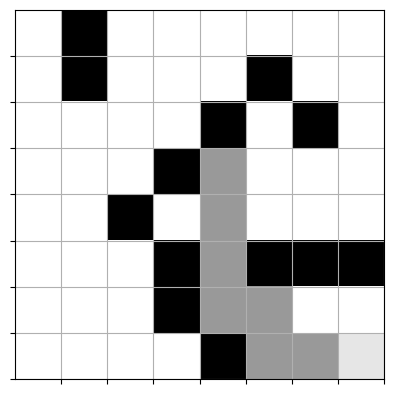

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 423/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 268 | Win rate: 1.000 | time: 19.20 minutes
   win | Epoch Reward: 0.72 | DLDDRRRD


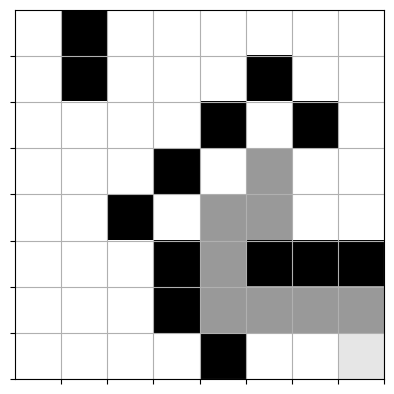

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 424/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 269 | Win rate: 1.000 | time: 19.25 minutes
   win | Epoch Reward: 0.6799999999999999 | LLDDDRDRR


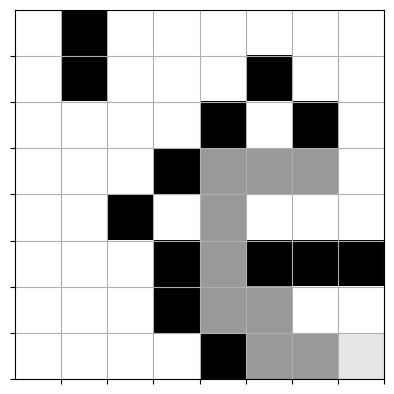

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 425/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 270 | Win rate: 1.000 | time: 19.30 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


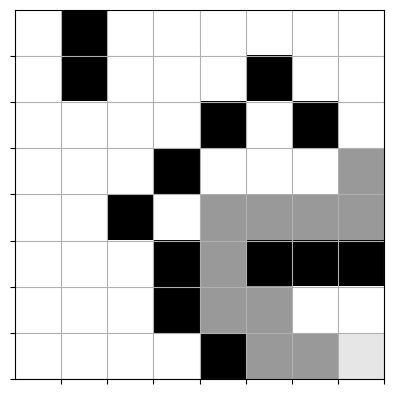

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 426/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 271 | Win rate: 1.000 | time: 19.35 minutes
   win | Epoch Reward: -0.7100000000000006 | RURUdUUURRRrRDDDDLUDLLDDRRRD


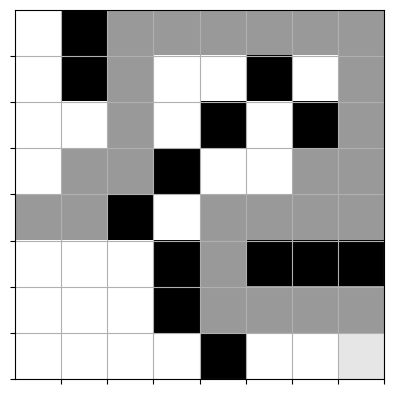

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 427/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 272 | Win rate: 1.000 | time: 19.41 minutes
   win | Epoch Reward: -2.210000000000001 | UUDUDlUDRURUURRRRRDDDDLLLDuDDruDRR


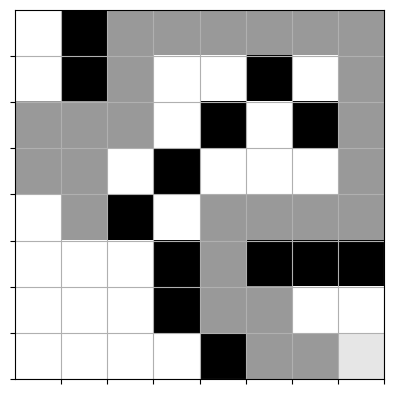

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 428/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 273 | Win rate: 1.000 | time: 19.46 minutes
   win | Epoch Reward: 0.76 | RDDRRRD


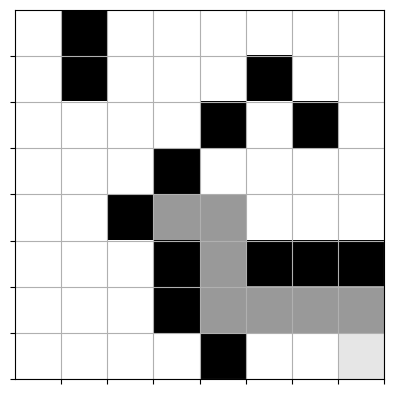

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 429/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 274 | Win rate: 1.000 | time: 19.51 minutes
   win | Epoch Reward: 0.55 | DDRDlRR


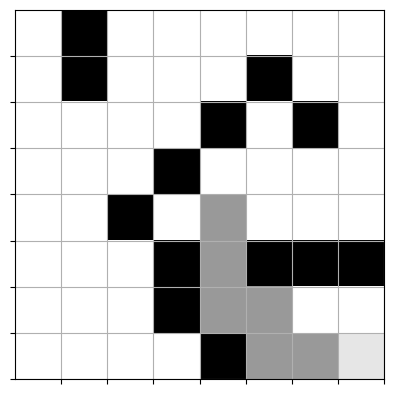

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 430/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 275 | Win rate: 1.000 | time: 19.56 minutes
   win | Epoch Reward: 0.76 | LDDRDRR


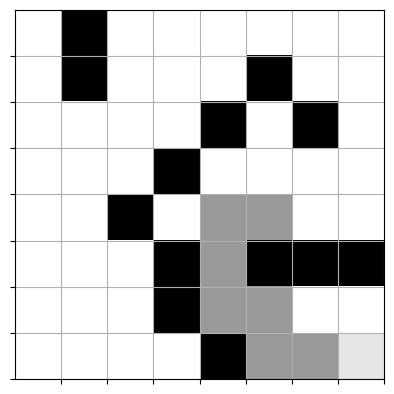

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 431/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 276 | Win rate: 1.000 | time: 19.61 minutes
   win | Epoch Reward: 0.72 | LLDDRRRD


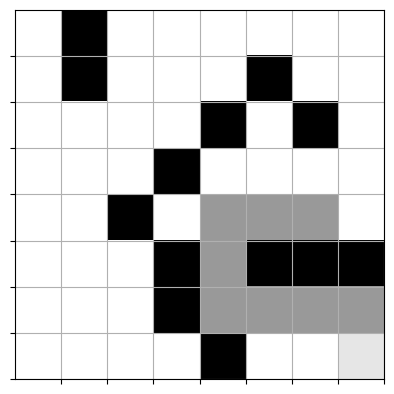

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 432/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 277 | Win rate: 1.000 | time: 19.67 minutes
   win | Epoch Reward: -3.6100000000000003 | LLLlLLLLLLulLLLLLLdLRDDRRRD


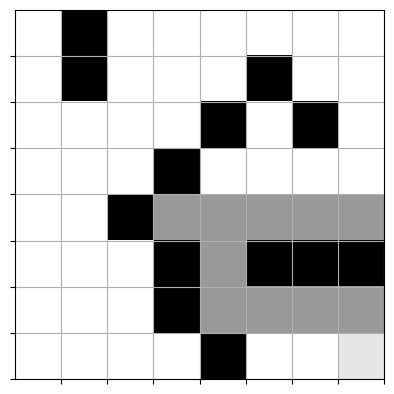

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 433/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 278 | Win rate: 1.000 | time: 19.72 minutes
   win | Epoch Reward: -0.7100000000000009 | RlRUURURURdURRRDDDDLLLDDRRRD


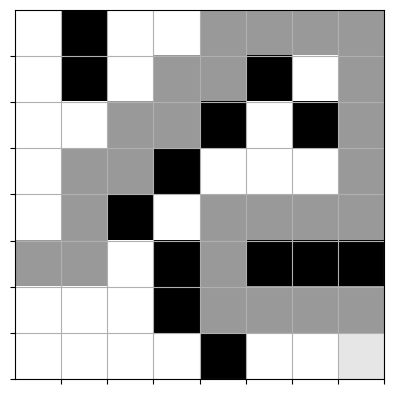

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 434/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 279 | Win rate: 1.000 | time: 19.78 minutes
   win | Epoch Reward: -0.46000000000000063 | UUURUUlRRRRRDDDDLLLlRDDRRRD


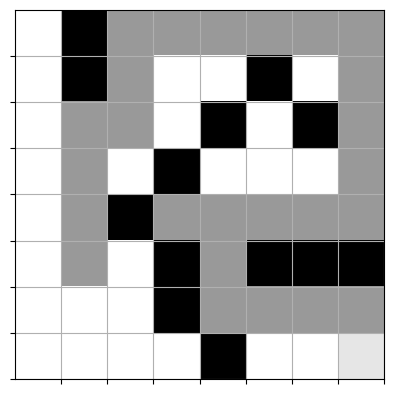

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 435/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 280 | Win rate: 1.000 | time: 19.88 minutes
   win | Epoch Reward: -28.199999999999978 | RUUUUUUUUUUUUDDUDUDUDUDUDRDDDDDDDDDDDDDDDDDDDuDDuDLUDRDDDDDDDDDDDDRRRRRdRRRRDLLUDUDUDRRRdRRRDDDuDDDDdLRLRRRRRRRLRLLUUUUUDRUUURRRRRDDDDLLLDDRRRD


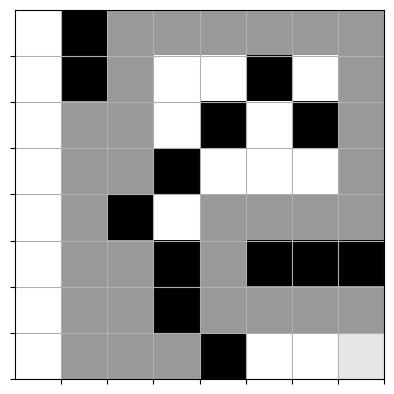

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 436/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 281 | Win rate: 1.000 | time: 19.92 minutes
   win | Epoch Reward: 0.84 | DRDRR


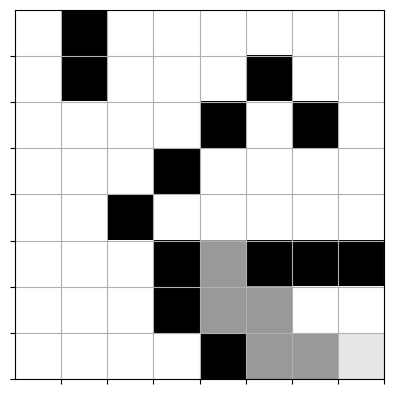

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 437/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 282 | Win rate: 1.000 | time: 19.98 minutes
   win | Epoch Reward: -0.5800000000000005 | lDRUUUURUUURRRRRDDDDdlLLDDRRRD


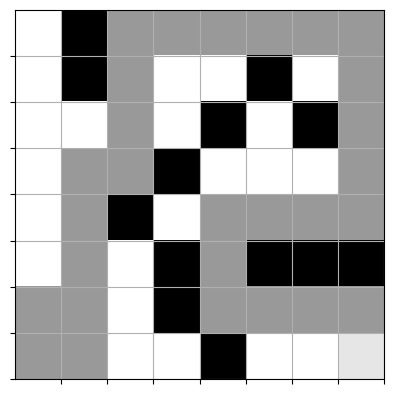

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 438/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 283 | Win rate: 1.000 | time: 20.04 minutes
   win | Epoch Reward: 0.0399999999999997 | UUUURUURRRRRDDDDLLLDDRRRD


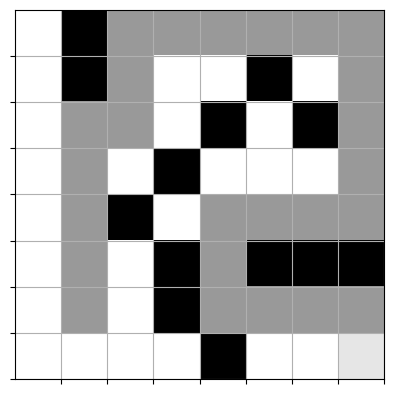

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 439/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 284 | Win rate: 1.000 | time: 20.11 minutes
   win | Epoch Reward: -8.619999999999976 | RRRRRRRRRUDUDRRRRRRRRUUUUUUDRRRRRDLUUUUURUURRRRRDDDLLLRLDDDRRRD


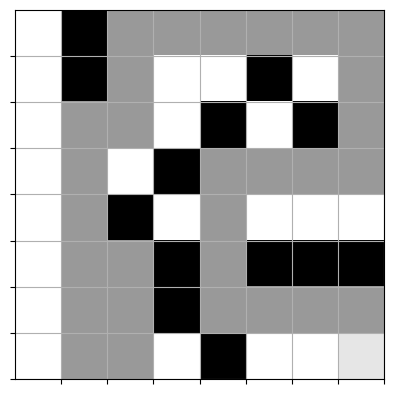

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 440/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 285 | Win rate: 1.000 | time: 20.15 minutes
   win | Epoch Reward: 0.88 | RRRD


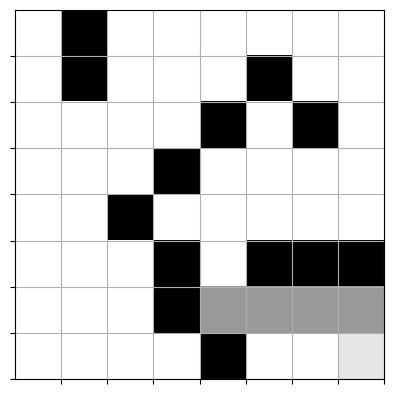

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 441/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 286 | Win rate: 1.000 | time: 20.20 minutes
   win | Epoch Reward: 0.92 | RRD


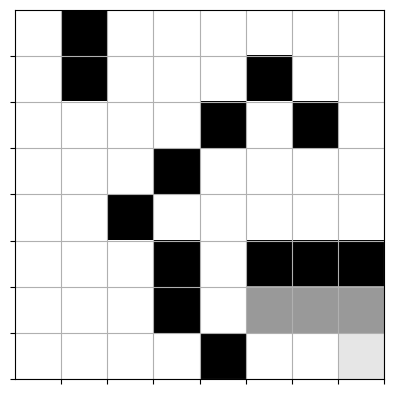

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 442/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 287 | Win rate: 1.000 | time: 20.25 minutes
   win | Epoch Reward: 0.96 | RD


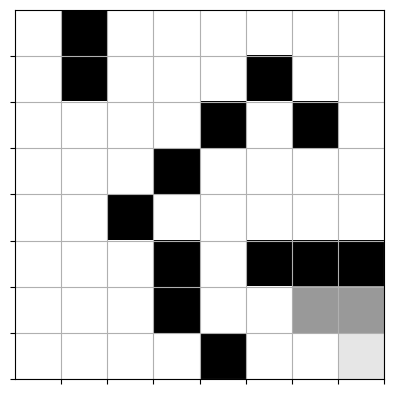

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 443/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 288 | Win rate: 1.000 | time: 20.30 minutes
   win | Epoch Reward: 1.0 | D


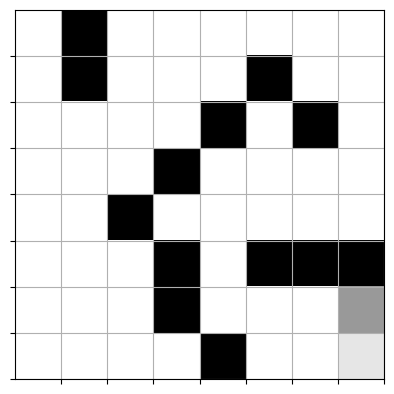

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 444/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 289 | Win rate: 1.000 | time: 20.36 minutes
   win | Epoch Reward: -2.790000000000001 | lDDDUURUUdUURUURRRRRDDDLUUUUULDLDDRRRD


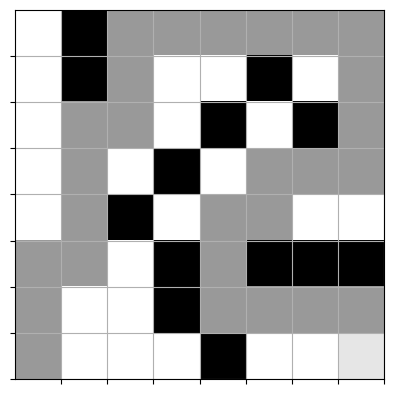

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 445/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 290 | Win rate: 1.000 | time: 20.42 minutes
   win | Epoch Reward: -3.290000000000001 | UUUUURUURRRlRRRDLLLLRDDLLLUUUUUUUDDDRRRD


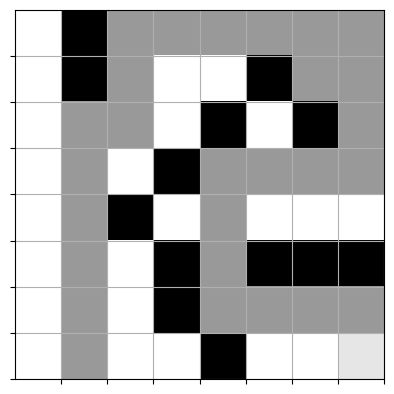

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 446/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 291 | Win rate: 1.000 | time: 20.48 minutes
   win | Epoch Reward: -1.4100000000000006 | LLUUlRUURLdUURUlURRRRRDDDLLLDDDRDRR


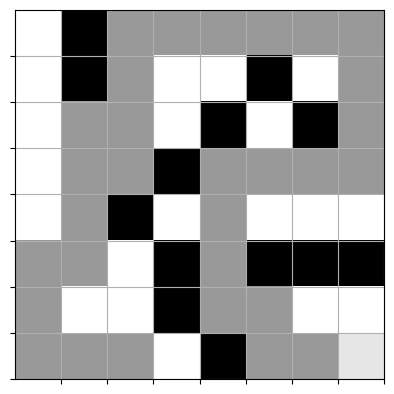

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 447/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 292 | Win rate: 1.000 | time: 20.54 minutes
   win | Epoch Reward: -5.410000000000001 | RRRRRRDDDlLUUUUUrUURRRRRDDDLLLUUURULLLLLDDLDDRRRlRD


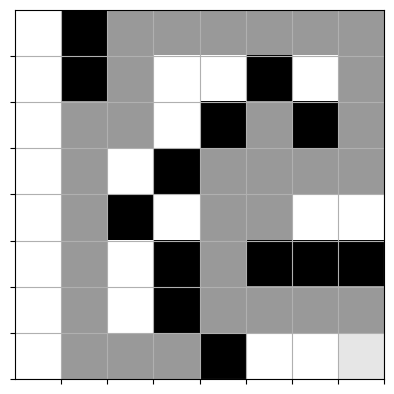

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 448/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 293 | Win rate: 1.000 | time: 20.59 minutes
   win | Epoch Reward: 0.96 | RR


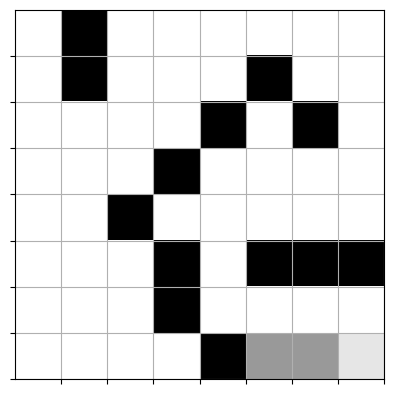

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 449/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 294 | Win rate: 1.000 | time: 20.63 minutes
   win | Epoch Reward: 1.0 | R


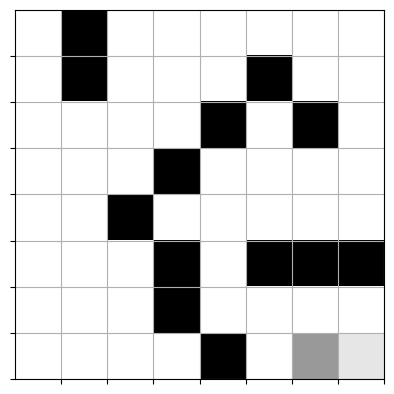

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 450/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 295 | Win rate: 1.000 | time: 20.69 minutes
   win | Epoch Reward: -2.410000000000001 | RRRDDDDDRUURLRLRUUURRRRRDDDDLLLDDRRlRRD


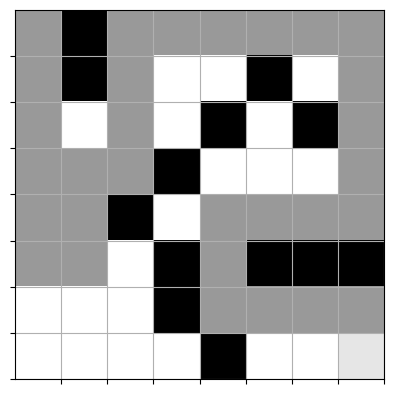

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 451/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 296 | Win rate: 1.000 | time: 20.74 minutes
   win | Epoch Reward: 0.06999999999999995 | RrRRRDDDDLLLDDRRuRD


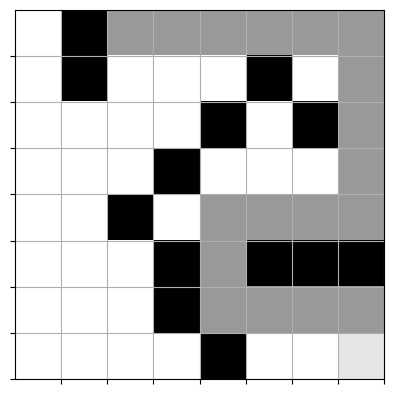

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 452/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 297 | Win rate: 1.000 | time: 20.80 minutes
   win | Epoch Reward: 0.36 | RRRRDDDDLLLDDRDRR


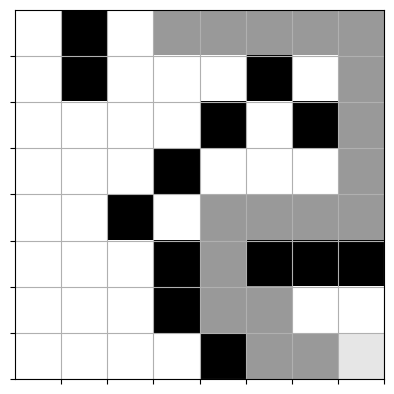

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 453/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 298 | Win rate: 1.000 | time: 20.85 minutes
   win | Epoch Reward: 0.1499999999999999 | RRRDDDdLLLDDdRRRD


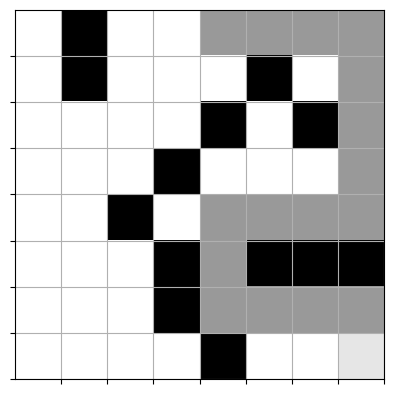

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 454/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 299 | Win rate: 1.000 | time: 20.90 minutes
   win | Epoch Reward: 0.18999999999999984 | URRDDDDLLLDDRRRD


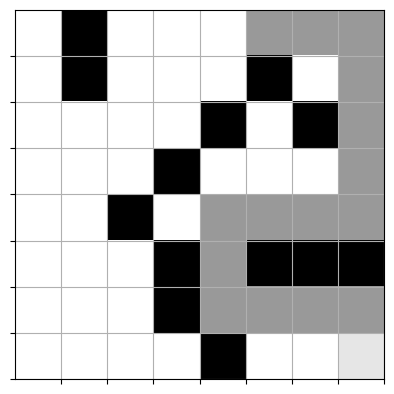

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 455/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 300 | Win rate: 1.000 | time: 20.95 minutes
   win | Epoch Reward: -0.6000000000000003 | RDLRLRdDDLuDLLDDRRRD


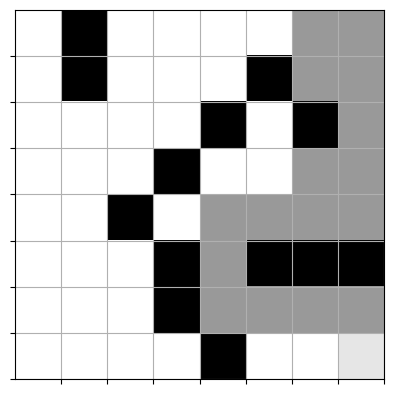

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 456/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 301 | Win rate: 1.000 | time: 21.00 minutes
   win | Epoch Reward: 0.22999999999999976 | DDDDLLLuDDDRDRR


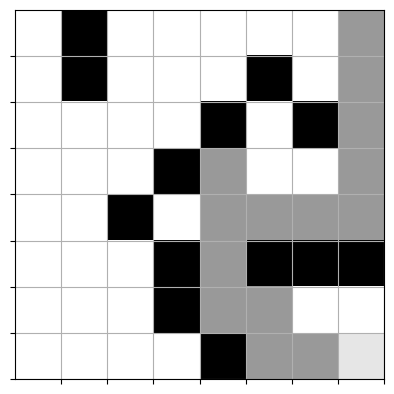

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 457/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 302 | Win rate: 1.000 | time: 21.06 minutes
   win | Epoch Reward: -2.700000000000001 | DDUUUDUDUDDDDDdURUUURUURRRRRDDDDLLLDDRRRD


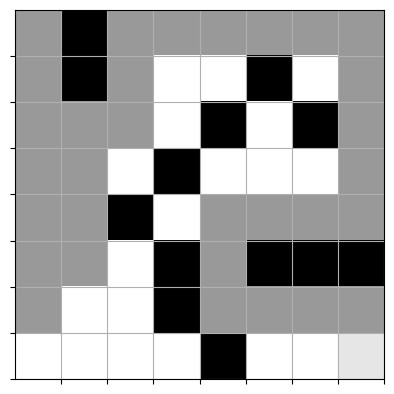

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 458/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 303 | Win rate: 1.000 | time: 21.11 minutes
   win | Epoch Reward: -2.130000000000001 | DUDLRLRUURRRRdDURDDDDLUDLLDDRDRR


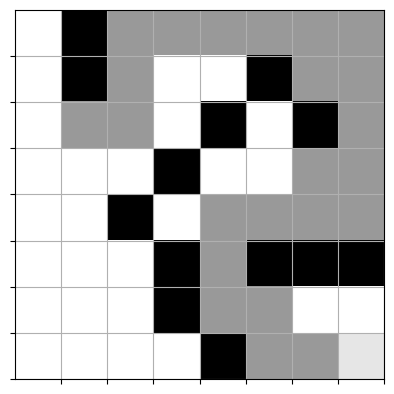

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 459/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 304 | Win rate: 1.000 | time: 21.17 minutes
   win | Epoch Reward: -1.0500000000000007 | DUDUuRRRRlRDDDDLULDLDDRDRR


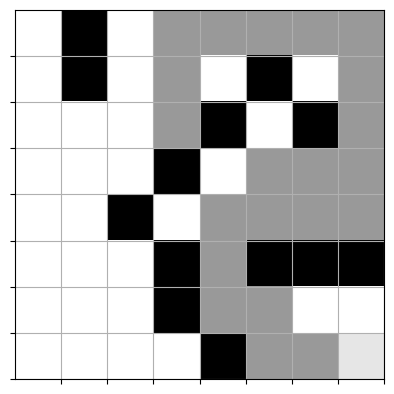

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 460/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 305 | Win rate: 1.000 | time: 21.23 minutes
   win | Epoch Reward: -4.55 | URRRDDDDLUDULDUUUULLLuLLUdDLUDrLDDuDRRRD


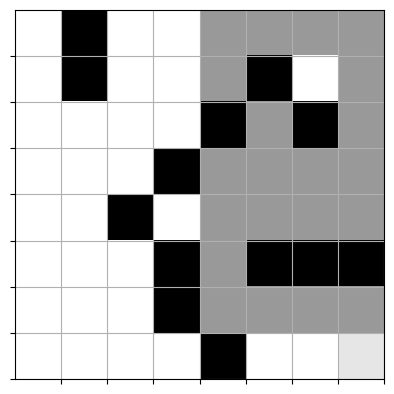

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 461/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 306 | Win rate: 1.000 | time: 21.29 minutes
   win | Epoch Reward: -0.3100000000000005 | DDDRDDDLULDLDDRDRR


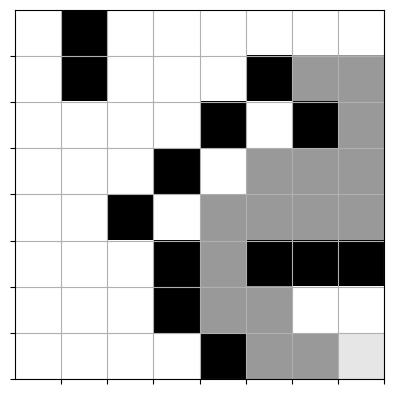

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 462/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 307 | Win rate: 1.000 | time: 21.34 minutes
   win | Epoch Reward: 0.05999999999999983 | DDDLLLrLDDRDRR


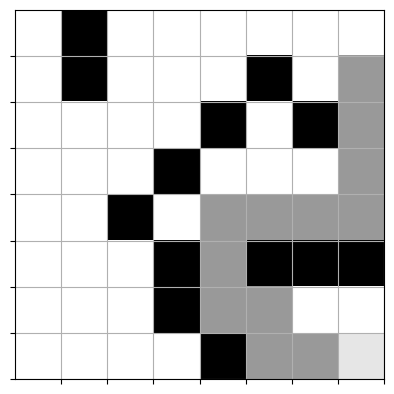

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 463/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 308 | Win rate: 1.000 | time: 21.40 minutes
   win | Epoch Reward: -2.500000000000001 | DDRURUDDDDDURUDUURRRRDDDDLLLDDRlRDRR


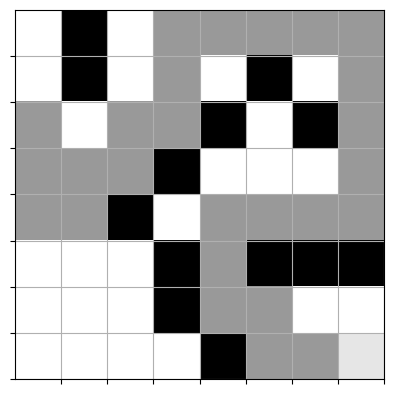

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 464/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 309 | Win rate: 1.000 | time: 21.46 minutes
   win | Epoch Reward: -1.1600000000000006 | LDDDRDUDUUURUULRRURRRDDDDLLLDDRRRD


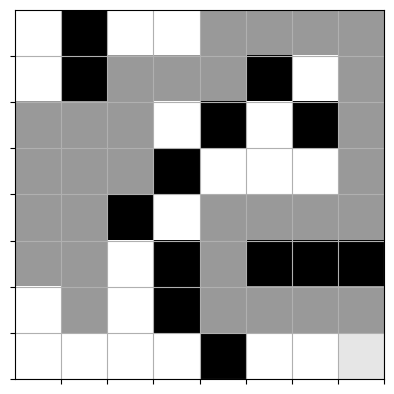

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 465/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 310 | Win rate: 1.000 | time: 21.52 minutes
   win | Epoch Reward: -1.6300000000000003 | UURRRRRDDDDLLLURUUUUUDDLDDRDRR


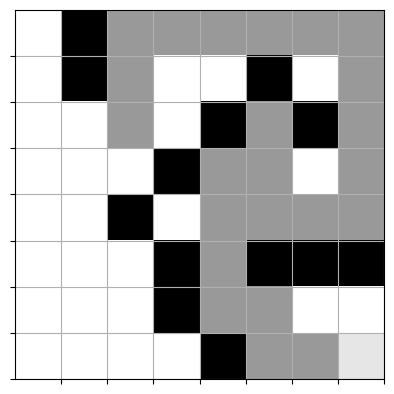

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 466/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 311 | Win rate: 1.000 | time: 21.59 minutes
   win | Epoch Reward: -12.299999999999995 | UURRRRDDlDLLrLLDULLLLDUURUURRLLLLLRRRRRRUUUULLLLRRRRRUUUUUUUDDuDLDDRRRD


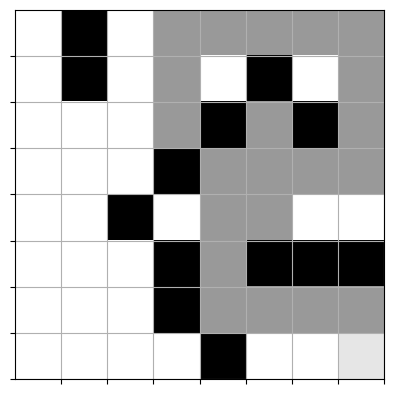

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 467/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 312 | Win rate: 1.000 | time: 21.64 minutes
   win | Epoch Reward: 0.17999999999999972 | UUdDLDDRDRR


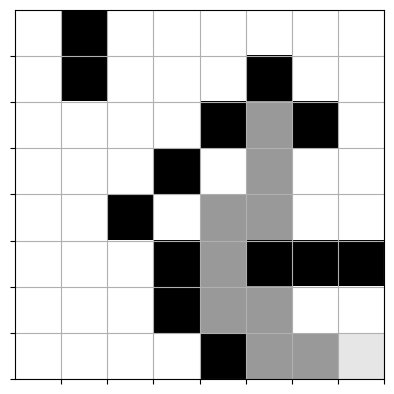

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 468/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 313 | Win rate: 1.000 | time: 21.69 minutes
   win | Epoch Reward: 0.6000000000000001 | DDLLLDDRDRR


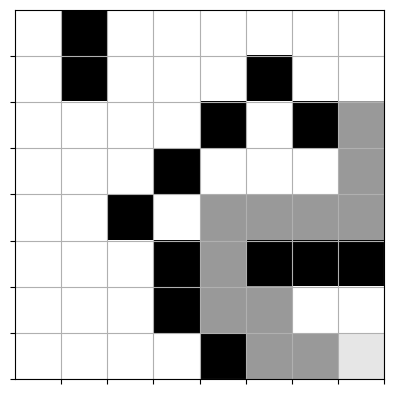

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5), (1, 0)]
FAILED START CELL:  (1, 3)
Epoch: 469/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 314 | Win rate: 1.000 | time: 21.76 minutes
   win | Epoch Reward: -0.7100000000000006 | DRURURdUDURURRRDDDDlLLDDRDRR


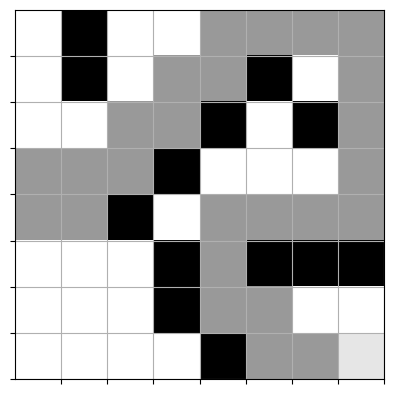

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 470/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 315 | Win rate: 1.000 | time: 21.81 minutes
   win | Epoch Reward: -0.0900000000000003 | RURRURURRRDDDDLLLDDRRRD


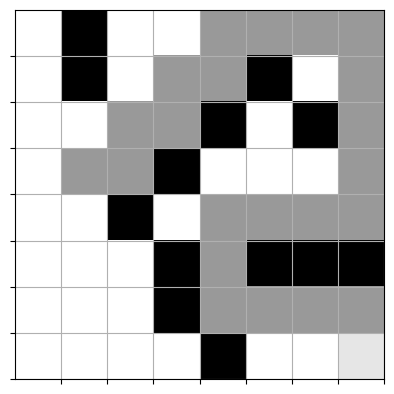

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 471/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 316 | Win rate: 1.000 | time: 21.87 minutes
   win | Epoch Reward: -1.6700000000000008 | URUDUURRRRDDDDLuLUUUUUDDLDDRRRD


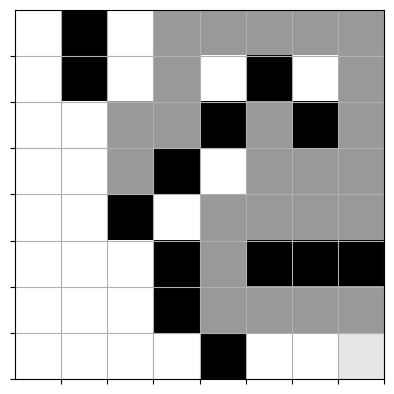

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 472/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 317 | Win rate: 1.000 | time: 21.92 minutes
   win | Epoch Reward: 0.17999999999999972 | RDuDLDDRDRR


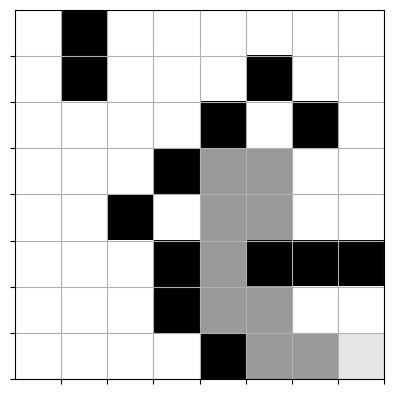

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 473/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 318 | Win rate: 1.000 | time: 21.97 minutes
   win | Epoch Reward: 0.72 | DLDDRDRR


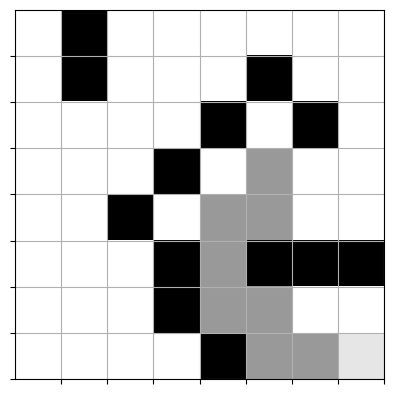

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 474/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 319 | Win rate: 1.000 | time: 22.02 minutes
   win | Epoch Reward: 0.34999999999999987 | RDLLLDddRDRR


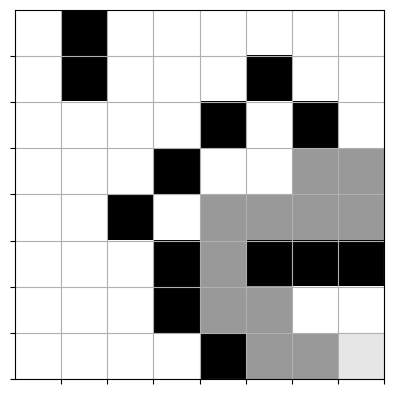

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5), (1, 0)]
FAILED START CELL:  (1, 2)
Epoch: 475/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 320 | Win rate: 1.000 | time: 22.08 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


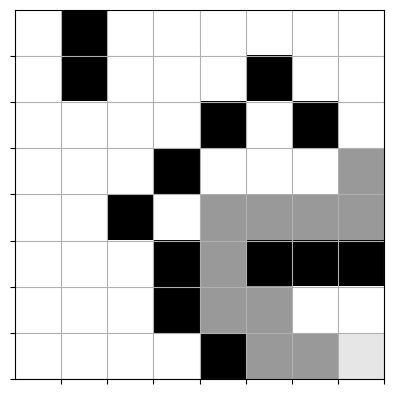

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 476/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 321 | Win rate: 1.000 | time: 22.14 minutes
   win | Epoch Reward: -1.2900000000000005 | DRUURURURURRRDDDlRuDDrLdLLDDRRRD


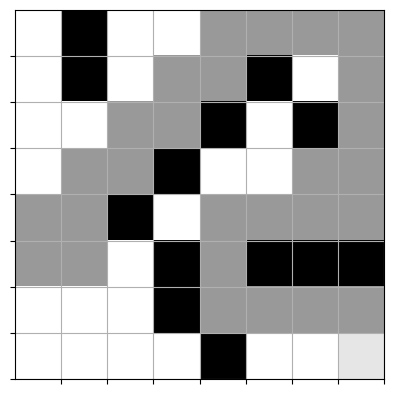

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 477/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 322 | Win rate: 1.000 | time: 22.19 minutes
   win | Epoch Reward: -0.3800000000000008 | UdUURUURRRRRDDDDLLLDDRDRR


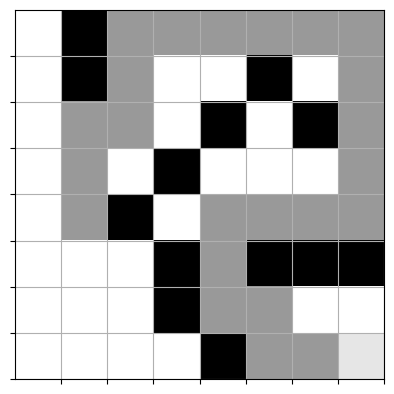

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 478/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 323 | Win rate: 1.000 | time: 22.24 minutes
   win | Epoch Reward: 0.51 | RDDRuRRD


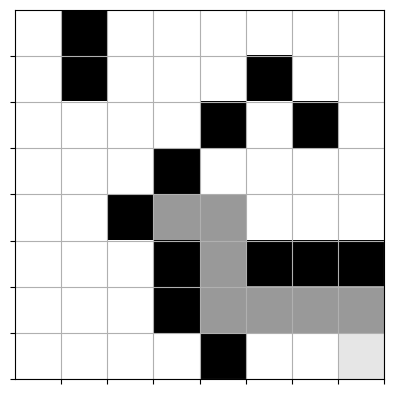

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 479/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 324 | Win rate: 1.000 | time: 22.30 minutes
   win | Epoch Reward: 0.8 | DDRdRR


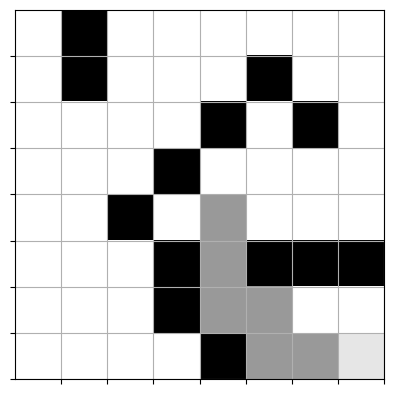

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 480/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 325 | Win rate: 1.000 | time: 22.35 minutes
   win | Epoch Reward: 0.009999999999999787 | DDDLDDRRRD


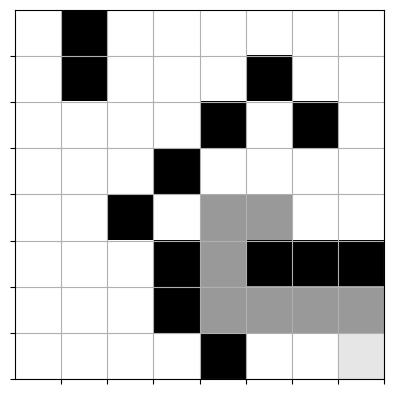

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5), (1, 0)]
FAILED START CELL:  (1, 3)
Epoch: 481/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 326 | Win rate: 1.000 | time: 22.41 minutes
   win | Epoch Reward: 0.47 | LLDDRRRrD


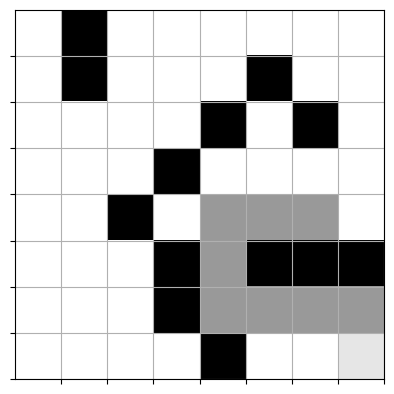

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 482/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 327 | Win rate: 1.000 | time: 22.46 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDDRRRD


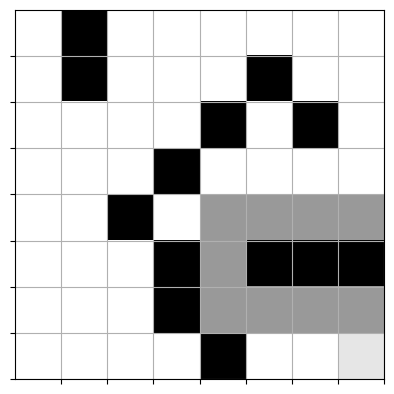

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 483/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 328 | Win rate: 1.000 | time: 22.53 minutes
   win | Epoch Reward: -14.77999999999998 | RRDRRRrLRLrlRRRRRRRLDRRRRRRRuRRRRRlRRRRRRLLLRdRrRRRRRRrLLUUUURURRrRRLRLUURRRRRDDDDLLLDDRRRD


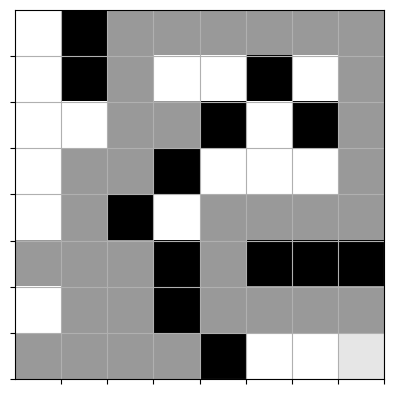

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 484/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 329 | Win rate: 1.000 | time: 22.59 minutes
   win | Epoch Reward: -0.4200000000000004 | UUURUURRRRRDUDDDDLLLDDRrRD


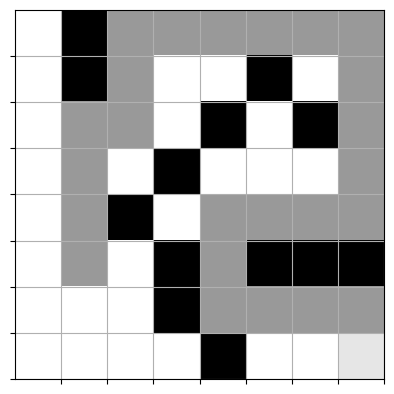

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 485/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 330 | Win rate: 1.000 | time: 22.67 minutes
   win | Epoch Reward: -19.949999999999978 | DDDDLUDUDUDUDRDDDDLLDDrRLRLRDDuDDDDLUDLDDDDDDDDDDDDrLDDDDDLDDDDDDDDDLLLLDDDDDRRULUUUURUDdUUURRRRRDDDDLLLDDRRRD


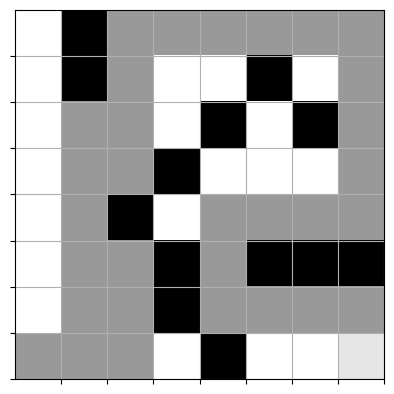

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 486/999 | Loss: 0.0015 | Episodes: 1000 | Win count: 331 | Win rate: 1.000 | time: 22.72 minutes
   win | Epoch Reward: 0.84 | DRDRR


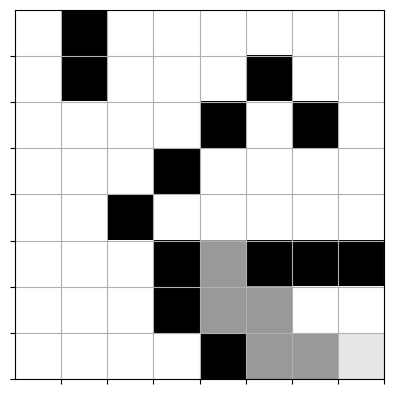

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 487/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 332 | Win rate: 1.000 | time: 22.78 minutes
   win | Epoch Reward: -1.370000000000001 | RDRLRlRULUUUURUURRRRRDDDDLLLDDRDRR


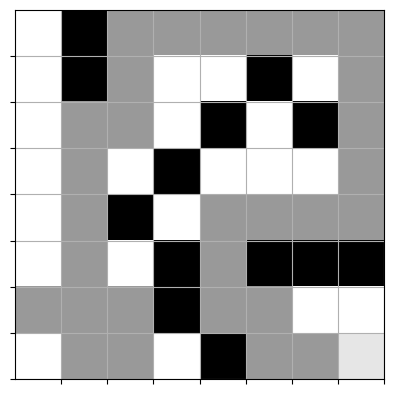

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 488/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 333 | Win rate: 1.000 | time: 22.84 minutes
   win | Epoch Reward: -2.950000000000001 | UruUUUUUDLDLlUDUURUURURUURRRRDDDDLLLDDRRRD


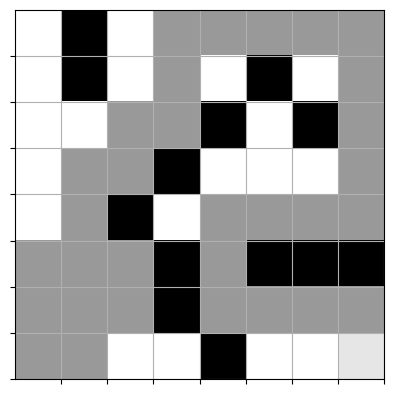

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 489/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 334 | Win rate: 1.000 | time: 22.90 minutes
   win | Epoch Reward: -4.780000000000001 | LUrDLUULRUlDDDDUDUDUDUURUUURULrLURRRRRDDDDLLLDDRRRD


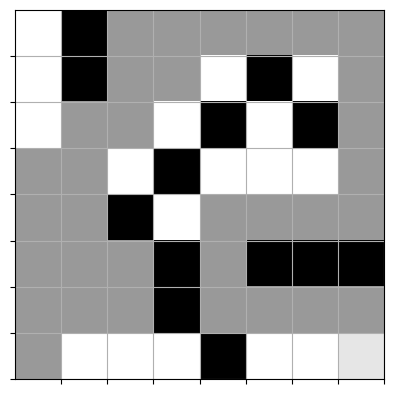

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 490/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 335 | Win rate: 1.000 | time: 22.95 minutes
   win | Epoch Reward: 0.88 | RRRD


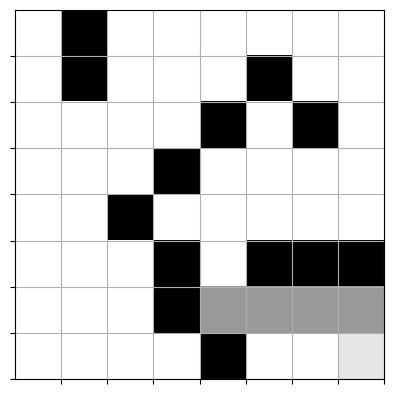

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 491/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 336 | Win rate: 1.000 | time: 23.00 minutes
   win | Epoch Reward: 0.92 | RRD


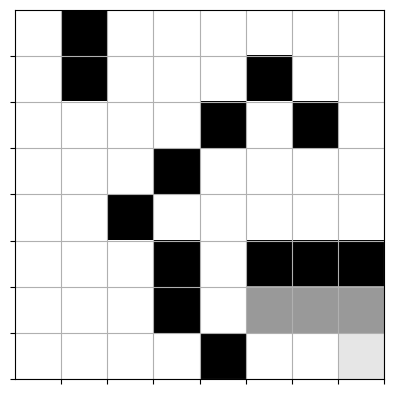

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 492/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 337 | Win rate: 1.000 | time: 23.05 minutes
   win | Epoch Reward: 0.96 | rD


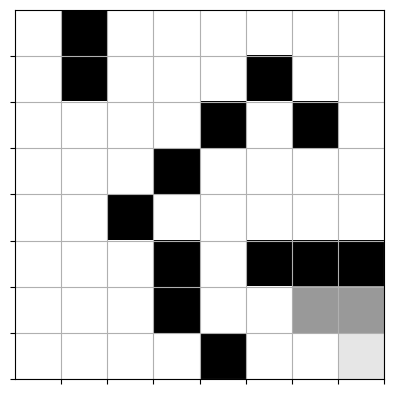

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 493/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 338 | Win rate: 1.000 | time: 23.10 minutes
   win | Epoch Reward: 1.0 | D


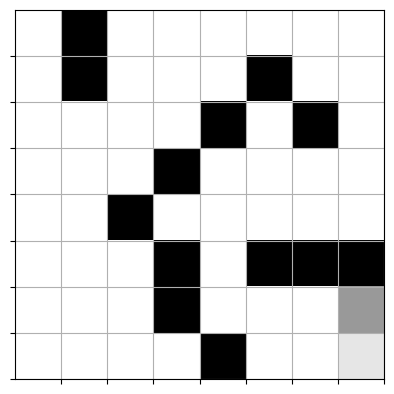

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 494/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 339 | Win rate: 1.000 | time: 23.15 minutes
   win | Epoch Reward: -0.2900000000000005 | DURUUUURUURRRRRDDDDLLLDDRRRD


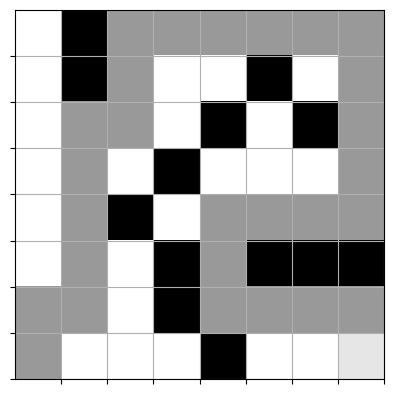

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 495/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 340 | Win rate: 1.000 | time: 23.21 minutes
   win | Epoch Reward: -2.870000000000001 | RUUUULULRLRLRUURUURRRRRDDDuDDuDLLLDDRRRD


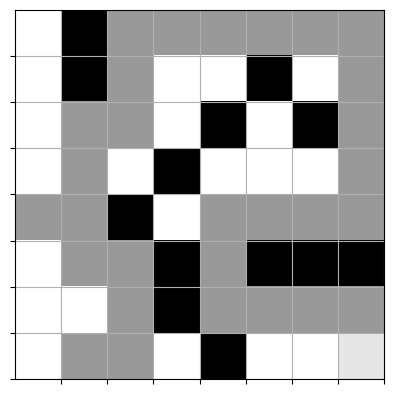

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 496/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 341 | Win rate: 1.000 | time: 23.28 minutes
   win | Epoch Reward: -5.740000000000001 | DRdLRUUUUUUUUULlLUDURUUUURUURRRRRDDDDLLuLRLRLRLDDDRRRD


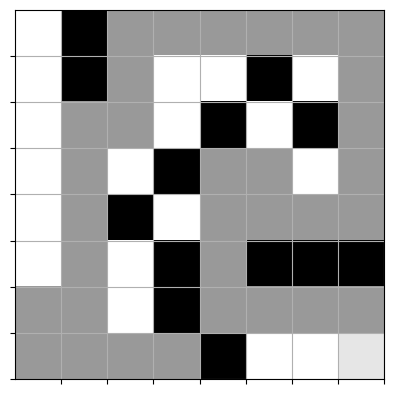

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 497/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 342 | Win rate: 1.000 | time: 23.34 minutes
   win | Epoch Reward: -4.580000000000001 | RRRRDDUDDuDDDDDlUuDULUUURUURRRRRDDDDLLLDDRRuRD


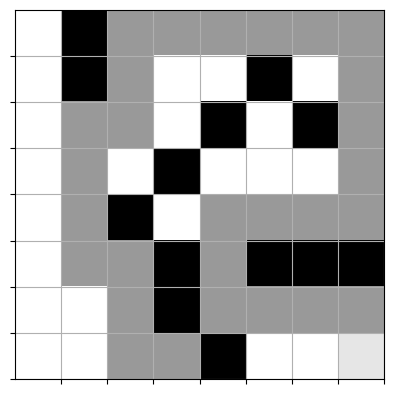

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 498/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 343 | Win rate: 1.000 | time: 23.39 minutes
   win | Epoch Reward: 0.96 | RR


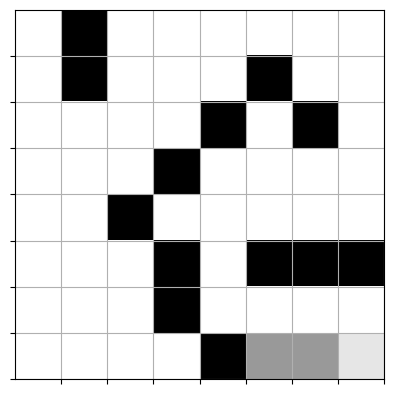

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 499/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 344 | Win rate: 1.000 | time: 23.43 minutes
   win | Epoch Reward: 1.0 | R


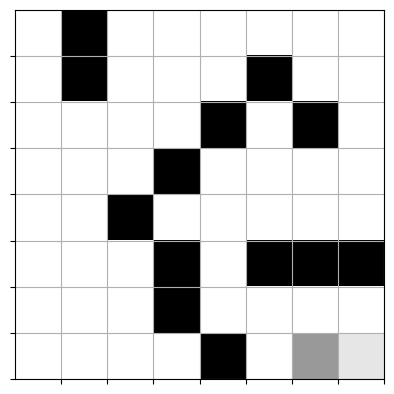

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 500/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 345 | Win rate: 1.000 | time: 23.49 minutes
   win | Epoch Reward: -1.660000000000001 | UUUUUDDDDDRUURrUUURRRRRDDDDLLLDDRRRD


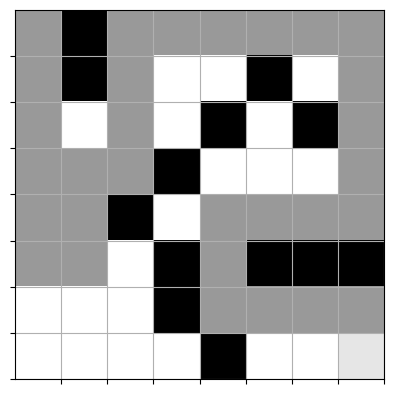

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 501/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 346 | Win rate: 1.000 | time: 23.55 minutes
   win | Epoch Reward: -1.7200000000000006 | RRRRRuDDDDLURDLURDLLLDDRRRD


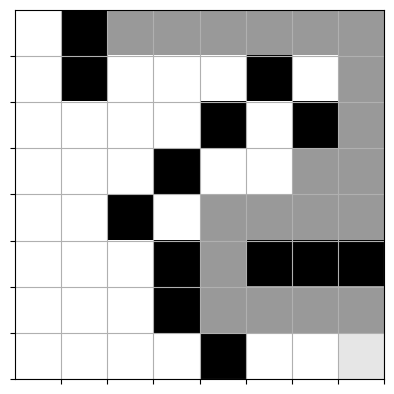

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 502/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 347 | Win rate: 1.000 | time: 23.60 minutes
   win | Epoch Reward: -3.4300000000000006 | UURlRRRRDDDDLURDLURDLURDLLLDDRDRR


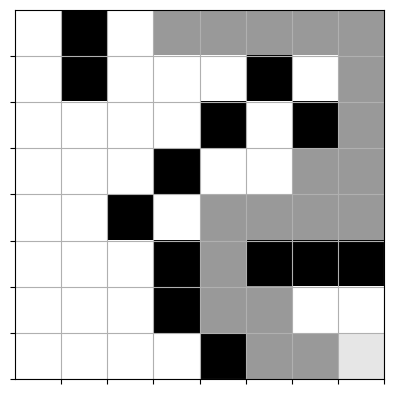

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 503/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 348 | Win rate: 1.000 | time: 23.66 minutes
   win | Epoch Reward: -0.3500000000000003 | RRRDDDRRRDLLLDDRRRD


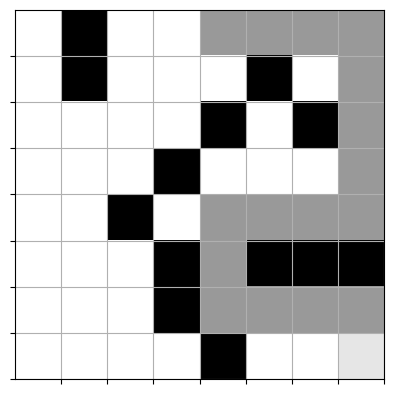

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 504/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 349 | Win rate: 1.000 | time: 23.71 minutes
   win | Epoch Reward: 0.18999999999999972 | RRDDDRDLLLDDRDRR


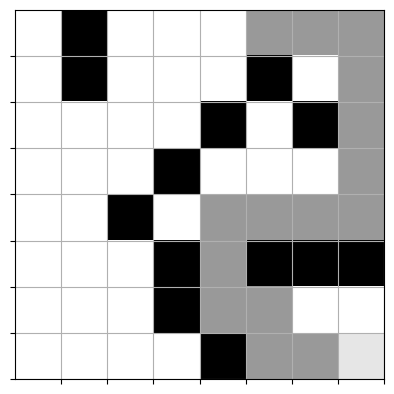

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 505/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 350 | Win rate: 1.000 | time: 23.76 minutes
   win | Epoch Reward: 0.22999999999999987 | RuDDDDLLLDDRRRD


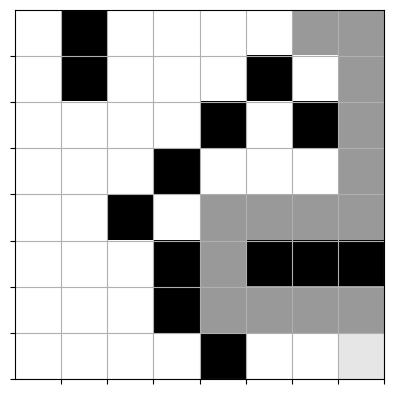

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 506/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 351 | Win rate: 1.000 | time: 23.81 minutes
   win | Epoch Reward: 0.52 | DDDDLLLDDRRRD


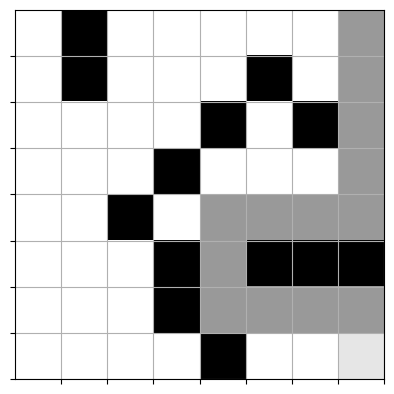

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 507/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 352 | Win rate: 1.000 | time: 23.87 minutes
   win | Epoch Reward: -1.410000000000001 | RRDDlDDRUUURUURRDDURRRDDDDLLLDDRDRR


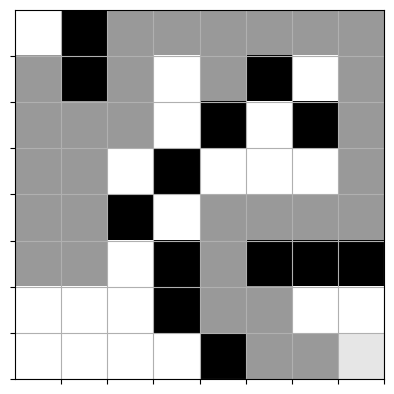

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 508/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 353 | Win rate: 1.000 | time: 23.93 minutes
   win | Epoch Reward: -1.5500000000000007 | URRRRDDDURDDDLLUUUUDDLDDRDRR


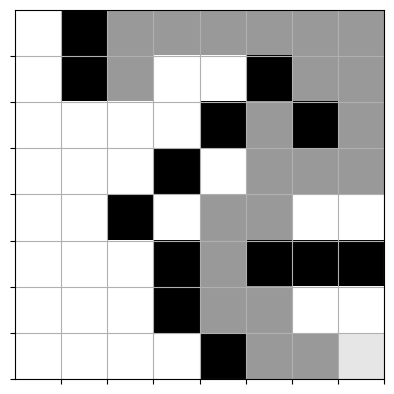

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 509/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 354 | Win rate: 1.000 | time: 23.98 minutes
   win | Epoch Reward: 0.31999999999999995 | URRRRDDDLLLDDDRRRD


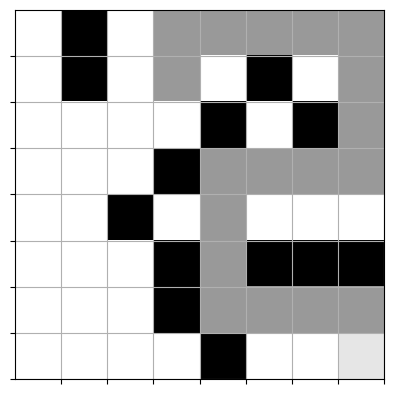

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 510/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 355 | Win rate: 1.000 | time: 24.04 minutes
   win | Epoch Reward: 0.36 | URRRDDDDLLLDDRRRD


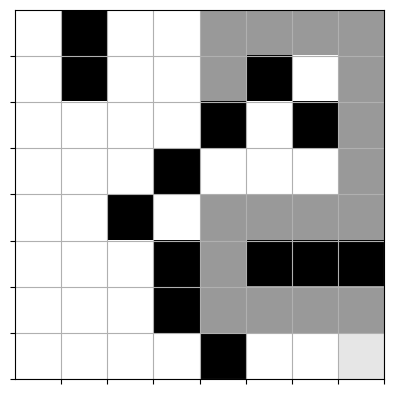

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 511/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 356 | Win rate: 1.000 | time: 24.09 minutes
   win | Epoch Reward: 0.18999999999999972 | URDDDDrLLLDDRRRD


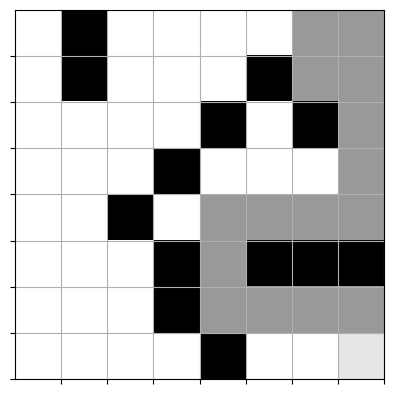

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 512/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 357 | Win rate: 1.000 | time: 24.14 minutes
   win | Epoch Reward: 0.56 | DDdLLLDDRDRR


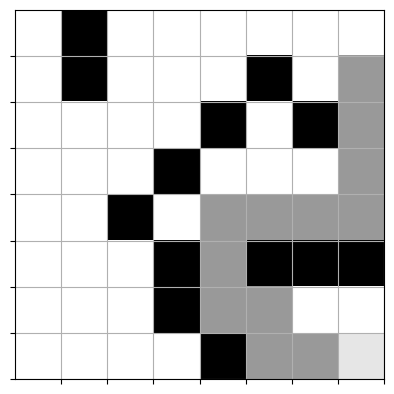

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 513/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 358 | Win rate: 1.000 | time: 24.21 minutes
   win | Epoch Reward: -8.909999999999979 | DDUDUDUDUDUDDdUDUDUDUDUDUDDDDDDUDUULUUDrURUUURRdURRRDDDDLLLDDRDRR


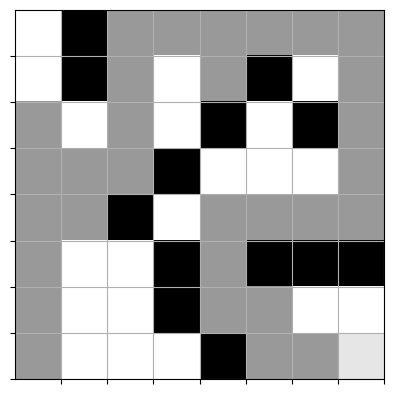

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 514/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 359 | Win rate: 1.000 | time: 24.27 minutes
   win | Epoch Reward: -1.5500000000000003 | RRRURURRRDDDLLLRlRLRLDDDRDRR


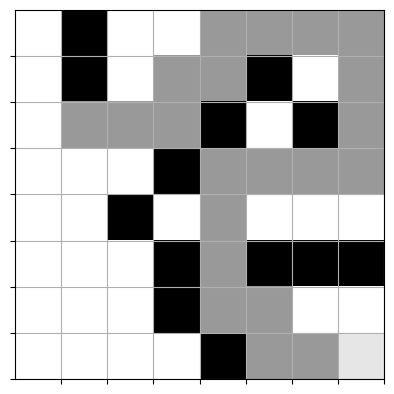

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 515/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 360 | Win rate: 1.000 | time: 24.33 minutes
   win | Epoch Reward: -0.26000000000000045 | UURRRRRlRDDDLLDLDDRDRR


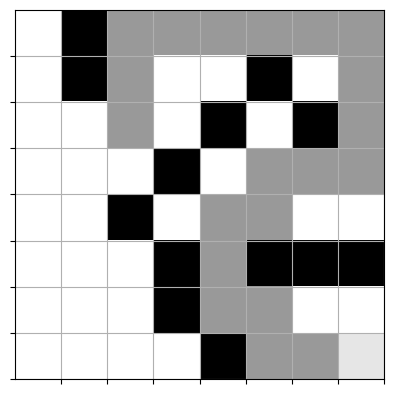

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 516/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 361 | Win rate: 1.000 | time: 24.38 minutes
   win | Epoch Reward: -0.0900000000000003 | LLRUURRRRRDDDDLLLDDRDRR


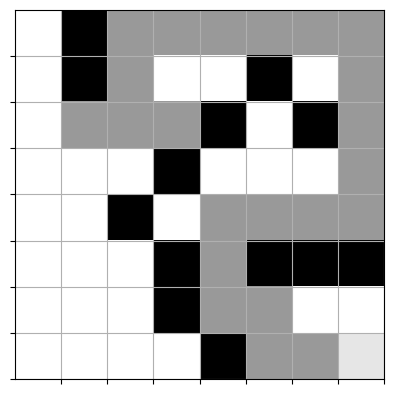

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 517/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 362 | Win rate: 1.000 | time: 24.44 minutes
   win | Epoch Reward: -0.3200000000000003 | LLLDDLDDRRuRD


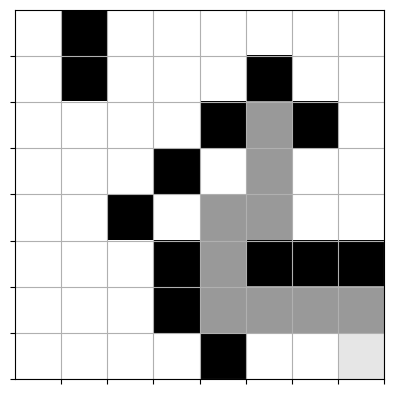

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (2, 1), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (0, 2), (1, 7), (0, 5), (2, 2), (1, 0), (1, 6), (1, 3)]
FAILED START CELL:  (2, 5)
Epoch: 518/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 363 | Win rate: 1.000 | time: 24.51 minutes
   win | Epoch Reward: 0.34999999999999987 | DDLLDLDDRDRR


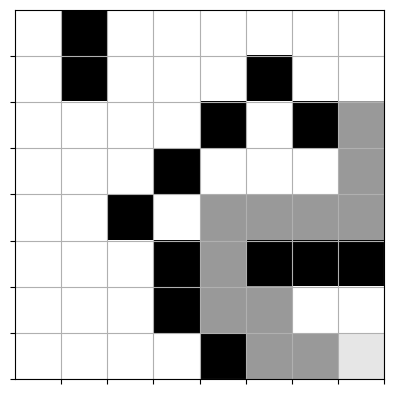

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 519/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 364 | Win rate: 1.000 | time: 24.57 minutes
   win | Epoch Reward: -0.4200000000000004 | uDRRUURRURRRDrDDLLDLDDRRRD


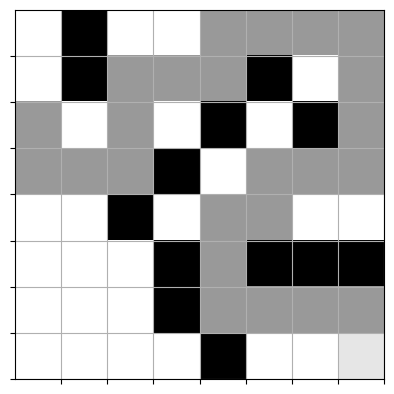

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 520/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 365 | Win rate: 1.000 | time: 24.63 minutes
   win | Epoch Reward: -5.750000000000001 | uRLlUURRRRRRRRRRLLLLRRRDDDRURUURRRRRDDDDLLLDDRRRD


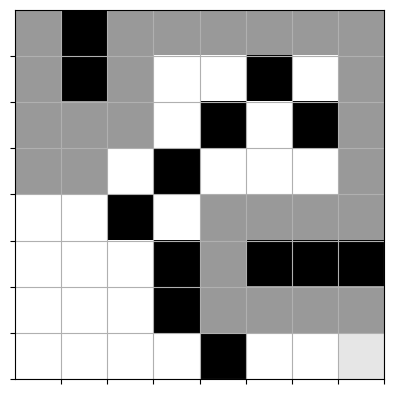

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 521/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 366 | Win rate: 1.000 | time: 24.69 minutes
   win | Epoch Reward: -1.6300000000000008 | LUDUDURUURRRURRDDDLLDLrLDDRRRD


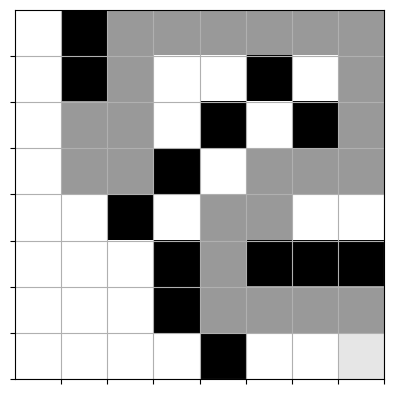

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 522/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 367 | Win rate: 1.000 | time: 24.75 minutes
   win | Epoch Reward: 0.76 | DDDRDRR


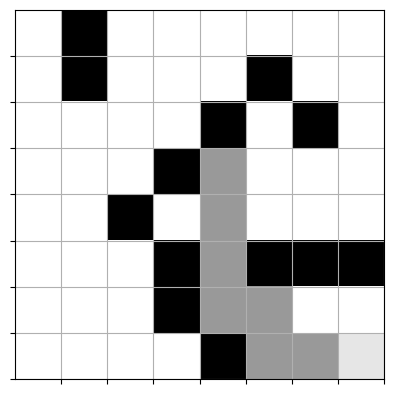

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 523/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 368 | Win rate: 1.000 | time: 24.80 minutes
   win | Epoch Reward: 0.72 | DLDdRDRR


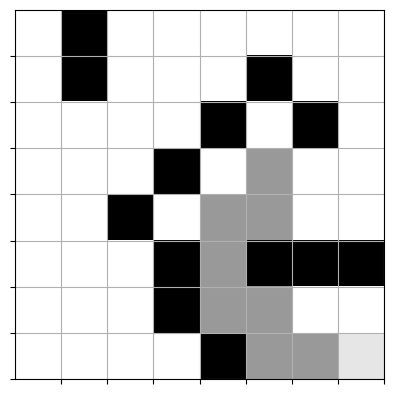

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 524/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 369 | Win rate: 1.000 | time: 24.85 minutes
   win | Epoch Reward: 0.6799999999999999 | LDLDDRRRD


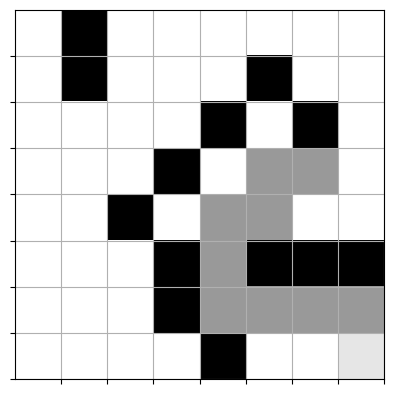

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 525/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 370 | Win rate: 1.000 | time: 24.90 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


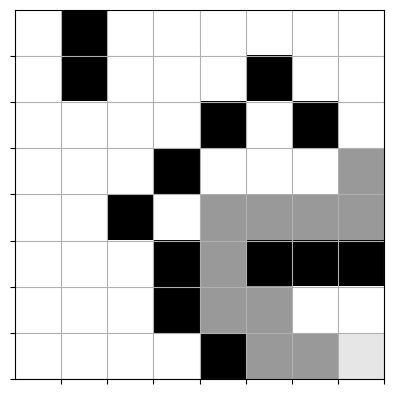

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 6), (1, 3)]
FAILED START CELL:  (1, 7)
Epoch: 526/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 371 | Win rate: 1.000 | time: 24.98 minutes
   win | Epoch Reward: -1.2500000000000004 | DRUUURUURRrDDDRRDDDLLDLDDuDRDRR


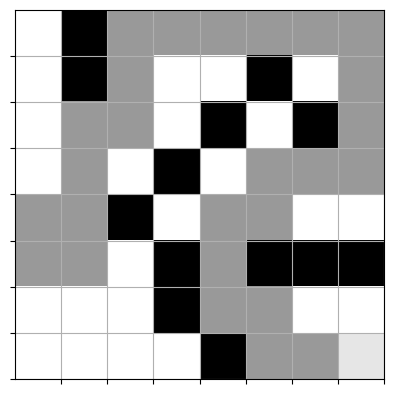

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 527/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 372 | Win rate: 1.000 | time: 25.07 minutes
   win | Epoch Reward: -24.039999999999985 | UdUULUUDUDDDRUdULUuLLLLLLLLLLLDUDDDuDUUULLLLDUDUDUuDUDUDUDUDUDUDUDUDUDUuDRRRUDULLLLLDRRRRRDDLLLLLLRURUURRRRRDDDLLDLDDRRRlRD


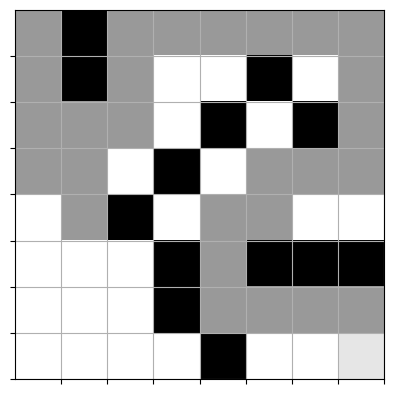

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (5, 4), (4, 6), (5, 1), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (4, 5), (5, 0), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (4, 7), (3, 5), (5, 2), (4, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (6, 0)
Epoch: 528/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 373 | Win rate: 1.000 | time: 25.16 minutes
   win | Epoch Reward: 0.76 | RDDRRRD


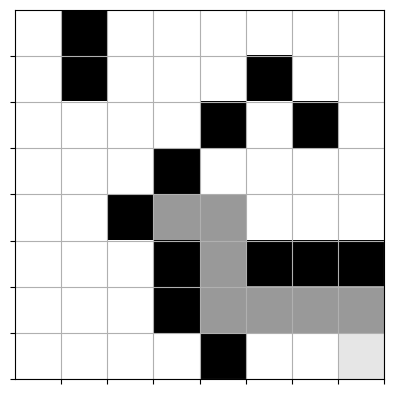

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 529/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 374 | Win rate: 1.000 | time: 25.21 minutes
   win | Epoch Reward: 0.8 | DDRDRR


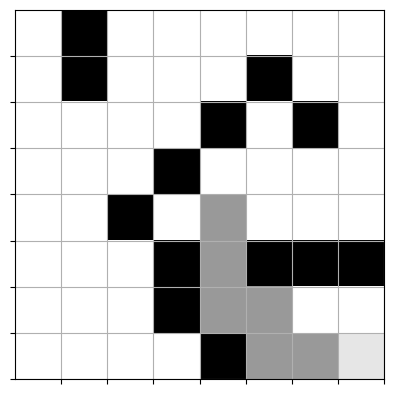

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 530/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 375 | Win rate: 1.000 | time: 25.26 minutes
   win | Epoch Reward: 0.76 | LDDRDRR


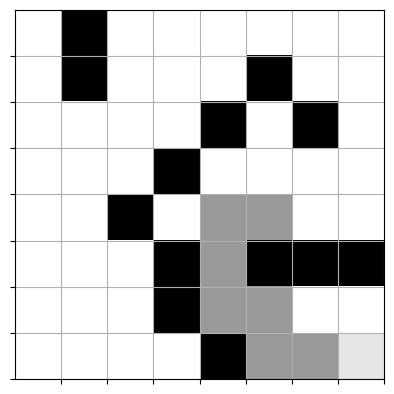

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 531/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 376 | Win rate: 1.000 | time: 25.31 minutes
   win | Epoch Reward: 0.72 | LLDDRRRD


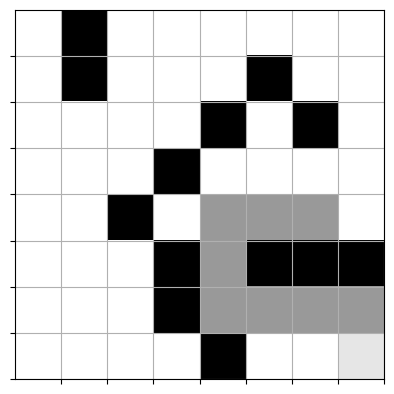

SUCCESSFUL START CELLS: [(0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (0, 7)
Epoch: 532/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 377 | Win rate: 1.000 | time: 25.37 minutes
   win | Epoch Reward: 0.17999999999999994 | LLLDDRlRDRR


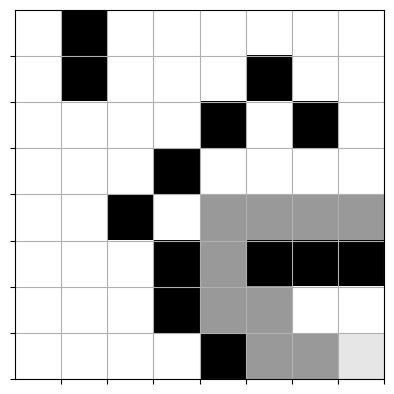

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 533/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 378 | Win rate: 1.000 | time: 25.43 minutes
   win | Epoch Reward: -0.21000000000000063 | RUURDURURURRRDDDDLLLDDRRRD


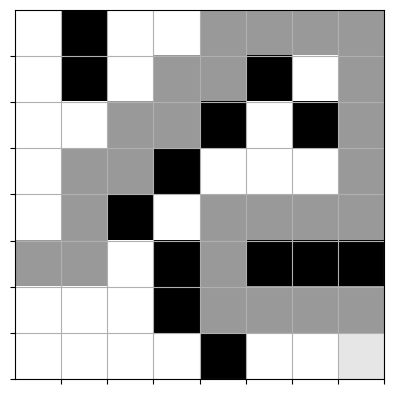

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 534/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 379 | Win rate: 1.000 | time: 25.49 minutes
   win | Epoch Reward: -1.7100000000000009 | LRLRUURUUURRRlRRRDDDuDLLDLDDRDRR


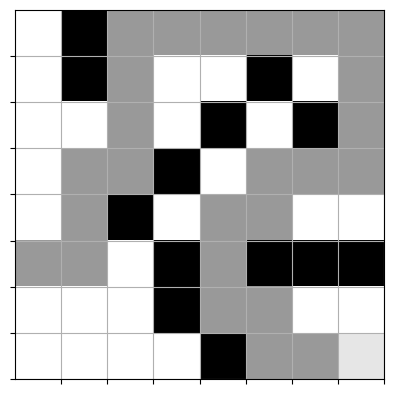

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 535/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 379 | Win rate: 0.969 | time: 25.59 minutes
   lose | Epoch Reward: -32.019999999999996 | DLLDdLLLLLLLLUDUDUDLLLLdLLLLLLUDULLLLDLLLLDDDdLLLLLLLLuDuDDDDudUDLLLLLLLLrLDLLURUUUULDDDDDDDUDUULLLLLrULDDDDlLLULLLLLLDUDUDUDUDUDLLUDrLURUU


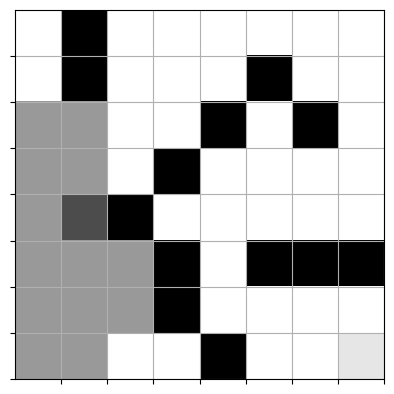

Epoch: 536/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 380 | Win rate: 0.969 | time: 25.62 minutes
   win | Epoch Reward: 0.84 | DRDRR


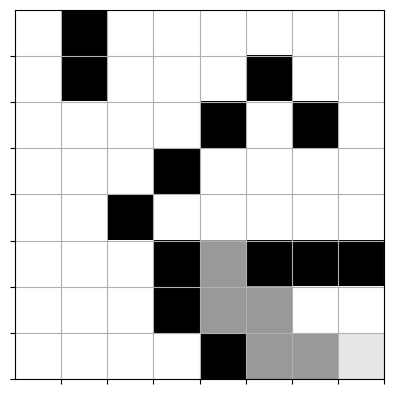

Epoch: 537/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 381 | Win rate: 0.969 | time: 25.67 minutes
   win | Epoch Reward: -1.0400000000000005 | RUlRUURURURURRulRRDDDLLDLDDRDRR


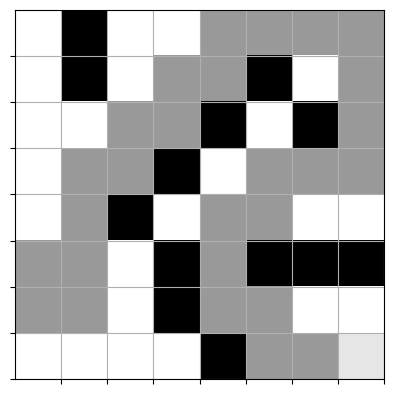

Epoch: 538/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 382 | Win rate: 0.969 | time: 25.73 minutes
   win | Epoch Reward: -0.46000000000000063 | UUUURUUlRRRRRuDDDLLDLDDRRRD


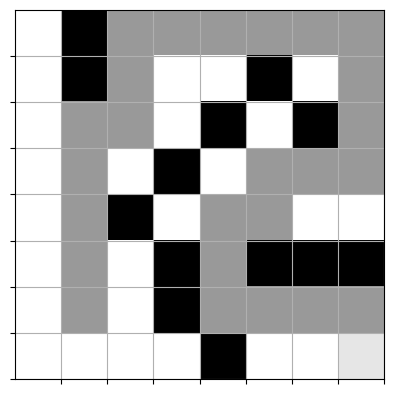

Epoch: 539/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 383 | Win rate: 0.969 | time: 25.78 minutes
   win | Epoch Reward: -0.25000000000000067 | LUUUURUUuRRRRRDDDLLDLDDRDRR


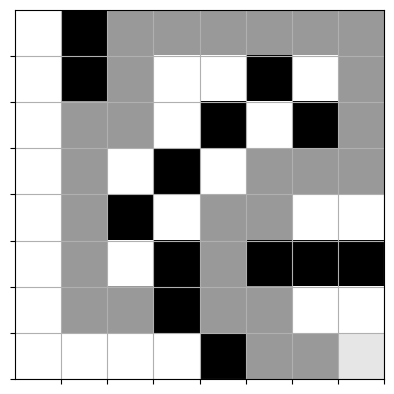

Epoch: 540/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 384 | Win rate: 0.969 | time: 25.82 minutes
   win | Epoch Reward: 0.88 | RrRD


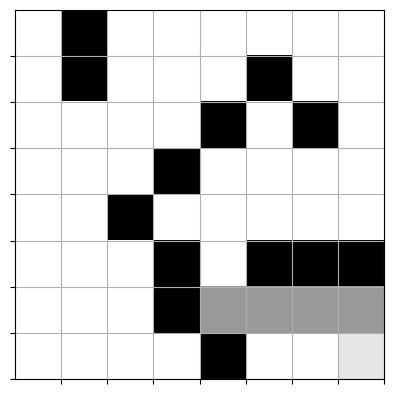

Epoch: 541/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 385 | Win rate: 0.969 | time: 25.86 minutes
   win | Epoch Reward: 0.92 | RRD


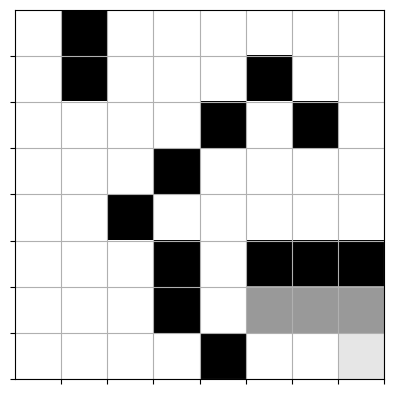

Epoch: 542/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 386 | Win rate: 0.969 | time: 25.90 minutes
   win | Epoch Reward: 0.96 | RD


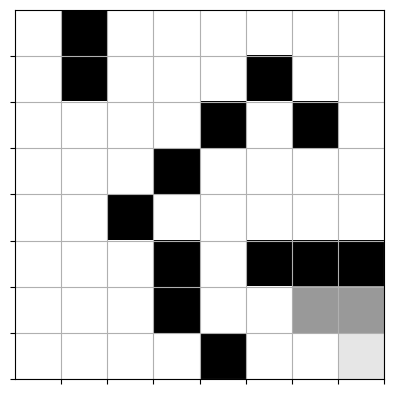

Epoch: 543/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 387 | Win rate: 0.969 | time: 25.94 minutes
   win | Epoch Reward: 1.0 | D


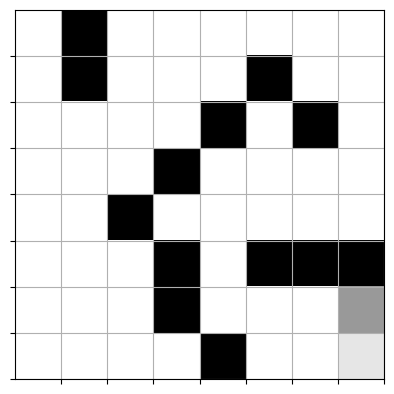

Epoch: 544/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 388 | Win rate: 0.969 | time: 25.99 minutes
   win | Epoch Reward: -0.8300000000000005 | URUUUURUUdRRURRRDDDDUDLlLDDRRrD


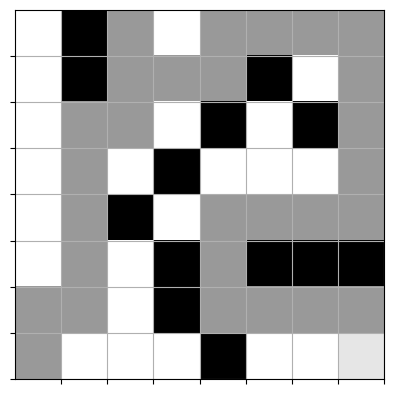

Epoch: 545/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 389 | Win rate: 0.969 | time: 26.04 minutes
   win | Epoch Reward: -0.0800000000000003 | RULUUURUUURRRRRDDDLLDLDDRRRD


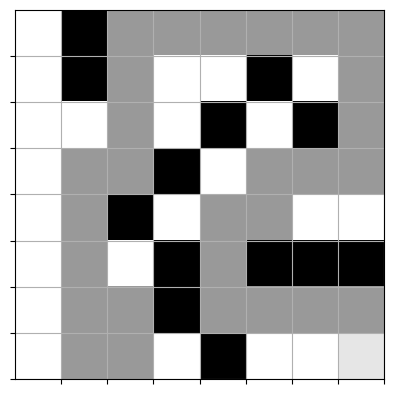

Epoch: 546/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 390 | Win rate: 0.969 | time: 26.09 minutes
   win | Epoch Reward: -0.5400000000000005 | ULUUUURUURRlRRRRDDDLLDLDDRRRD


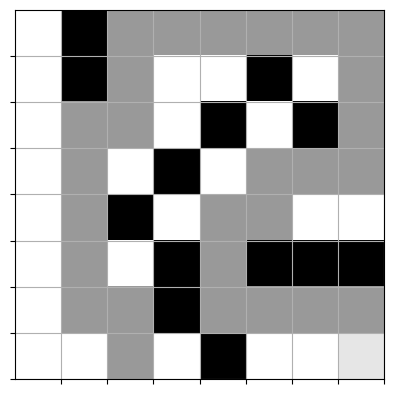

Epoch: 547/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 391 | Win rate: 0.969 | time: 26.14 minutes
   win | Epoch Reward: -1.620000000000001 | UUUrlULUUUURUURRRRRDDDLLDLlRDDdRDRR


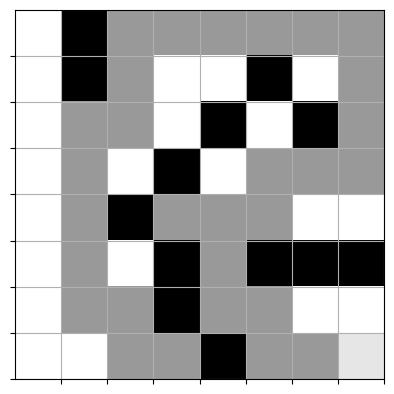

Epoch: 548/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 392 | Win rate: 0.969 | time: 26.18 minutes
   win | Epoch Reward: 0.96 | RR


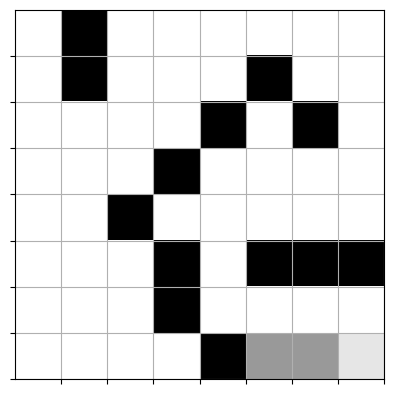

Epoch: 549/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 393 | Win rate: 0.969 | time: 26.22 minutes
   win | Epoch Reward: 1.0 | R


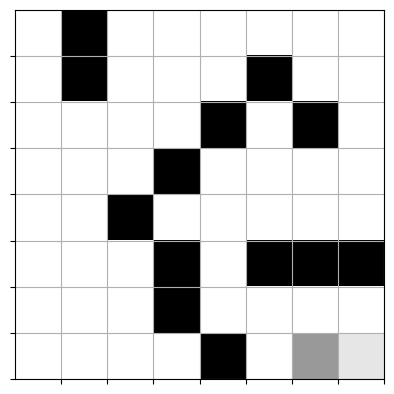

Epoch: 550/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 394 | Win rate: 0.969 | time: 26.27 minutes
   win | Epoch Reward: -2.160000000000001 | RRRRuRDDuDDDDRUURUURRURRRDDDLLDLDDRDRR


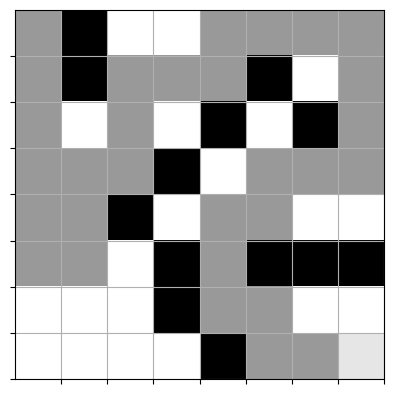

Epoch: 551/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 395 | Win rate: 0.969 | time: 26.32 minutes
   win | Epoch Reward: 0.31999999999999995 | RRRRRDDDLLDLDDRRRD


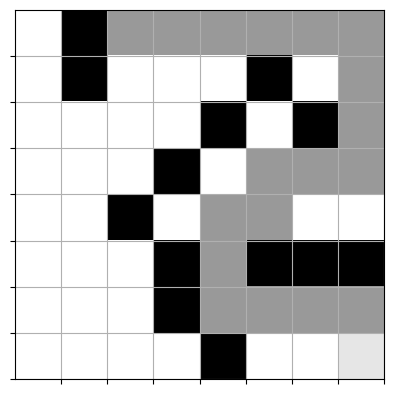

Epoch: 552/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 396 | Win rate: 0.969 | time: 26.36 minutes
   win | Epoch Reward: -0.43000000000000016 | RRRRDDDLLDRULDLDDRDRR


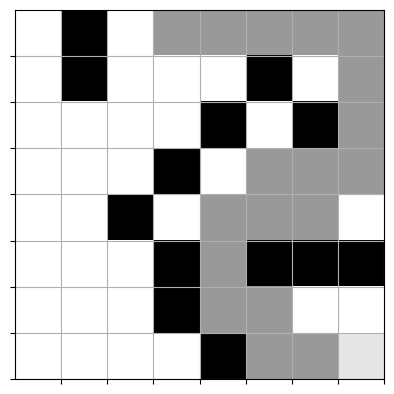

Epoch: 553/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 397 | Win rate: 0.969 | time: 26.41 minutes
   win | Epoch Reward: 0.4 | RRRDDDLLDLDDRDRR


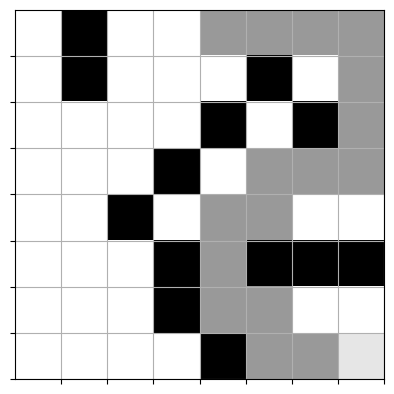

Epoch: 554/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 398 | Win rate: 0.969 | time: 26.46 minutes
   win | Epoch Reward: -3.1000000000000005 | RRDDDLLRLuRRRRRRRRRRRDDldDRRRD


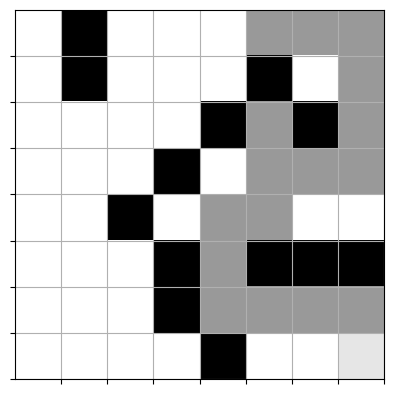

Epoch: 555/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 399 | Win rate: 0.969 | time: 26.50 minutes
   win | Epoch Reward: 0.22999999999999987 | RRDDDDLLLDDRDRR


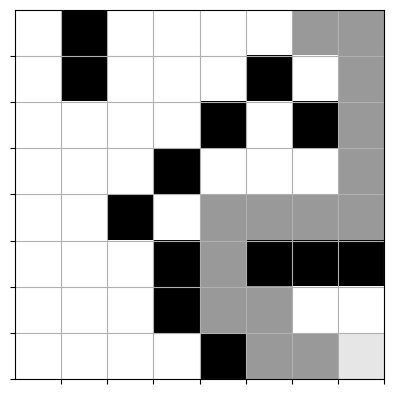

Epoch: 556/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 400 | Win rate: 0.969 | time: 26.55 minutes
   win | Epoch Reward: 0.52 | DDDDLLLDDRDRR


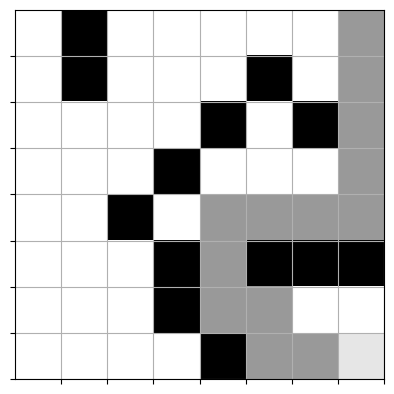

Epoch: 557/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 401 | Win rate: 0.969 | time: 26.60 minutes
   win | Epoch Reward: -3.710000000000001 | DRRRUDDUDUURDURRRDLRLRLRDDLLDDLDrDRDRlRR


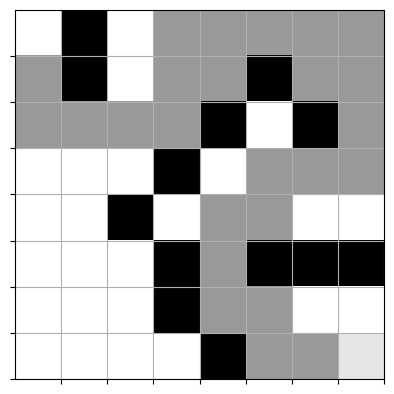

Epoch: 558/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 402 | Win rate: 0.969 | time: 26.64 minutes
   win | Epoch Reward: -0.4700000000000002 | URURRRRDDDDLLLDDRDRlRR


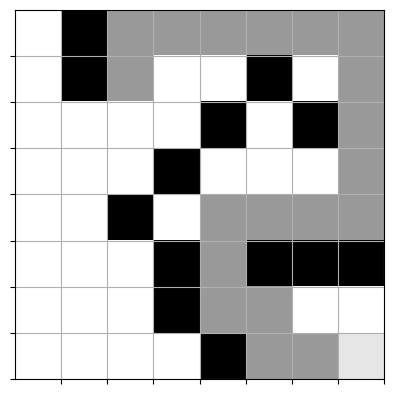

Epoch: 559/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 403 | Win rate: 0.969 | time: 26.69 minutes
   win | Epoch Reward: 0.31999999999999995 | RURRRDDDLLDLDDRDRR


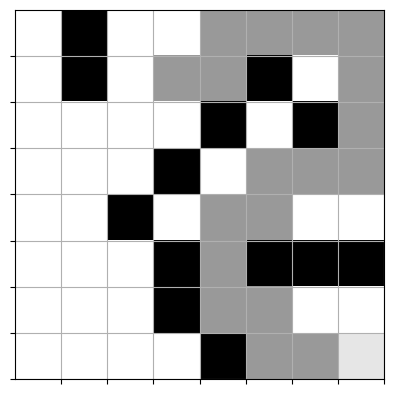

Epoch: 560/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 404 | Win rate: 0.969 | time: 26.73 minutes
   win | Epoch Reward: 0.36 | uRRRDDDLLDLDDRRRD


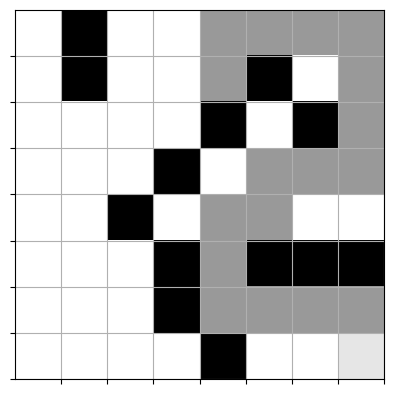

Epoch: 561/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 405 | Win rate: 0.969 | time: 26.78 minutes
   win | Epoch Reward: 0.18999999999999984 | lURDDDDLLLDDRDRR


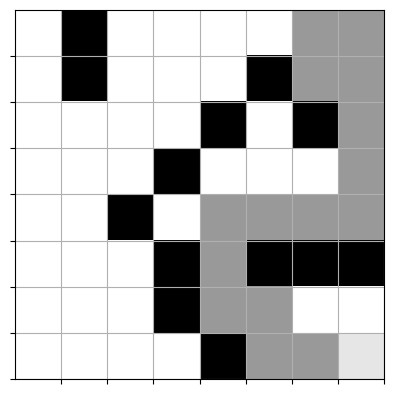

Epoch: 562/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 406 | Win rate: 0.969 | time: 26.82 minutes
   win | Epoch Reward: 0.56 | DDLLDLDDRDRR


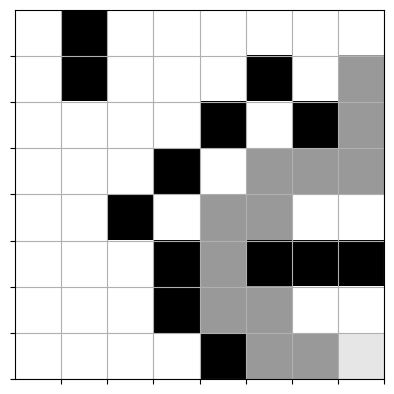

Epoch: 563/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 407 | Win rate: 0.969 | time: 26.87 minutes
   win | Epoch Reward: -3.5300000000000002 | UDDDDDDDDDDDDDDURUUURUUURRRRDDDURDDDDLLLDDRDRR


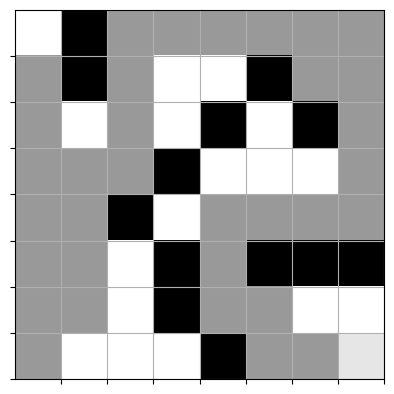

Epoch: 564/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 408 | Win rate: 0.969 | time: 26.92 minutes
   win | Epoch Reward: -0.8000000000000007 | RRlRURRRURRRDDDLLDLDDRRRD


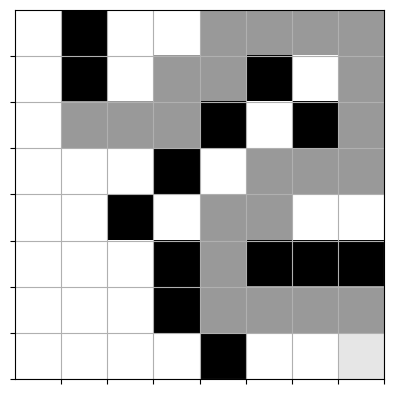

Epoch: 565/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 409 | Win rate: 0.969 | time: 26.97 minutes
   win | Epoch Reward: -1.7600000000000002 | RURURRRDUDUDDDLLRLdLDuDDRRRD


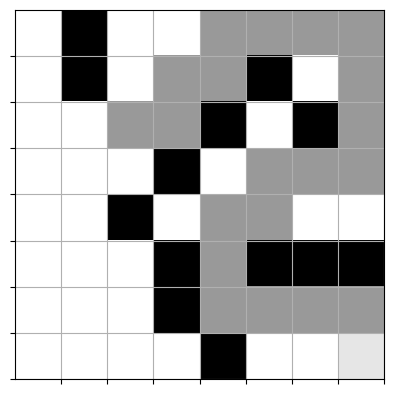

Epoch: 566/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 410 | Win rate: 0.969 | time: 27.01 minutes
   win | Epoch Reward: 0.2799999999999999 | UuRRRRDDDDLLLDDRDRR


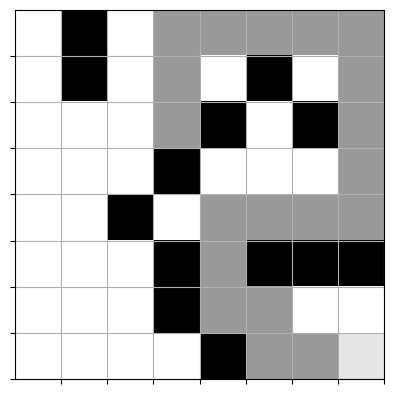

Epoch: 567/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 411 | Win rate: 1.000 | time: 27.06 minutes
   win | Epoch Reward: 0.17999999999999972 | LLDDLDDRDRr


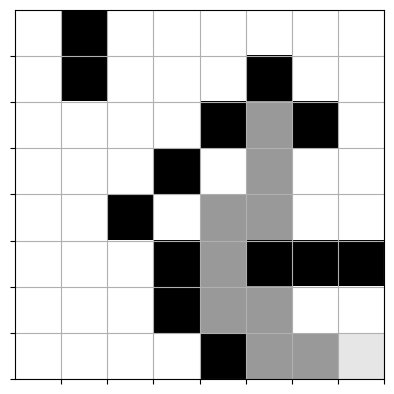

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 568/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 412 | Win rate: 1.000 | time: 27.13 minutes
   win | Epoch Reward: 0.6000000000000001 | DDLLLDDRDRR


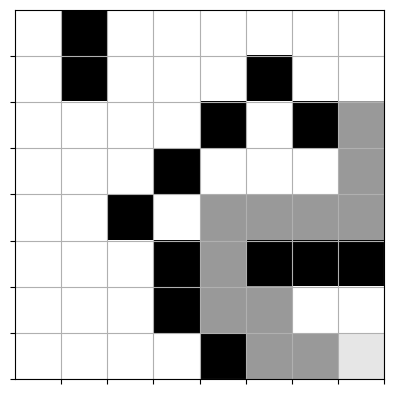

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 569/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 413 | Win rate: 1.000 | time: 27.19 minutes
   win | Epoch Reward: -0.8800000000000001 | RURUURRRRRDDDLuLDLDDRDDuDRR


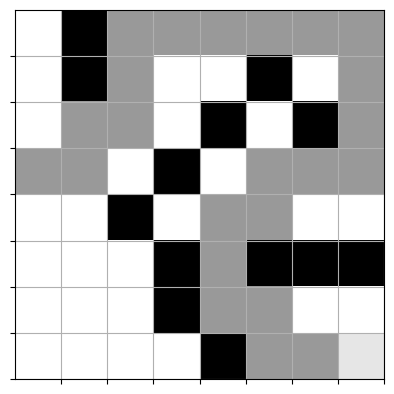

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 570/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 414 | Win rate: 1.000 | time: 27.24 minutes
   win | Epoch Reward: -0.8400000000000005 | URRRRRURURRRDDdDLLLDrDRRRD


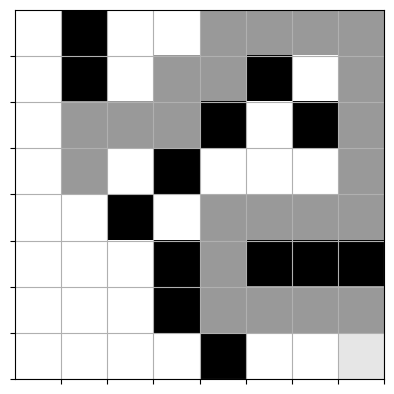

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 571/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 415 | Win rate: 1.000 | time: 27.30 minutes
   win | Epoch Reward: -0.5500000000000005 | UUUUURURRRRDDDDLLLDDRRRD


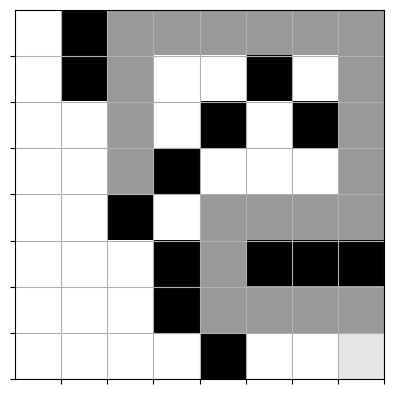

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (2, 1), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (0, 2), (1, 7), (0, 5), (1, 0), (1, 6), (1, 3)]
FAILED START CELL:  (2, 2)
Epoch: 572/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 416 | Win rate: 1.000 | time: 27.37 minutes
   win | Epoch Reward: 0.76 | DDDRDRR


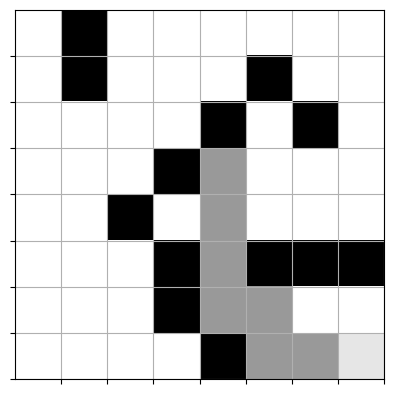

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 573/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 417 | Win rate: 1.000 | time: 27.42 minutes
   win | Epoch Reward: 0.72 | DLDDRDRR


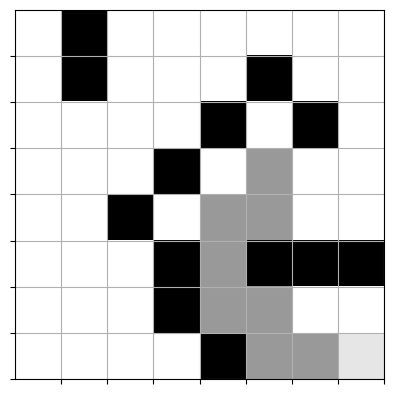

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (3, 1), (3, 7), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (3, 5), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (4, 3)
Epoch: 574/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 418 | Win rate: 1.000 | time: 27.51 minutes
   win | Epoch Reward: 0.42999999999999994 | LDLDrDRDRR


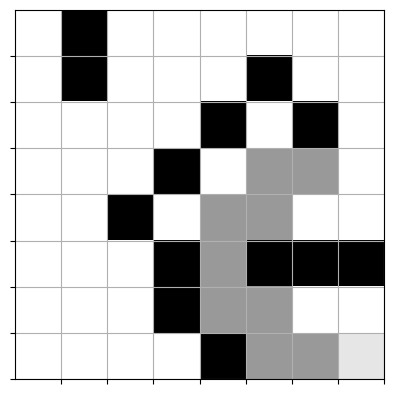

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 575/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 419 | Win rate: 1.000 | time: 27.57 minutes
   win | Epoch Reward: 0.3899999999999999 | DLLLDDRDdRR


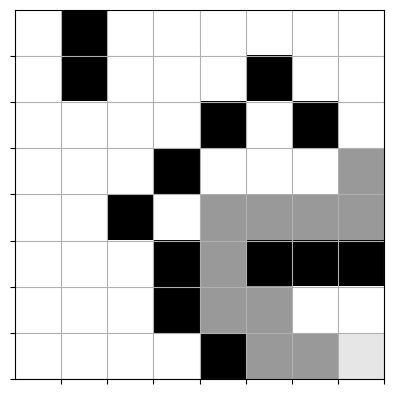

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 576/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 420 | Win rate: 1.000 | time: 27.63 minutes
   win | Epoch Reward: -0.37000000000000055 | DDRUUUURDUUURRRRRDDDDLLLDDRRRD


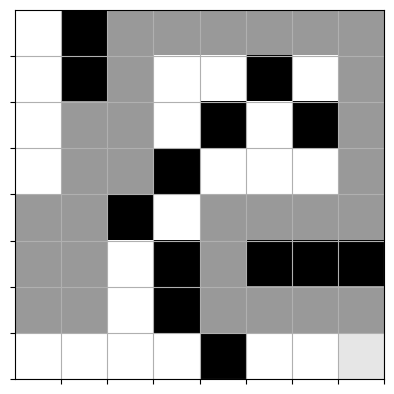

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 577/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 421 | Win rate: 1.000 | time: 27.69 minutes
   win | Epoch Reward: -0.13000000000000056 | UURRUUuRRRRDDDDLLLDDRRrD


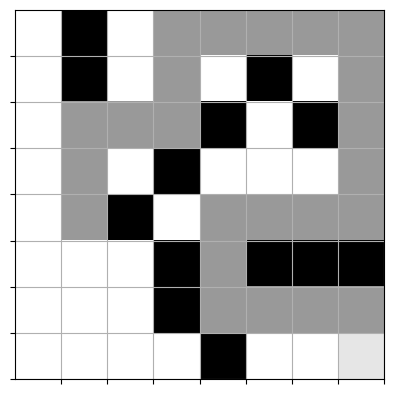

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 578/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 422 | Win rate: 1.000 | time: 27.74 minutes
   win | Epoch Reward: -0.7400000000000002 | DDDDDDRDDRRRD


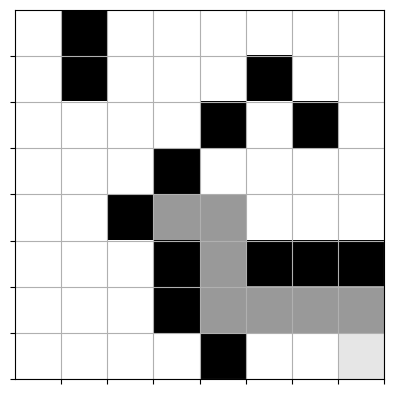

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 579/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 423 | Win rate: 1.000 | time: 27.79 minutes
   win | Epoch Reward: 0.8 | DDRDRR


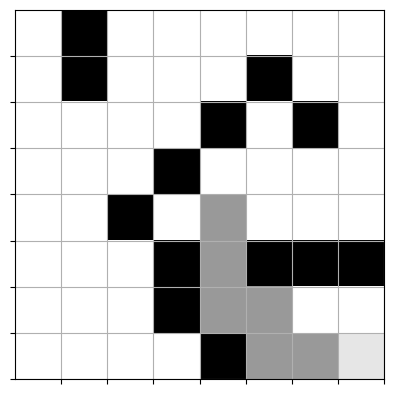

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 580/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 424 | Win rate: 1.000 | time: 27.85 minutes
   win | Epoch Reward: 0.76 | LDDRRRD


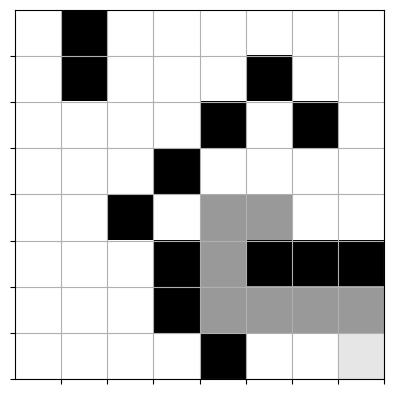

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 581/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 425 | Win rate: 1.000 | time: 27.90 minutes
   win | Epoch Reward: 0.72 | LLDDRDrR


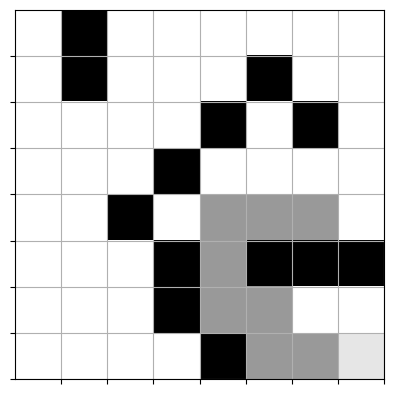

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 582/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 426 | Win rate: 1.000 | time: 27.96 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDDRRRD


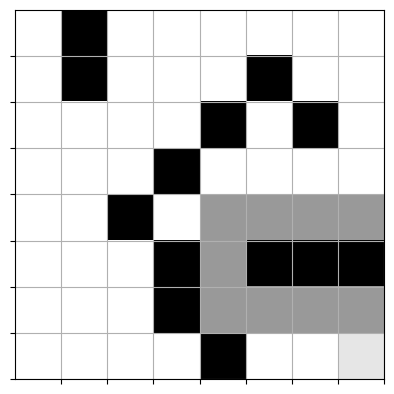

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 583/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 427 | Win rate: 1.000 | time: 28.03 minutes
   win | Epoch Reward: -0.5400000000000003 | DRUUUURUURRRRRDDDDLLLDDRRuRuD


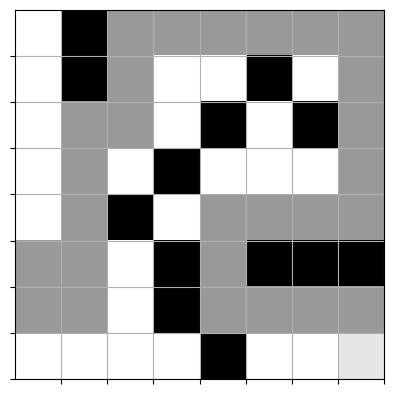

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 584/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 428 | Win rate: 1.000 | time: 28.11 minutes
   win | Epoch Reward: -0.4200000000000004 | UUURUURRRRRDDDuDDLLLDDRRRD


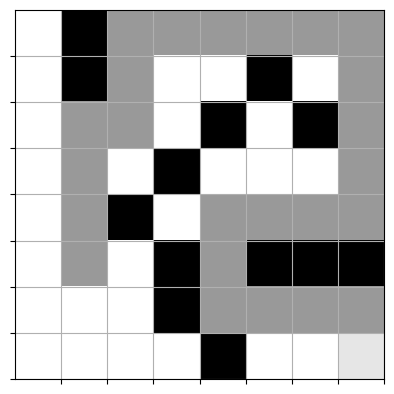

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 585/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 429 | Win rate: 1.000 | time: 28.18 minutes
   win | Epoch Reward: -0.7900000000000005 | UDLUUUUdUrUrURRRRDDDDLLLDDRDRR


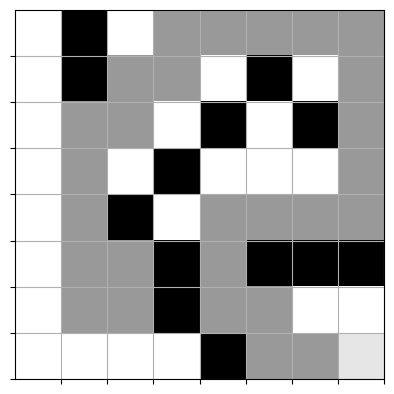

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 586/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 430 | Win rate: 1.000 | time: 28.25 minutes
   win | Epoch Reward: 0.84 | DRRRD


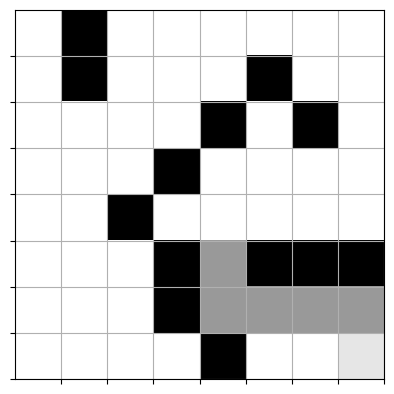

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 587/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 431 | Win rate: 1.000 | time: 28.32 minutes
   win | Epoch Reward: -0.2900000000000007 | RUUUlRURUURRRRRDDDDLLLDDRRRD


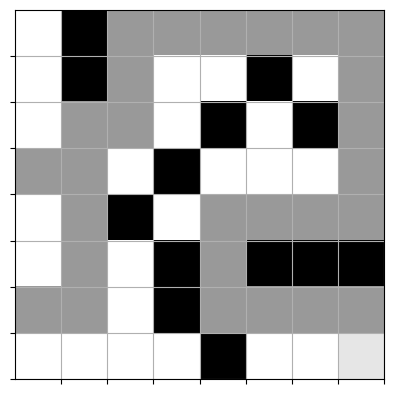

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 588/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 432 | Win rate: 1.000 | time: 28.40 minutes
   win | Epoch Reward: -3.830000000000001 | UDUUlUUURRRRRDDDUUrRUURRRRlRRDDDDLdLLDDRRRD


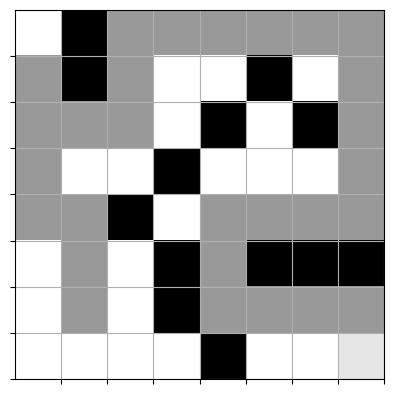

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 589/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 433 | Win rate: 1.000 | time: 28.46 minutes
   win | Epoch Reward: -1.2500000000000004 | ULUrUURUURRRRRDDuDuDDLLDLDDRDRR


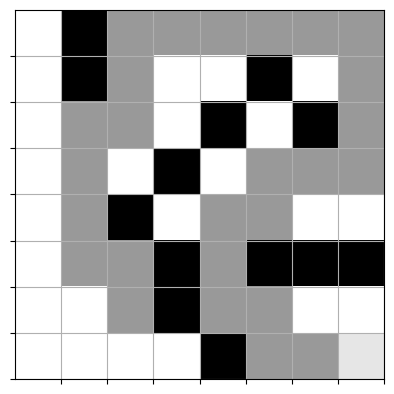

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 590/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 434 | Win rate: 1.000 | time: 28.52 minutes
   win | Epoch Reward: 0.88 | RRRD


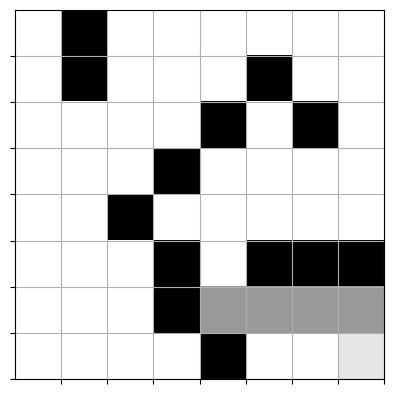

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 591/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 435 | Win rate: 1.000 | time: 28.58 minutes
   win | Epoch Reward: 0.92 | RRD


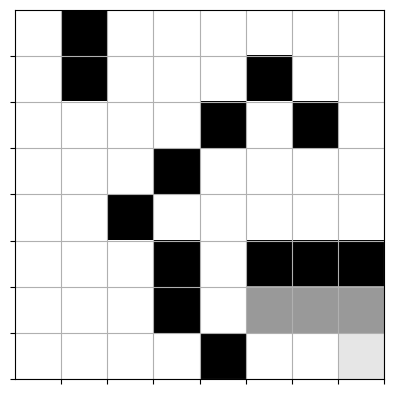

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 592/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 436 | Win rate: 1.000 | time: 28.64 minutes
   win | Epoch Reward: 0.96 | RD


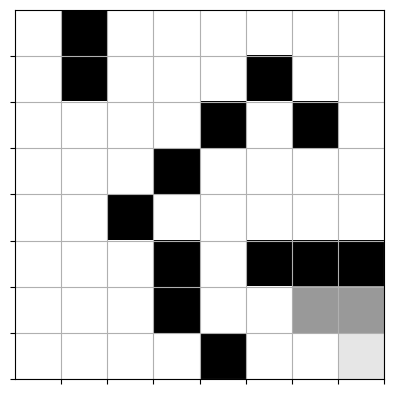

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (5, 4), (4, 6), (5, 1), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (4, 5), (5, 0), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (4, 7), (3, 5), (5, 2), (4, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (6, 0)
Epoch: 593/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 437 | Win rate: 1.000 | time: 28.75 minutes
   win | Epoch Reward: 1.0 | D


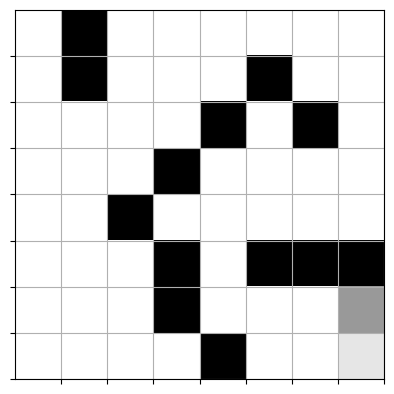

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (5, 4), (4, 6), (5, 1), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (4, 5), (5, 0), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (4, 7), (3, 5), (5, 2), (4, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (6, 0)
Epoch: 594/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 438 | Win rate: 1.000 | time: 28.87 minutes
   win | Epoch Reward: -1.950000000000001 | RRULUULRLRLLRLuRURUURRRRRDDDDLLLDDRRRD


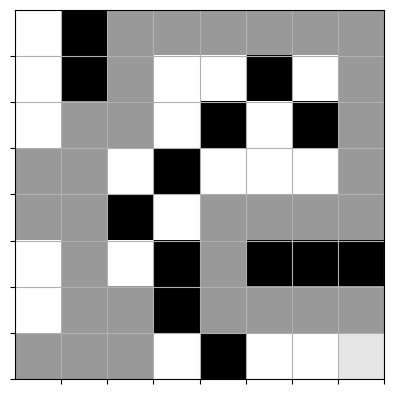

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 595/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 439 | Win rate: 1.000 | time: 28.95 minutes
   win | Epoch Reward: -1.2500000000000004 | UUUURUUURRRRRDDDLLLUUUDDDuDRRRD


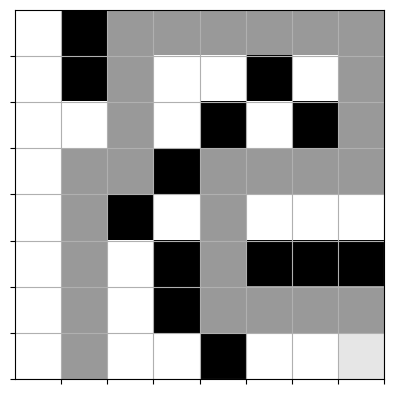

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 596/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 440 | Win rate: 1.000 | time: 29.04 minutes
   win | Epoch Reward: -10.029999999999994 | RLRLLLUURdUrLUUURUURRRRRDDDLLRLULLLLLLLUUUUUUURRRRRRLLLLLLUlUUUDDLDDRRRD


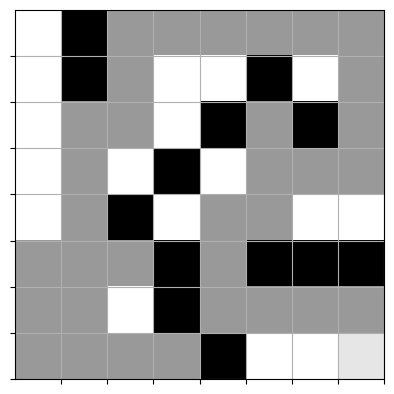

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 597/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 441 | Win rate: 1.000 | time: 29.13 minutes
   win | Epoch Reward: -2.450000000000001 | ULLLRRULULLLLLLRUUURUURRRRRDDDLLDLDDRRRD


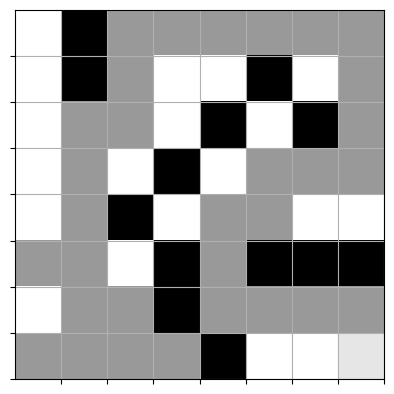

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 598/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 442 | Win rate: 1.000 | time: 29.18 minutes
   win | Epoch Reward: 0.96 | RR


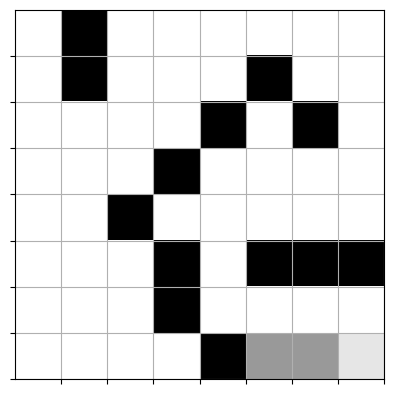

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 599/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 443 | Win rate: 1.000 | time: 29.24 minutes
   win | Epoch Reward: 1.0 | R


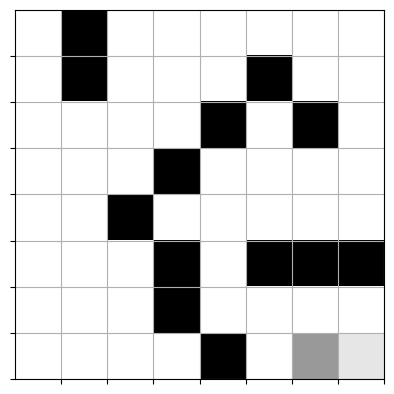

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 600/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 444 | Win rate: 1.000 | time: 29.31 minutes
   win | Epoch Reward: -2.500000000000001 | RRRRLLLLDDlDRRUUURRRRRDDDDRLLLDDRRRD


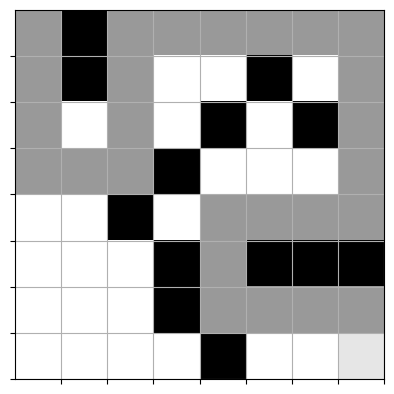

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 601/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 445 | Win rate: 1.000 | time: 29.39 minutes
   win | Epoch Reward: -3.2600000000000007 | RRRRRDLRLRRRRRDDlRRRRRLRdLLLDDRRRD


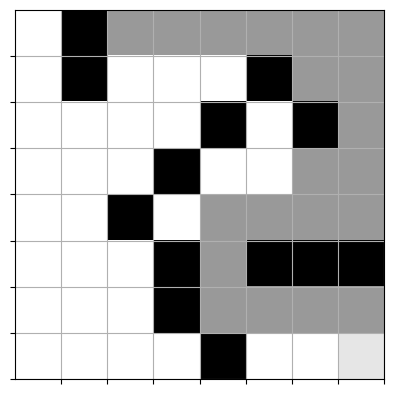

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 602/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 446 | Win rate: 1.000 | time: 29.45 minutes
   win | Epoch Reward: -0.7200000000000006 | DRURlRRRDDDLDLDDlDDRRRD


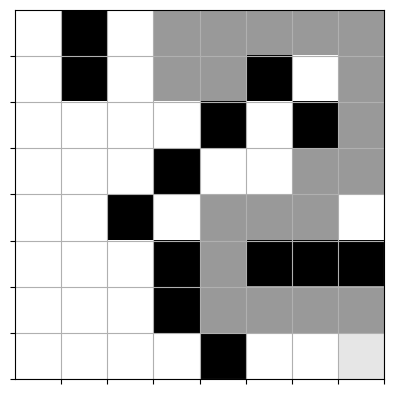

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 603/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 447 | Win rate: 1.000 | time: 29.52 minutes
   win | Epoch Reward: 0.10999999999999988 | RRRDDDlDLLuDDDRRRD


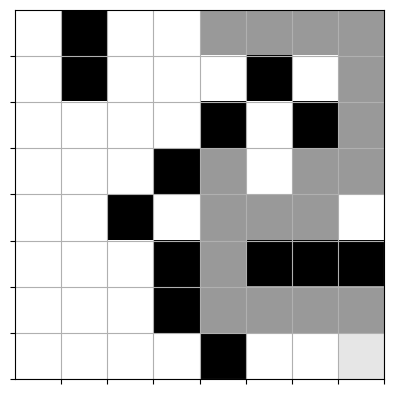

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 604/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 448 | Win rate: 1.000 | time: 29.59 minutes
   win | Epoch Reward: 0.44000000000000006 | RRDDDDLlLDDRRRD


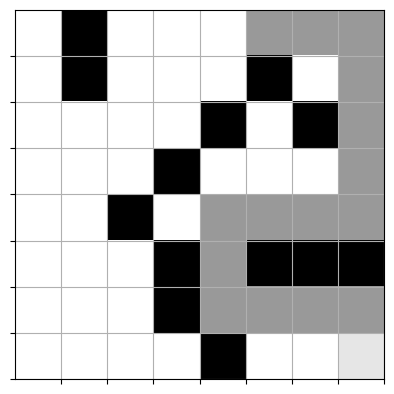

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 605/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 449 | Win rate: 1.000 | time: 29.65 minutes
   win | Epoch Reward: 0.4800000000000001 | RDDDDLLLDDRRRD


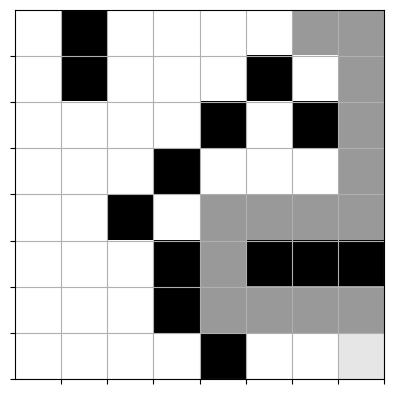

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 606/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 450 | Win rate: 1.000 | time: 29.71 minutes
   win | Epoch Reward: 0.2699999999999998 | DDDDLLDLDDRDRR


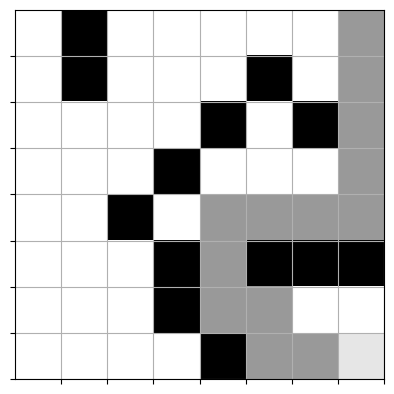

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 607/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 451 | Win rate: 1.000 | time: 29.79 minutes
   win | Epoch Reward: -1.990000000000001 | UDUDUDDDDDDDUuRUUURUURRRRRDDDDLLLDDRRRD


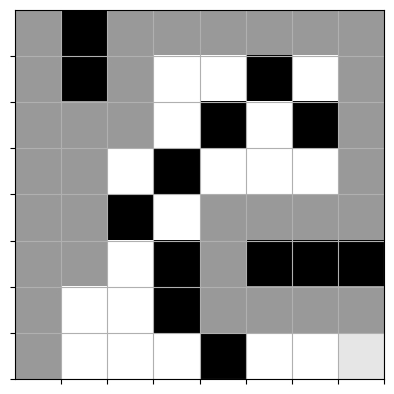

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 608/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 452 | Win rate: 1.000 | time: 29.87 minutes
   win | Epoch Reward: -0.4700000000000002 | URRRRRDDDDLLrLLDDlRRRD


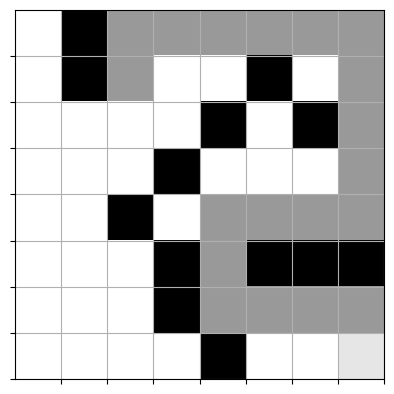

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 0)]
FAILED START CELL:  (0, 4)
Epoch: 609/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 453 | Win rate: 1.000 | time: 29.94 minutes
   win | Epoch Reward: -1.2200000000000002 | UuRRRRDLRLRLRDdLLDLDDRRRD


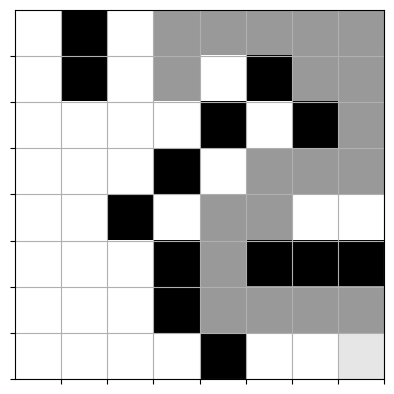

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 610/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 454 | Win rate: 1.000 | time: 30.03 minutes
   win | Epoch Reward: -0.39000000000000035 | URRRDDrDLLDLDDRRRlRD


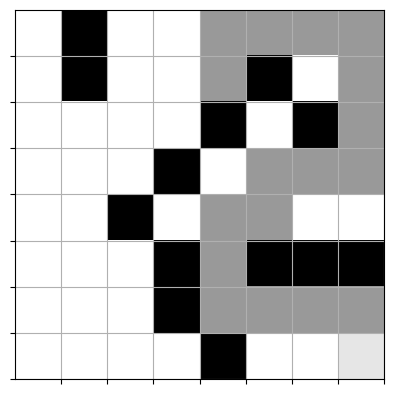

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 611/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 455 | Win rate: 1.000 | time: 30.10 minutes
   win | Epoch Reward: -0.3100000000000003 | URDDuDrDDLLLDDRRRD


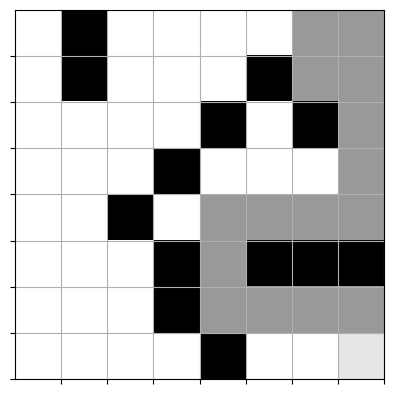

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 612/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 456 | Win rate: 1.000 | time: 30.17 minutes
   win | Epoch Reward: 0.05999999999999972 | DDDLDDLLDdRdRR


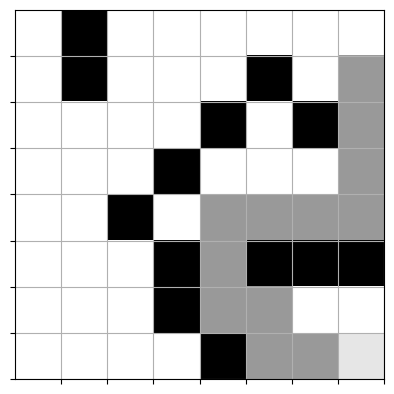

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 613/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 457 | Win rate: 1.000 | time: 30.24 minutes
   win | Epoch Reward: -7.199999999999996 | DDDdDUDUDUUDDUDUDDDDDDDURUUdUUURUDUlDUURRRRRlRDDDDLLLDDRDrR


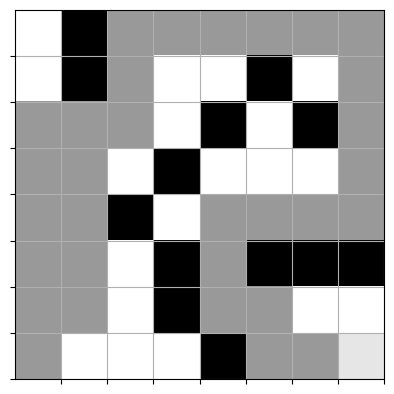

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 614/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 458 | Win rate: 1.000 | time: 30.32 minutes
   win | Epoch Reward: -2.880000000000001 | DRULRLRLDUDUDURURRURRRDDDLLDLDDRRRD


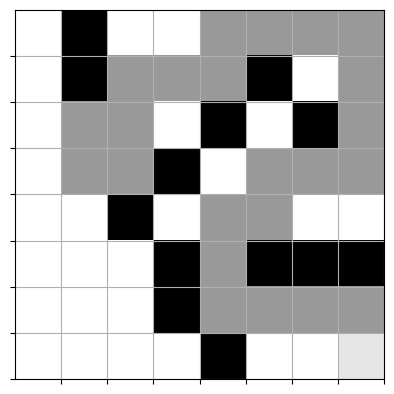

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 615/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 459 | Win rate: 1.000 | time: 30.41 minutes
   win | Epoch Reward: -0.26000000000000045 | UURRlRRRRDDDDLLLDDRDRR


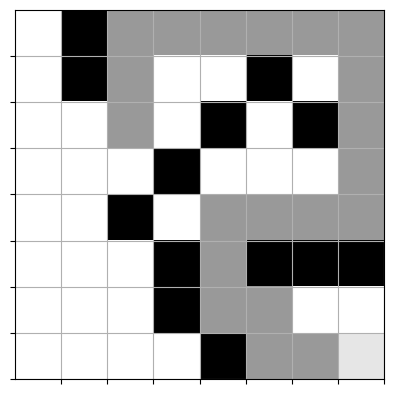

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 616/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 460 | Win rate: 1.000 | time: 30.49 minutes
   win | Epoch Reward: 0.19999999999999984 | UURRRRDDDDLULDLDDRDRR


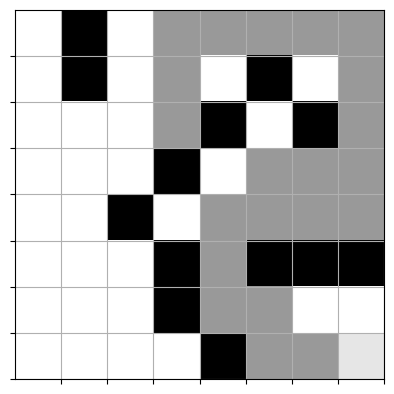

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 617/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 461 | Win rate: 1.000 | time: 30.55 minutes
   win | Epoch Reward: 0.6799999999999999 | DDlDDRDRR


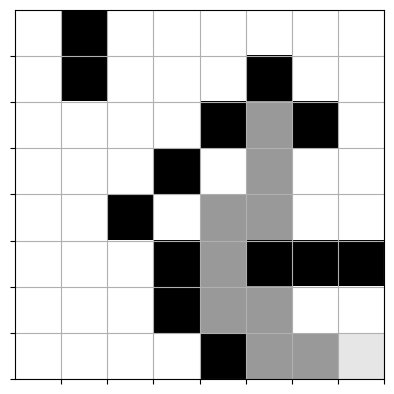

SUCCESSFUL START CELLS: [(0, 4), (0, 0), (0, 3), (0, 2), (0, 5)]
FAILED START CELL:  (0, 6)
Epoch: 618/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 462 | Win rate: 1.000 | time: 30.63 minutes
   win | Epoch Reward: 0.35 | DDLLLDDRDlRR


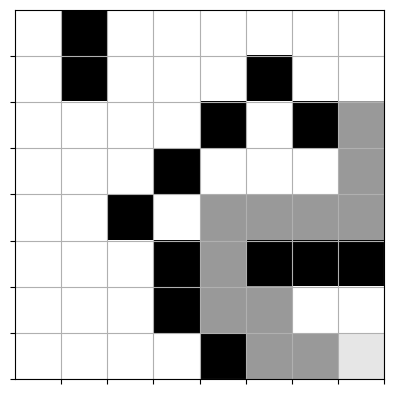

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 619/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 463 | Win rate: 1.000 | time: 30.70 minutes
   win | Epoch Reward: -1.1200000000000006 | DDDRUUURURRRRRURURRRDDDDLLLDDRDRR


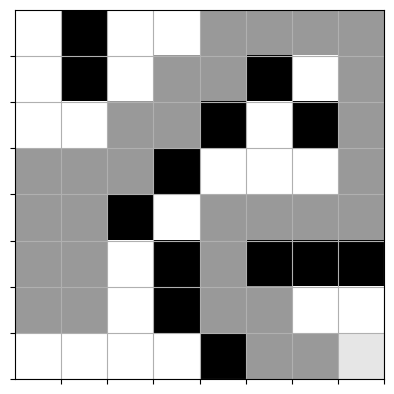

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 620/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 464 | Win rate: 1.000 | time: 30.79 minutes
   win | Epoch Reward: 0.07999999999999974 | URRURURRRDDDDLULDLDDRRRD


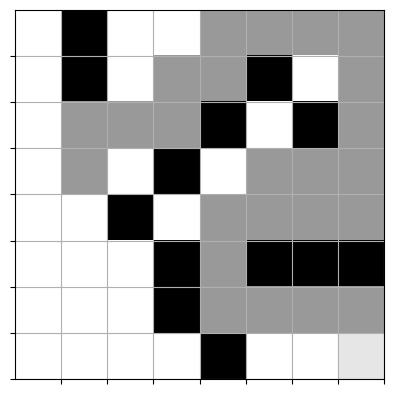

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 0)]
FAILED START CELL:  (0, 4)
Epoch: 621/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 465 | Win rate: 1.000 | time: 30.87 minutes
   win | Epoch Reward: -2.880000000000001 | UUURDURRRRDUDUDDDLLDLUDUUUDUDDDRDRR


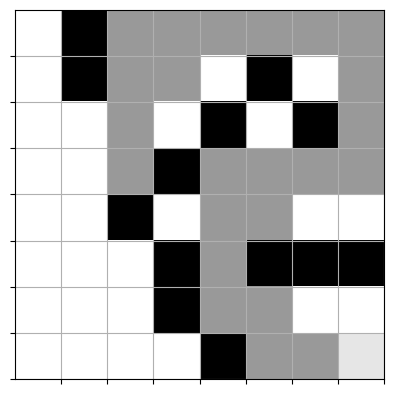

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 622/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 466 | Win rate: 1.000 | time: 30.94 minutes
   win | Epoch Reward: 0.51 | DDDdRDRR


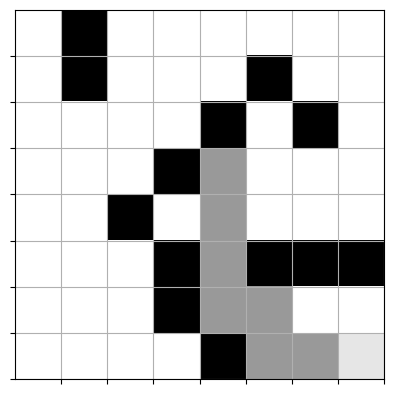

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 623/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 467 | Win rate: 1.000 | time: 31.00 minutes
   win | Epoch Reward: 0.72 | DLDDRDRR


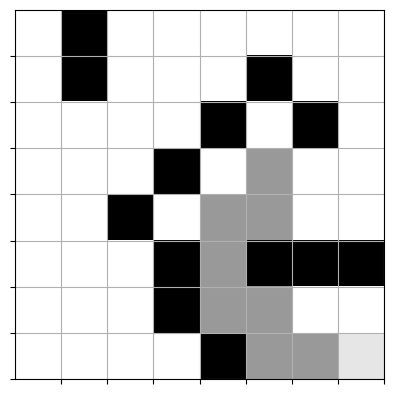

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 624/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 468 | Win rate: 1.000 | time: 31.06 minutes
   win | Epoch Reward: 0.6799999999999999 | LLDDDRDRr


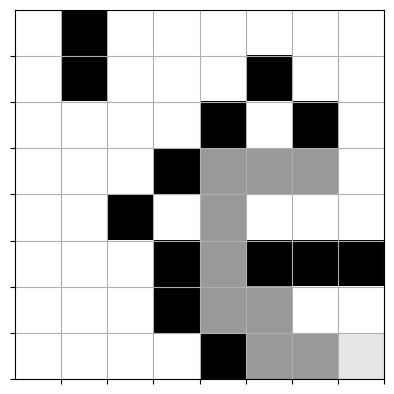

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 625/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 469 | Win rate: 1.000 | time: 31.12 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


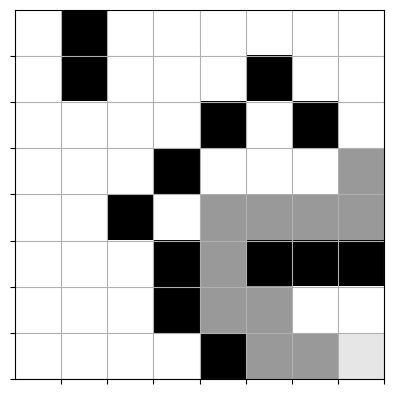

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 626/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 470 | Win rate: 1.000 | time: 31.19 minutes
   win | Epoch Reward: -0.0800000000000003 | DDRUUURUUURRRRRDDDDLLLDDRRRD


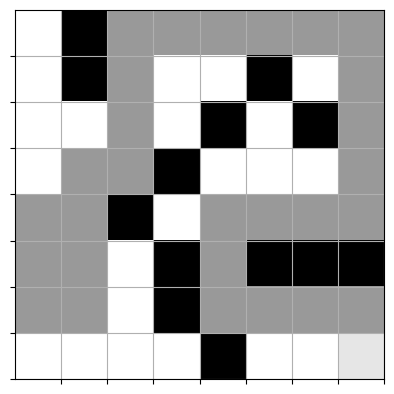

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 627/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 471 | Win rate: 1.000 | time: 31.25 minutes
   win | Epoch Reward: -0.6700000000000006 | UURDUDURURURRRDdDLLDLDDRDRR


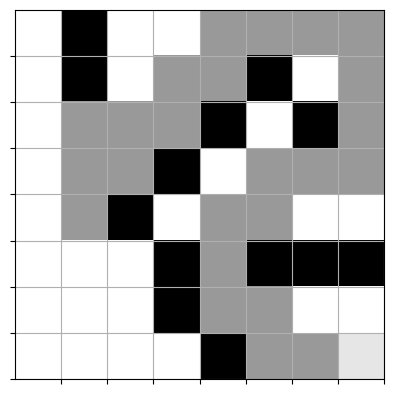

SUCCESSFUL START CELLS: [(0, 4), (0, 0), (0, 3), (0, 2), (0, 5)]
FAILED START CELL:  (0, 6)
Epoch: 628/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 472 | Win rate: 1.000 | time: 31.32 minutes
   win | Epoch Reward: 0.2599999999999998 | DDRDDRRRD


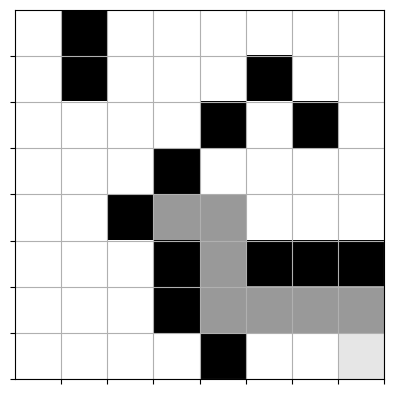

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 629/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 473 | Win rate: 1.000 | time: 31.38 minutes
   win | Epoch Reward: 0.8 | DDRrDR


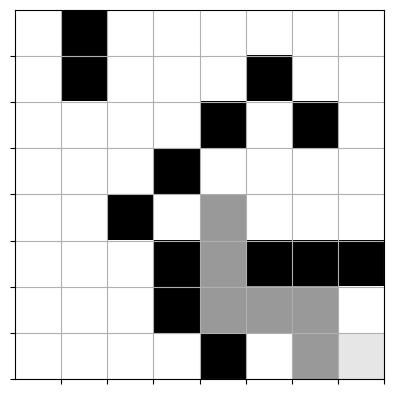

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 630/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 474 | Win rate: 1.000 | time: 31.45 minutes
   win | Epoch Reward: 0.76 | LDDRRRD


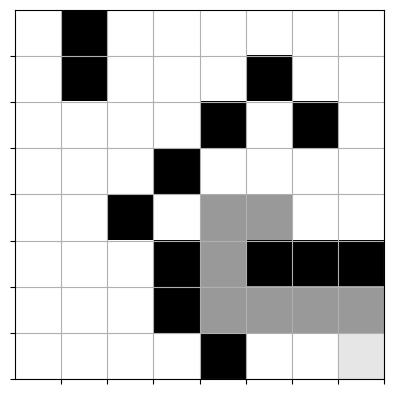

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 631/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 475 | Win rate: 1.000 | time: 31.52 minutes
   win | Epoch Reward: 0.72 | LLDDRDRR


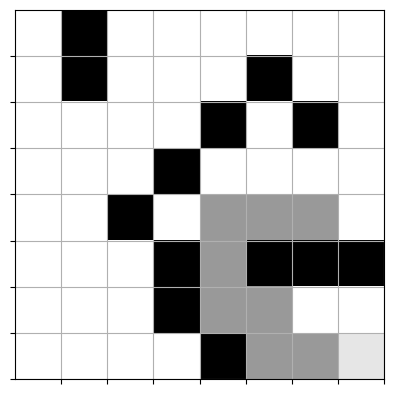

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 632/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 476 | Win rate: 1.000 | time: 31.59 minutes
   win | Epoch Reward: -5.36 | LLLLLLLLLLLLLLLRLRLRLDDDLLLrDDRDRR


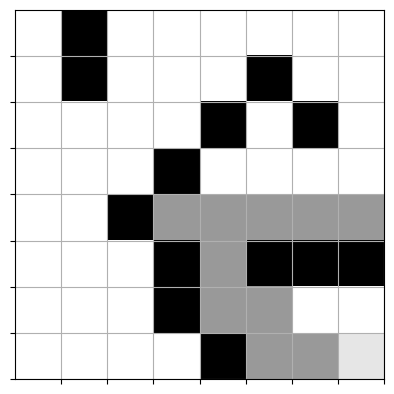

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 633/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 477 | Win rate: 1.000 | time: 31.66 minutes
   win | Epoch Reward: -0.5400000000000005 | DRUUUURUURRRRRDDuDDDLLLDDRRRD


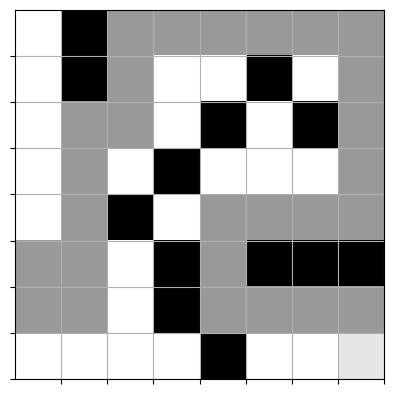

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 634/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 478 | Win rate: 1.000 | time: 31.73 minutes
   win | Epoch Reward: -0.9200000000000008 | UURUDUDURURURRRDDDDLLLDDRDRR


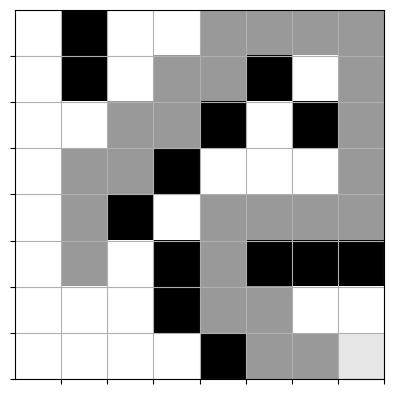

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 635/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 479 | Win rate: 1.000 | time: 31.80 minutes
   win | Epoch Reward: -1.330000000000001 | DLuDUUUURUURRDUDURRRDDDDLLLDDRDRR


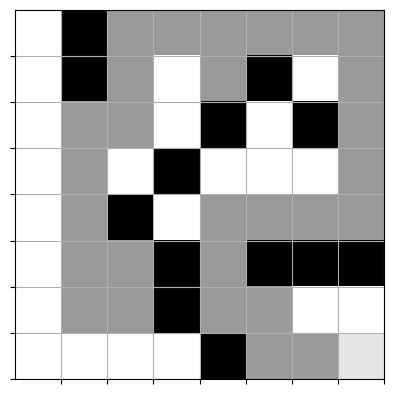

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 636/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 480 | Win rate: 1.000 | time: 31.86 minutes
   win | Epoch Reward: 0.84 | DRDRR


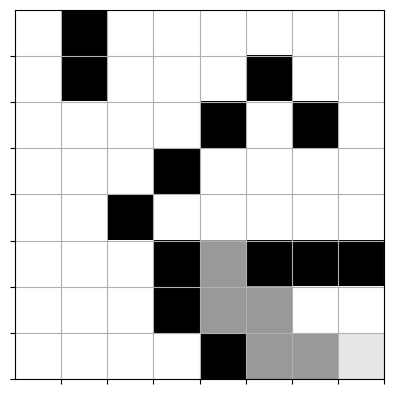

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 637/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 481 | Win rate: 1.000 | time: 31.94 minutes
   win | Epoch Reward: -4.500000000000001 | RUURRRdUURRRRRRRRRRRRRUUURRRRRDDDDLLLDrDRRRD


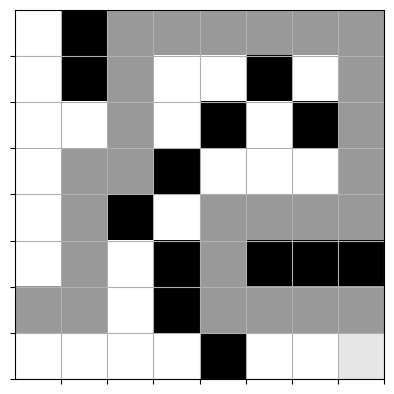

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 638/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 482 | Win rate: 1.000 | time: 32.01 minutes
   win | Epoch Reward: -0.7100000000000006 | UUURdUUURRRrRDDDuDDLLLDDRRRD


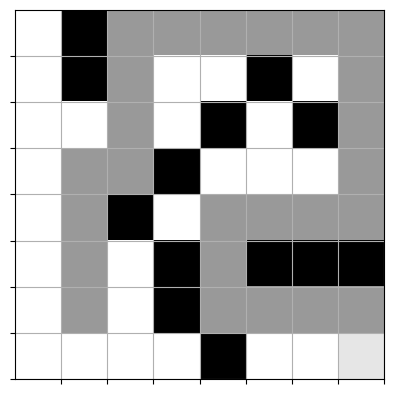

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 639/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 483 | Win rate: 1.000 | time: 32.09 minutes
   win | Epoch Reward: -0.7500000000000009 | LrLUUUURuURRRRRDDDLLDLDDlRRRD


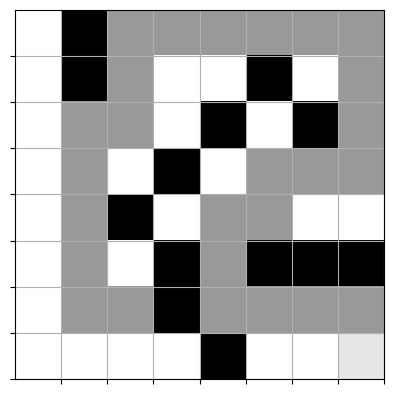

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 640/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 484 | Win rate: 1.000 | time: 32.15 minutes
   win | Epoch Reward: 0.88 | RRRD


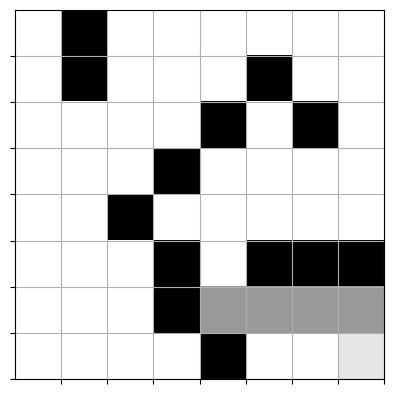

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 641/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 485 | Win rate: 1.000 | time: 32.23 minutes
   win | Epoch Reward: 0.92 | DRR


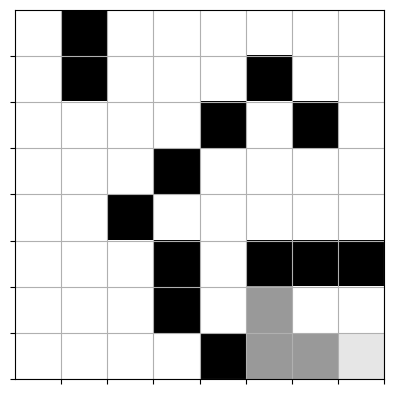

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 642/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 486 | Win rate: 1.000 | time: 32.29 minutes
   win | Epoch Reward: 0.96 | RD


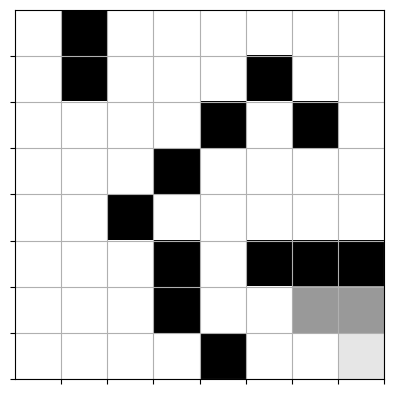

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 643/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 487 | Win rate: 1.000 | time: 32.36 minutes
   win | Epoch Reward: 1.0 | D


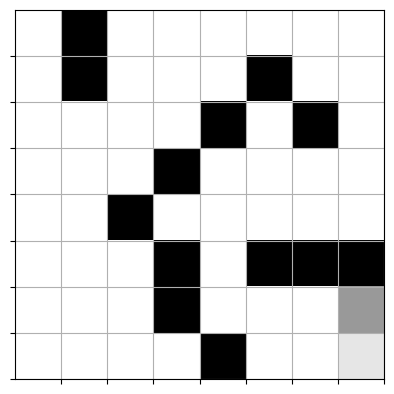

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 644/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 488 | Win rate: 1.000 | time: 32.45 minutes
   win | Epoch Reward: -1.290000000000001 | DDDDURUUUURUURRRRuRDDDDLLLDDRRRD


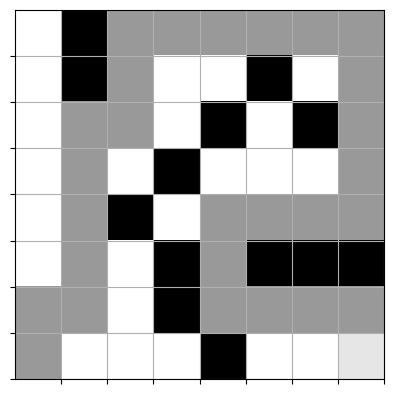

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 645/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 489 | Win rate: 1.000 | time: 32.53 minutes
   win | Epoch Reward: -3.990000000000001 | DDDDDDrULdLUlURUUURUURRRRRDLLLLLURDDDDLLLDDRRRD


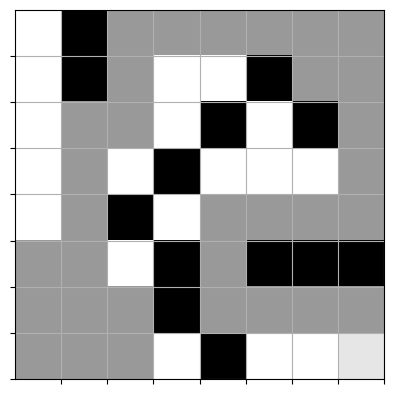

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 646/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 490 | Win rate: 1.000 | time: 32.59 minutes
   win | Epoch Reward: -1.0800000000000005 | ULULLLRUuRURdUURRRRDDDLLDLDDRRRD


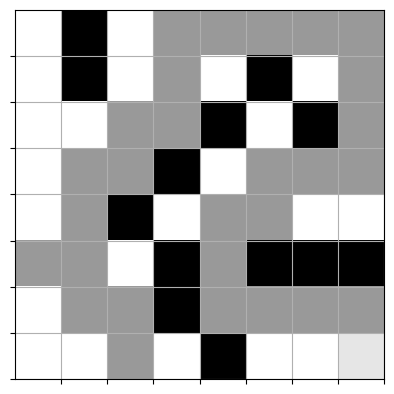

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 647/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 491 | Win rate: 1.000 | time: 32.68 minutes
   win | Epoch Reward: -4.870000000000001 | UUDDDDDUUUUUUuUuUULULUUUrLURUURRRRRDDDLLLDDDRRRD


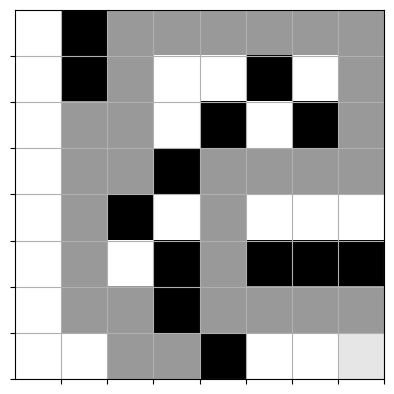

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 648/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 492 | Win rate: 1.000 | time: 32.74 minutes
   win | Epoch Reward: 0.96 | RR


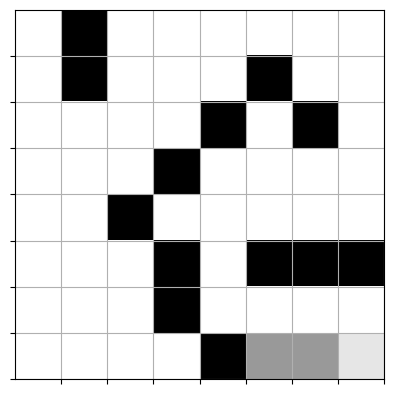

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 649/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 493 | Win rate: 1.000 | time: 32.80 minutes
   win | Epoch Reward: 1.0 | R


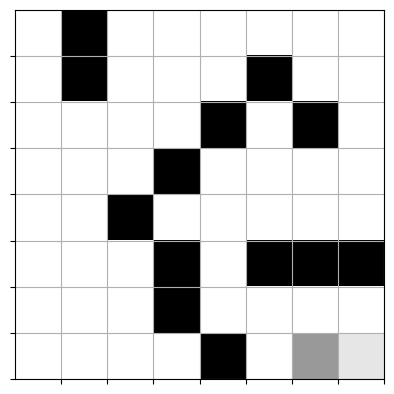

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 650/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 494 | Win rate: 1.000 | time: 32.87 minutes
   win | Epoch Reward: -2.000000000000001 | RRRRRDDDRURUURRRRRDDDLurLLDLDDRRRD


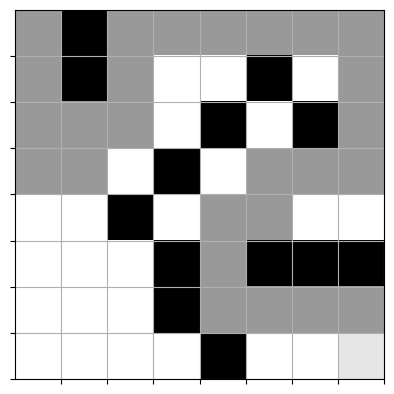

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 651/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 495 | Win rate: 1.000 | time: 32.95 minutes
   win | Epoch Reward: 0.31999999999999995 | RRRRRDDDDLLLdDRRRD


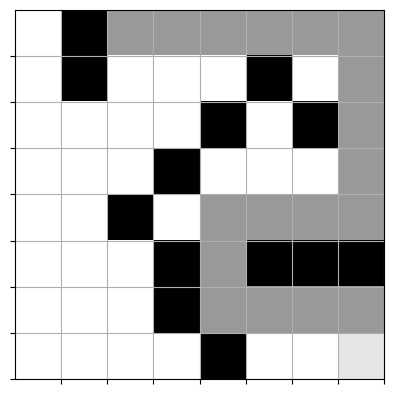

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 652/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 496 | Win rate: 1.000 | time: 33.03 minutes
   win | Epoch Reward: 0.36 | RRRRDDDdLLLDDRDRR


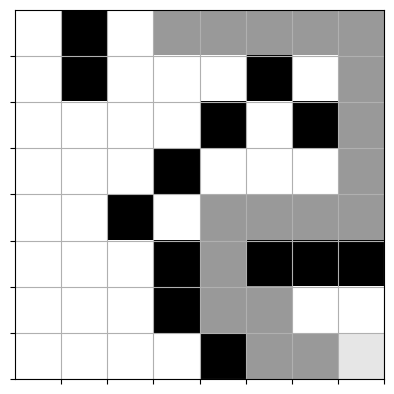

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 653/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 497 | Win rate: 1.000 | time: 33.10 minutes
   win | Epoch Reward: 0.4 | RRRDDDLLDLDDRRRD


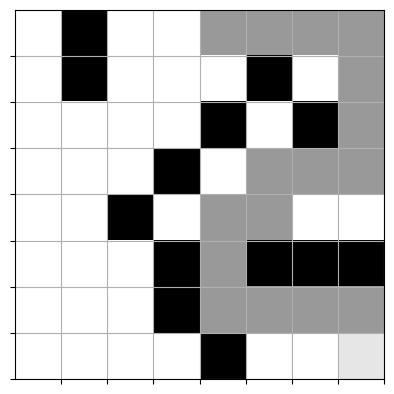

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 654/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 498 | Win rate: 1.000 | time: 33.17 minutes
   win | Epoch Reward: 0.06999999999999962 | RRDlRDDDLULDLDDRRRD


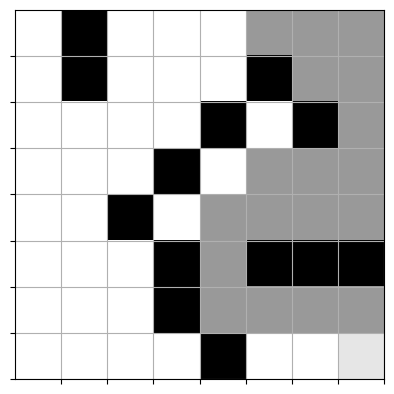

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 655/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 499 | Win rate: 1.000 | time: 33.26 minutes
   win | Epoch Reward: 0.18999999999999984 | RDDDDLLluDDDRRRD


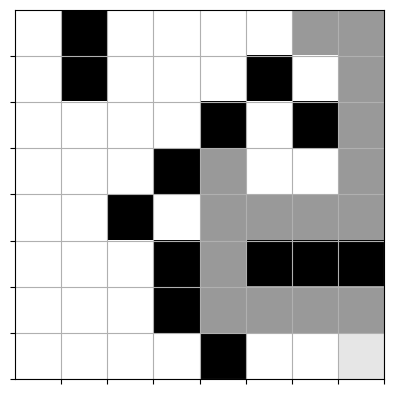

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 656/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 500 | Win rate: 1.000 | time: 33.34 minutes
   win | Epoch Reward: 0.2699999999999999 | DrDDDLLLDDRDRR


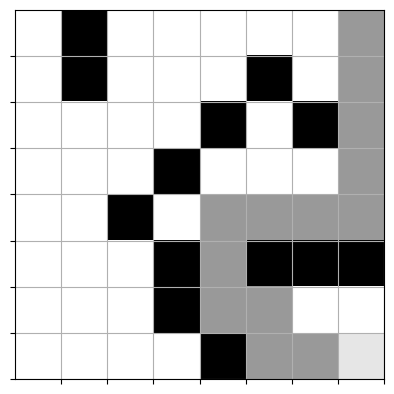

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 657/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 501 | Win rate: 1.000 | time: 33.42 minutes
   win | Epoch Reward: -0.12000000000000033 | DDDDRUURUrURURRRDDDDLLLDDRDRR


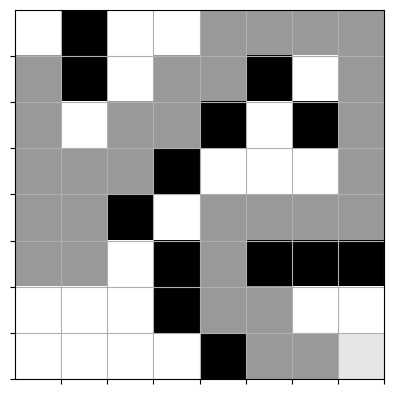

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 658/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 502 | Win rate: 1.000 | time: 33.50 minutes
   win | Epoch Reward: -0.5500000000000003 | UuRRRRRDDuDDDLULDLDDRDRR


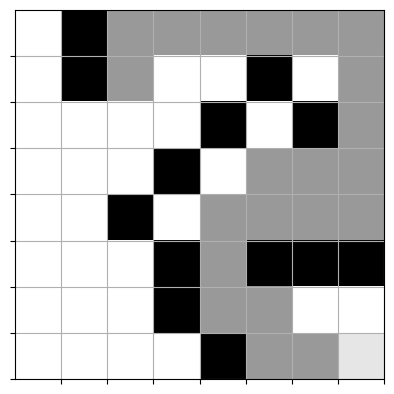

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 659/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 503 | Win rate: 1.000 | time: 33.57 minutes
   win | Epoch Reward: 0.31999999999999995 | RURRRDDDDLLLDDRRRD


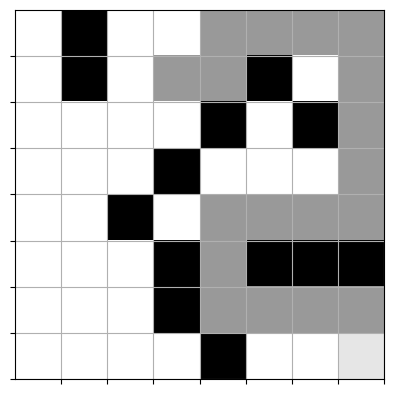

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 660/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 504 | Win rate: 1.000 | time: 33.65 minutes
   win | Epoch Reward: 0.36 | URRRDDDDLLLDDRRRD


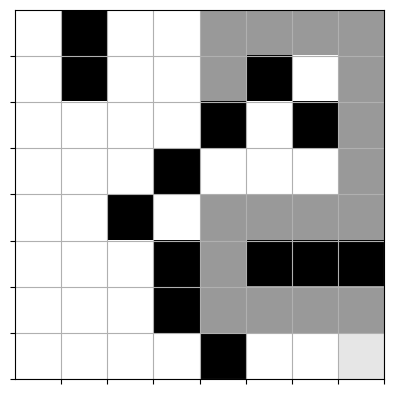

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 661/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 505 | Win rate: 1.000 | time: 33.72 minutes
   win | Epoch Reward: 0.18999999999999984 | DuRDDDDLLLDDRRRD


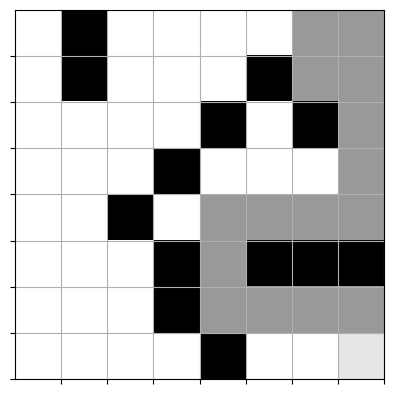

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 662/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 506 | Win rate: 1.000 | time: 33.79 minutes
   win | Epoch Reward: 0.56 | DDDLLLDDRDRR


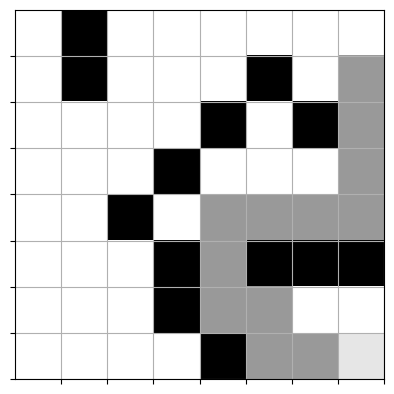

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 663/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 507 | Win rate: 1.000 | time: 33.86 minutes
   win | Epoch Reward: -1.0000000000000009 | LLDRURlRUURRRRRDDDDLULDLDDRDRR


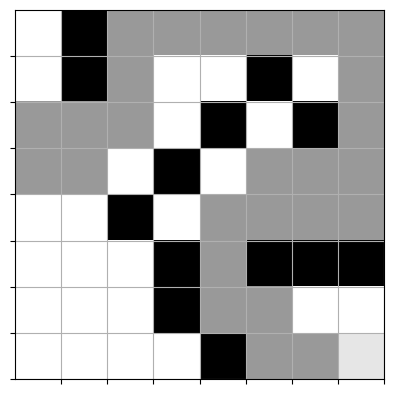

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 664/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 508 | Win rate: 1.000 | time: 33.93 minutes
   win | Epoch Reward: -0.05000000000000049 | RRURURuRRDDDDLLLDDRRRD


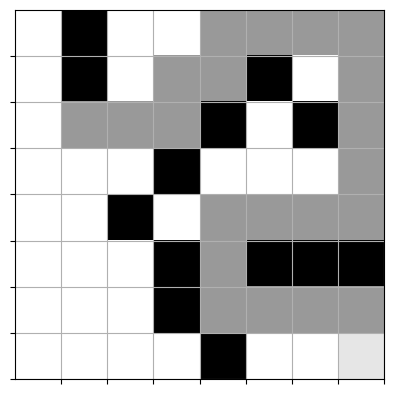

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 665/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 509 | Win rate: 1.000 | time: 34.00 minutes
   win | Epoch Reward: 0.23999999999999988 | RURURRRDDDDLLLDDRRRD


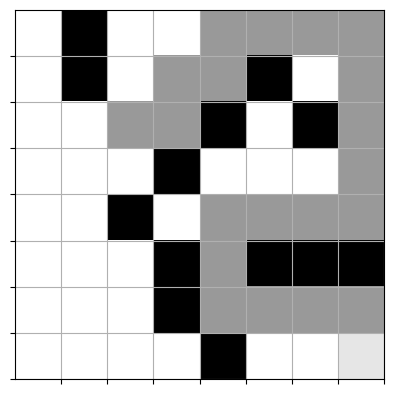

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 666/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 510 | Win rate: 1.000 | time: 34.08 minutes
   win | Epoch Reward: -0.3000000000000005 | URURRRlRDDDDLULDLDDRDRR


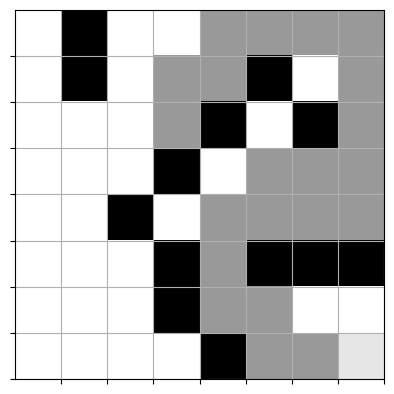

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 667/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 511 | Win rate: 1.000 | time: 34.16 minutes
   win | Epoch Reward: 0.6799999999999999 | DDLDDRRRD


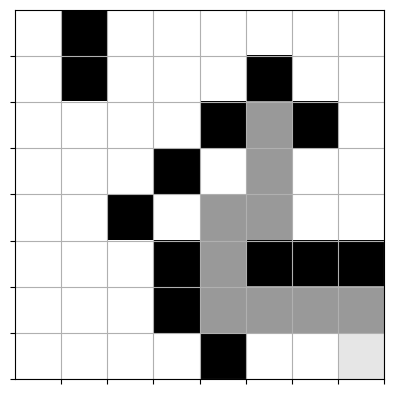

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 668/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 512 | Win rate: 1.000 | time: 34.24 minutes
   win | Epoch Reward: 0.35 | rDDLLLDDRDRR


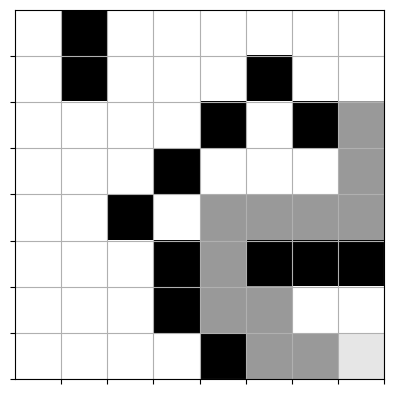

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 669/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 513 | Win rate: 1.000 | time: 34.33 minutes
   win | Epoch Reward: -2.410000000000001 | DDRRURDLURDLUUURURURURRRDDDdLLrLLDDRRRD


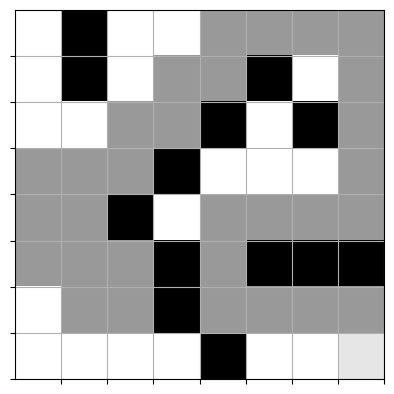

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (0, 5), (1, 0), (1, 3)]
FAILED START CELL:  (1, 6)
Epoch: 670/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 514 | Win rate: 1.000 | time: 34.44 minutes
   win | Epoch Reward: -0.9200000000000004 | URRURURRRDDDDLULRLRLDLDDRRdR


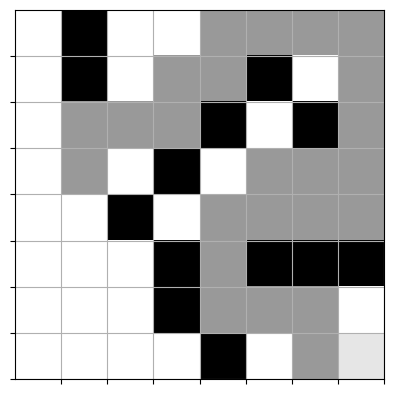

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 671/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 515 | Win rate: 1.000 | time: 34.51 minutes
   win | Epoch Reward: 0.11999999999999977 | UUUrRRRRDDDDLULDLDDRRRD


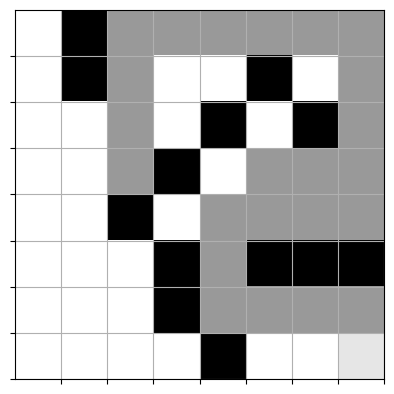

SUCCESSFUL START CELLS: [(0, 7), (1, 2), (0, 4), (0, 0), (0, 3), (1, 4), (0, 6), (0, 2), (1, 7), (0, 5), (1, 0), (1, 6), (1, 3)]
FAILED START CELL:  (2, 0)
Epoch: 672/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 516 | Win rate: 1.000 | time: 34.60 minutes
   win | Epoch Reward: 0.76 | DDDRRRD


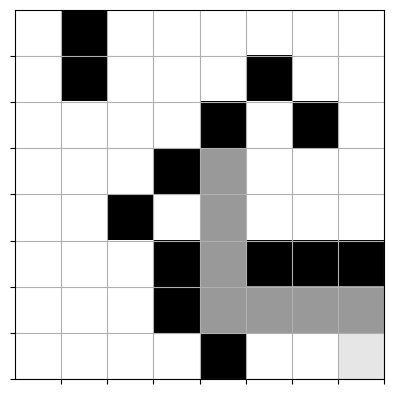

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 673/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 517 | Win rate: 1.000 | time: 34.68 minutes
   win | Epoch Reward: 0.21999999999999986 | DLDDuDRDRR


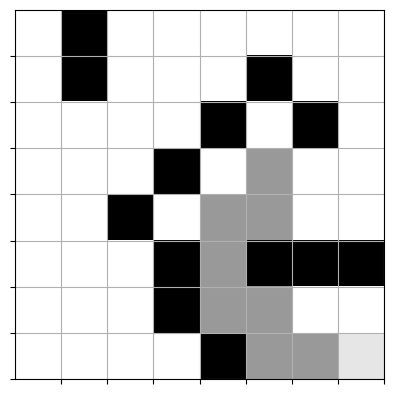

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 674/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 518 | Win rate: 1.000 | time: 34.75 minutes
   win | Epoch Reward: 0.6799999999999999 | DLLDDRDRR


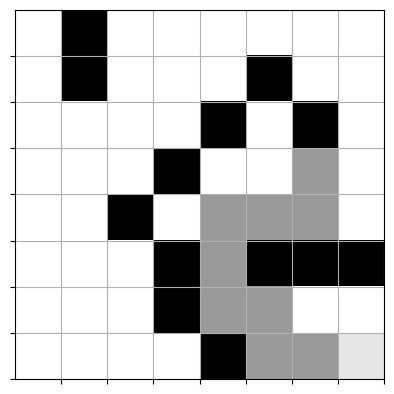

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 675/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 519 | Win rate: 1.000 | time: 34.82 minutes
   win | Epoch Reward: 0.14 | DrLLLDDRDdRR


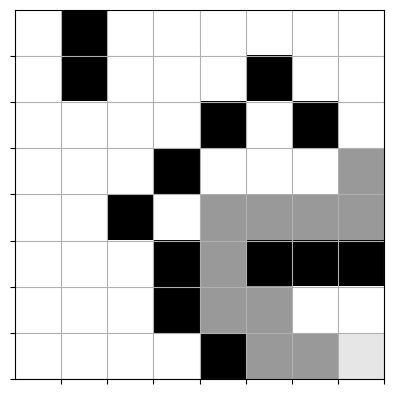

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 676/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 520 | Win rate: 1.000 | time: 34.90 minutes
   win | Epoch Reward: -1.6600000000000006 | DDDURUUURURURURRRDDuDDDLUDUDLLDDRRRD


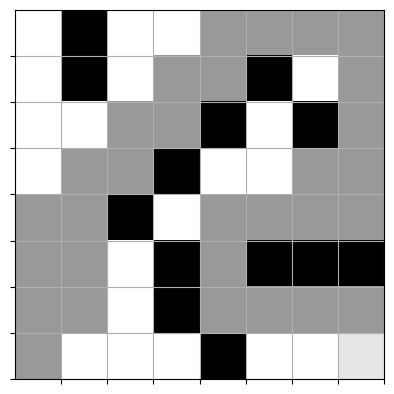

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 677/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 521 | Win rate: 1.000 | time: 34.97 minutes
   win | Epoch Reward: -0.21000000000000063 | UURRURUuRRRDDDDLULDLDDRRRD


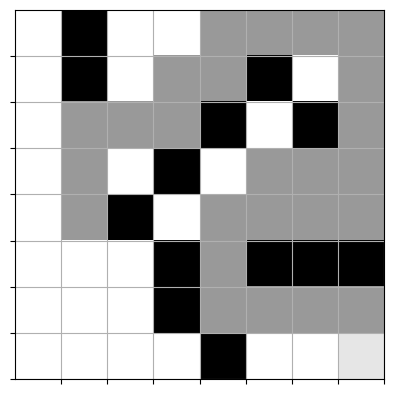

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 678/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 522 | Win rate: 1.000 | time: 35.03 minutes
   win | Epoch Reward: 0.76 | RDDRRRD


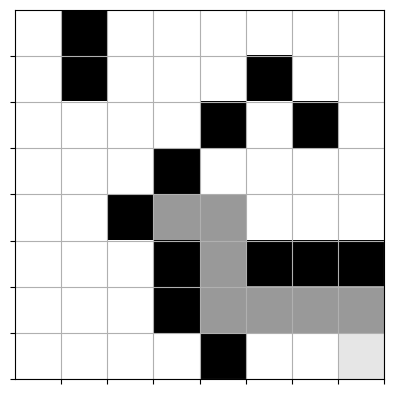

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 679/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 523 | Win rate: 1.000 | time: 35.11 minutes
   win | Epoch Reward: -1.0300000000000002 | rDDDDDuDLDDRDRr


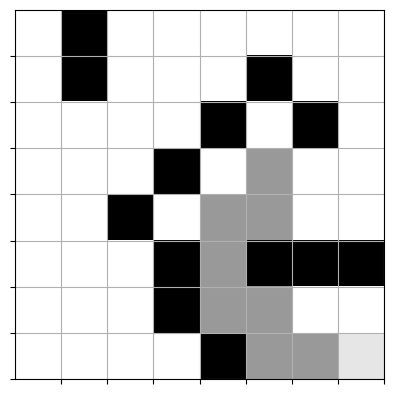

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 680/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 524 | Win rate: 1.000 | time: 35.19 minutes
   win | Epoch Reward: 0.76 | LDDRRRD


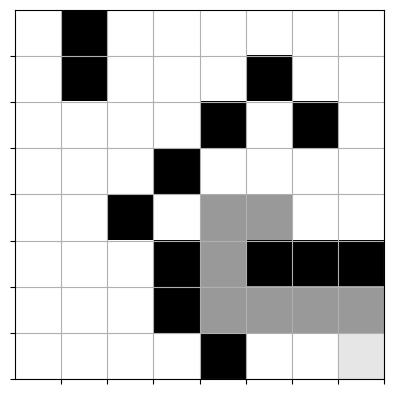

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 681/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 525 | Win rate: 1.000 | time: 35.26 minutes
   win | Epoch Reward: 0.13999999999999968 | DDULDLDDRRRD


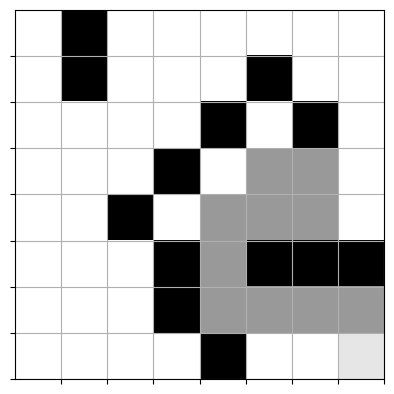

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 682/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 526 | Win rate: 1.000 | time: 35.32 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDDRRRD


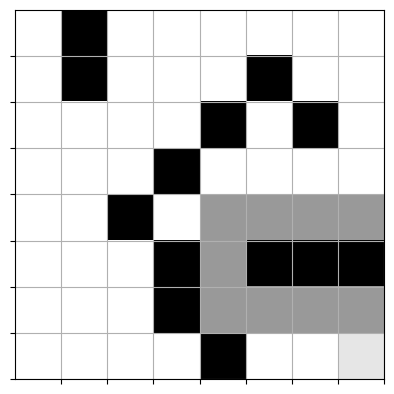

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 683/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 527 | Win rate: 1.000 | time: 35.41 minutes
   win | Epoch Reward: -3.080000000000001 | RRDUUUUUUUUDUDLUuURURURURRRDDDDLLLDDRdRR


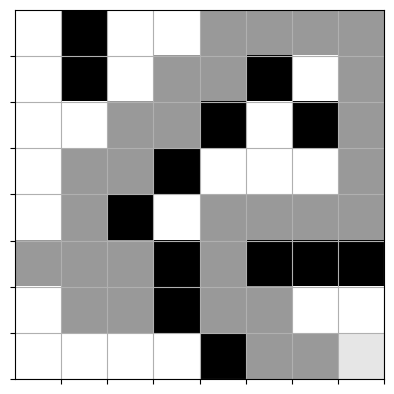

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 0)]
FAILED START CELL:  (0, 4)
Epoch: 684/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 528 | Win rate: 1.000 | time: 35.49 minutes
   win | Epoch Reward: -0.5000000000000009 | UdUURURURURRRDDDdLULDLDDRRRD


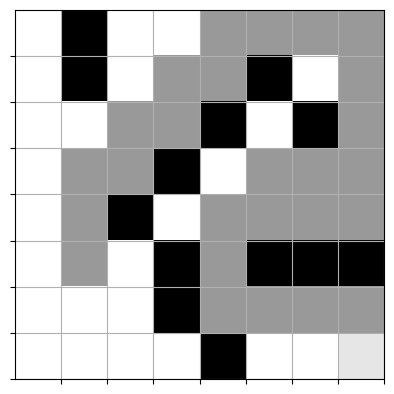

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 685/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 529 | Win rate: 1.000 | time: 35.58 minutes
   win | Epoch Reward: -7.909999999999984 | DLLDDDDDDlUDUDDUDUDDDDDDLLURlRLRUUUURDUDUUURRRRRDDDDLLLDDRRRD


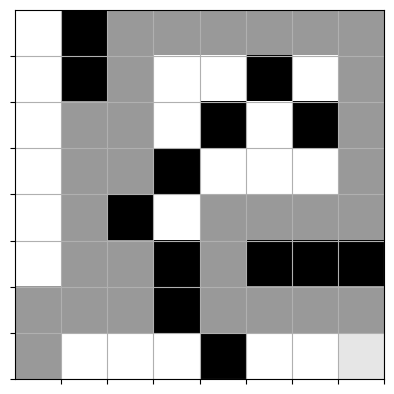

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 686/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 530 | Win rate: 1.000 | time: 35.65 minutes
   win | Epoch Reward: 0.08999999999999986 | DuDlRDRR


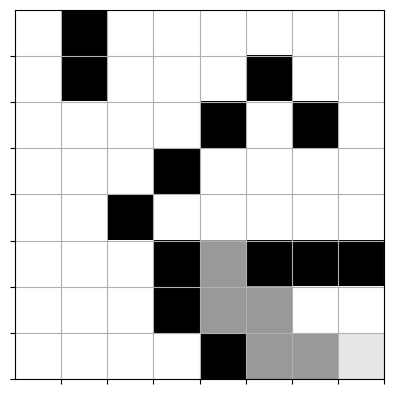

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 687/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 531 | Win rate: 1.000 | time: 35.73 minutes
   win | Epoch Reward: -0.7500000000000004 | RUUrURURURURRRDDDLLrLDLDDRDRR


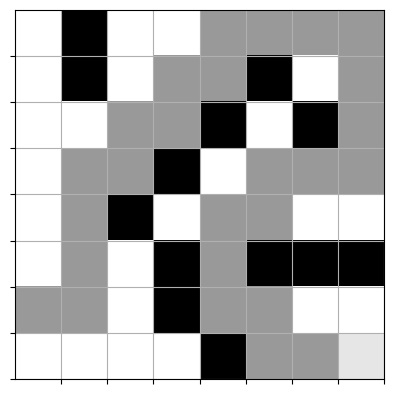

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 688/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 532 | Win rate: 1.000 | time: 35.80 minutes
   win | Epoch Reward: -0.04000000000000026 | UUUURRURURRRDDDDLULDLDDRdRR


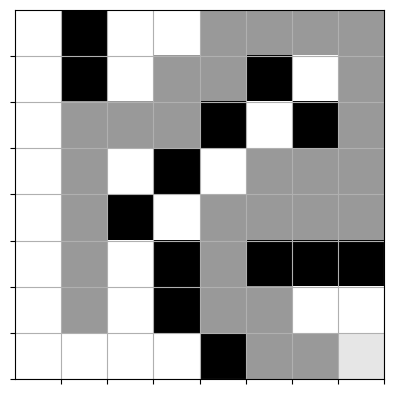

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 689/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 533 | Win rate: 1.000 | time: 35.87 minutes
   win | Epoch Reward: -2.220446049250313e-16 | LUUUURUURRRRRDDDLLDLDDRDRR


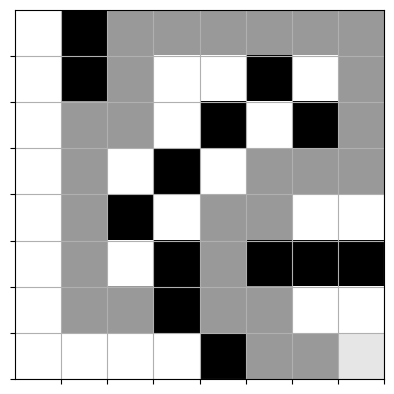

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 690/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 534 | Win rate: 1.000 | time: 35.94 minutes
   win | Epoch Reward: 0.88 | RRRD


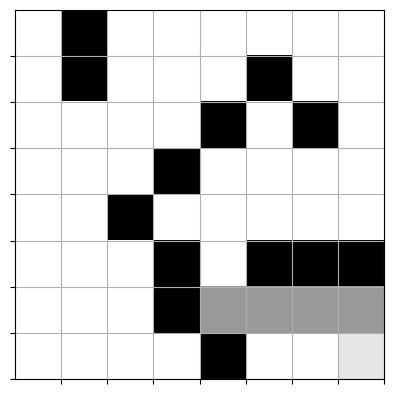

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 691/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 535 | Win rate: 1.000 | time: 36.00 minutes
   win | Epoch Reward: 0.92 | RRD


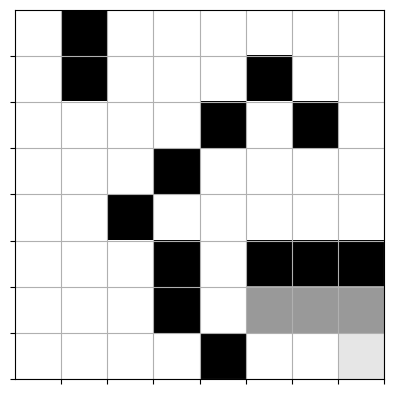

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 692/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 536 | Win rate: 1.000 | time: 36.08 minutes
   win | Epoch Reward: 0.96 | RD


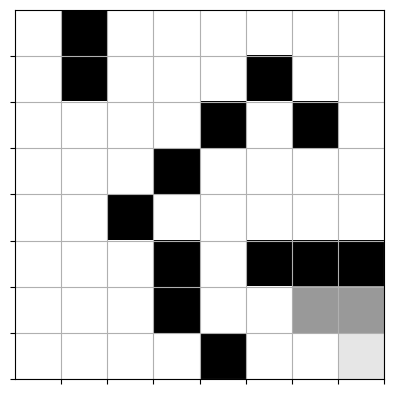

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 693/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 537 | Win rate: 1.000 | time: 36.14 minutes
   win | Epoch Reward: 1.0 | D


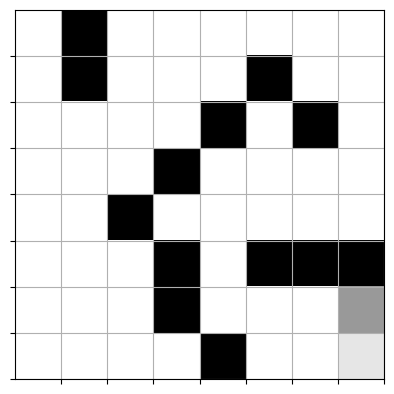

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 694/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 538 | Win rate: 1.000 | time: 36.22 minutes
   win | Epoch Reward: -0.6200000000000008 | lURUUrURURURURRRDDDDLULDlDDRRRD


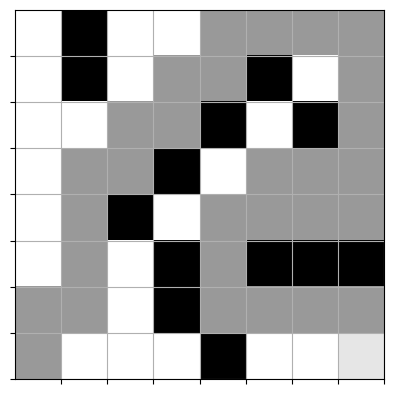

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 695/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 539 | Win rate: 1.000 | time: 36.29 minutes
   win | Epoch Reward: -1.830000000000001 | uRUUUUULUUdURURURURRRDDDDLdLLDDRRRD


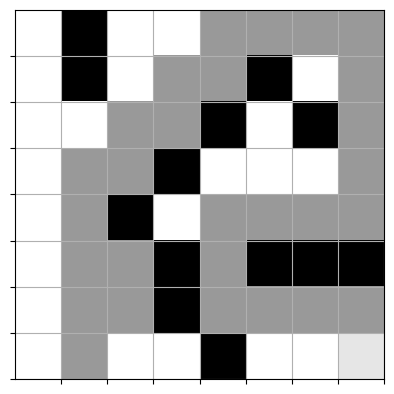

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 696/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 540 | Win rate: 1.000 | time: 36.37 minutes
   win | Epoch Reward: -0.12000000000000033 | LLUURUUURuURRRRRDDDLLDLDDRRRD


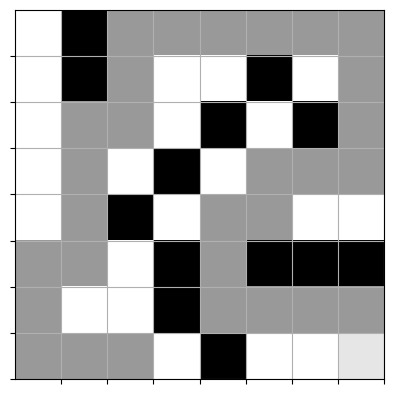

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 697/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 541 | Win rate: 1.000 | time: 36.45 minutes
   win | Epoch Reward: -2.160000000000001 | RRRLLLLLLURUUURrUUURRRRRDDDLLDLDDdRRRD


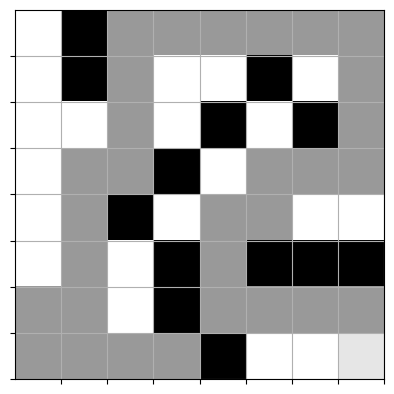

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 698/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 542 | Win rate: 1.000 | time: 36.51 minutes
   win | Epoch Reward: 0.96 | RR


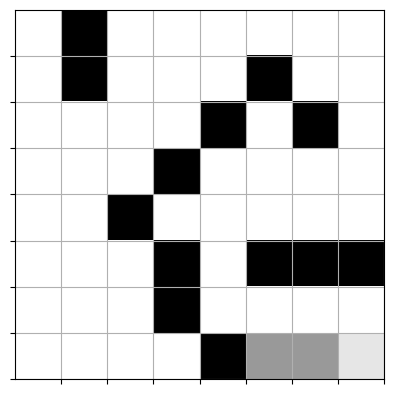

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 699/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 543 | Win rate: 1.000 | time: 36.58 minutes
   win | Epoch Reward: 1.0 | R


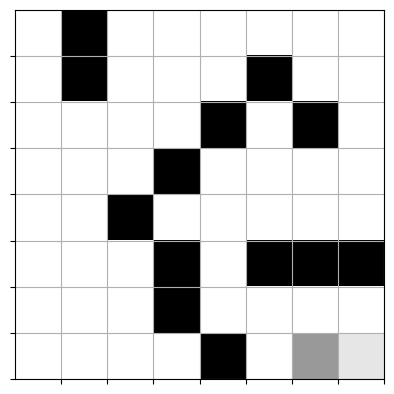

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 700/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 544 | Win rate: 1.000 | time: 36.66 minutes
   win | Epoch Reward: -2.220446049250313e-16 | DDDRURUURRRRRDDDDLLLDDRRRD


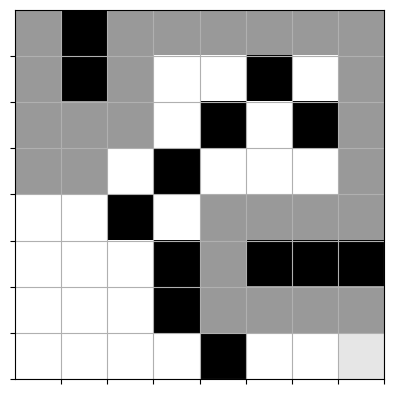

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 701/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 545 | Win rate: 1.000 | time: 36.74 minutes
   win | Epoch Reward: -0.4300000000000004 | RRRRrrrDDDDLdLLDDRDRR


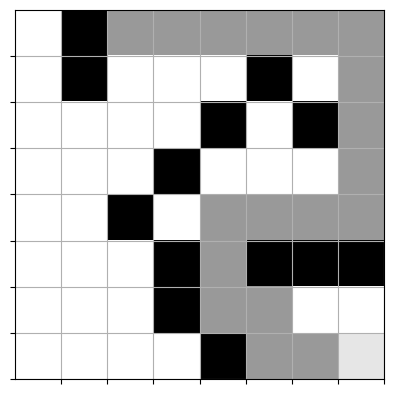

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 702/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 546 | Win rate: 1.000 | time: 36.81 minutes
   win | Epoch Reward: -1.7200000000000006 | RRRRDLRDDdLLLUDUDUDUDDDRRRD


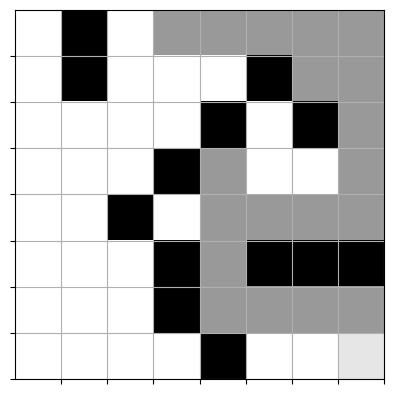

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 703/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 547 | Win rate: 1.000 | time: 36.89 minutes
   win | Epoch Reward: -0.6000000000000005 | RRRRRlRdDDLLDLDDRRRD


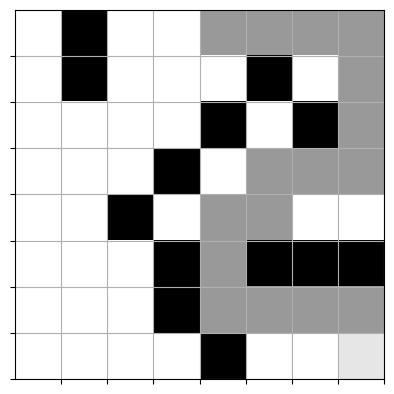

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 704/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 548 | Win rate: 1.000 | time: 36.97 minutes
   win | Epoch Reward: 0.44000000000000006 | RRDDDLLDLDDRRRD


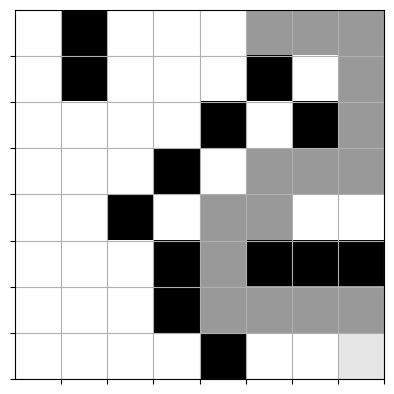

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 705/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 549 | Win rate: 1.000 | time: 37.05 minutes
   win | Epoch Reward: -0.10000000000000031 | RDDDDLRLULDLDDRRRD


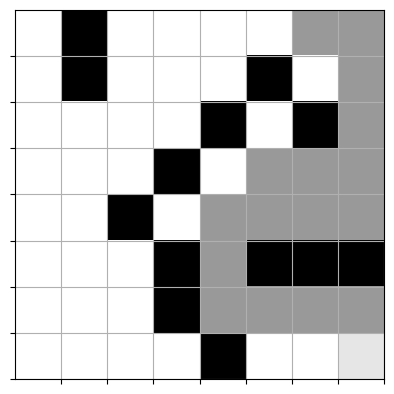

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 706/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 550 | Win rate: 1.000 | time: 37.11 minutes
   win | Epoch Reward: 0.019999999999999574 | DuDDDDLlLDDRDRR


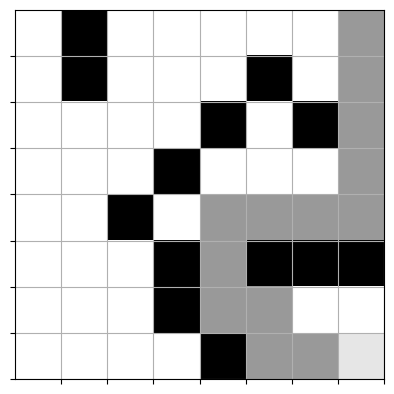

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 707/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 551 | Win rate: 1.000 | time: 37.19 minutes
   win | Epoch Reward: -1.1200000000000006 | DDDDRUURUUURlRRRRRDDDLLDLDDRDuDRR


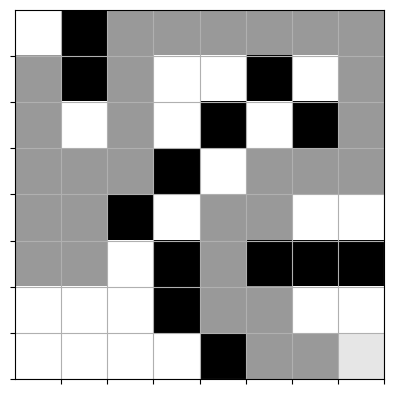

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 708/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 552 | Win rate: 1.000 | time: 37.27 minutes
   win | Epoch Reward: -0.30000000000000027 | dRUuRRRRDDDlLrLDLDDRDRR


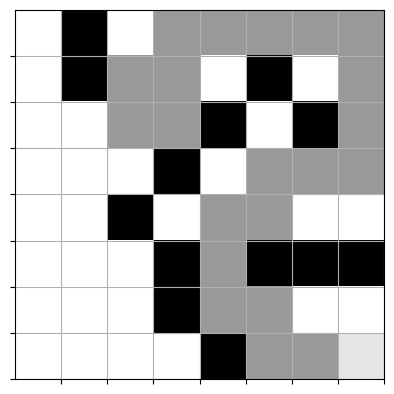

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 709/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 553 | Win rate: 1.000 | time: 37.34 minutes
   win | Epoch Reward: -2.4300000000000006 | URRRDDDlDrDRdDRRRRLRLLLDDRDRR


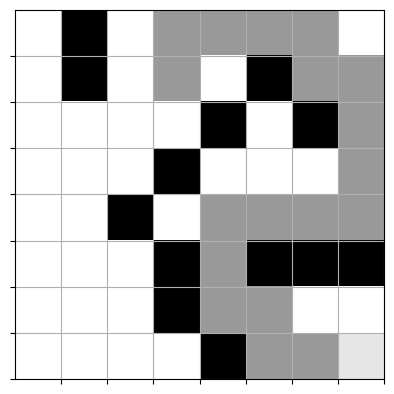

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 710/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 554 | Win rate: 1.000 | time: 37.42 minutes
   win | Epoch Reward: -3.9700000000000006 | DDURURRDLlLLLLLURDDDDUDUDLLUDLDDRRRD


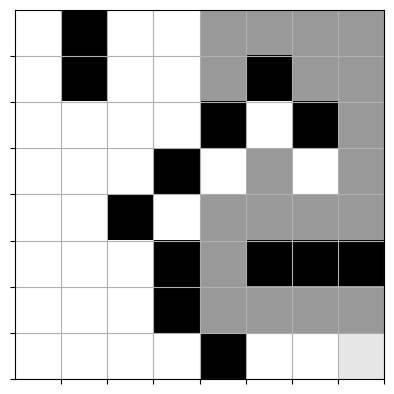

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 711/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 555 | Win rate: 1.000 | time: 37.49 minutes
   win | Epoch Reward: -1.4800000000000004 | DDDDdDrDDDLLlDrlDRDRR


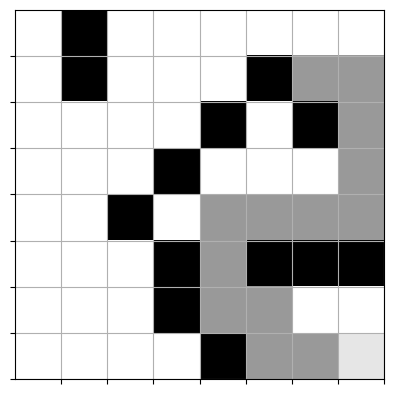

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 712/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 556 | Win rate: 1.000 | time: 37.55 minutes
   win | Epoch Reward: 0.56 | DDDLLLDDRDRR


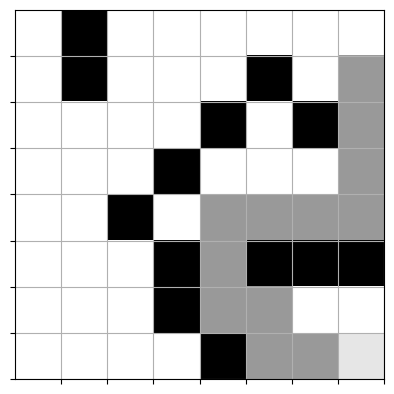

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 713/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 557 | Win rate: 1.000 | time: 37.63 minutes
   win | Epoch Reward: -3.41 | DDDRUURURUDDDDDDURURRRDDDDLULdUDUDUDLDDRRRD


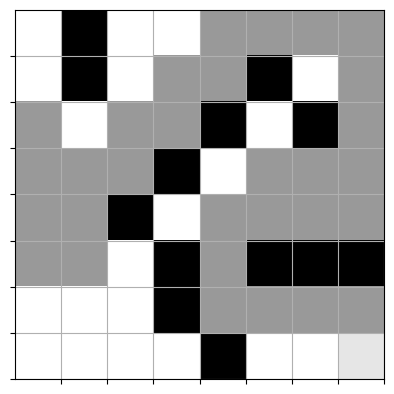

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 714/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 558 | Win rate: 1.000 | time: 37.71 minutes
   win | Epoch Reward: -3.670000000000001 | lRRRRULLLLRRRRRRURRRDDDLLLLLLLRDLDDRRRD


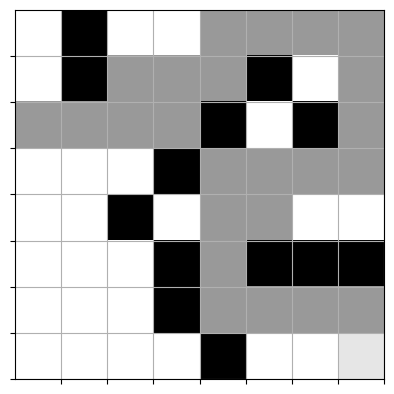

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 715/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 559 | Win rate: 1.000 | time: 37.78 minutes
   win | Epoch Reward: -1.5900000000000003 | UURRRRRDDDDLLUDUuRRRDDLDDRRRD


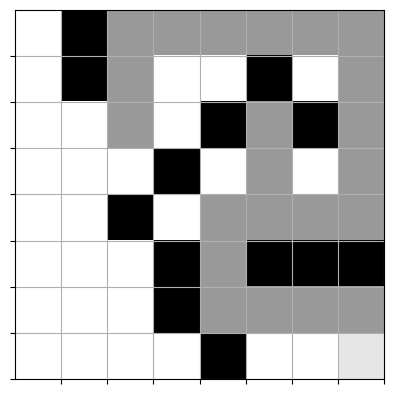

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 716/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 560 | Win rate: 1.000 | time: 37.85 minutes
   win | Epoch Reward: -4.130000000000001 | URURRRDLLLLURDLUdURDDDDLULUUUUUDDLDDRRRD


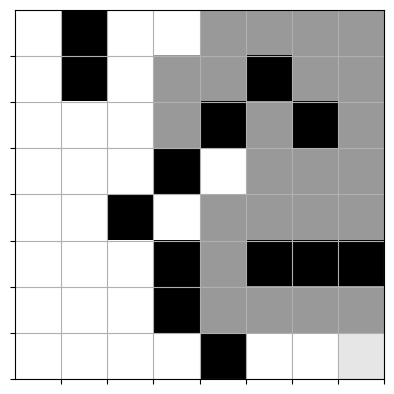

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 717/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 561 | Win rate: 1.000 | time: 37.94 minutes
   win | Epoch Reward: -1.8200000000000003 | RRRRRRLLLLDDLDDRRRD


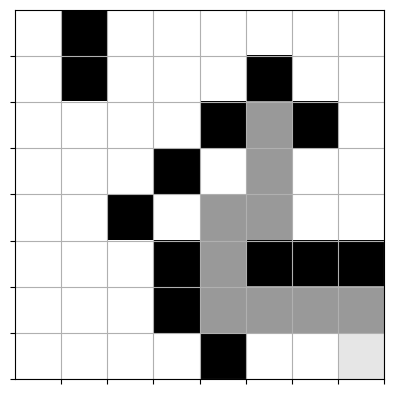

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 718/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 562 | Win rate: 1.000 | time: 38.00 minutes
   win | Epoch Reward: -0.40000000000000036 | LLLLDDLLLDDRDrR


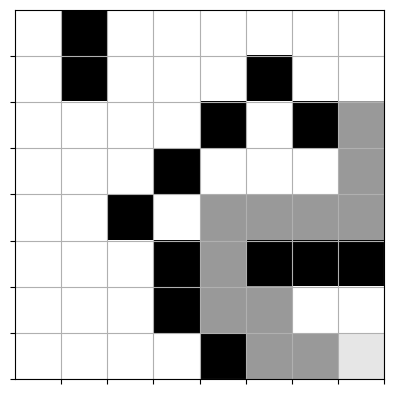

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (4, 5), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (3, 5), (4, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (4, 6)
Epoch: 719/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 563 | Win rate: 1.000 | time: 38.12 minutes
   win | Epoch Reward: -1.8800000000000008 | RRlRURURURlDUDURRRDDDDLLLDDRDRR


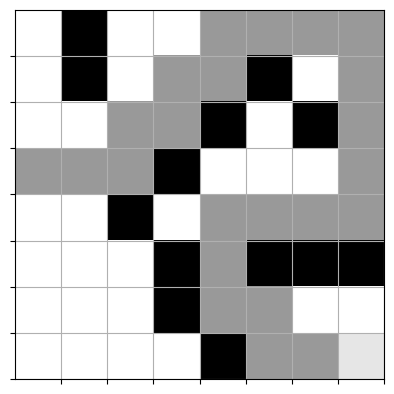

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 720/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 564 | Win rate: 1.000 | time: 38.20 minutes
   win | Epoch Reward: -0.09000000000000052 | URRURUuRRRDDDDLLLDDRRRD


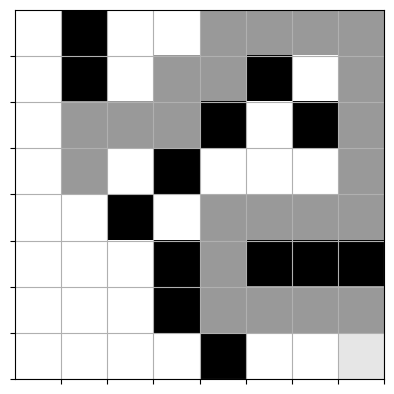

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 721/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 565 | Win rate: 1.000 | time: 38.28 minutes
   win | Epoch Reward: -0.8000000000000003 | UUUrRRRRDDuDDLLrLDLDDRRRD


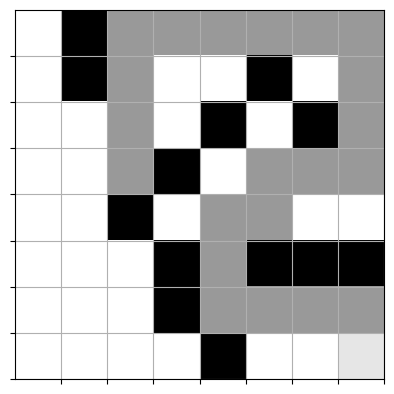

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 722/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 566 | Win rate: 1.000 | time: 38.34 minutes
   win | Epoch Reward: 0.009999999999999787 | LLLDDDRRRD


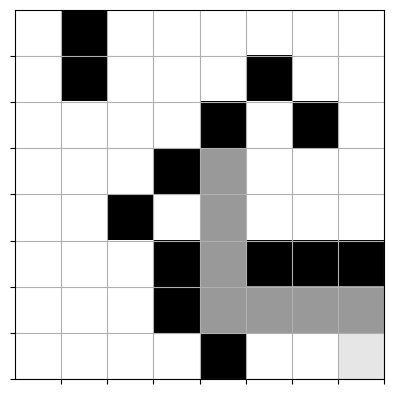

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 723/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 567 | Win rate: 1.000 | time: 38.41 minutes
   win | Epoch Reward: 0.43000000000000005 | UDDLDDRRRD


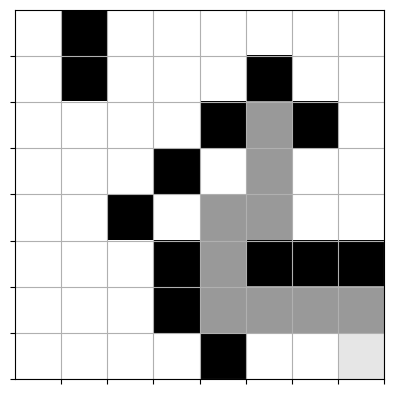

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 724/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 568 | Win rate: 1.000 | time: 38.48 minutes
   win | Epoch Reward: 0.6799999999999999 | LLDDDRRRD


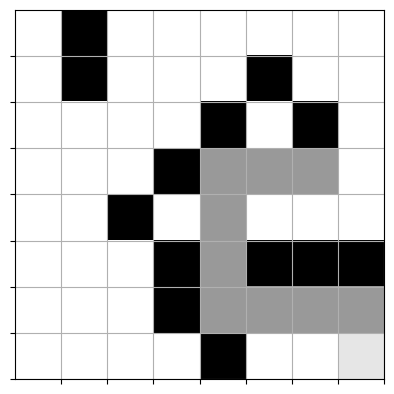

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 725/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 569 | Win rate: 1.000 | time: 38.54 minutes
   win | Epoch Reward: 0.64 | DLLLDDRDRR


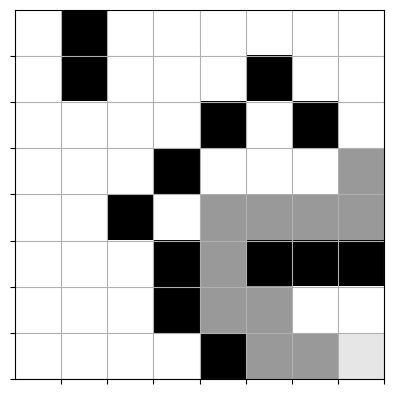

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 726/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 570 | Win rate: 1.000 | time: 38.62 minutes
   win | Epoch Reward: -0.8700000000000006 | DDdURUUUURlRUURRRRRDDDDLLLDDRRRD


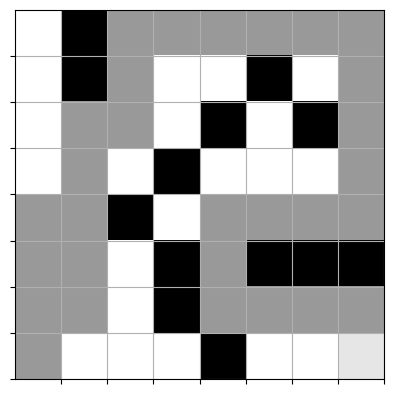

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 727/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 571 | Win rate: 1.000 | time: 38.69 minutes
   win | Epoch Reward: -0.8800000000000003 | URUUURRRRRDDDUDUDDLLLDDRRRD


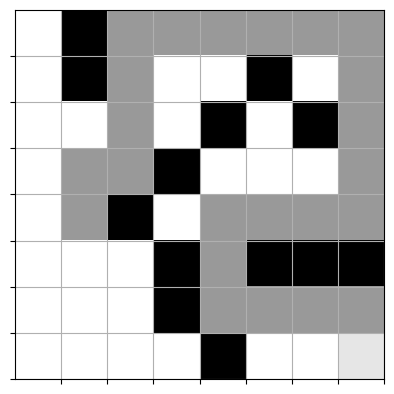

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 728/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 572 | Win rate: 1.000 | time: 38.75 minutes
   win | Epoch Reward: 0.76 | RDDRRdR


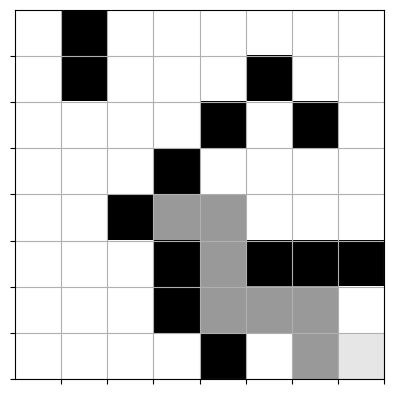

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 729/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 573 | Win rate: 1.000 | time: 38.81 minutes
   win | Epoch Reward: -0.20000000000000018 | DDDDDDRDRR


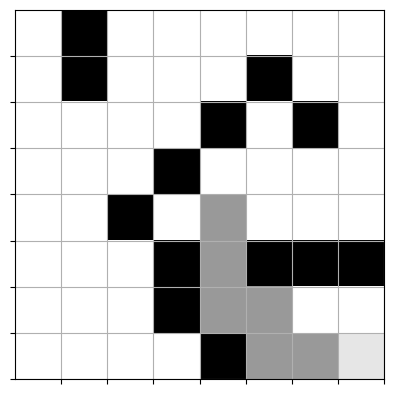

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 730/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 574 | Win rate: 1.000 | time: 38.88 minutes
   win | Epoch Reward: -2.0700000000000003 | LURLRLLuLLLLLDDDRRRD


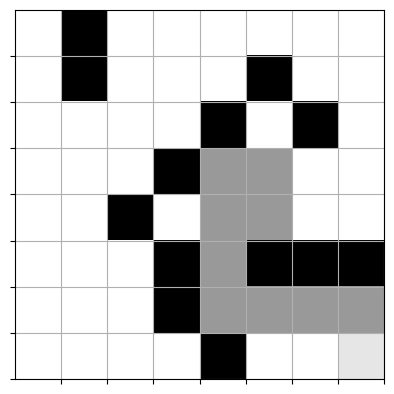

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 731/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 575 | Win rate: 1.000 | time: 38.97 minutes
   win | Epoch Reward: -11.149999999999995 | LLUdUlLLLLLLLLLLLLLLLLLLLLDUDURUUULLLLLLLLLLLLLDDLDDuDRRRD


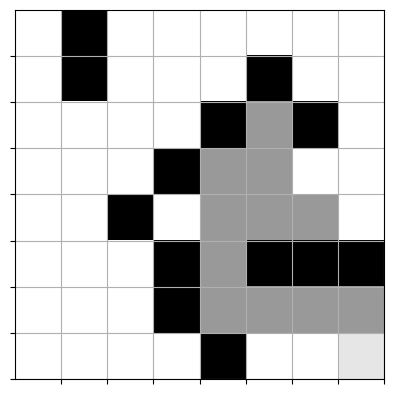

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 732/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 576 | Win rate: 1.000 | time: 39.04 minutes
   win | Epoch Reward: 0.6799999999999999 | LLLDDRRdR


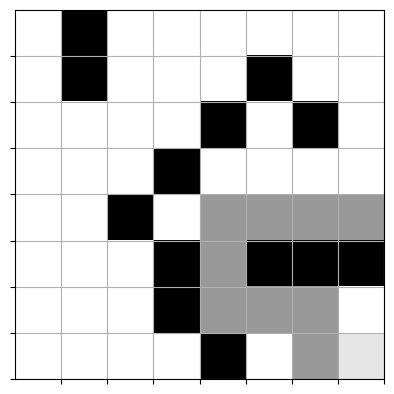

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 733/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 577 | Win rate: 1.000 | time: 39.11 minutes
   win | Epoch Reward: -0.7100000000000004 | RUuRURURURRRrDDDDLLLdDRRRlRD


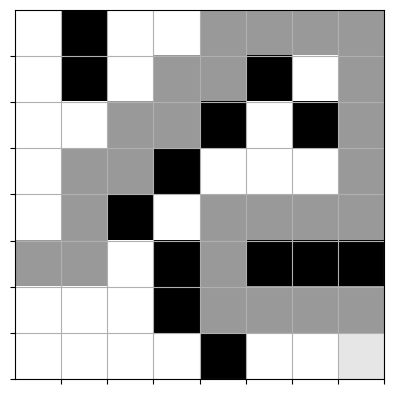

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 734/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 578 | Win rate: 1.000 | time: 39.19 minutes
   win | Epoch Reward: -0.6700000000000006 | UUUdURUUlRRRRRDDDDLLLDDRRRD


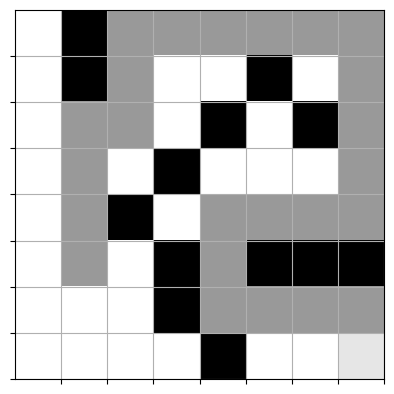

SUCCESSFUL START CELLS: [(0, 2), (0, 3), (0, 4), (0, 0)]
FAILED START CELL:  (0, 5)
Epoch: 735/999 | Loss: 0.0014 | Episodes: 1000 | Win count: 579 | Win rate: 1.000 | time: 39.29 minutes
   win | Epoch Reward: -12.359999999999982 | DURRRRRRDLUULDDRUUUUlDDDDDDdDDDLLrLUdURUUUULDDDDRRLRlRrLUUURUUURRRRRDDuDDDLLLDDRRRD


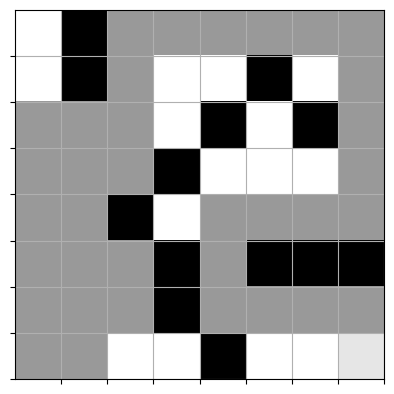

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 736/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 580 | Win rate: 1.000 | time: 39.36 minutes
   win | Epoch Reward: 0.84 | DRRRD


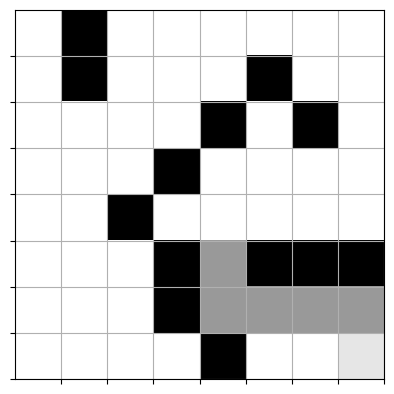

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 737/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 581 | Win rate: 1.000 | time: 39.43 minutes
   win | Epoch Reward: -0.5000000000000007 | RUUURdURUURRdRRDDDDLLLDDRRRD


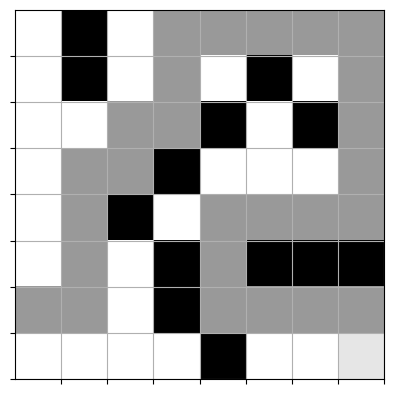

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 738/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 582 | Win rate: 1.000 | time: 39.51 minutes
   win | Epoch Reward: -2.500000000000001 | UUURUUdUURRRRRDUdUDUDlDRDDDLLLDDRRRD


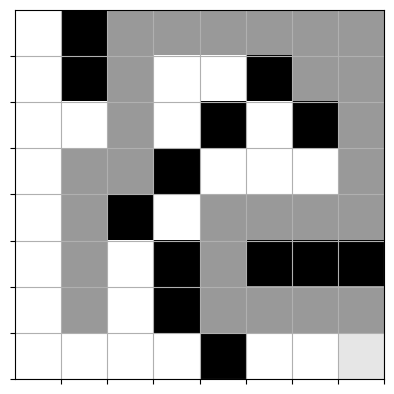

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 739/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 583 | Win rate: 1.000 | time: 39.58 minutes
   win | Epoch Reward: -1.7800000000000007 | DLLURUUURURUrdLRLRLLURRRRRDDDDLLLDDRRRD


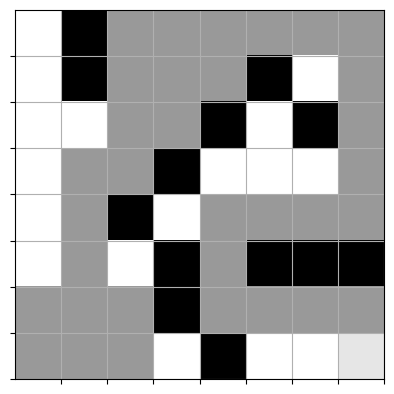

SUCCESSFUL START CELLS: [(0, 4), (0, 0), (0, 3), (0, 2), (0, 5)]
FAILED START CELL:  (0, 6)
Epoch: 740/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 584 | Win rate: 1.000 | time: 39.66 minutes
   win | Epoch Reward: 0.38 | RdRlRR


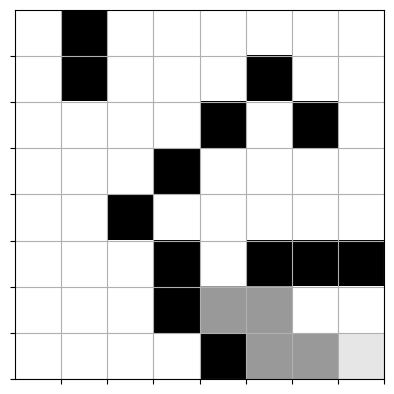

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 741/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 585 | Win rate: 1.000 | time: 39.74 minutes
   win | Epoch Reward: 0.92 | RRD


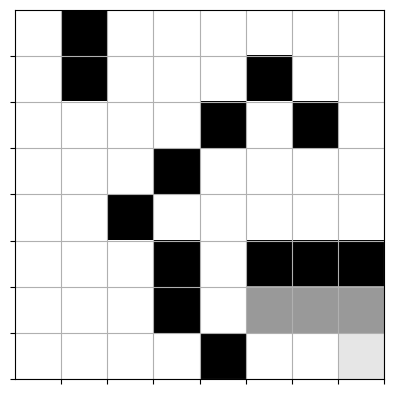

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 742/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 586 | Win rate: 1.000 | time: 39.80 minutes
   win | Epoch Reward: 0.71 | RrD


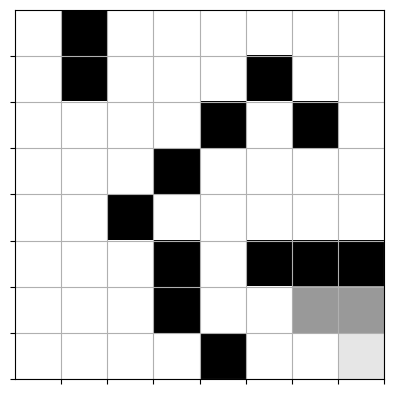

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 743/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 587 | Win rate: 1.000 | time: 39.86 minutes
   win | Epoch Reward: 1.0 | D


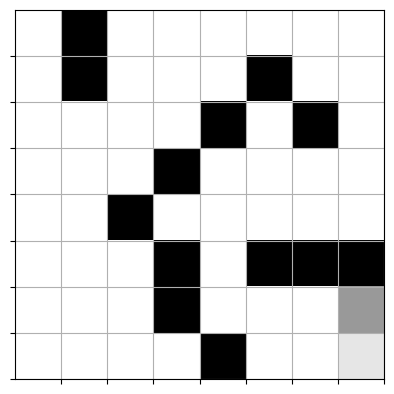

SUCCESSFUL START CELLS: [(0, 0)]
FAILED START CELL:  (0, 2)
Epoch: 744/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 588 | Win rate: 1.000 | time: 39.94 minutes
   win | Epoch Reward: -1.4100000000000001 | RUuUURURURURRRDDDDdLLLURURDDLDDRRRD


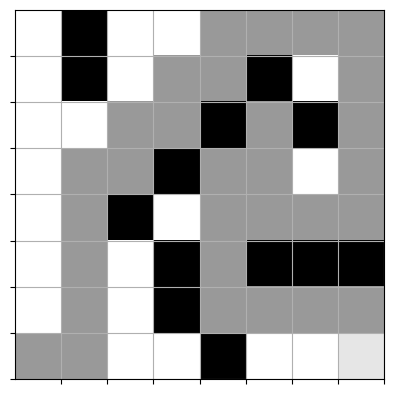

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 745/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 589 | Win rate: 1.000 | time: 40.02 minutes
   win | Epoch Reward: -2.0400000000000005 | UUUURURURURlRRRDDDDLrLUUUUDLLDDRRrD


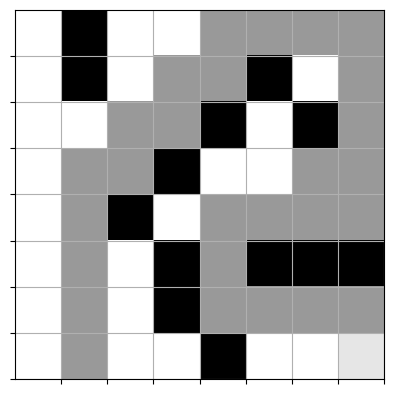

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 746/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 590 | Win rate: 1.000 | time: 40.10 minutes
   win | Epoch Reward: -4.490000000000001 | RUUUUrURRRUUUUULULUldRUUURURUURRRRDDDDLULDLDDRRRD


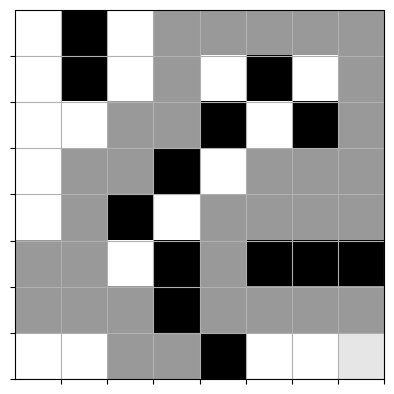

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 747/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 591 | Win rate: 1.000 | time: 40.20 minutes
   win | Epoch Reward: -14.869999999999976 | UdRRRUUUUUUUUURRRdDDRRRRRRRRUUDDuUUUUUUUUDDdDDURuRRRRRDdDDLLUULRUURURUrURRRDDDDLLLDDRRRD


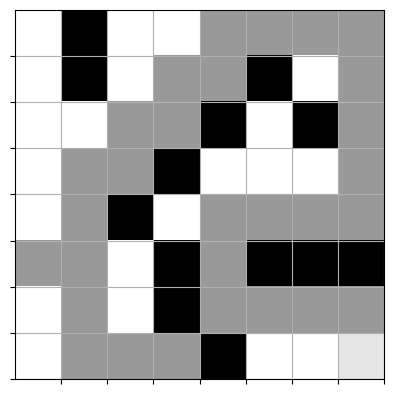

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 748/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 592 | Win rate: 1.000 | time: 40.27 minutes
   win | Epoch Reward: 0.96 | RR


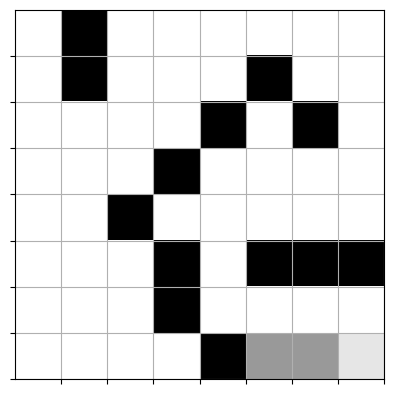

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 749/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 593 | Win rate: 1.000 | time: 40.34 minutes
   win | Epoch Reward: 1.0 | R


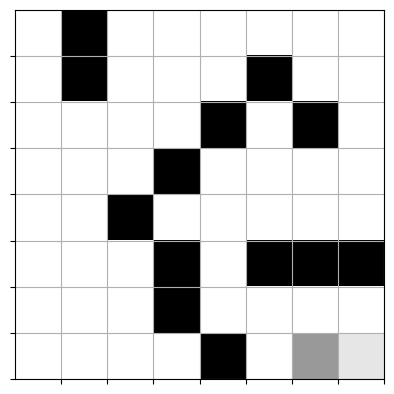

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 750/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 594 | Win rate: 1.000 | time: 40.42 minutes
   win | Epoch Reward: -2.000000000000001 | RRDDDuDRRURDDLRUURRRRDDDDLLLDDRRRD


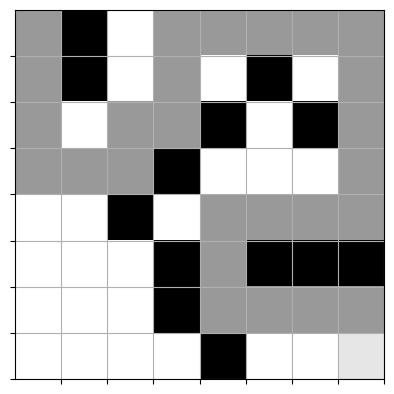

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 751/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 595 | Win rate: 1.000 | time: 40.49 minutes
   win | Epoch Reward: 0.06999999999999995 | RRRRRDDDDLLLDrDRRRD


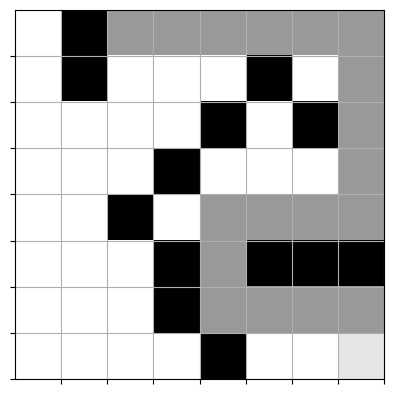

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 752/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 596 | Win rate: 1.000 | time: 40.56 minutes
   win | Epoch Reward: -0.39000000000000035 | RRRRlRRDDDDLLLDDRRRD


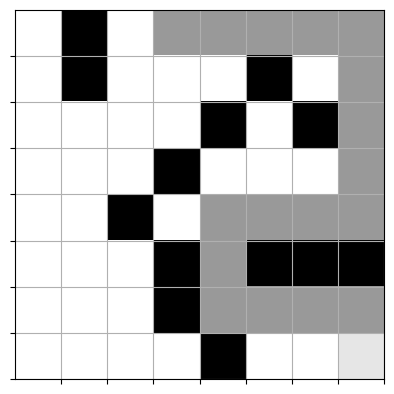

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 753/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 597 | Win rate: 1.000 | time: 40.63 minutes
   win | Epoch Reward: -1.3500000000000005 | RlRRRDDDDLrdLLLDDRRRlRD


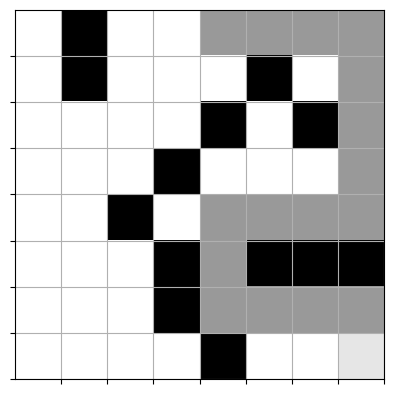

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 754/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 598 | Win rate: 1.000 | time: 40.70 minutes
   win | Epoch Reward: 0.44000000000000006 | RRDDDDLLLDDRRRD


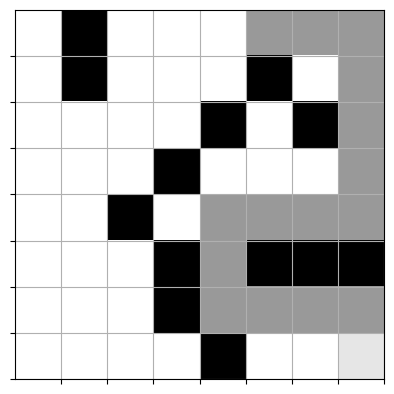

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 755/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 599 | Win rate: 1.000 | time: 40.77 minutes
   win | Epoch Reward: 0.10999999999999976 | lRRDDDDLuLDLDDRRRD


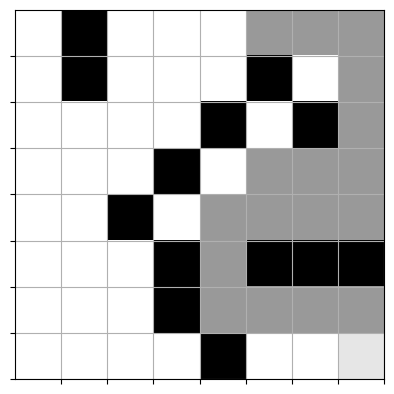

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 756/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 600 | Win rate: 1.000 | time: 40.84 minutes
   win | Epoch Reward: 0.52 | DDDDLLLDDRDRR


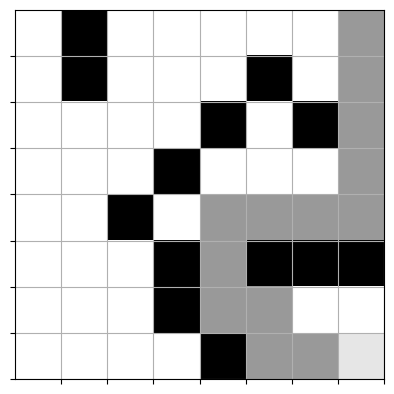

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 757/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 601 | Win rate: 1.000 | time: 40.94 minutes
   win | Epoch Reward: -13.789999999999992 | UDUDUDUDDDRRUUURRRRRuDLDDDDDDDDDDDDDDLLLRLDDDDDDDDDDDDDDDDDDDDDDDDDDDRDDDLLLDDRRrD


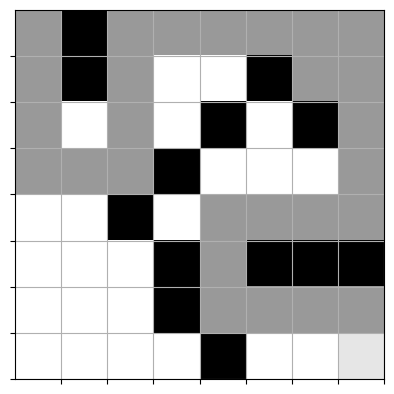

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 758/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 602 | Win rate: 1.000 | time: 41.01 minutes
   win | Epoch Reward: 0.2799999999999999 | URRRRRDDDLLLDDDRRRD


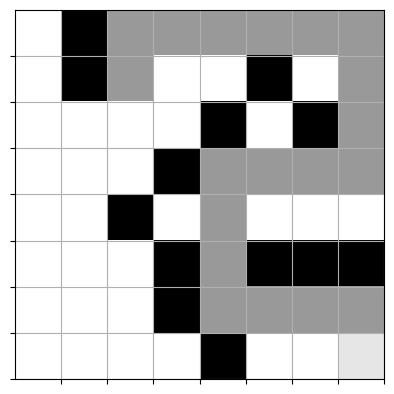

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 759/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 603 | Win rate: 1.000 | time: 41.10 minutes
   win | Epoch Reward: -15.259999999999994 | UuRRRRDLURDLURDLURDDDLLUUUUUUULLLLLLdULLDUuDUUULRRRRRRRRRRRdUUUdULLRRRRRRDDLDDRRRD


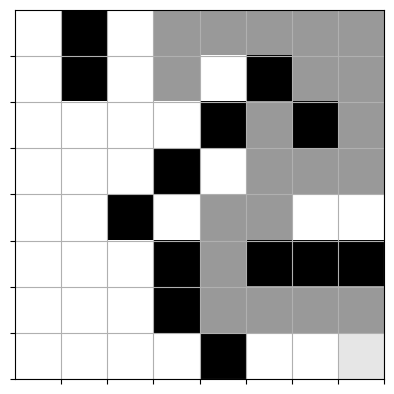

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 760/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 604 | Win rate: 1.000 | time: 41.17 minutes
   win | Epoch Reward: 0.36 | uRRRDDDLLDLDDRDRR


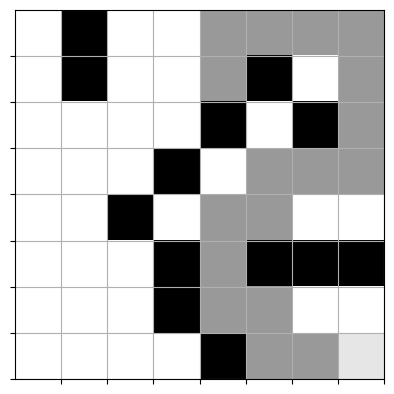

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 761/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 605 | Win rate: 1.000 | time: 41.23 minutes
   win | Epoch Reward: 0.52 | RDDDLLLDDRRRD


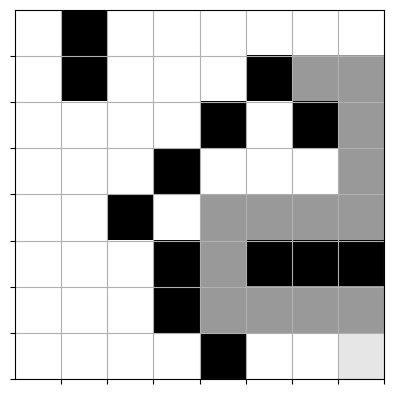

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 762/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 606 | Win rate: 1.000 | time: 41.30 minutes
   win | Epoch Reward: 0.56 | DDLDLlDDRDRR


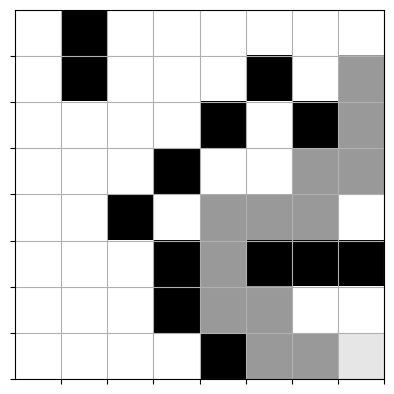

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 763/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 607 | Win rate: 1.000 | time: 41.37 minutes
   win | Epoch Reward: 0.07999999999999974 | DRRURUURRRrDDDDLLLDDRRRD


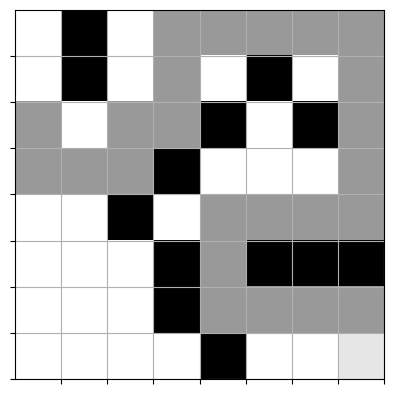

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 764/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 608 | Win rate: 1.000 | time: 41.44 minutes
   win | Epoch Reward: -0.6300000000000006 | RRULuRlRRRuRRDDDDlLLDDRDRR


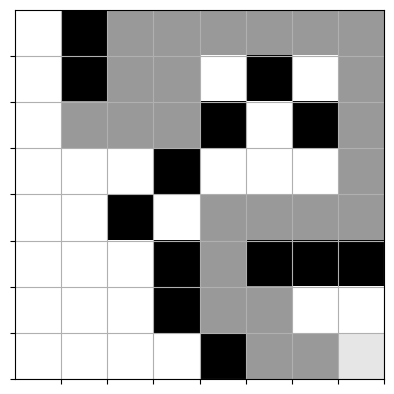

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 765/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 609 | Win rate: 1.000 | time: 41.50 minutes
   win | Epoch Reward: -0.010000000000000231 | uRRURRRDDDDLLLDDRRRrD


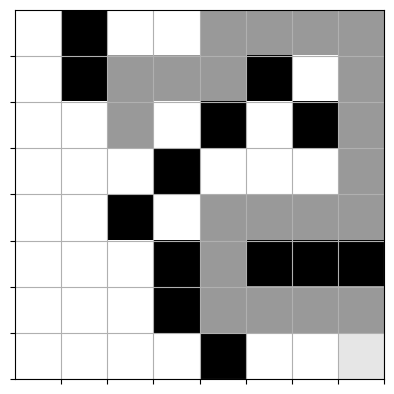

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 766/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 610 | Win rate: 1.000 | time: 41.57 minutes
   win | Epoch Reward: -1.2200000000000006 | UURUUUURRRlRDDDLLDLDDRDRr


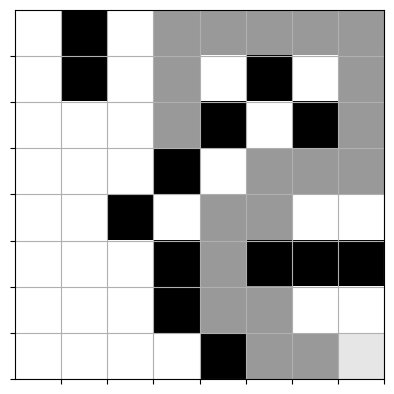

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 767/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 611 | Win rate: 1.000 | time: 41.64 minutes
   win | Epoch Reward: 0.17999999999999983 | DDLDuDDRRRD


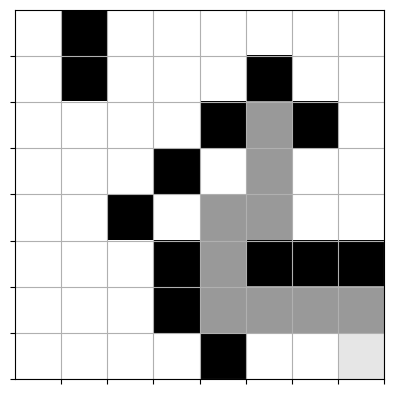

SUCCESSFUL START CELLS: [(0, 7), (0, 4), (0, 0), (0, 3), (0, 6), (0, 2), (0, 5)]
FAILED START CELL:  (1, 0)
Epoch: 768/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 612 | Win rate: 1.000 | time: 41.71 minutes
   win | Epoch Reward: 0.6000000000000001 | DDLLLDDRDRR


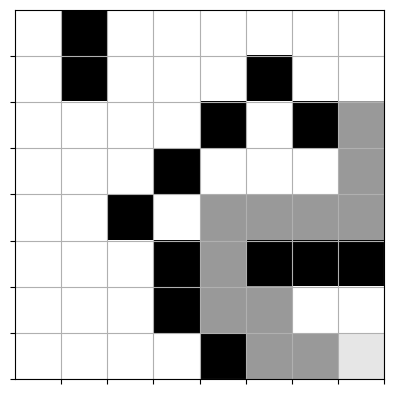

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 769/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 613 | Win rate: 1.000 | time: 41.78 minutes
   win | Epoch Reward: 0.11999999999999977 | RRURURURRRDDDDlLLDdRRRD


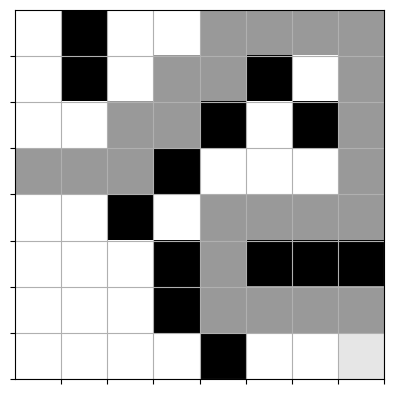

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 770/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 614 | Win rate: 1.000 | time: 41.84 minutes
   win | Epoch Reward: 0.1599999999999998 | RURUURRRRDDDDLLLDDRRRD


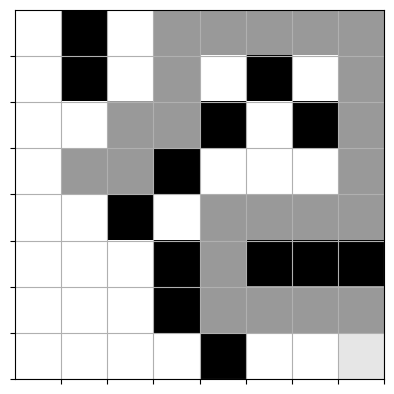

SUCCESSFUL START CELLS: [(0, 2), (0, 0)]
FAILED START CELL:  (0, 3)
Epoch: 771/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 615 | Win rate: 1.000 | time: 41.91 minutes
   win | Epoch Reward: -0.5900000000000007 | UUURlRRRRdURDDDLLDLDDRRRD


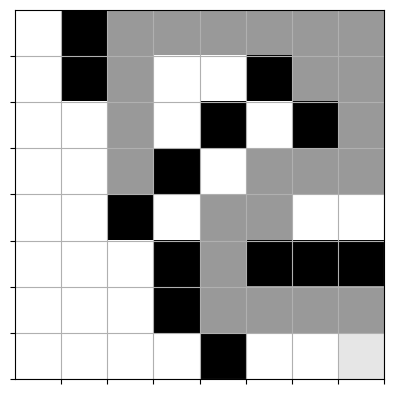

SUCCESSFUL START CELLS: []
FAILED START CELL:  (0, 0)
Epoch: 772/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 616 | Win rate: 1.000 | time: 41.97 minutes
   win | Epoch Reward: 0.6799999999999999 | RDLDDRDrR


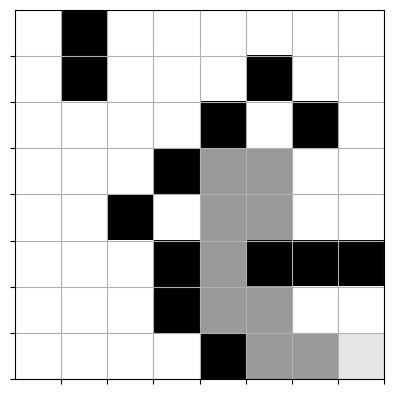

SUCCESSFUL START CELLS: [(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (4, 6), (5, 1), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (3, 0), (4, 5), (5, 0), (3, 6), (0, 7), (1, 2), (0, 4), (2, 1), (2, 7), (3, 2), (4, 1), (4, 7), (3, 5), (4, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7)]
FAILED START CELL:  (5, 2)
Epoch: 773/999 | Loss: 0.0013 | Episodes: 1000 | Win count: 617 | Win rate: 1.000 | time: 42.07 minutes
   win | Epoch Reward: 0.72 | DLDDRDRR


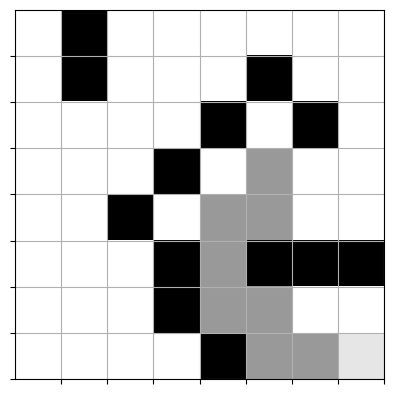

All Start Cells Passed!
Reached 100% win rate at epoch 773
Training complete in: 42.19 minutes


In [13]:
model = build_model(maze)
qtrain(model, maze, n_epoch=1000, max_memory=8*maze.size, data_size=32, target_update_freq=50)

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b> This cell will check to see if the model passes the completion check. Note: This could take several minutes.
</div>

All Start Cells Passed!


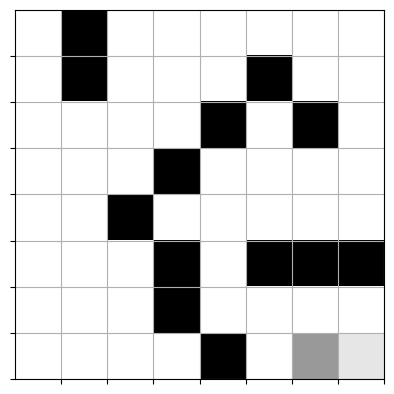

In [14]:
completion_check(model, qmaze)
show(qmaze)

This cell will test your model for one game. It will start the pirate at the top-left corner and run <b>play_game()</b>. The agent should find a path from the starting position to the target (treasure). The treasure is located in the bottom-right corner.

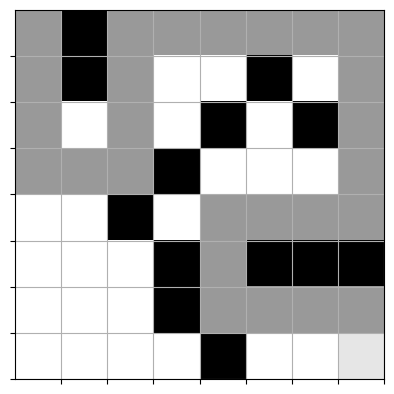

In [15]:
pirate_start = (0, 0)
play_game(model, qmaze, pirate_start)
show(qmaze)

{(3, 1), (3, 7), (5, 4), (4, 6), (0, 2), (0, 5), (2, 2), (1, 0), (6, 5), (3, 0), (4, 5), (0, 7), (1, 2), (0, 4), (2, 7), (6, 4), (6, 7), (3, 2), (4, 7), (4, 4), (0, 0), (0, 3), (2, 0), (0, 6), (1, 7), (6, 6)}
True
reward= -0.04


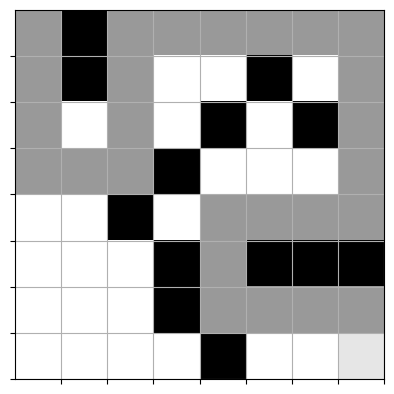

In [16]:
#MJM Test
pirate_start = (0, 0)
Win_Lose = play_game(model, qmaze, pirate_start)
print(qmaze.visited)   # DEBUG
print(Win_Lose)   # DEBUG
print("reward=", reward)
show(qmaze)

## Save and Submit Your Work

<div class="alert alert-block alert-info" style="color:black;">
    <b>Hint:</b> To use the markdown block below, double click in the <b>Type Markdown and LaTeX:  𝛼2</b> block below, to turn it back to html, Run the cell.
</div>

After you have finished creating the code for your notebook, save your work.
Make sure that your notebook contains your name in the filename (e.g. Doe_Jane_ProjectTwo.html). Download this file as an .html file clicking on ***file*** in *Jupyter Notebook*, navigating down to ***Download as*** and clicking on ***.html***. 
Download a copy of your .html file and submit it to Brightspace.